In [1]:
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch
import math
import time

from torch import nn
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from functools import partial

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
if torch.cuda.is_available():
    # Get the number of available GPUs
    num_gpus = torch.cuda.device_count()
    print(f'Number of available GPUs: {num_gpus}')
    
    # Get detailed information about each GPU
    for i in range(num_gpus):
        print(f'GPU {i}: {torch.cuda.get_device_name(i)}')
        print(f'  - Total Memory: {torch.cuda.get_device_properties(i).total_memory / (1024 ** 3):.2f} GB')
        print(f'  - Multiprocessors: {torch.cuda.get_device_properties(i).multi_processor_count}')
        print(f'  - CUDA Capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}')
else:
    print('CUDA is not available.')

Number of available GPUs: 1
GPU 0: NVIDIA A100-SXM4-40GB
  - Total Memory: 39.67 GB
  - Multiprocessors: 108
  - CUDA Capability: 8.0


In [3]:
# hyperparameters
# if using RPINN method, please cite https://arxiv.org/abs/2401.02300

LENGTH = 50. # TODO! replace with LENGTH_X
TOTAL_TIME = 50. # TODO! replace with LENGTH_Y
N_POINTS_X = 100
N_POINTS_T = 100 # TODO! replace with N_POINTS_Y
N = 100 # number of elements per direction from IGA!
LAYERS = 2
NEURONS_PER_LAYER = 100
EPOCHS = 10_000 
LEARNING_RATE = 0.0001
RPINN = 1 # set to 1 to use RPINN, 0 otherwise

PHYSICS_SCALING = 1
DATA_SCALING = 1e-14

# PINN Class

In [4]:
class PINN(nn.Module):
    """Simple neural network accepting two features as input and returning a single output

    In the context of PINNs, the neural network is used as universal function approximator
    to approximate the solution of the differential equation

    Parameters
    ----------
    num_hidden: int
        Number of hidden layers
    dim_hidden: int
        Number of neurons per hidden layer
    act: Callable
        Activation function (default is Tanh)
    pinning: bool
        Whether to pin the boundary conditions using a surrogate model (default is False)
    """
    def __init__(self, num_hidden: int, dim_hidden: int, act=nn.Tanh(), pinning: bool = False):

        super().__init__()

        self.pinning = pinning

        self.layer_in = nn.Linear(2, dim_hidden)
        self.layer_out = nn.Linear(dim_hidden, 1)

        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

    def forward(self, x, t):

        x_stack = torch.cat([x/LENGTH, t/TOTAL_TIME], dim=1)
        out = self.act(self.layer_in(x_stack))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        logits = self.layer_out(out)

        # if requested pin the boundary conditions
        # using a surrogate model: (x - 0) * (x - L) * NN(x)
        if self.pinning:
            logits *= (x - 0.0)*(x - LENGTH)*(t - 0.0)*(t - TOTAL_TIME)

        return logits

def f(pinn: PINN, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """Compute the value of the approximate solution from the NN model"""
    return pinn(x, t)


def df(output: torch.Tensor, input: torch.Tensor, order: int = 1) -> torch.Tensor:
    """Compute neural network derivative with respect to input features using PyTorch autograd engine"""
    df_value = output
    for _ in range(order):
        df_value = torch.autograd.grad(
            df_value,
            input,
            grad_outputs=torch.ones_like(input),
            create_graph=True,
            retain_graph=True,
        )[0]

    return df_value


def dfdt(pinn: PINN, x: torch.Tensor, t: torch.Tensor, order: int = 1):
    """Derivative with respect to the time variable of arbitrary order"""
    f_value = f(pinn, x, t)
    return df(f_value, t, order=order)


def dfdx(pinn: PINN, x: torch.Tensor, t: torch.Tensor, order: int = 1):
    """Derivative with respect to the spatial variable of arbitrary order"""
    f_value = f(pinn, x, t)
    return df(f_value, x, order=order)

# Read and visualize input data

In [5]:
def data_reader_k(lines: list, K: int) -> np.ndarray:
    '''
    This function reads the porosity/permeability data from the Poros.data/Perm.data file and returns a numpy array of the porosity/permeability data for the given plane K.

    Parameters
    ----------
    lines : list
        List of strings containing the lines of the Poros.data/Perm.data file.
    K : int
        The plane number for which the data is to be read. The original source files had K ranging from 1 to 3.

    Returns
    -------
    data_plane: np.ndarray
        A numpy array of the porosity/permeability data for the given plane K.

    Raises
    ------
    None
    '''

    data_plane = np.zeros((25, 25))
    K_start = False

    for line in lines:
        if "Plane K = {}".format(K) in line:
            K_start = True
            continue
        if "Plane K = {}".format(K+1) in line:
            break
        if K_start:
            if line.strip().startswith("I ="):
                temp_map = line.strip().split()[2:] # this will skip everything up to I = and get the I indices
                a = int(temp_map[0]) - 1
                b = int(temp_map[-1])
            if line.strip().startswith("J="):
                row_indx = int(line.strip().split()[1]) - 1 # this will get the J index
                row_data = line.strip().split()[2:] # Skip the J= part and get the data
                row_data = [float(i) for i in row_data]
                data_plane[row_indx, a:b] = row_data

    return data_plane.T # Transpose the data to have x-y coordinates

# read permeability data from 'Perm.data'

with open('Perm.data') as f1le:
    lines = f1le.readlines()

perm_k1 = data_reader_k(lines, 1)
perm_k2 = data_reader_k(lines, 2)
perm_k3 = data_reader_k(lines, 3)

from scipy.interpolate import RegularGridInterpolator

def data_interpolator_k(data: np.ndarray, a_x: float = 0, b_x: float = 25, nsteps_x: int = 100, a_y: float = 0, b_y: float = 25, nsteps_y: int = 100) -> np.ndarray:
    '''
    This function interpolates the data to a finer grid using RegularGridInterpolator from scipy.

    Parameters:
    ----------
    data: np.ndarray
        The porosity or permeability data to be interpolated.
        Must be of the same format as the data_reader() function output.
        I.e. 2D numpy array with the first dimension being the x-axis and the second dimension being the y-axis and the values being the porosity/permeability values.
    a_x: float
        The starting value of the x-axis. Default is 0.
    b_x: float
        The ending value of the x-axis. Default is 25.
    nsteps_x: int
        The number of steps to interpolate the x-axis. Default is 100.
    a_y: float
        The starting value of the y-axis. Default is 0.
    b_y: float
        The ending value of the y-axis. Default is 25.
    nsteps_y: int
        The number of steps to interpolate the y-axis. Default is 100.

    Returns:
    -------
    interp_data: np.ndarray
        The interpolated data on the finer grid.
    '''

    x = np.linspace(0, data.shape[0], data.shape[0])
    y = np.linspace(0, data.shape[1], data.shape[1])

    interpolator = RegularGridInterpolator((x, y), data, method='linear')

    x_new = np.linspace(a_x, b_x, nsteps_x)
    y_new = np.linspace(a_y, b_y, nsteps_y)
    xv, yv = np.meshgrid(x_new, y_new)
    points = np.array([xv.flatten(), yv.flatten()]).T
    interp_data = interpolator(points).reshape(nsteps_x, nsteps_y)

    return interp_data

# interpolate the permeability data to a finer grid

perm_k1_interp = data_interpolator_k(perm_k1)
perm_k2_interp = data_interpolator_k(perm_k2)
perm_k3_interp = data_interpolator_k(perm_k3)

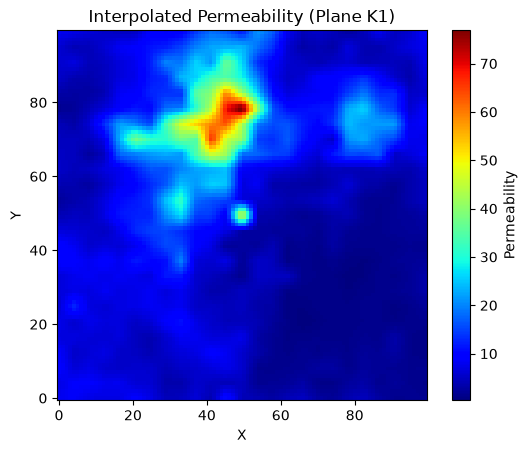

In [6]:
# visualize the permeability data for verification

plt.imshow(perm_k1_interp, cmap='jet')
plt.colorbar(label='Permeability')
plt.title('Interpolated Permeability (Plane K1)')
plt.xlabel('X')
plt.ylabel('Y')
plt.gca().invert_yaxis()
plt.show()

In [7]:
# load the initial saturation data

def data_reader_s(filename: str, step_size: float , size_x = 50  , size_y = 50 ) -> np.ndarray:
    '''
    TODO! Update the naming format to ensure consistency with the `co2_sequestration_trim` code!
    This function reads the saturation data of the output format `s.out_%i.data` from the IGA-ADS based C language code (`co2_sequestration.cpp`)

    Parameters
    ----------
    filename : str
        The name of the file containing the saturation data. Usually is of the format `s.out_%i.data`
    step_size : float
        The grid step size in each direction. This is used to determine the indices in the grid.
    size_x : float
        The size of the grid in the x direction. Default is 50.
    size_y : float
        The size of the grid in the y direction. Default is 50.
    
    Returns
    -------
    saturation_grid : np.ndarray
        A 2D numpy array of shape (m, n), where m = size_x/step_size and n = size_y/step_size.
        Each element in the array represents the saturation value at the corresponding grid point.
    
    '''

    height = int(size_x * 1 / step_size)
    width = int(size_y * 1 / step_size)
    saturation_grid = np.zeros((height, width))
    with open(filename, 'r') as file:
        for line in file:
            x, y, value = map(float, line.strip().split())
            # Calculate the indices based on step_size
            x_index = int(x / step_size)
            y_index = int(y / step_size)

            # Assign the saturation value to the grid
            if 0 <= x_index < height and 0 <= y_index < width:  # Check bounds
                saturation_grid[x_index, y_index] = value

    return saturation_grid

In [8]:
# Example usage (replace 's.init.data' with the actual filename and adjust step_size)
saturation_array = data_reader_s('perm_map_k1/s.out_0.data', step_size=0.5)  # Example step size
saturation_array.shape, np.max(saturation_array)

((100, 100), np.float64(0.0216488173))

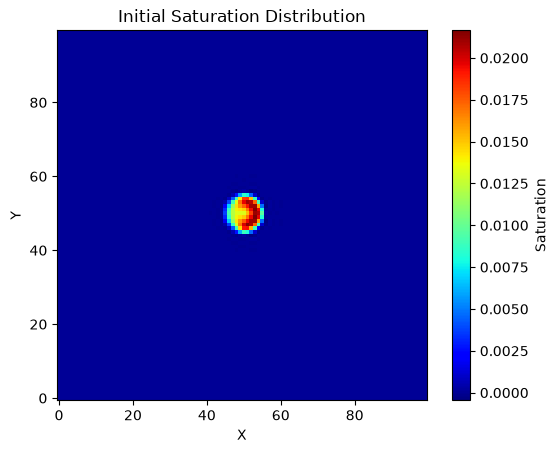

In [9]:
plt.imshow(saturation_array.T, cmap='jet')
plt.colorbar(label='Saturation')
plt.title('Initial Saturation Distribution')
plt.xlabel('X')
plt.ylabel('Y')
# rotate the plot 90 degrees to the left
plt.gca().invert_yaxis()
plt.show()

In [10]:
pressure_array = data_reader_s('perm_map_k1/p.out_0.data', step_size=0.5, size_x=LENGTH, size_y=TOTAL_TIME)

## Transfer the S and K maps to callable functions

In [11]:
def make_fun(x_lin: torch.Tensor, y_lin: torch.Tensor, z: torch.Tensor) -> Callable:
    '''
    This function creates a bilinear interpolation function based on the provided grid points and values.

    Parameters
    ----------
    x_lin : torch.Tensor
        1D tensor of x-coordinates of the grid points.
    y_lin : torch.Tensor
        1D tensor of y-coordinates of the grid points.
    z : torch.Tensor
        2D tensor of values at the grid points, where z[i,j] corresponds to the value at (x_lin[i], y_lin[j]).

    Returns
    -------
    fun : Callable
        A function that takes two tensors (xx, yy) as input and returns the bilinearly interpolated values at those points.
    '''

    nx = len(x_lin)
    ny = len(y_lin)

    def fun(xx, yy) -> torch.Tensor:
        '''
        Bilinear interpolation function.
        '''
        xi = torch.clamp(torch.searchsorted(x_lin, xx, right=True), 0, nx-1)
        yi = torch.clamp(torch.searchsorted(y_lin, yy, right=True), 0, ny-1)
        z_lb = z[xi - 1, yi - 1]
        z_rb = z[xi, yi - 1]
        z_lt = z[xi - 1, yi]
        z_rt = z[xi, yi]
        wx = (xx - x_lin[xi - 1]) / (x_lin[xi] - x_lin[xi - 1])
        wy = (yy - y_lin[yi - 1]) / (y_lin[yi] - y_lin[yi - 1])
        z_b = (1 - wx) * z_lb + wx * z_rb
        z_t = (1 - wx) * z_lt + wx * z_rt
        return (1 - wy) * z_b + wy * z_t

    return fun

/tmp/ipykernel_53314/161386950.py:27: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  xi = torch.clamp(torch.searchsorted(x_lin, xx, right=True), 0, nx-1)


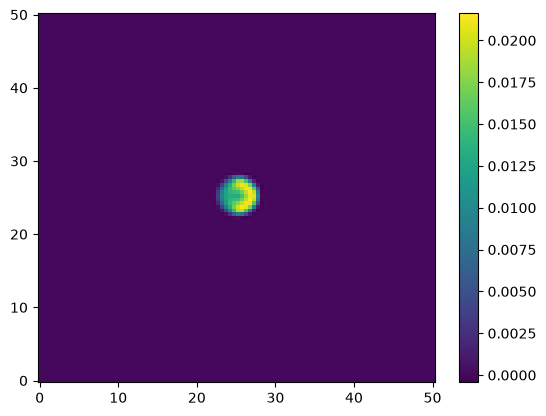

In [12]:
x_lin = torch.linspace(0, LENGTH, N, requires_grad=True,device=device)
y_lin = torch.linspace(0, TOTAL_TIME, N, requires_grad=True,device=device)
 
Sg_tensor = torch.tensor(saturation_array.copy(), device=device, requires_grad=True)
Sg_function = make_fun(x_lin, y_lin, Sg_tensor)

x_plot, y_plot = torch.meshgrid(x_lin, y_lin, indexing='ij')
Sg_plot = Sg_function(x_plot, y_plot)

def plotly(x, y, z):
    '''
    Simple plotting function using matplotlib to visualize 2D data from z function values over x and y grids.
    '''
    plt.figure()
    plt.pcolormesh(x.detach().cpu().numpy(), y.detach().cpu().numpy(), z.detach().cpu().numpy())
    plt.colorbar()
    plt.show()
plotly(x_plot, y_plot, Sg_plot)

In [13]:
P_tensor = torch.tensor(pressure_array.copy(), device=device)
P_function = make_fun(x_lin, y_lin, P_tensor)

In [14]:
darcy_to_si = 1e-15 #1e-12 
gamma = 1e6

num_rows,num_cols = N,N
row_indices = np.arange(num_rows)
col_indices = np.arange(num_cols)

perm_k1_tensor = torch.tensor(perm_k1_interp, device=device, dtype=torch.float32)

K_array = perm_k1_tensor[np.ix_(row_indices, col_indices)] * darcy_to_si * gamma
K_tensor = torch.tensor(K_array, device=device, requires_grad=True)
K_function = make_fun(x_lin, y_lin, K_tensor.T)

/tmp/ipykernel_53314/3106933645.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  K_tensor = torch.tensor(K_array, device=device, requires_grad=True)


In [15]:
# FOR UNIFORM PERMEABILITY!
def K_function(x: torch.Tensor, y: torch.Tensor):
    return torch.ones_like(x) * darcy_to_si * gamma

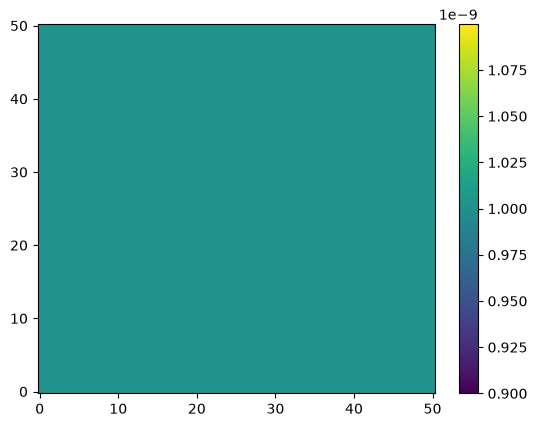

torch.Size([100, 100])

In [16]:
orginalK = K_function(x_plot, y_plot)
plotly(x_plot, y_plot, orginalK)
orginalK.shape

# if using a non-uniform permeability map - uncomment these lines
#dfK  = df(K_function(x_plot, y_plot), x_plot)
#plotly(x_plot, y_plot, dfK)

#dfKy  = df(K_function(x_plot, y_plot), y_plot)
#plotly(x_plot, y_plot, dfKy)

# Problem Setup

In [17]:
mu_w = 2.5e-4
mu_g = 4e-5
rho_g = 479
rho_w = 1035
g = 9.81
corr_coeff = 1
qg_rate = 1e-6
qg_x = 25
qg_y = 25
qg_radius = 9.0 # this is actually the square of the radius

In [18]:
def qg(x, y):
    '''
    Source term function for gas injection.
    '''
    dx = x - qg_x
    dy = y - qg_y
    r2 = torch.min(1 / qg_radius * (dx * dx + dy * dy), torch.tensor(1.0, device=device))
    return qg_rate * ((r2 - 1) * (r2 - 1) * (r2 + 1) * (r2 + 1))


def qw(x: torch.Tensor, y: torch.Tensor):
    '''
    Source term function for brine water injection.
    Returns zero for now, until the brine injection is implemented.
    '''
    return torch.zeros_like(x)

def alpha(x, y):
    '''
    Pressure equation coefficient function.
    '''
    val = K_function(x, y) * ((1 - Sg_function(x, y)) / mu_w + Sg_function(x, y) / mu_g)
    return val

def eqs(x,y):
    '''
    The bracketed term in right hand side of the pressure equation.
    '''
    val = rho_w * (1 - Sg_function(x, y)) / mu_w + rho_g * Sg_function(x, y) / mu_g
    return val


def RHS(x,y) :
    '''   
    Right hand side function of the pressure equation.
    '''
    eqs_val = eqs(x,y) * K_function(x, y)
    # eqs_dx = torch.autograd.grad(eqs_val, x, create_graph=True, grad_outputs=torch.ones_like(eqs_val))[0]
    eqs_dy = torch.autograd.grad(eqs_val, y, create_graph=True, grad_outputs=torch.ones_like(eqs_val))[0]
    sat_term = g * eqs_dy
    source_term = (qg(x,y) + qw(x,y)) * gamma * corr_coeff
    return  -sat_term - source_term

Equation:

$$\nabla \cdot \left( \left( \frac{1-S_g}{\mu_w} + \frac{S_g}{\mu_g} \right) K \nabla p \right) =
    g \frac{\partial}{\partial y} \left( K \left( \frac{1-S_g}{\mu_w}\rho_w + \frac{S_g}{\mu_g} \rho_g \right) \right) - 
    (q_w + q_g)
$$
Here, we can define $\alpha$ as:
$$
\alpha(x,y) = \left( \frac{1-S_g}{\mu_w} + \frac{S_g}{\mu_g} \right) K(x,y)
$$
Also, if the $K$ is uniform, then we can take it out of the divergence operator on the RHS, leading to:
$$
    g K \nabla \cdot \left( \frac{1-S_g}{\mu_w}\rho_w + \frac{S_g}{\mu_g} \rho_g \right) - 
    (q_w + q_g)
$$
The real values of $K$ are of the order of $10^{-12} - 10^{-15}$. To avoid numerical issues, we can rescale $K$ by multiplying the equation by the same number. We simply multiply $K$ by such number $\gamma$ and multiply the source terms by the same number $\gamma$. The equation becomes:
$$\nabla \cdot \left( \alpha(x,y)_{\gamma} \nabla p \right) =
    g K_{\gamma} \nabla \cdot \left( \frac{1-S_g}{\mu_w}\rho_w + \frac{S_g}{\mu_g} \rho_g \right) - 
    \gamma (q_w + q_g)
$$
Here, $K_{\gamma} = \gamma K$ and $\alpha(x,y)_{\gamma} = \alpha(x,y) \gamma$.

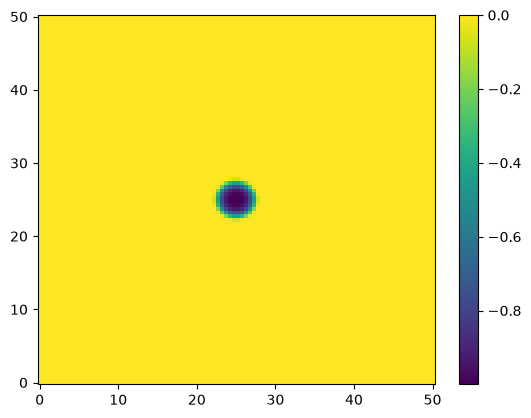

In [19]:
plotly(x_plot, y_plot, RHS(x_plot, y_plot))

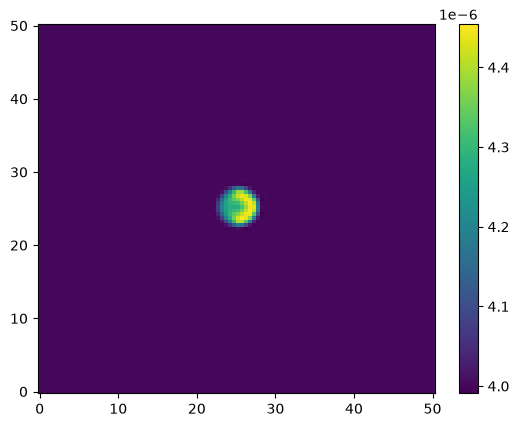

In [20]:
plotly(x_plot, y_plot, alpha(x_plot, y_plot))

# Loss Function

In [21]:
INTERIOR_LOSS_STORED: torch.Tensor
PHYSICS_LOSS_STORED: torch.Tensor
DATA_LOSS_STORED: torch.Tensor

EPOCH_COUNTER = 0
AT_EPOCHS =  []
LOSSES = []
NORMS_H1 = []

def compute_norms(pinn: PINN, x: torch.Tensor, y: torch.Tensor):
    global INTERIOR_LOSS_STORED

    N = N_POINTS_X * N_POINTS_T

    dzdx = dfdx(pinn.to(device), x, y, order=1)
    dzdt = dfdt(pinn.to(device), x, y, order=1)

    h1_z_norm = math.sqrt((dzdx.pow(2).sum()+dzdt.pow(2).sum()) / N)
    h1_norm = h1_z_norm

    loss_approximation = math.sqrt(INTERIOR_LOSS_STORED / N)

    with open('OutputPlots.txt', 'a') as file_f:
       print(f"||uNN||h1: {h1_norm:.7f} loss approx: {loss_approximation:.7f}", file=file_f)

    AT_EPOCHS.append(EPOCH_COUNTER)
    LOSSES.append(loss_approximation)
    NORMS_H1.append(h1_norm)

In [22]:
from tqdm import tqdm

In [ ]:
def linearized(ix, iy):
  return ix * N_POINTS_X + iy

def nearby(ix, iy):
  return [(ix + 1, iy), (ix - 1, iy), (ix, iy - 1), (ix, iy + 1)]

def laplace_gram():
  G = torch.eye(N_POINTS_X * N_POINTS_T,device=device)
  for ix in range(N_POINTS_X):
    for iy in range(N_POINTS_T):
      i = linearized(ix, iy)
      G[i, i] = 1
  for ix in range(1, N_POINTS_X - 1):
    for iy in range(1, N_POINTS_T - 1):
      i = linearized(ix, iy)
      G[i, i] = 4
      for jx, jy in nearby(ix, iy):
        j = linearized(jx, jy)
        G[i, j] = -1
  hx = 1.0 / N_POINTS_X
  hy = 1.0 / N_POINTS_T
  G = G / (hx*hy)
  return G

def poisson_gram(epsilon):
  G = torch.eye(N_POINTS_X * N_POINTS_T,device=device)
  x_lin = torch.linspace(0, LENGTH, N, requires_grad=False,device=device)
  y_lin = torch.linspace(0, TOTAL_TIME, N, requires_grad=False,device=device)

  def eps_at(ix, iy):
    x, y = x_lin[ix], y_lin[iy]
    return epsilon(x, y)

  for ix in tqdm(range(N_POINTS_X)):
    for iy in range(N_POINTS_T):
      i = linearized(ix, iy)
      G[i, i] = 1
  print('Loop 1 done \n') 

  for ix in tqdm(range(1, N_POINTS_X - 1)):
    for iy in range(1, N_POINTS_T - 1):
      i = linearized(ix, iy)
      G[i, i] = 2 * eps_at(ix, iy) + eps_at(ix - 1, iy) + eps_at(ix, iy - 1)
  print('Loop 2 done \n')   

  for ix in tqdm(range(1, N_POINTS_X - 1)):
    for iy in range(2, N_POINTS_T - 1):
      i = linearized(ix, iy)
      jx = ix
      jy = iy - 1
      j = linearized(jx, jy)
      G[i, j] = -eps_at(ix, iy - 1)
  print('Loop 3 done \n')   

  for ix in tqdm(range(1, N_POINTS_X - 1)):
    for iy in range(1, N_POINTS_T - 2):
      i = linearized(ix, iy)
      jx = ix
      jy = iy + 1
      j = linearized(jx, jy)
      G[i, j] = -eps_at(ix, iy)
  print('Loop 4 done \n')   

  for ix in tqdm(range(2, N_POINTS_X - 1)):
    for iy in range(1, N_POINTS_T - 1):
      i = linearized(ix, iy)
      jx = ix - 1
      jy = iy
      j = linearized(jx, jy)
      G[i, j] = -eps_at(ix - 1, iy)
  print('Loop 5 done \n')  
  
  for ix in tqdm(range(1, N_POINTS_X - 2)):
    for iy in range(1, N_POINTS_T - 1):
      i = linearized(ix, iy)
      jx = ix + 1
      jy = iy
      j = linearized(jx, jy)
      G[i, j] = -eps_at(ix, iy)

  hx = 1.0 / N_POINTS_X
  hy = 1.0 / N_POINTS_T
  G = G / (hx*hy)
  return G

G = laplace_gram()
#with torch.no_grad():
#    G = poisson_gram(epsilon=alpha)
G = G.to(device)
#G = G.to(torch.float64)
G_LU = torch.linalg.lu_factor(G)

In [24]:
def compute_loss(pinn: PINN, x:torch.Tensor, t: torch.tensor, w_physics: float = 1.0, w_data: float = 0):

    y = t
    if w_physics > 0:
        rhs = RHS(x, y)

        loss_physics = df(alpha(x, y) * dfdt(pinn, x, y), y) + df(alpha(x, y) * dfdx(pinn, x, y), x) - rhs
        loss_physics = loss_physics.to(torch.float32)

        #THIS IS RPINN LOSS
        if RPINN==1:
            Ginv_loss = torch.linalg.lu_solve(*G_LU, loss_physics.reshape(-1, 1))
            loss_physics_val = torch.dot(loss_physics.reshape(-1), Ginv_loss.reshape(-1))

        #THIS IS PINN LOSS
        if RPINN==0:
            loss_physics_val = loss_physics.pow(2).sum()
    else:
        loss_physics_val = torch.tensor(0.0)

    if w_data > 0:
        loss_data = pinn(x, y) - P_function(x, y)
        loss_data_val = loss_data.pow(2).sum()
        loss_val = w_physics * loss_physics_val * PHYSICS_SCALING + w_data * loss_data_val * DATA_SCALING
    else: 
        loss_val = loss_physics_val

    global INTERIOR_LOSS_STORED
    global PHYSICS_LOSS_STORED
    global DATA_LOSS_STORED
    global EPOCH_COUNTER

    if EPOCH_COUNTER % 100 == 0:
      INTERIOR_LOSS_STORED = loss_val
      PHYSICS_LOSS_STORED = loss_physics_val if w_physics > 0 else torch.tensor(0.0)
      DATA_LOSS_STORED = loss_data_val if w_data > 0 else torch.tensor(0.0)
      #compute_norms(pinn, x, t)

    EPOCH_COUNTER += 1
    return loss_val

# Plotting functions

In [25]:
def plot_color(z: torch.Tensor, x: torch.Tensor, t: torch.Tensor, n_points_x, n_points_t, figsize=(8, 6), dpi=100, cbar_bounds=None):
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    z_raw = z.detach().cpu().numpy()
    x_raw = x.detach().cpu().numpy()
    t_raw = t.detach().cpu().numpy()
    size = int(np.sqrt(z_raw.size))
    X = x_raw.reshape(n_points_t, n_points_x)
    T = t_raw.reshape(n_points_t, n_points_x)
    Z = z_raw.reshape(n_points_t, n_points_x)
    ax.set_title("CRVPINN solution")
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")

    pcolor_kwargs = {}
    if cbar_bounds is not None:
        vmin, vmax = cbar_bounds
        pcolor_kwargs["vmin"] = vmin
        pcolor_kwargs["vmax"] = vmax

    c = ax.pcolor(X, T, Z, **pcolor_kwargs)
    fig.colorbar(c, ax=ax)

    return fig

def running_average(y, window=100):
    cumsum = np.cumsum(np.insert(y, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / float(window)

# Training functions

In [26]:
def train_model(
    nn_approximator: PINN,
    x: torch.Tensor,
    t: torch.Tensor,
    loss_fn: Callable,
    learning_rate: int = 0.01,
    max_epochs: int = 1_000,
    update_freq: int = 1000,
    device="cuda"
) -> PINN:

    optimizer = torch.optim.Adam(nn_approximator.parameters(), lr=learning_rate)
    loss_values = []
    time_total = 0
    time_total_forward = 0
    time_total_backward = 0
    time_total_optimization = 0
    
    for epoch in range(max_epochs):
        try:
            time_epoch0 = time.time()

            t_forward_before = time.time()
            loss: torch.Tensor = loss_fn(nn_approximator)
            t_forward_after = time.time()

            if not torch.isfinite(loss).all():
                raise ValueError(f"Non-finite loss at epoch {epoch}: nan={torch.isnan(loss).any().item()} inf={torch.isinf(loss).any().item()}")

            optimizer.zero_grad()
            
            t_backward_before = time.time()
            loss.backward()
            t_backward_after = time.time()

            t_optimization_before = time.time()
            optimizer.step()
            t_optimization_after = time.time()
            
            time_epoch1 = time.time()
            time_epoch = time_epoch1 - time_epoch0
            time_total += time_epoch
            time_total_forward += t_forward_after - t_forward_before
            time_total_backward += t_backward_after - t_backward_before
            time_total_optimization += t_optimization_after - t_optimization_before

            if torch.isnan(loss):
                raise ValueError(f"NaN detected in loss at epoch {epoch + 1}")

            loss_values.append(loss.item())
            if (epoch + 1) % update_freq == 0:
                print(f"Epoch: {epoch + 1} - Loss: {float(loss):.3e}; total runtime: {time_total} (forward: {time_total_forward} grad: {time_total_backward} opt: {time_total_optimization}); time per epoch: {time_total / (epoch + 1)};")

                z = f(nn_approximator.to(device), x, t)
                color = plot_color(z.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)
                plt.show(color)

        except KeyboardInterrupt:
            break

    return nn_approximator, np.array(loss_values)

# Helper functions

In [27]:
def compare_with_iga(pinn_result: torch.Tensor, it_simulation: int, folder: str, err_bounds: tuple = None):   

    iga_filename = f'{folder}/p.out_{it_simulation * 10}.data'
    pressure_iga = data_reader_s(iga_filename, step_size=0.5)  
    pressure_iga_tensor = torch.tensor(pressure_iga.copy(), device=device, requires_grad=False)
    plotly(x_plot, y_plot, pressure_iga_tensor)

    z_diff = pinn_result - pressure_iga_tensor.reshape(-1, 1)
    z_diff_abs = torch.abs(z_diff)
    z_diff_perc = 100.0 * z_diff_abs / (torch.max(pressure_iga_tensor))
    color = plot_color(z_diff_perc.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T, cbar_bounds=err_bounds)
    plt.title(f'Difference between CRVPINN and IGA-ADS-MUMPS at {it_simulation}th time step, %')

In [28]:
def continue_training(
    pinn: PINN,
    x: torch.Tensor,
    t: torch.Tensor,
    max_epochs: int = 100,
    update_freq: int = 100,
    n_it_simulation: int = 10,
    start_simulation: int = 0,
    folder_name: str = None,
) -> PINN:

    loss_values_cont = []
    time_total = 0
    for it_simulation in range(n_it_simulation):
        print(f'Starting simulation iteration {it_simulation+1}/{n_it_simulation}')
        saturation_array = data_reader_s(f'{folder_name}/s.out_{(it_simulation+start_simulation)*10}.data', step_size=0.5)
        Sg_tensor = torch.tensor(saturation_array.copy(), device=device, requires_grad=True)
        global Sg_function
        Sg_function = make_fun(x_lin, y_lin, Sg_tensor)
        plotly(x_plot, y_plot, Sg_function(x_plot, y_plot))

        time_train0 = time.time()
        loss_fn = partial(compute_loss, x=x, t=t)
        pinn_trained, loss_values = train_model(
            pinn, x, t, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=max_epochs, update_freq=update_freq)
        time_train1 = time.time()
        loss_values_cont.extend(loss_values)
        time_total += time_train1 - time_train0
        print(f'Training time : %f'%(time_train1 - time_train0))
    print(f'Total training time for {n_it_simulation} iterations: %f'%(time_total))
    return pinn_trained, loss_values_cont

# PINN Training Loop

In [29]:
x_domain = [0.0, LENGTH]
t_domain = [0.0, TOTAL_TIME]

x_raw = torch.linspace(x_domain[0], x_domain[1], steps=N_POINTS_X, requires_grad=True)
t_raw = torch.linspace(t_domain[0], t_domain[1], steps=N_POINTS_T, requires_grad=True)
grids = torch.meshgrid(x_raw, t_raw, indexing="ij")

x = grids[0].flatten().reshape(-1, 1).to(device).clone().detach().requires_grad_(True).to(device)
t = grids[1].flatten().reshape(-1, 1).to(device).clone().detach().requires_grad_(True).to(device)

# PINN with uniform $K = 10^{-15} m^2$ (porosity map K1)

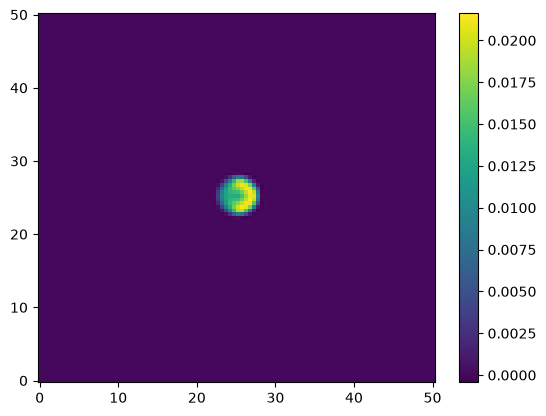

In [30]:
saturation_array = data_reader_s(f'uniformK1/s.out_0.data', step_size=0.5) 
Sg_tensor = torch.tensor(saturation_array.copy(), device=device, requires_grad=True)
global Sg_function
Sg_function = make_fun(x_lin, y_lin, Sg_tensor)
plotly(x_plot, y_plot, Sg_function(x_plot, y_plot))

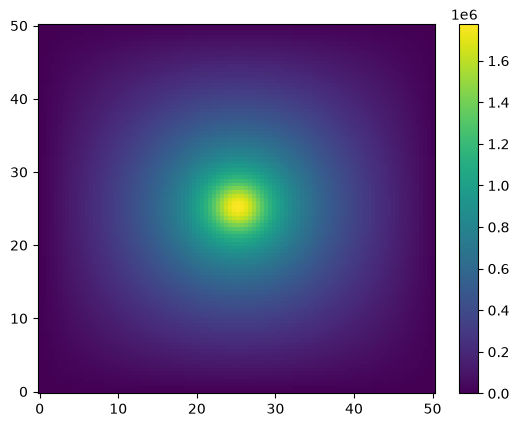

In [31]:
pressure_array = data_reader_s(f'uniformK1/p.out_0.data', step_size=0.5, size_x=LENGTH, size_y=TOTAL_TIME)
P_tensor = torch.tensor(pressure_array.copy(), device=device)
P_function = make_fun(x_lin, y_lin, P_tensor)
plotly(x_plot, y_plot, P_function(x_plot, y_plot))

Epoch: 1000 - Loss: 1.900e-01; total runtime: 2.715467929840088 (forward: 0.7721788883209229 grad: 1.4333717823028564 opt: 0.35906004905700684); time per epoch: 0.002715467929840088;


/tmp/ipykernel_53314/3959948770.py:52: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  print(f"Epoch: {epoch + 1} - Loss: {float(loss):.3e}; total runtime: {time_total} (forward: {time_total_forward} grad: {time_total_backward} opt: {time_total_optimization}); time per epoch: {time_total / (epoch + 1)};")


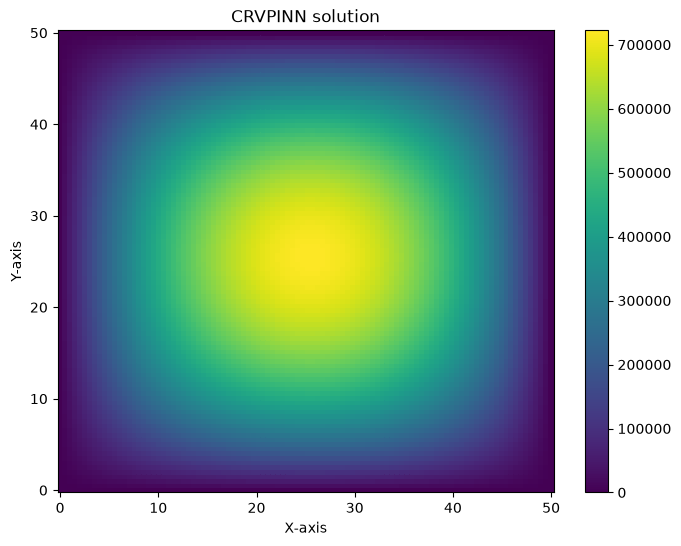

Epoch: 2000 - Loss: 1.667e-01; total runtime: 6.85697078704834 (forward: 1.9135158061981201 grad: 3.7410614490509033 opt: 0.8520212173461914); time per epoch: 0.00342848539352417;


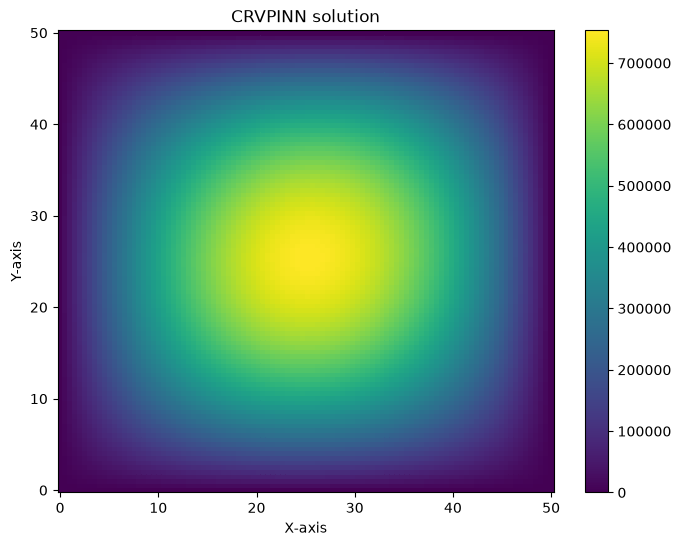

Epoch: 3000 - Loss: 7.124e-02; total runtime: 9.371636390686035 (forward: 2.622687816619873 grad: 5.095474481582642 opt: 1.156459093093872); time per epoch: 0.003123878796895345;


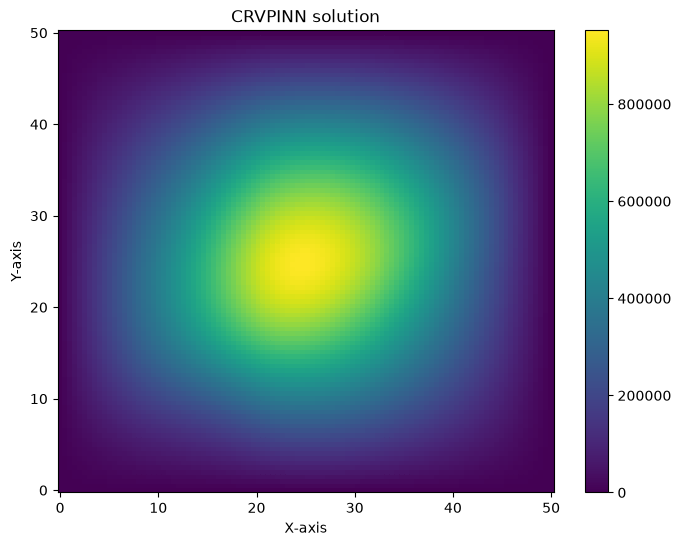

Epoch: 4000 - Loss: 2.471e-02; total runtime: 11.021875858306885 (forward: 3.0889129638671875 grad: 5.985804796218872 opt: 1.3451581001281738); time per epoch: 0.002755468964576721;


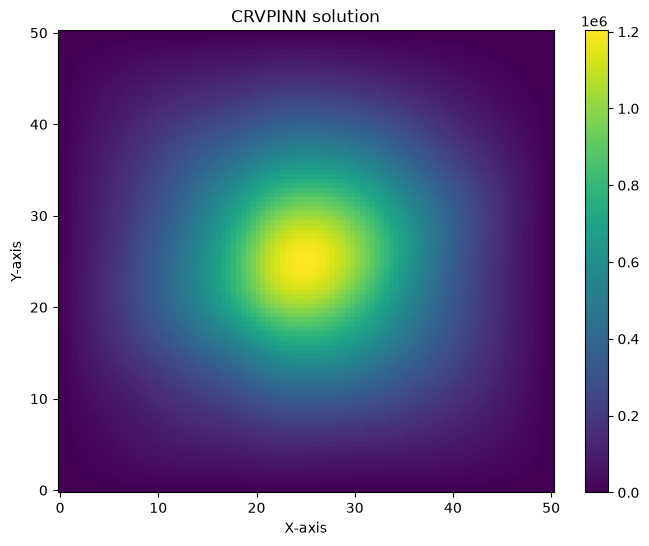

Epoch: 5000 - Loss: 1.228e-02; total runtime: 14.541821956634521 (forward: 4.092371225357056 grad: 7.8911333084106445 opt: 1.780285358428955); time per epoch: 0.002908364391326904;


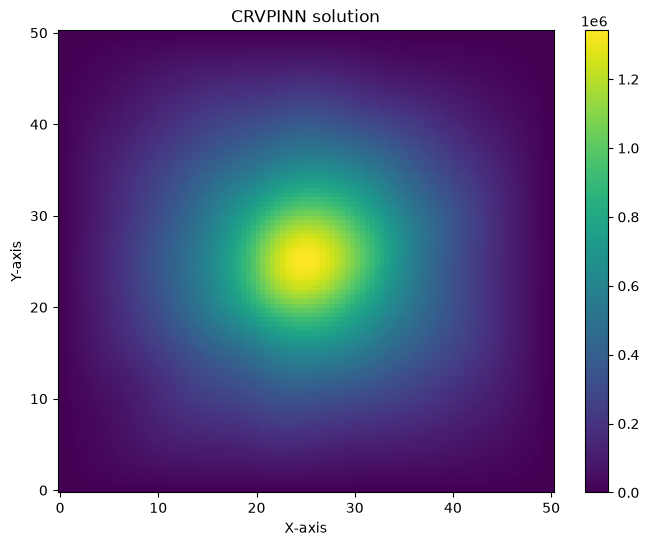

Epoch: 6000 - Loss: 4.849e-03; total runtime: 17.776826858520508 (forward: 4.994593620300293 grad: 9.669075965881348 opt: 2.1703691482543945); time per epoch: 0.0029628044764200847;


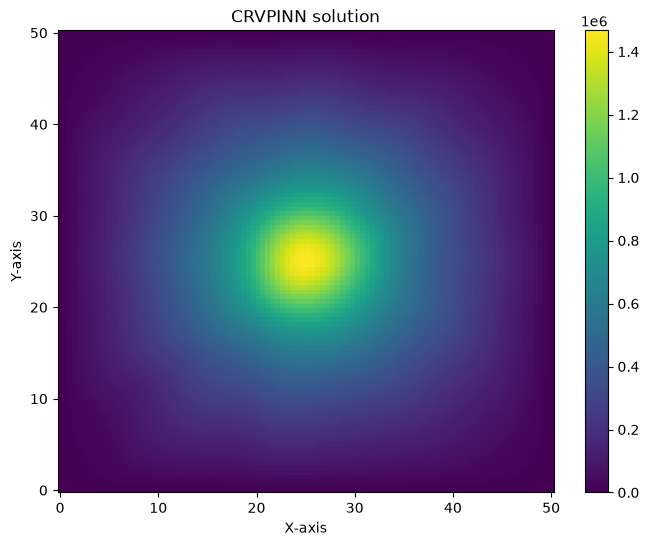

Epoch: 7000 - Loss: 2.057e-03; total runtime: 20.827064037322998 (forward: 5.853796005249023 grad: 11.337823629379272 opt: 2.5380547046661377); time per epoch: 0.002975294862474714;


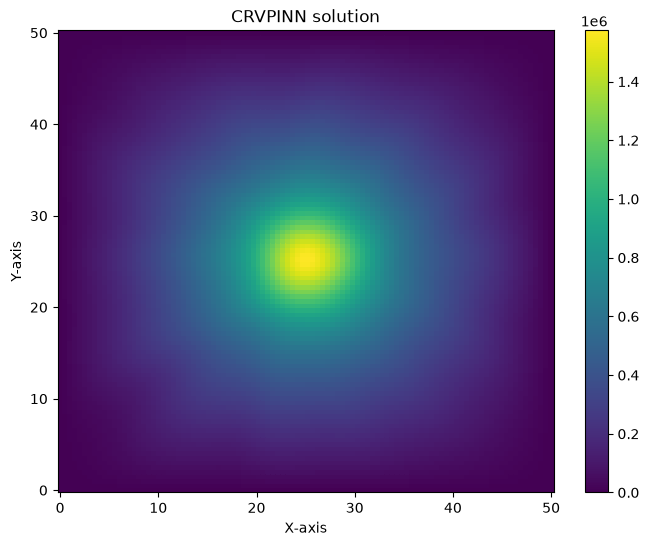

Epoch: 8000 - Loss: 1.207e-03; total runtime: 22.484721422195435 (forward: 6.324098110198975 grad: 12.23420238494873 opt: 2.729909658432007); time per epoch: 0.0028105901777744293;


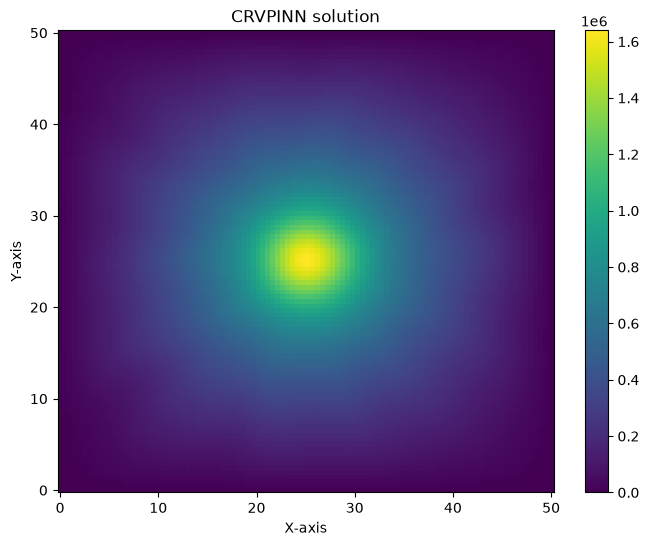

Epoch: 9000 - Loss: 8.345e-04; total runtime: 26.233848094940186 (forward: 7.40391206741333 grad: 14.251052379608154 opt: 3.192096471786499); time per epoch: 0.0029148720105489096;


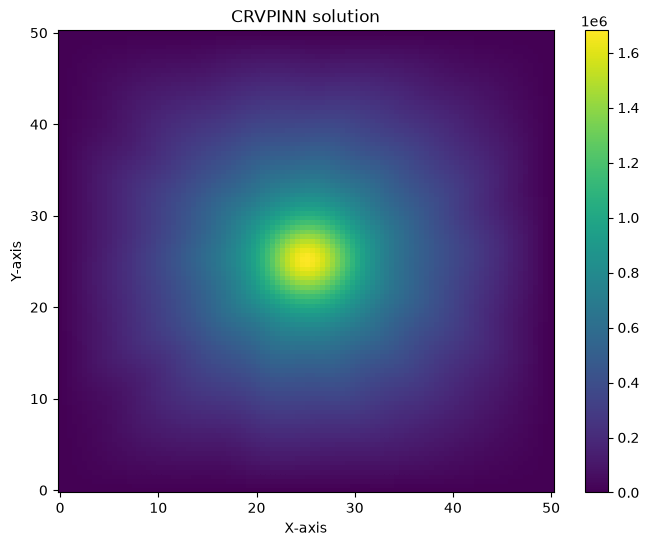

Epoch: 10000 - Loss: 6.478e-04; total runtime: 28.52281904220581 (forward: 8.047804117202759 grad: 15.493309497833252 opt: 3.4687671661376953); time per epoch: 0.002852281904220581;


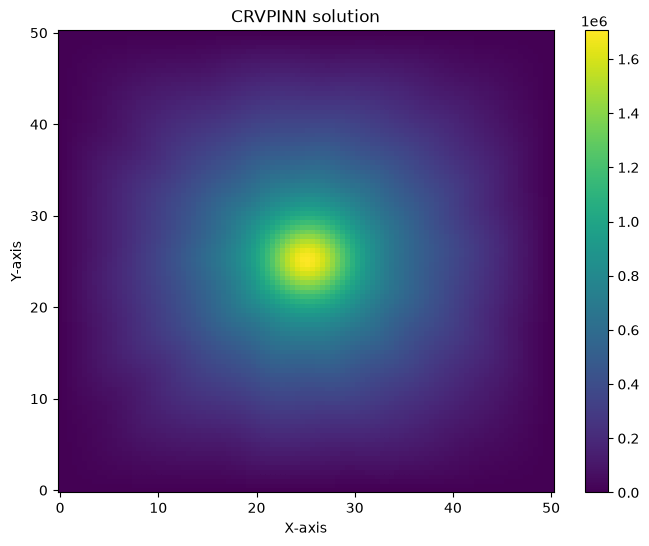

Training time : 31.591506


In [32]:
pinn = None
pinn = PINN(LAYERS, NEURONS_PER_LAYER, pinning=True, act=nn.Tanh()).to(device)

# train the PINN
time_train0 = time.time()

loss_fn = partial(compute_loss, x=x, t=t, w_physics=0, w_data=0.1)
pinn_trained, loss_values = train_model(pinn, 
            x, t, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=EPOCHS)
time_train1 = time.time()

print(f'Training time : %f'%(time_train1 - time_train0))

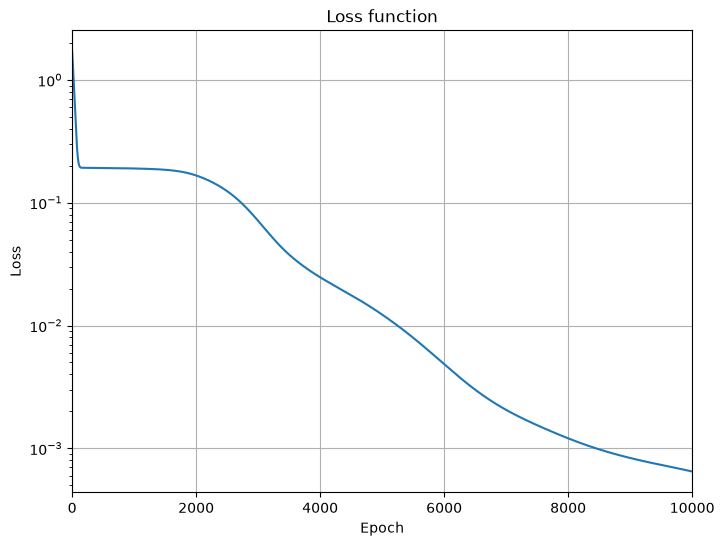

In [33]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
ax.plot(loss_values)
plt.grid(True)

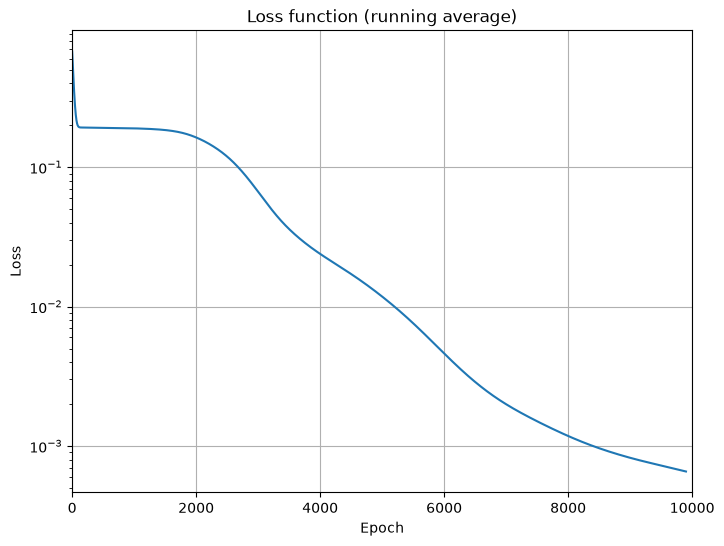

In [34]:
average_loss = running_average(loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
ax.plot(average_loss)
plt.grid(True)

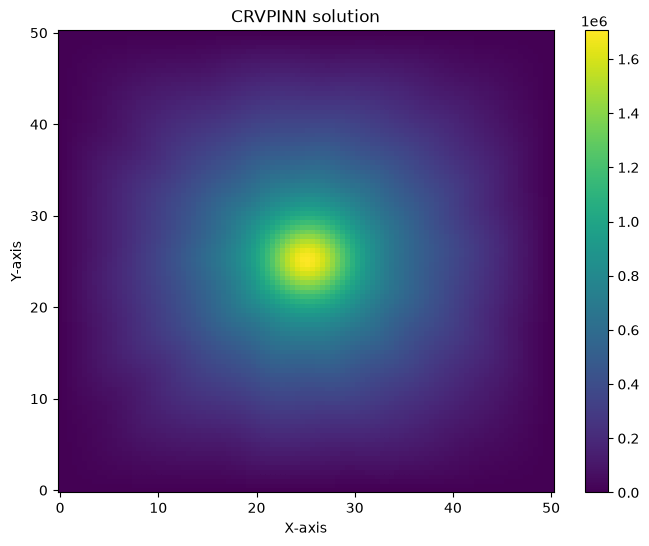

In [35]:
z_0 = f(pinn.to(device), x, t)
color = plot_color(z_0.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)

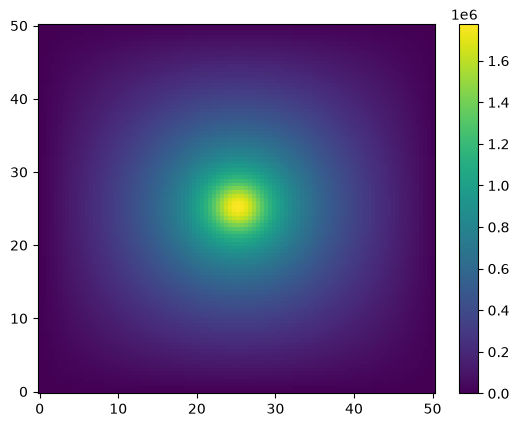

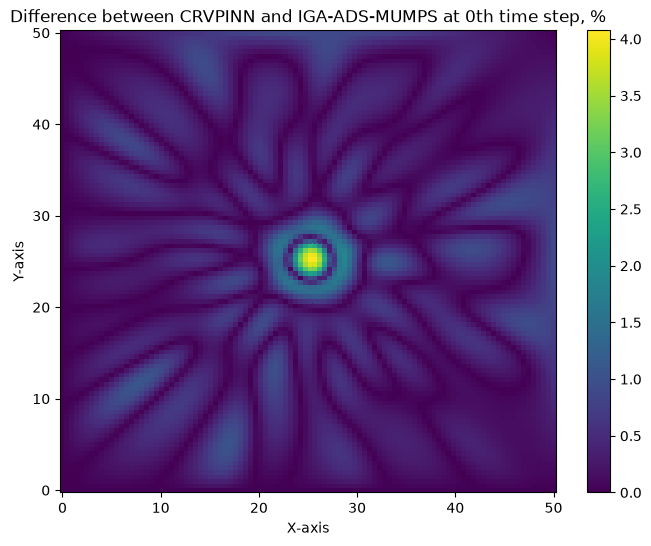

In [36]:
compare_with_iga(z_0, it_simulation=0, folder='uniformK1') #, err_bounds=(0, 5.5))

Starting simulation iteration 1/20


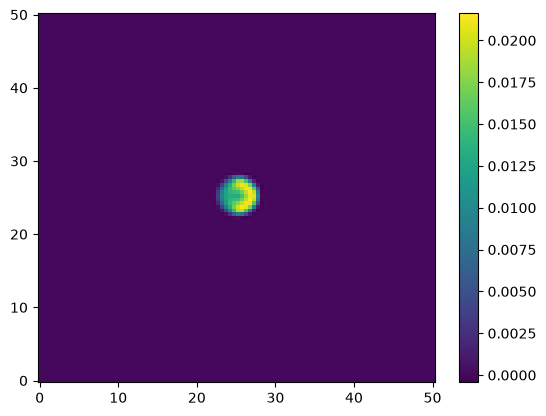

Epoch: 100 - Loss: 2.129e-03; total runtime: 2.0008397102355957 (forward: 0.6595396995544434 grad: 1.0184812545776367 opt: 0.05503511428833008); time per epoch: 0.020008397102355958;


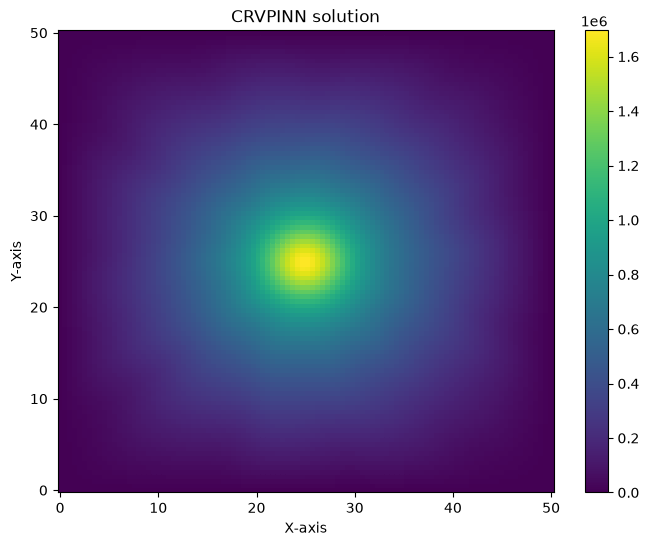

Training time : 2.263582
Starting simulation iteration 2/20


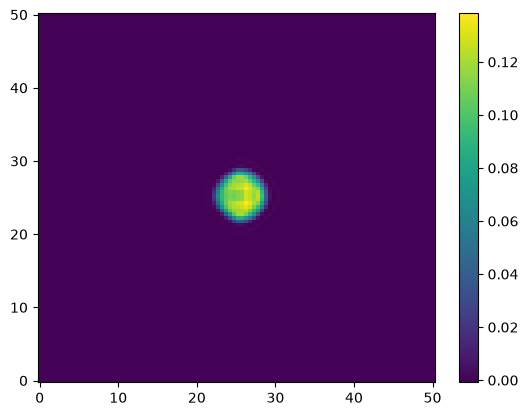

Epoch: 100 - Loss: 1.441e-03; total runtime: 1.570164442062378 (forward: 0.4791371822357178 grad: 0.7797534465789795 opt: 0.03703880310058594); time per epoch: 0.01570164442062378;


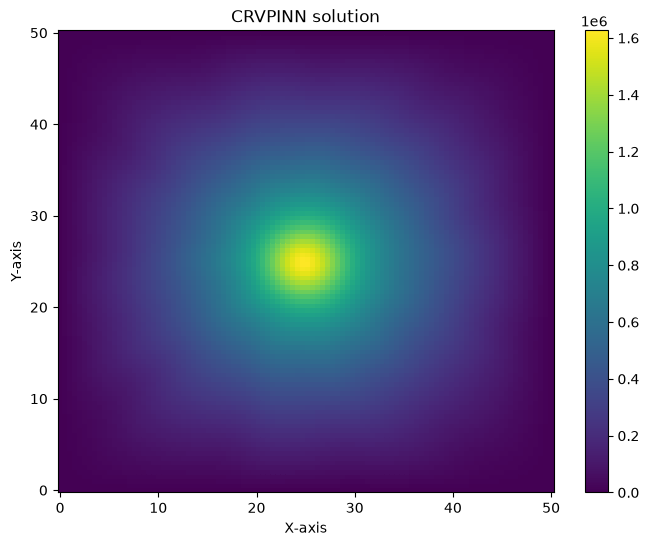

Training time : 1.998748
Starting simulation iteration 3/20


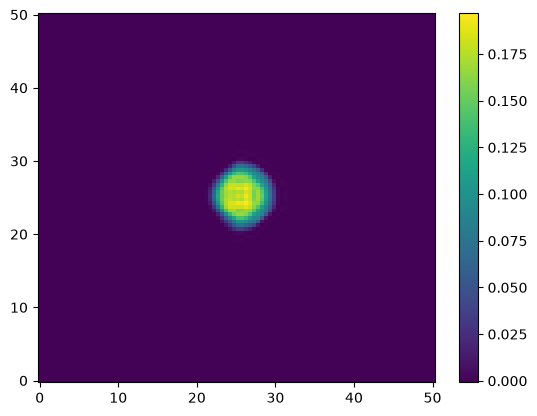

Epoch: 100 - Loss: 2.351e-03; total runtime: 1.554652214050293 (forward: 0.46837544441223145 grad: 0.7750802040100098 opt: 0.0353243350982666); time per epoch: 0.015546522140502929;


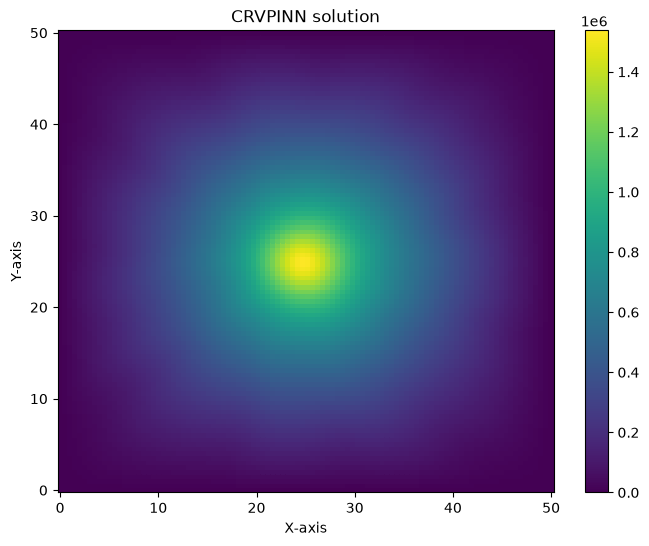

Training time : 2.003189
Starting simulation iteration 4/20


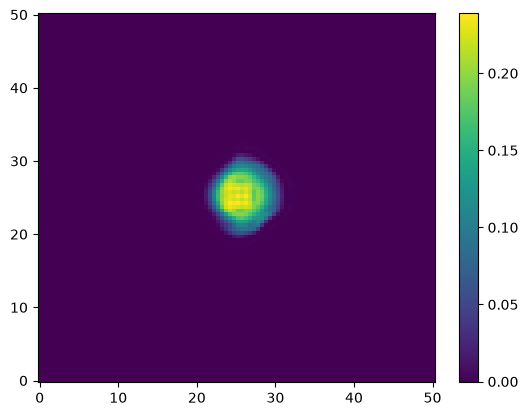

Epoch: 100 - Loss: 2.542e-03; total runtime: 1.7518532276153564 (forward: 0.550246000289917 grad: 0.8884396553039551 opt: 0.04770827293395996); time per epoch: 0.017518532276153565;


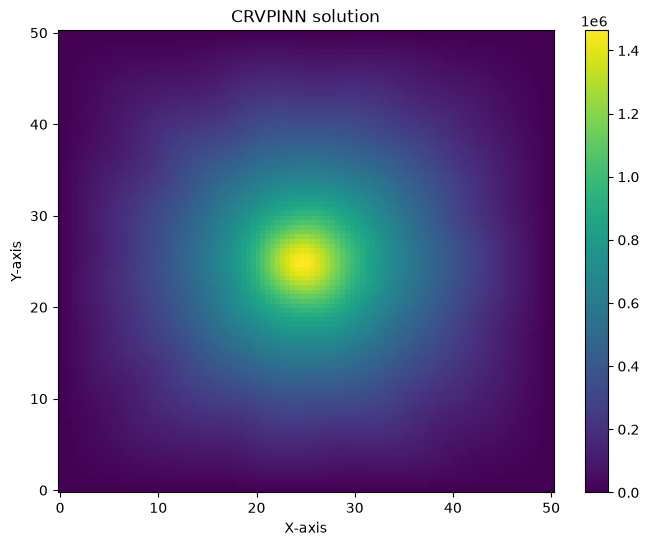

Training time : 2.166885
Starting simulation iteration 5/20


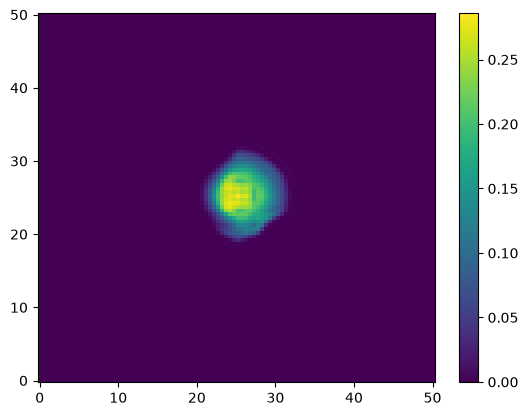

Epoch: 100 - Loss: 2.354e-03; total runtime: 2.940934658050537 (forward: 1.031325101852417 grad: 1.603895664215088 opt: 0.07370495796203613); time per epoch: 0.029409346580505372;


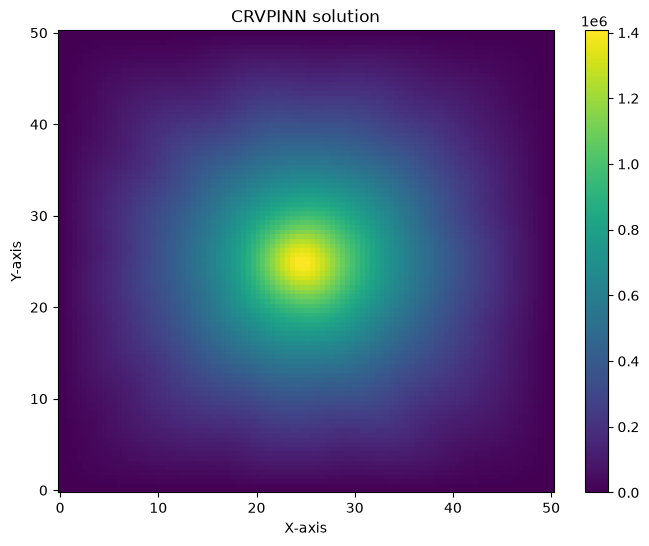

Training time : 3.116989
Starting simulation iteration 6/20


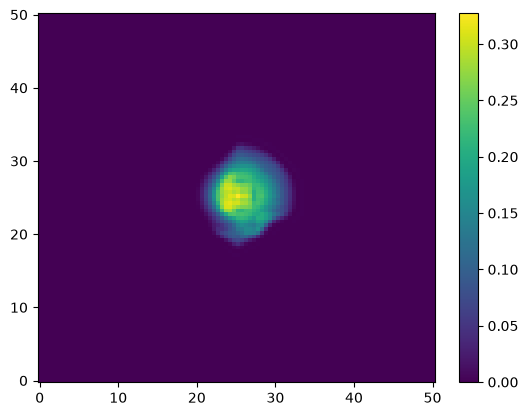

Epoch: 100 - Loss: 2.151e-03; total runtime: 1.722001075744629 (forward: 0.5286431312561035 grad: 0.8789477348327637 opt: 0.039896488189697266); time per epoch: 0.01722001075744629;


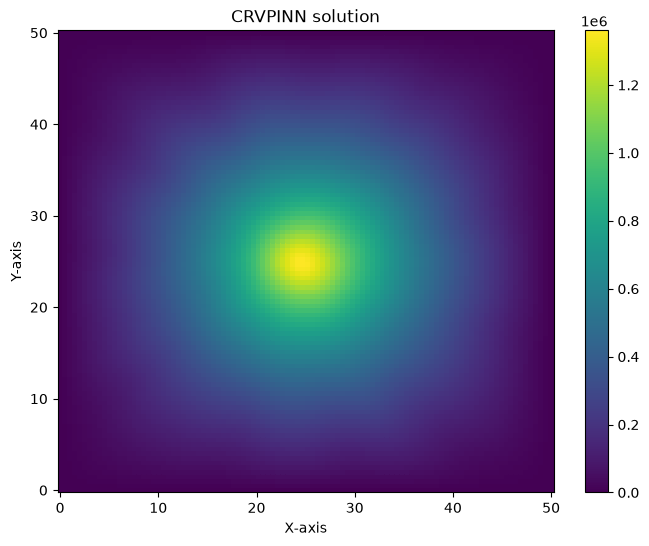

Training time : 2.121746
Starting simulation iteration 7/20


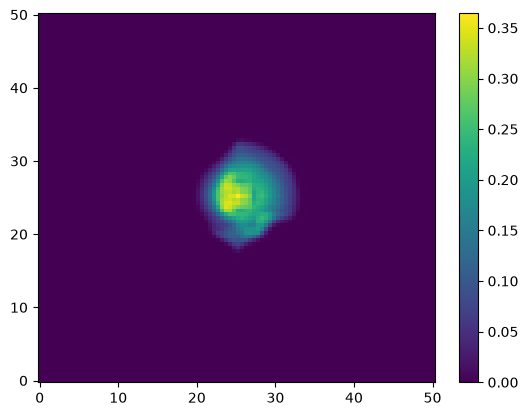

Epoch: 100 - Loss: 2.028e-03; total runtime: 1.6132102012634277 (forward: 0.4860713481903076 grad: 0.8127779960632324 opt: 0.03939223289489746); time per epoch: 0.016132102012634278;


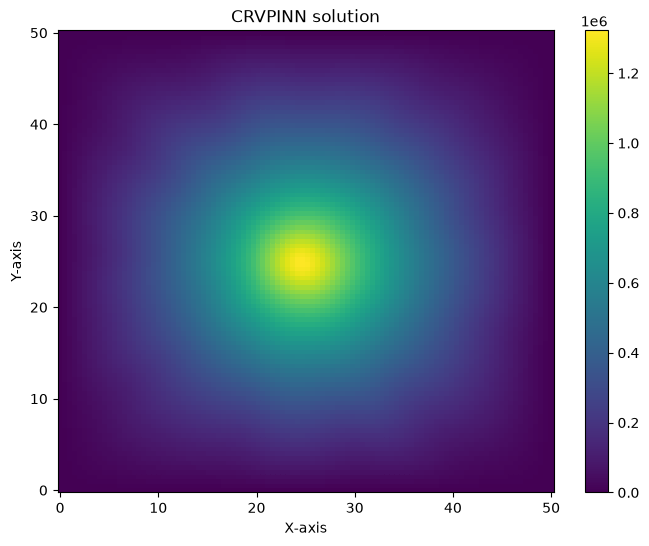

Training time : 2.005496
Starting simulation iteration 8/20


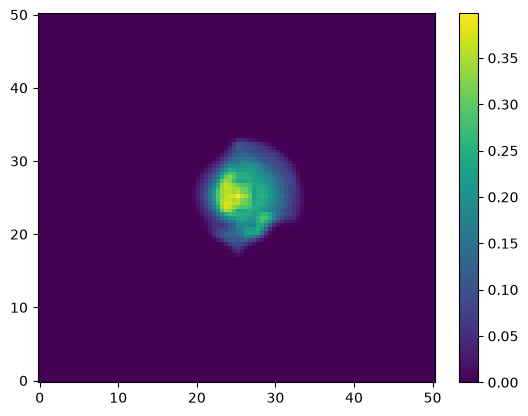

Epoch: 100 - Loss: 1.987e-03; total runtime: 1.5224449634552002 (forward: 0.45528435707092285 grad: 0.754493236541748 opt: 0.035105228424072266); time per epoch: 0.015224449634552002;


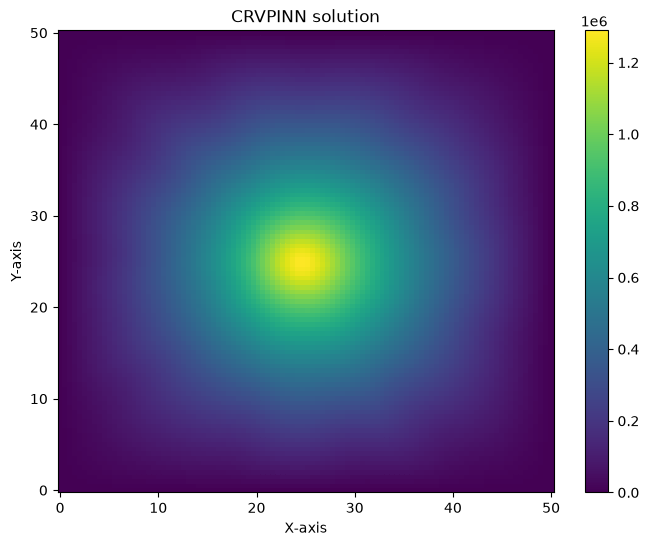

Training time : 1.985358
Starting simulation iteration 9/20


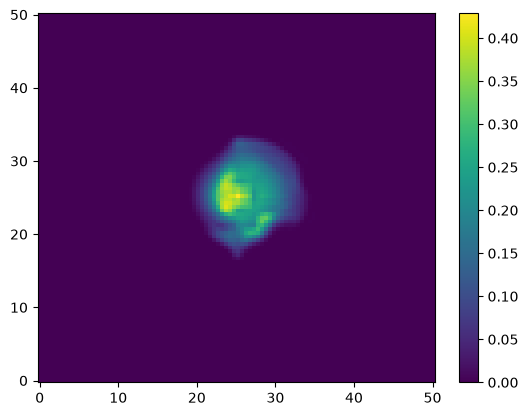

Epoch: 100 - Loss: 1.981e-03; total runtime: 2.1825220584869385 (forward: 0.7176122665405273 grad: 1.1535120010375977 opt: 0.05934739112854004); time per epoch: 0.021825220584869385;


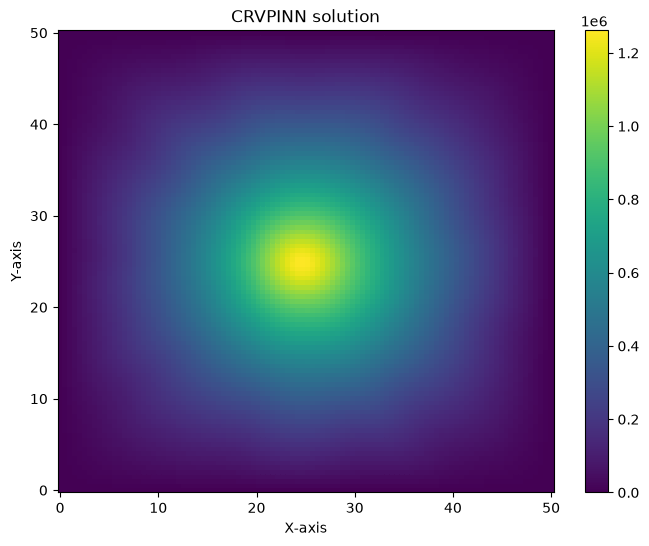

Training time : 2.549235
Starting simulation iteration 10/20


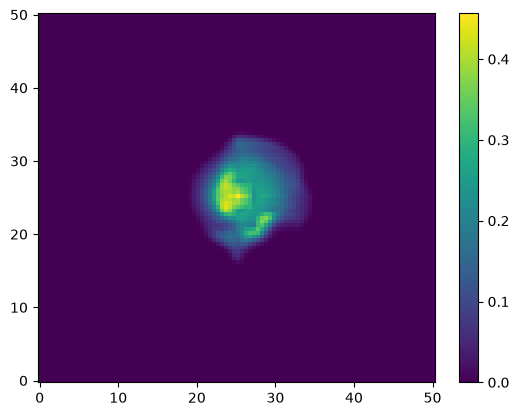

Epoch: 100 - Loss: 1.973e-03; total runtime: 1.760382890701294 (forward: 0.541250467300415 grad: 0.8962335586547852 opt: 0.042717695236206055); time per epoch: 0.01760382890701294;


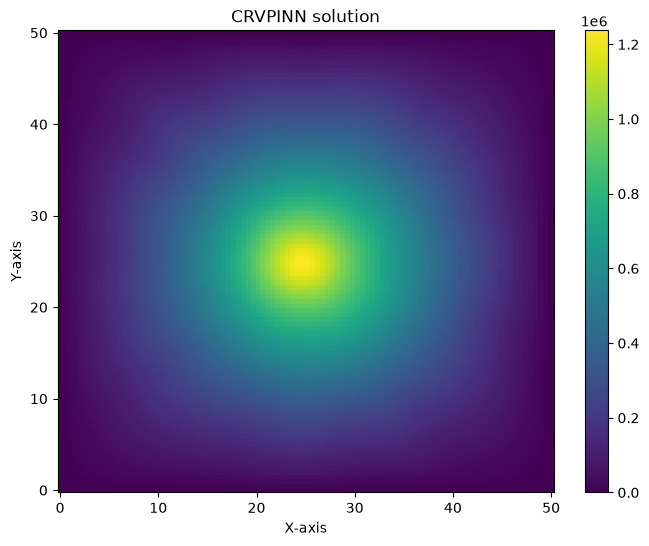

Training time : 2.336906
Starting simulation iteration 11/20


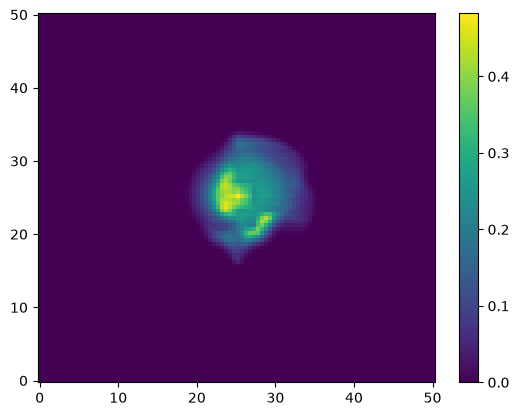

Epoch: 100 - Loss: 1.957e-03; total runtime: 3.1188344955444336 (forward: 1.0863158702850342 grad: 1.731247901916504 opt: 0.07716989517211914); time per epoch: 0.031188344955444335;


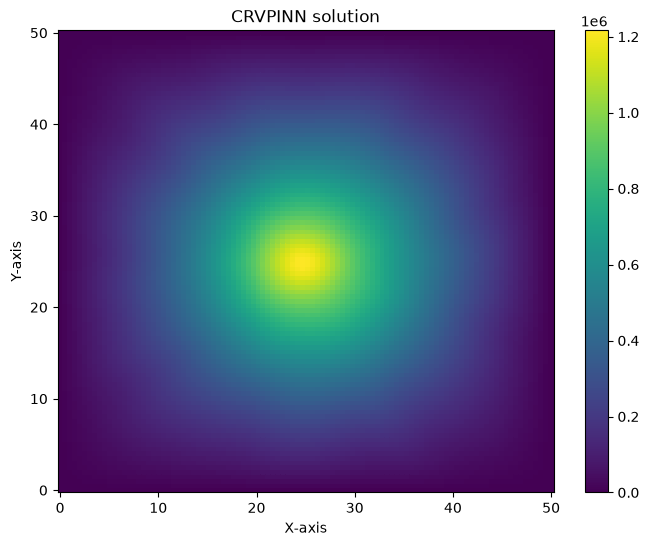

Training time : 3.400206
Starting simulation iteration 12/20


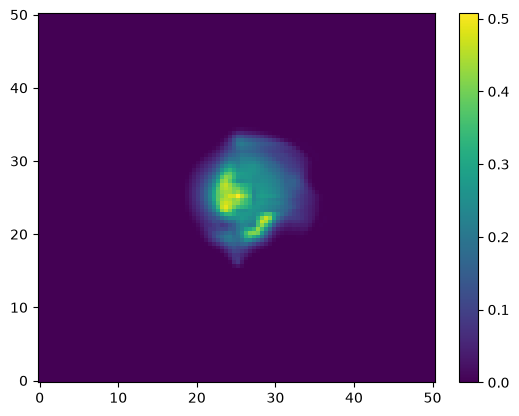

Epoch: 100 - Loss: 1.932e-03; total runtime: 2.972053050994873 (forward: 1.0145392417907715 grad: 1.641845464706421 opt: 0.06873846054077148); time per epoch: 0.02972053050994873;


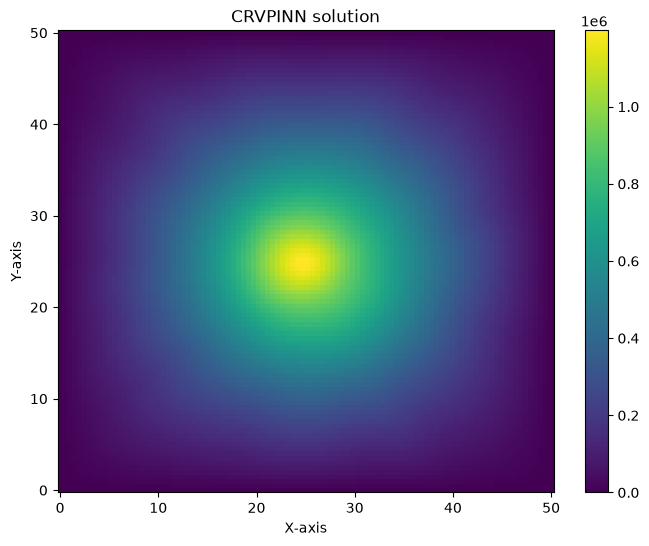

Training time : 3.105067
Starting simulation iteration 13/20


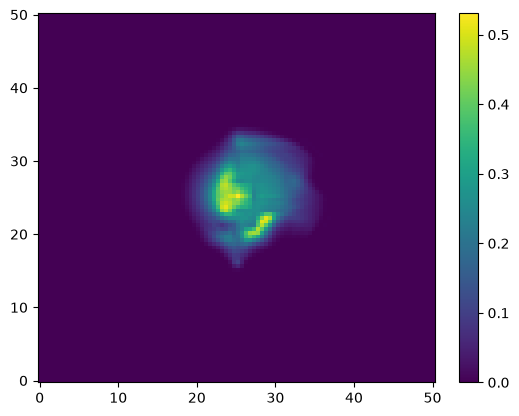

Epoch: 100 - Loss: 1.893e-03; total runtime: 3.1812424659729004 (forward: 1.1125574111938477 grad: 1.768228530883789 opt: 0.07732701301574707); time per epoch: 0.031812424659729006;


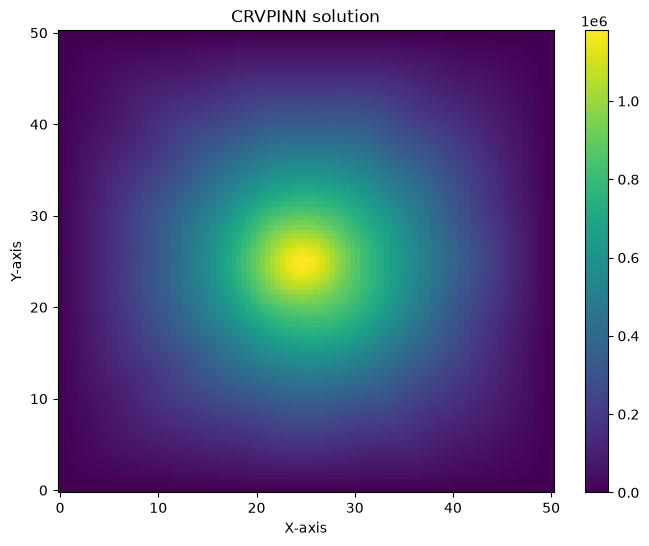

Training time : 3.385427
Starting simulation iteration 14/20


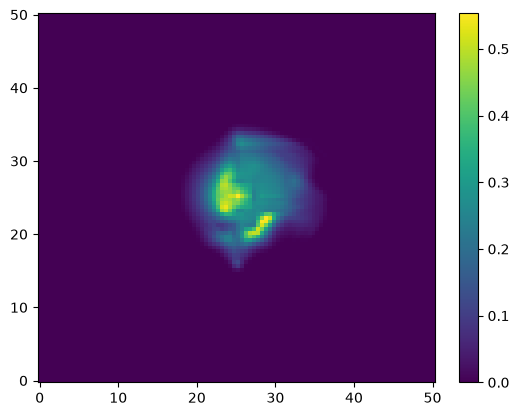

Epoch: 100 - Loss: 1.841e-03; total runtime: 3.1880452632904053 (forward: 1.105872631072998 grad: 1.766369104385376 opt: 0.07163000106811523); time per epoch: 0.03188045263290405;


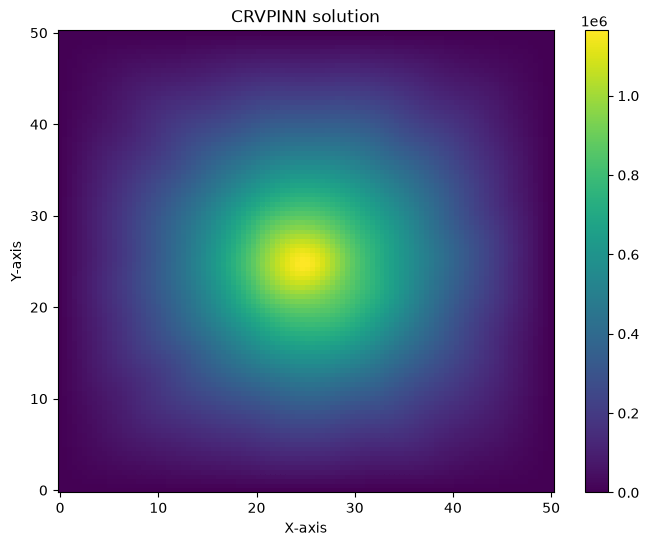

Training time : 3.323236
Starting simulation iteration 15/20


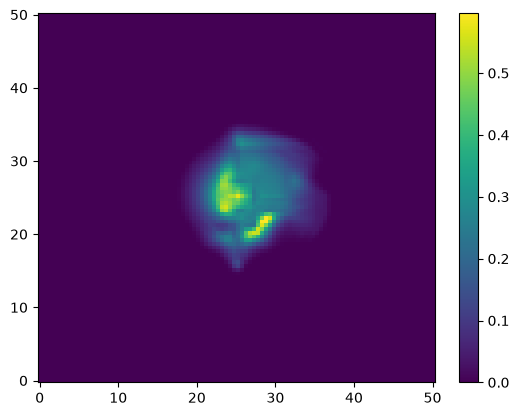

Epoch: 100 - Loss: 1.786e-03; total runtime: 2.1614127159118652 (forward: 0.7139413356781006 grad: 1.136049509048462 opt: 0.05509185791015625); time per epoch: 0.021614127159118653;


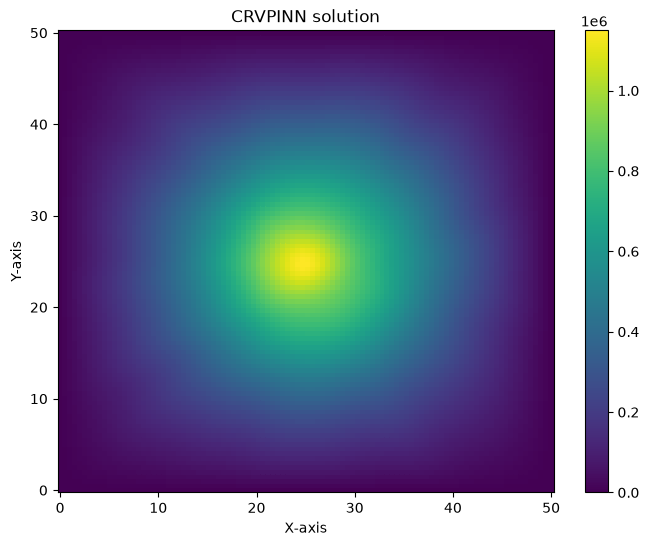

Training time : 2.572912
Starting simulation iteration 16/20


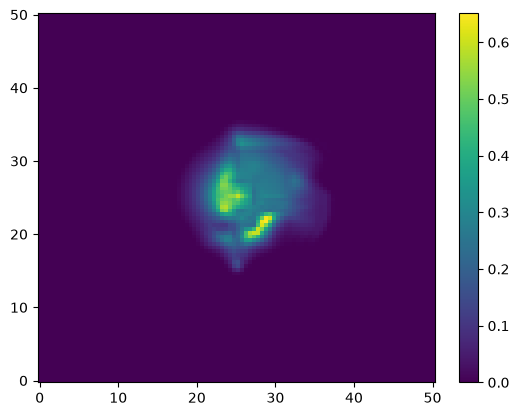

Epoch: 100 - Loss: 1.734e-03; total runtime: 3.8958053588867188 (forward: 1.3753068447113037 grad: 2.208778142929077 opt: 0.08659076690673828); time per epoch: 0.03895805358886719;


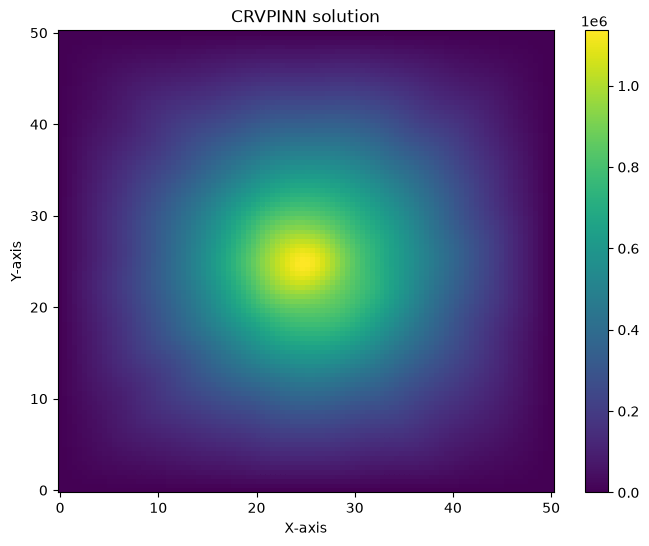

Training time : 4.357300
Starting simulation iteration 17/20


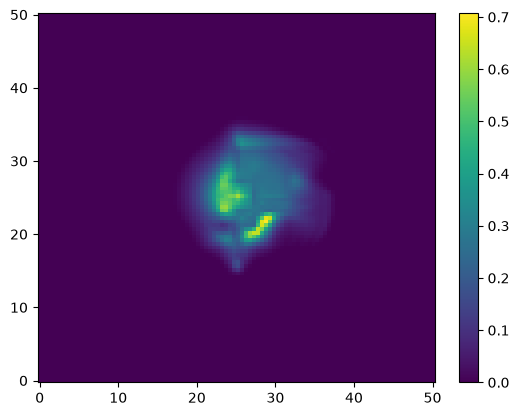

Epoch: 100 - Loss: 1.690e-03; total runtime: 3.5562655925750732 (forward: 1.2613637447357178 grad: 1.980431079864502 opt: 0.08179473876953125); time per epoch: 0.03556265592575073;


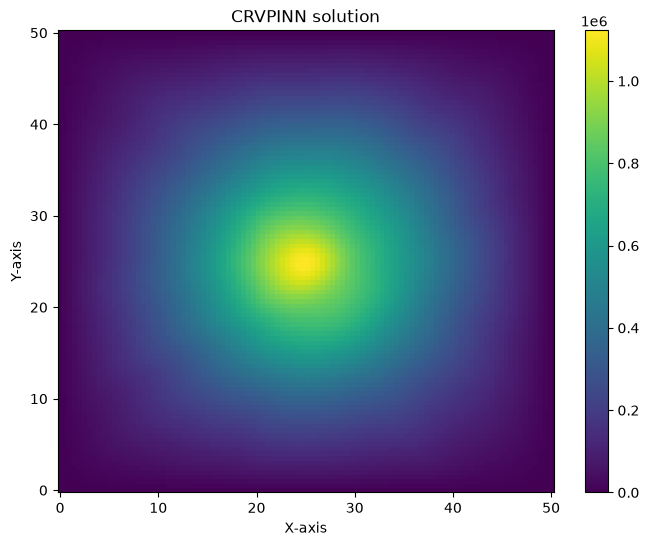

Training time : 3.740054
Starting simulation iteration 18/20


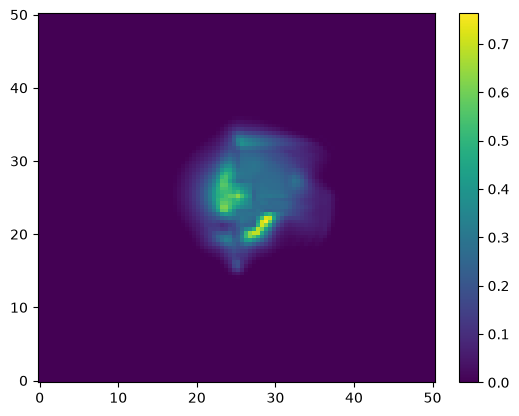

Epoch: 100 - Loss: 1.659e-03; total runtime: 1.9408245086669922 (forward: 0.6216385364532471 grad: 0.9979190826416016 opt: 0.055292606353759766); time per epoch: 0.019408245086669922;


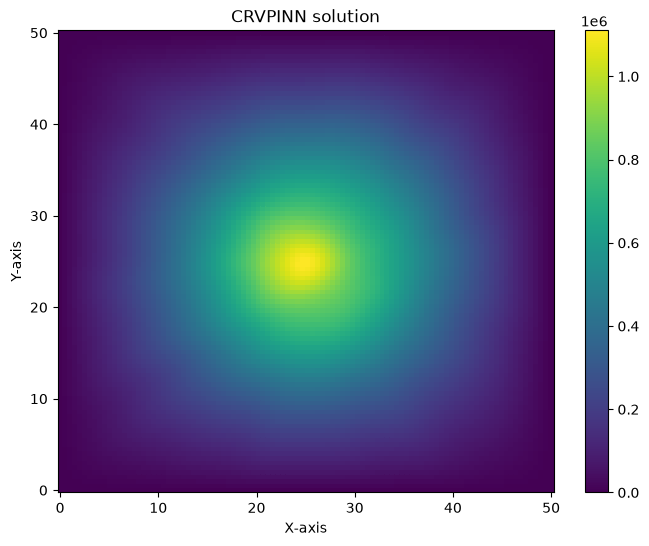

Training time : 2.204090
Starting simulation iteration 19/20


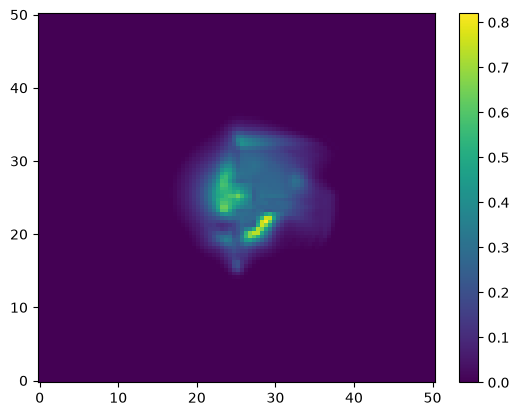

Epoch: 100 - Loss: 1.643e-03; total runtime: 1.7757530212402344 (forward: 0.544105052947998 grad: 0.9123823642730713 opt: 0.04598069190979004); time per epoch: 0.017757530212402343;


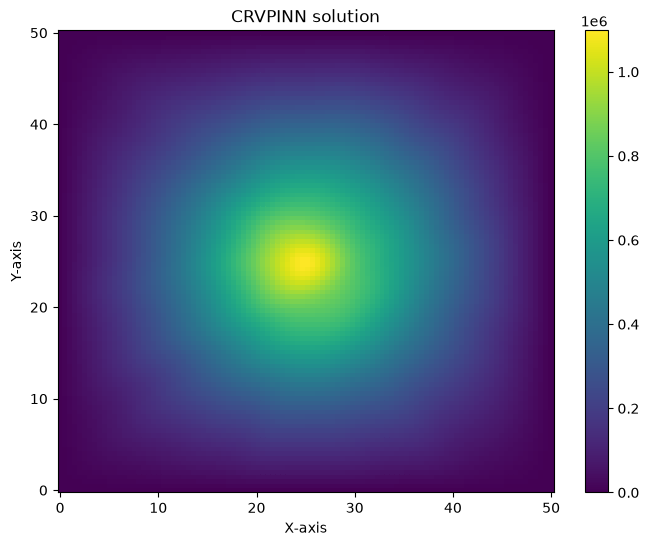

Training time : 2.083894
Starting simulation iteration 20/20


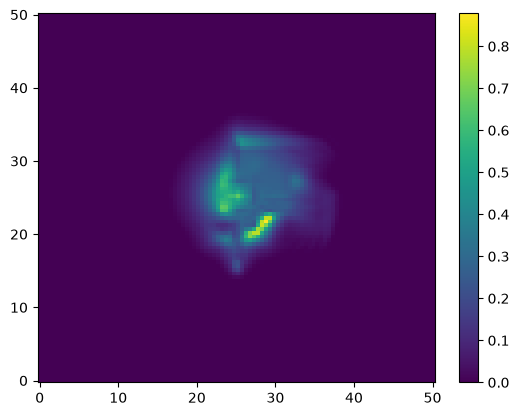

Epoch: 100 - Loss: 1.641e-03; total runtime: 1.8064656257629395 (forward: 0.5610435009002686 grad: 0.9245386123657227 opt: 0.05234074592590332); time per epoch: 0.018064656257629395;


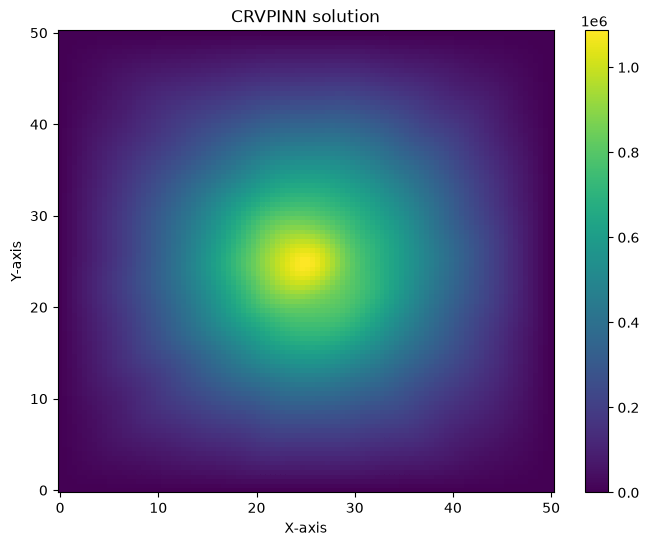

Training time : 2.102855
Total training time for 20 iterations: 52.823176


In [37]:
pinn_trained, loss_values_cont = continue_training(pinn, x, t, n_it_simulation=20, folder_name='uniformK1')

Text(0.5, 1.0, 'CRVPINN solution at 19th time step')

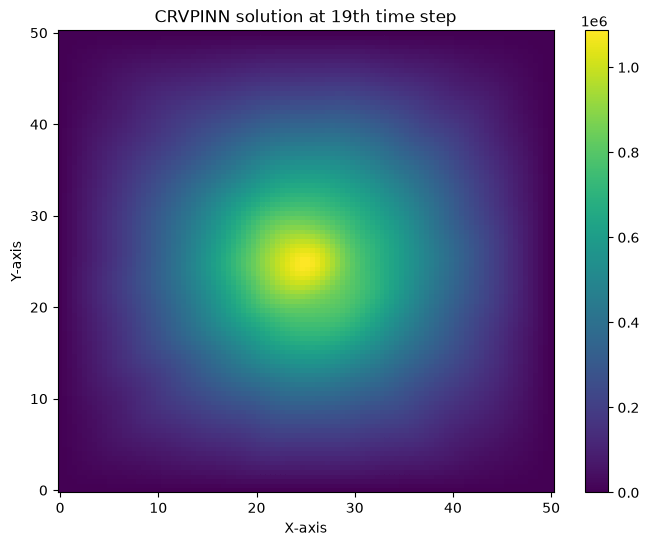

In [38]:
z_190 = f(pinn_trained.to(device), x, t)
color = plot_color(z_190.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)
plt.title('CRVPINN solution at 19th time step')

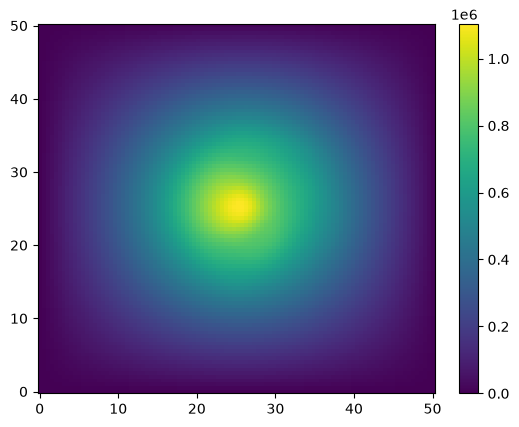

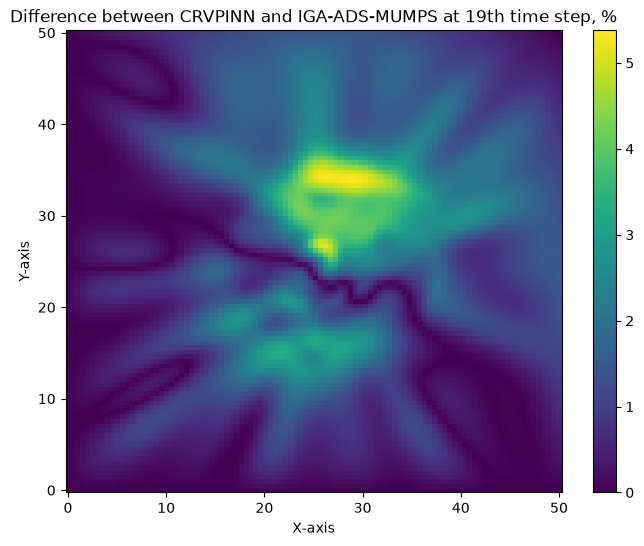

In [39]:
compare_with_iga(z_190, it_simulation=19, folder='uniformK1') #, err_bounds=(0,5.5))

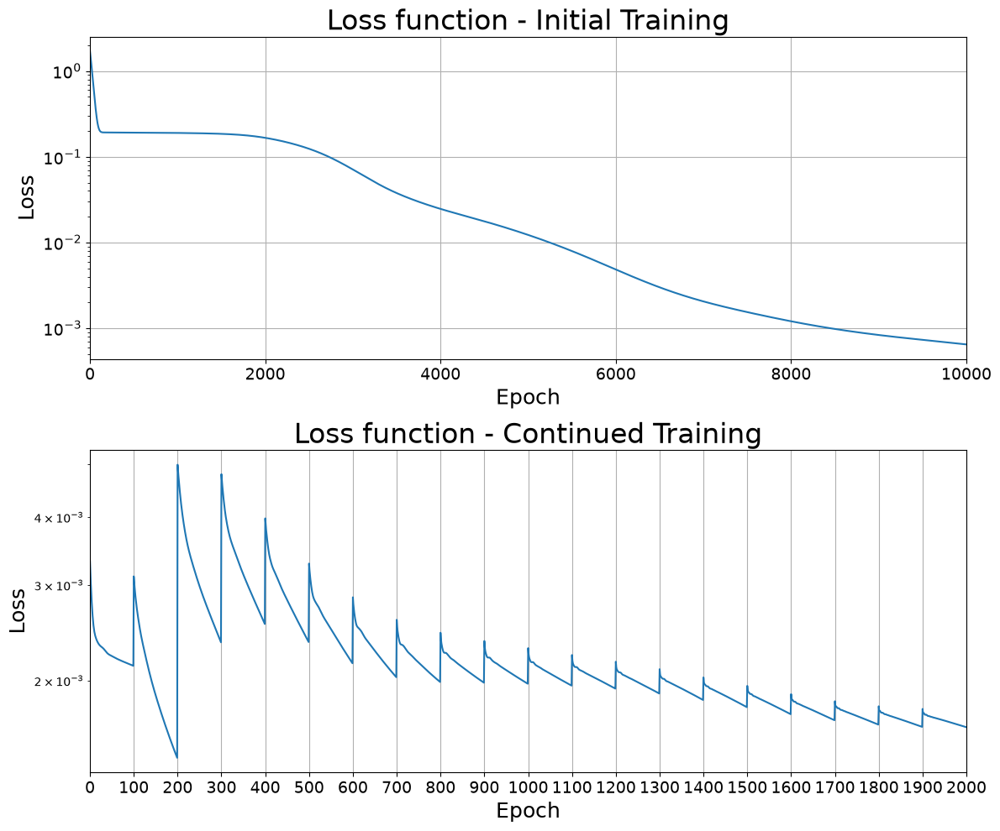

In [40]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.set_title("Loss function - Initial Training", fontsize = 24)
ax1.set_xlabel("Epoch", fontsize = 18)
ax1.set_ylabel("Loss", fontsize = 18)
ax1.set_yscale("log")
ax1.set_xlim(0, EPOCHS)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.plot(loss_values)
ax1.grid(True)

ax2.set_title("Loss function - Continued Training", fontsize = 24)
ax2.set_xlabel("Epoch", fontsize = 18)
ax2.set_ylabel("Loss", fontsize = 18)
ax2.set_yscale("log")
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_xlim(0, len(loss_values_cont))
ax2.set_xticks(np.arange(0, len(loss_values_cont)+1, step=100))
ax2.plot(loss_values_cont)
ax2.grid(True)

plt.tight_layout()


# PINN with uniform $K = 10^{-15} m^2$ (porosity map K2)

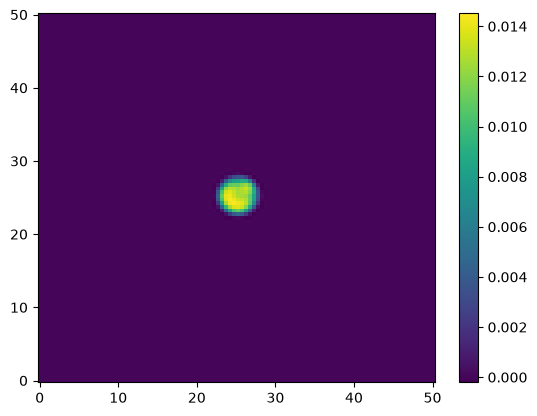

In [41]:
saturation_array = data_reader_s(f'uniformK2/s.out_0.data', step_size=0.5) 
Sg_tensor = torch.tensor(saturation_array.copy(), device=device, requires_grad=True)
global Sg_function
Sg_function = make_fun(x_lin, y_lin, Sg_tensor)
plotly(x_plot, y_plot, Sg_function(x_plot, y_plot))

In [42]:
pressure_array = data_reader_s('uniformK2/p.out_0.data', step_size=0.5, size_x=LENGTH, size_y=TOTAL_TIME)
P_tensor = torch.tensor(pressure_array.copy(), device=device)
P_function = make_fun(x_lin, y_lin, P_tensor)

Epoch: 1000 - Loss: 1.906e-01; total runtime: 4.325260400772095 (forward: 1.2271130084991455 grad: 2.359886407852173 opt: 0.5309441089630127); time per epoch: 0.004325260400772094;


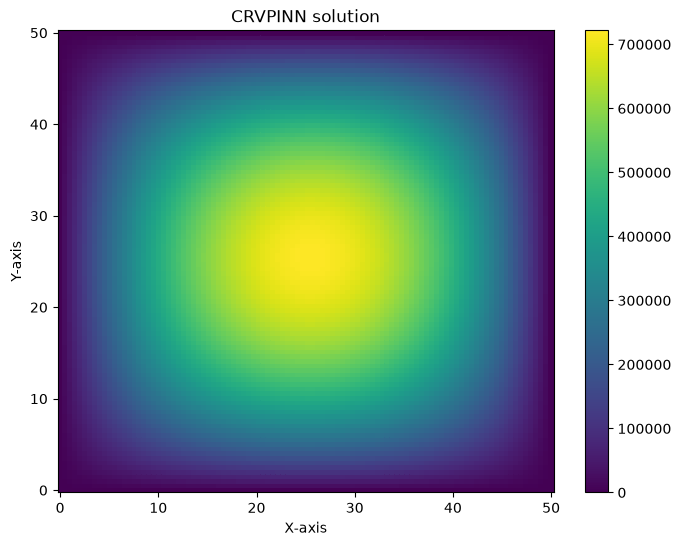

Epoch: 2000 - Loss: 1.692e-01; total runtime: 6.919996738433838 (forward: 1.9550607204437256 grad: 3.775402545928955 opt: 0.8368656635284424); time per epoch: 0.003459998369216919;


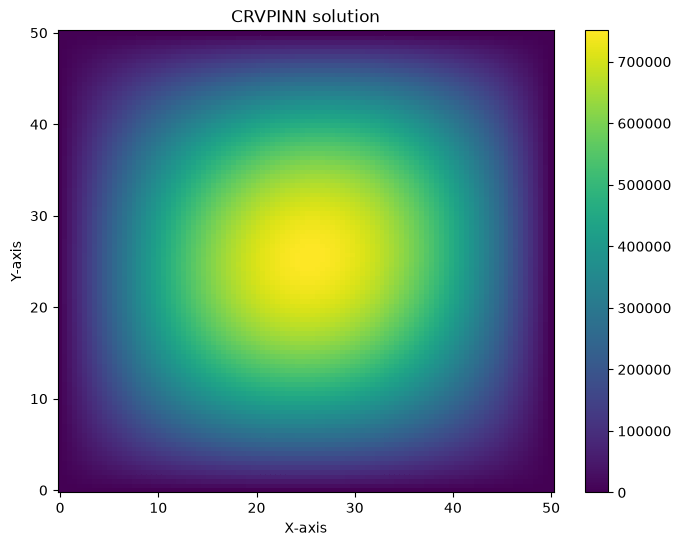

Epoch: 3000 - Loss: 8.261e-02; total runtime: 8.58359694480896 (forward: 2.423767566680908 grad: 4.67669939994812 opt: 1.025575876235962); time per epoch: 0.0028611989816029865;


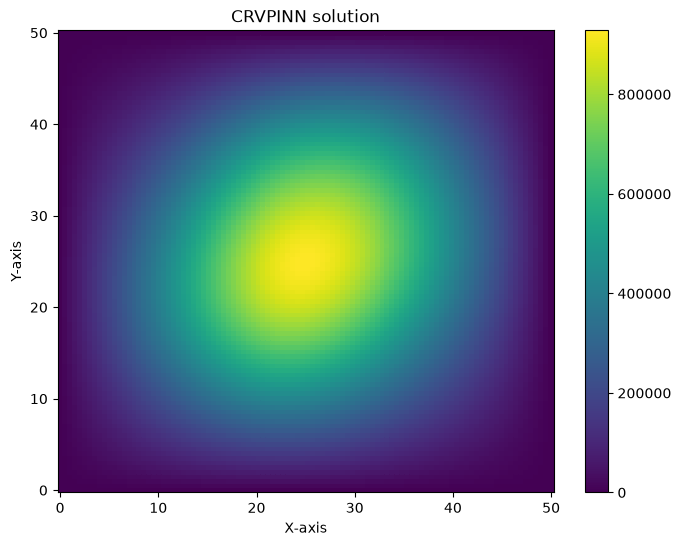

Epoch: 4000 - Loss: 2.903e-02; total runtime: 10.563859939575195 (forward: 2.982945203781128 grad: 5.753982067108154 opt: 1.2520580291748047); time per epoch: 0.002640964984893799;


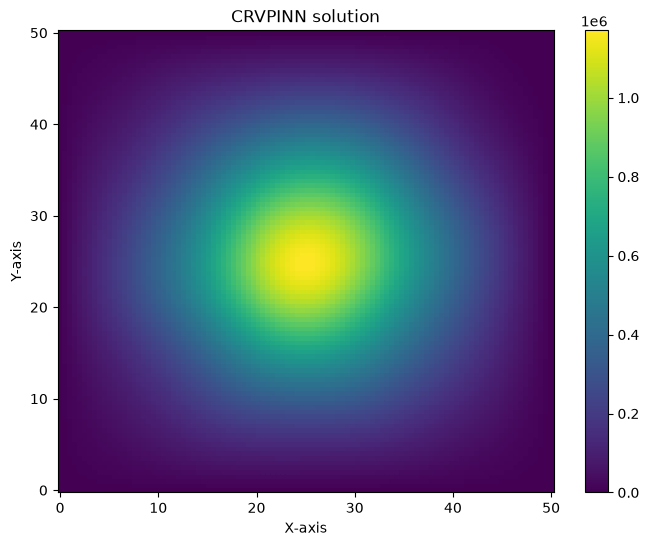

Epoch: 5000 - Loss: 1.449e-02; total runtime: 15.557496786117554 (forward: 4.374258518218994 grad: 8.507800340652466 opt: 1.864076852798462); time per epoch: 0.0031114993572235105;


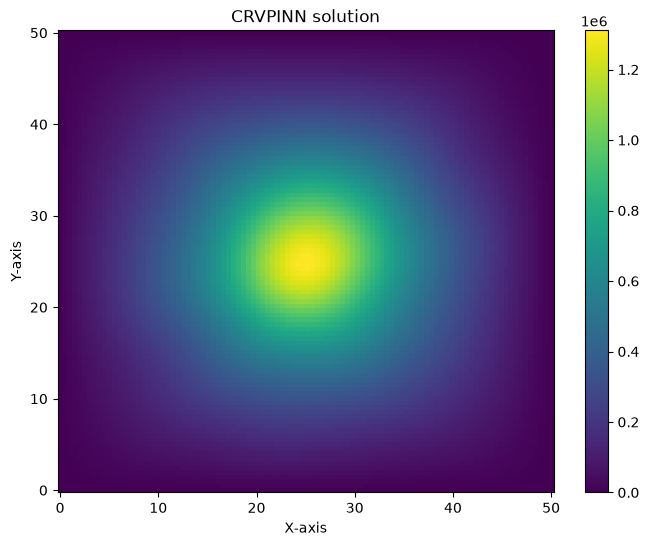

Epoch: 6000 - Loss: 5.670e-03; total runtime: 19.52767848968506 (forward: 5.488651752471924 grad: 10.68530011177063 opt: 2.347881317138672); time per epoch: 0.0032546130816141763;


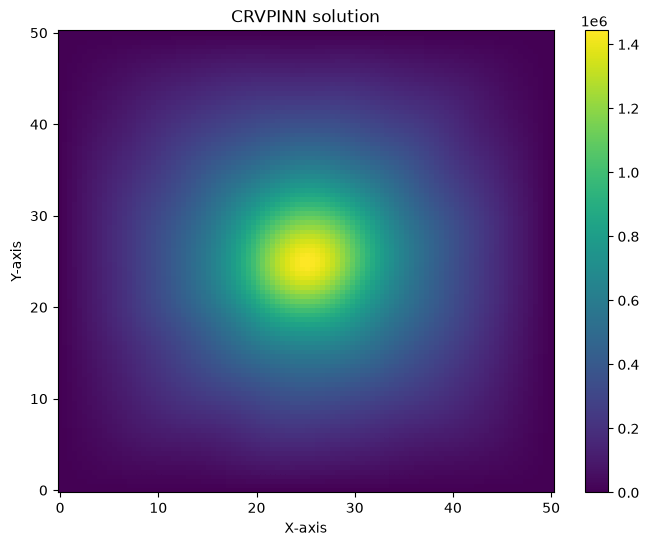

Epoch: 7000 - Loss: 2.287e-03; total runtime: 21.59948420524597 (forward: 6.073407411575317 grad: 11.818244457244873 opt: 2.584756374359131); time per epoch: 0.0030856406007494243;


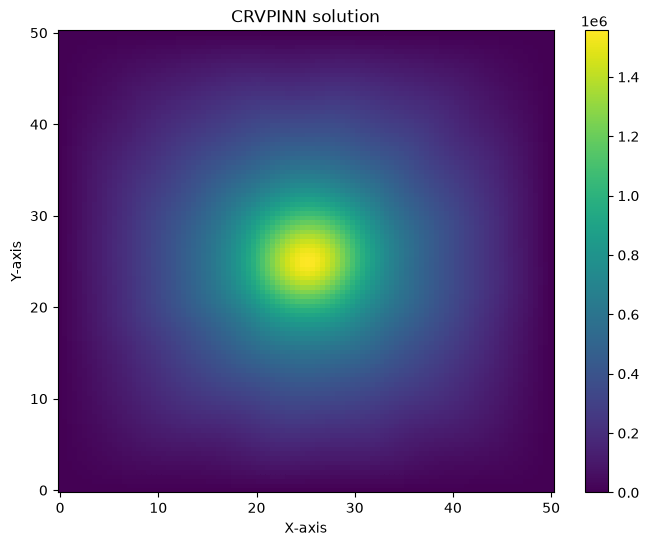

Epoch: 8000 - Loss: 1.229e-03; total runtime: 23.499038457870483 (forward: 6.613801717758179 grad: 12.85385537147522 opt: 2.798046827316284); time per epoch: 0.0029373798072338106;


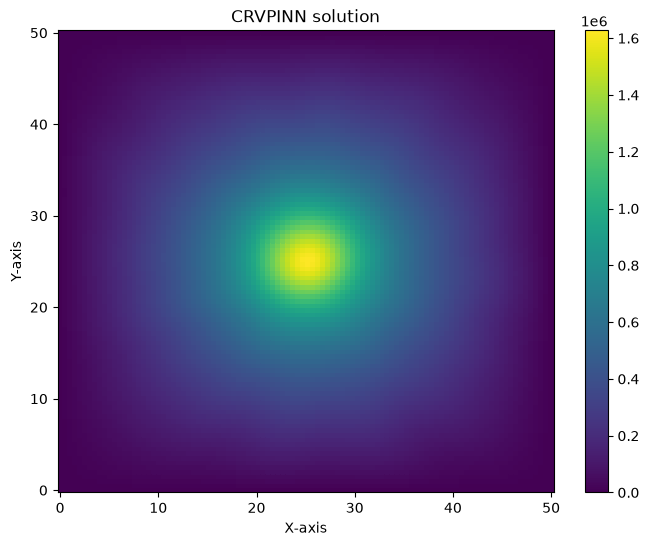

Epoch: 9000 - Loss: 7.067e-04; total runtime: 25.45914363861084 (forward: 7.171314716339111 grad: 13.920396566390991 opt: 3.0176496505737305); time per epoch: 0.0028287937376234268;


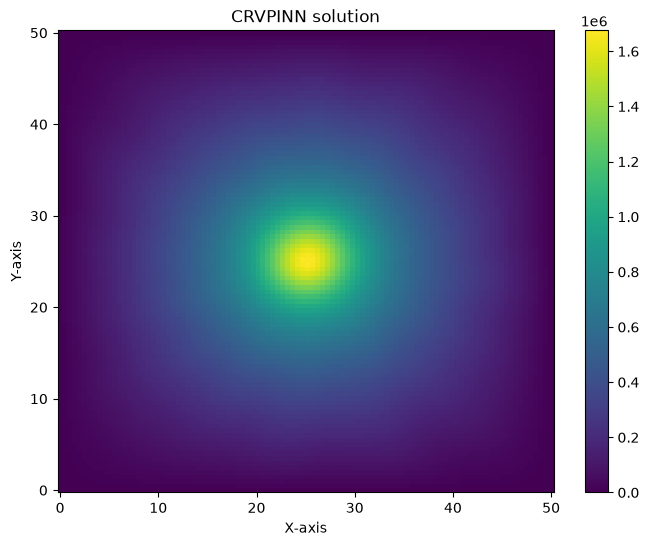

Epoch: 10000 - Loss: 4.658e-04; total runtime: 27.413368463516235 (forward: 7.724206447601318 grad: 14.995241403579712 opt: 3.237645387649536); time per epoch: 0.0027413368463516234;


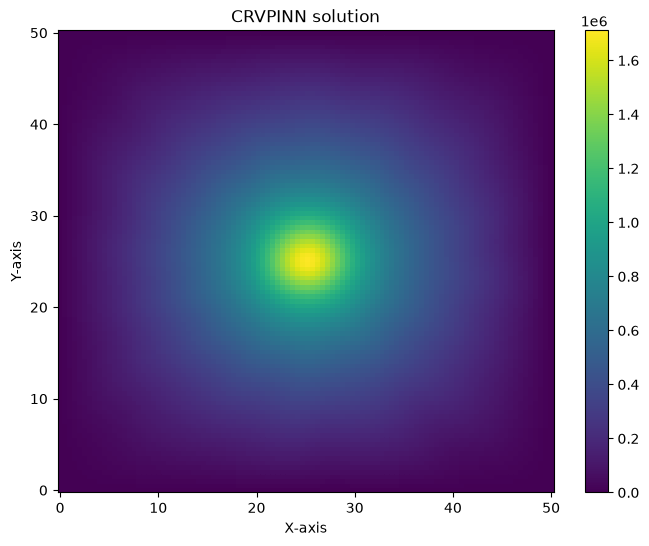

Training time : 29.501640


In [43]:
pinn = None
pinn = PINN(LAYERS, NEURONS_PER_LAYER, pinning=True, act=nn.Tanh()).to(device)

# train the PINN
time_train0 = time.time()

loss_fn = partial(compute_loss, x=x, t=t, w_physics=0, w_data=0.1)
pinn_trained, loss_values = train_model(pinn, 
            x, t, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=EPOCHS)
time_train1 = time.time()

print(f'Training time : %f'%(time_train1 - time_train0))

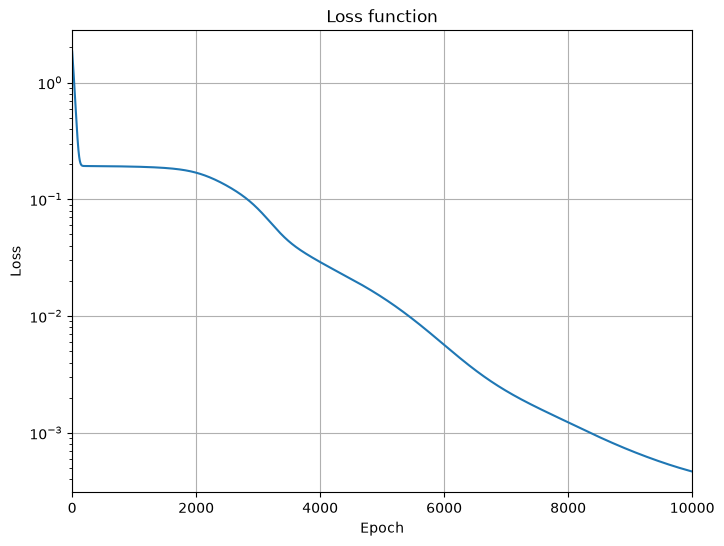

In [44]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
ax.plot(loss_values)
plt.grid(True)

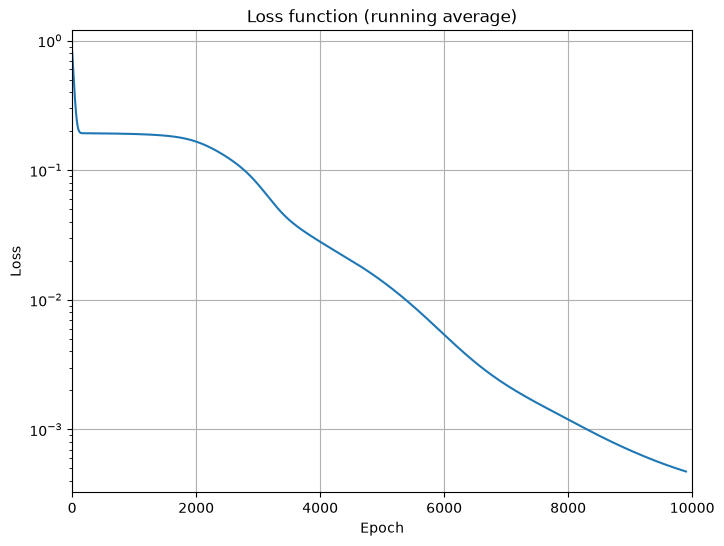

In [45]:
average_loss = running_average(loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
ax.plot(average_loss)
plt.grid(True)

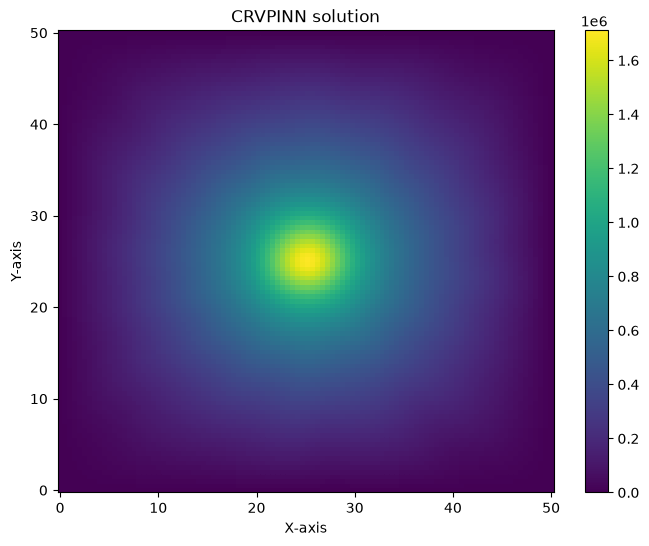

In [46]:
z_0 = f(pinn.to(device), x, t)
color = plot_color(z_0.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)

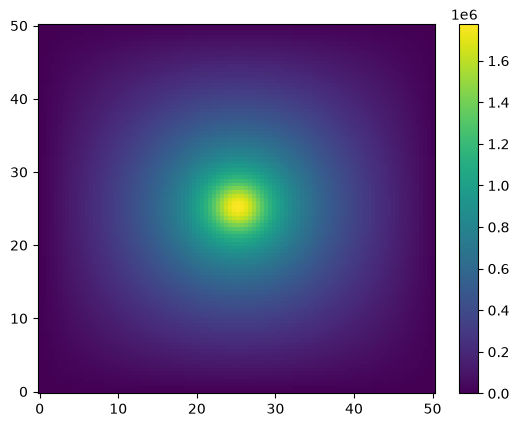

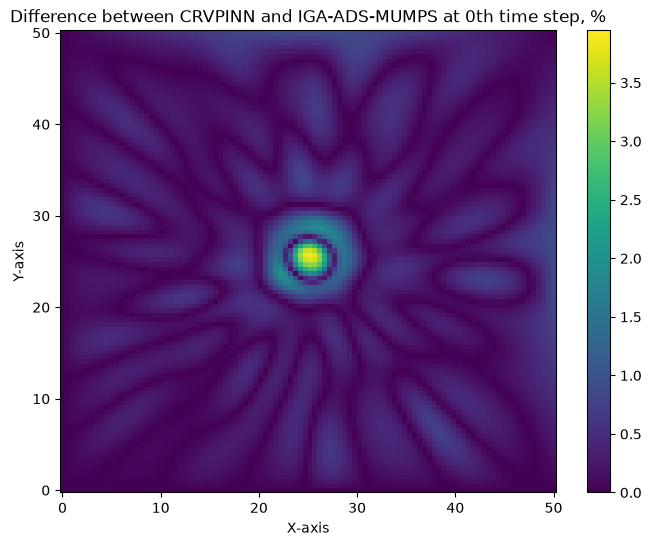

In [47]:
compare_with_iga(z_0, it_simulation=0, folder='uniformK2') #, err_bounds=(0, 6.5))

Starting simulation iteration 1/20


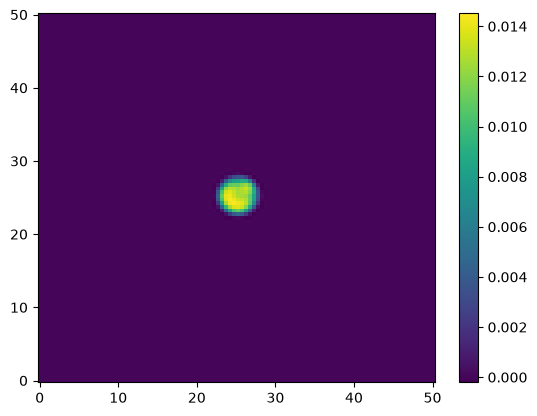

Epoch: 100 - Loss: 1.640e-03; total runtime: 1.6339609622955322 (forward: 0.4934260845184326 grad: 0.8144991397857666 opt: 0.04172682762145996); time per epoch: 0.01633960962295532;


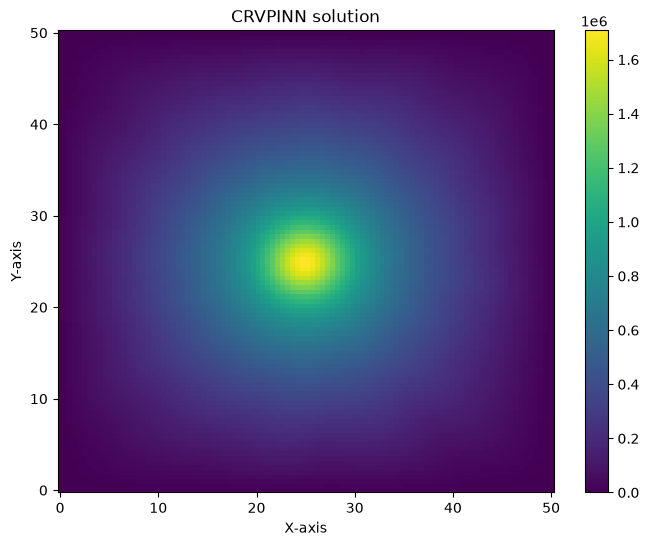

Training time : 2.047788
Starting simulation iteration 2/20


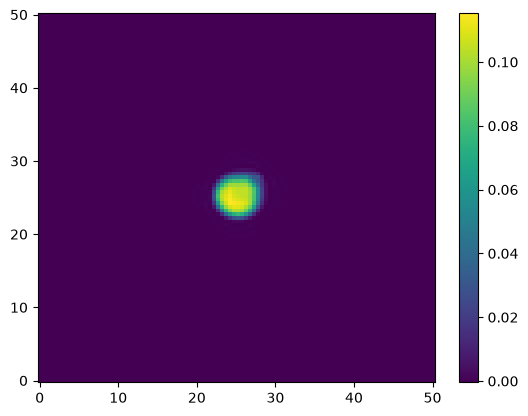

Epoch: 100 - Loss: 7.468e-04; total runtime: 1.5865819454193115 (forward: 0.4811716079711914 grad: 0.7908613681793213 opt: 0.03812098503112793); time per epoch: 0.015865819454193117;


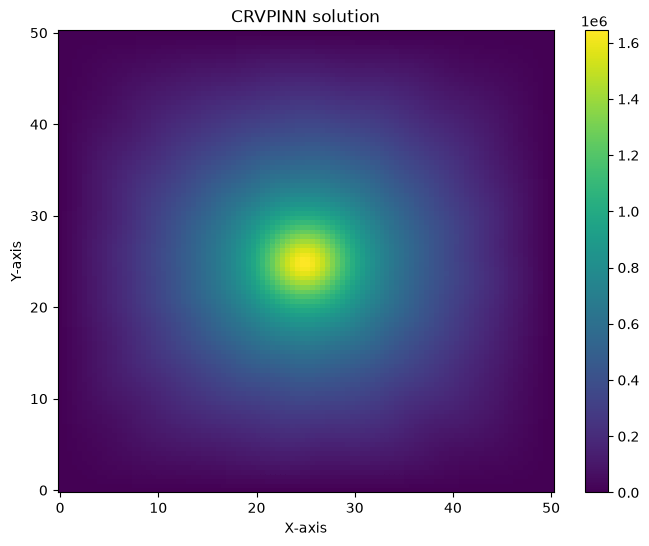

Training time : 2.204818
Starting simulation iteration 3/20


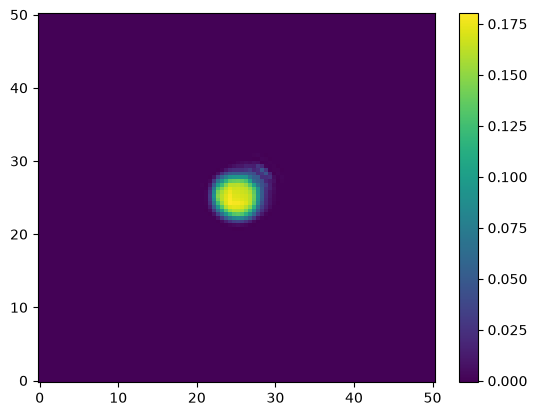

Epoch: 100 - Loss: 1.075e-03; total runtime: 1.8826148509979248 (forward: 0.5966746807098389 grad: 0.9472930431365967 opt: 0.05197763442993164); time per epoch: 0.018826148509979247;


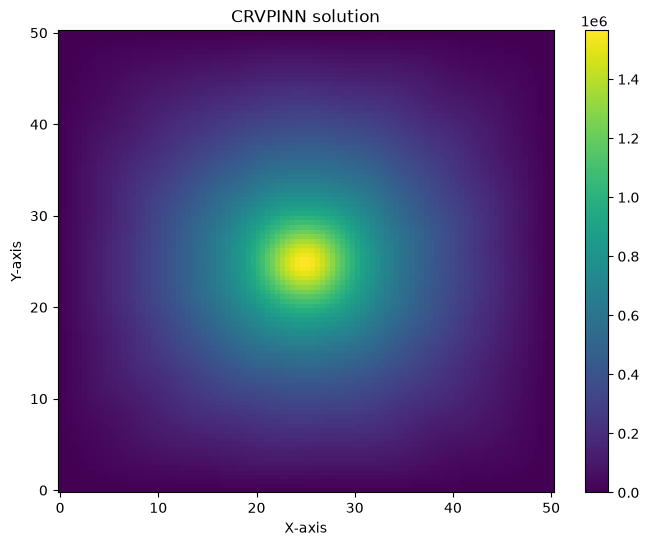

Training time : 2.335336
Starting simulation iteration 4/20


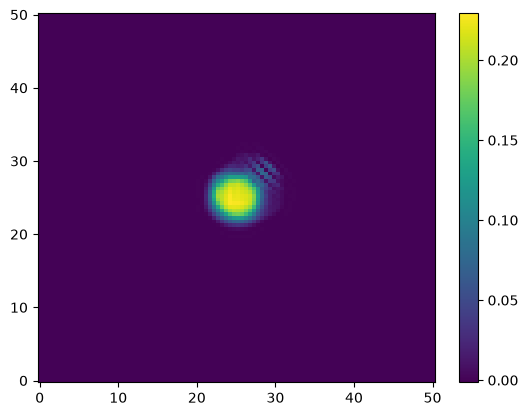

Epoch: 100 - Loss: 1.205e-03; total runtime: 2.445762872695923 (forward: 0.8043262958526611 grad: 1.3393030166625977 opt: 0.06003403663635254); time per epoch: 0.024457628726959228;


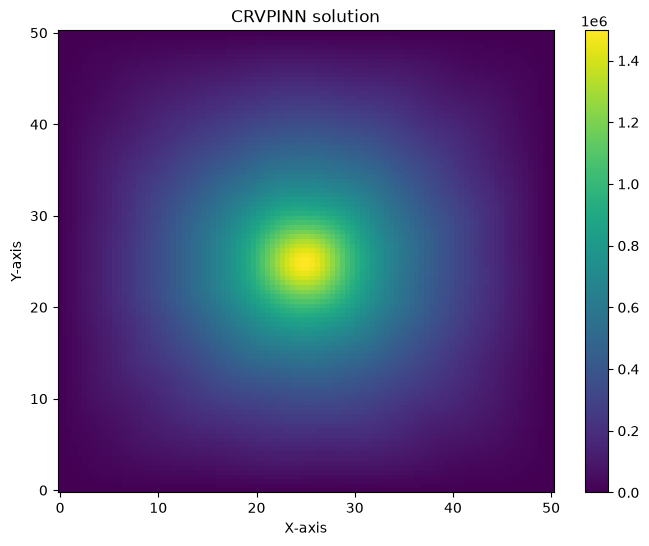

Training time : 2.617511
Starting simulation iteration 5/20


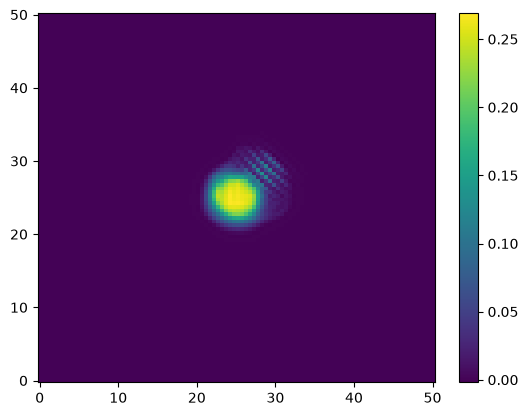

Epoch: 100 - Loss: 1.181e-03; total runtime: 1.569976568222046 (forward: 0.48043036460876465 grad: 0.7817683219909668 opt: 0.03777194023132324); time per epoch: 0.015699765682220458;


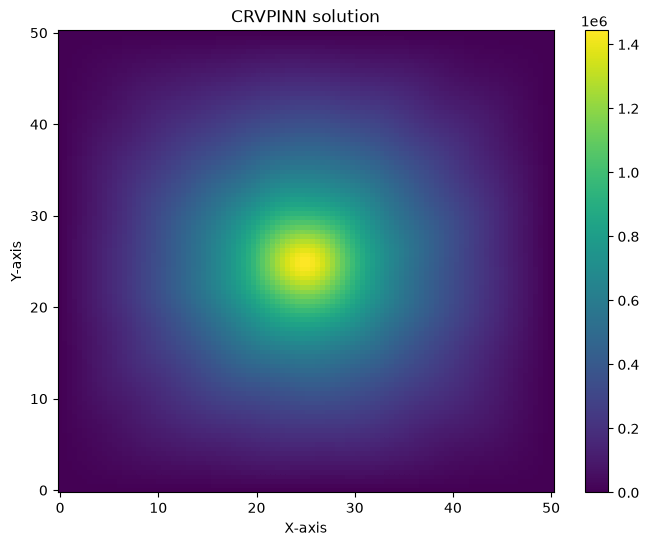

Training time : 1.972072
Starting simulation iteration 6/20


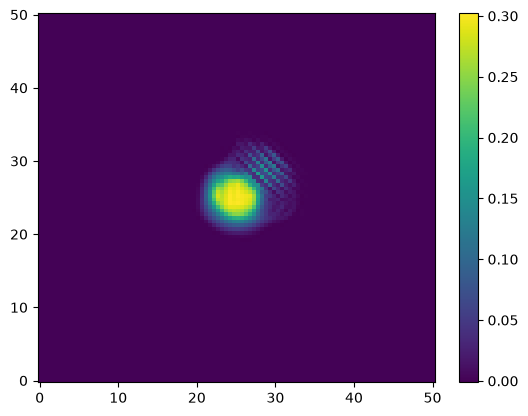

Epoch: 100 - Loss: 1.136e-03; total runtime: 1.7523818016052246 (forward: 0.5560972690582275 grad: 0.8881256580352783 opt: 0.04482412338256836); time per epoch: 0.017523818016052246;


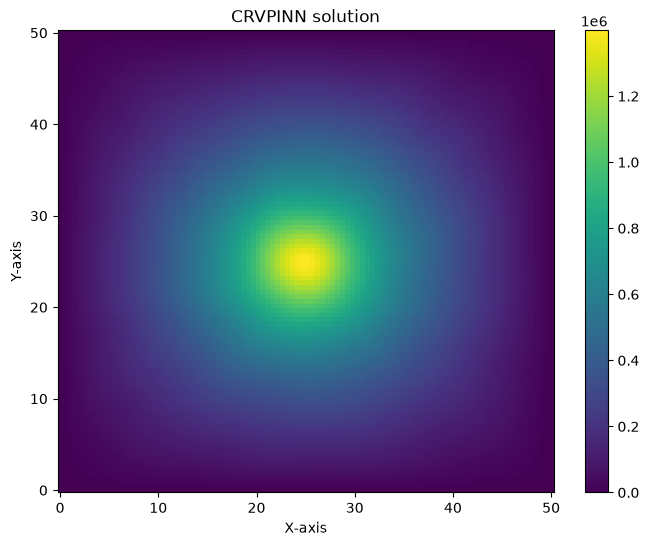

Training time : 2.068940
Starting simulation iteration 7/20


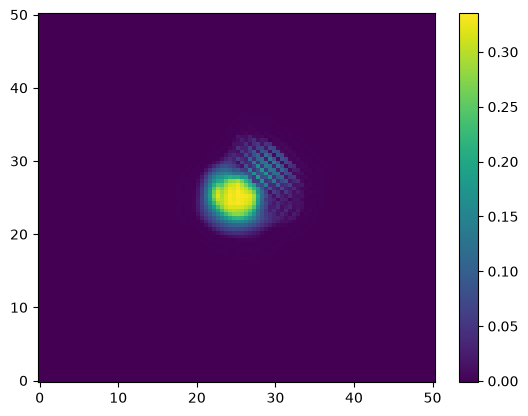

Epoch: 100 - Loss: 1.096e-03; total runtime: 1.5095765590667725 (forward: 0.4497530460357666 grad: 0.7536146640777588 opt: 0.033106327056884766); time per epoch: 0.015095765590667725;


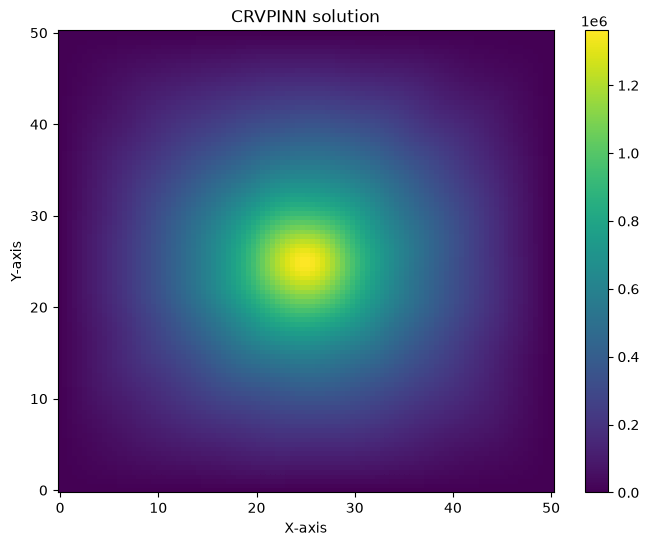

Training time : 1.951699
Starting simulation iteration 8/20


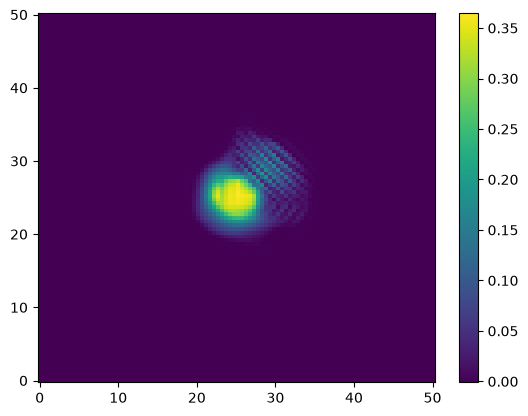

Epoch: 100 - Loss: 1.042e-03; total runtime: 1.504791259765625 (forward: 0.45064759254455566 grad: 0.7524104118347168 opt: 0.03327775001525879); time per epoch: 0.01504791259765625;


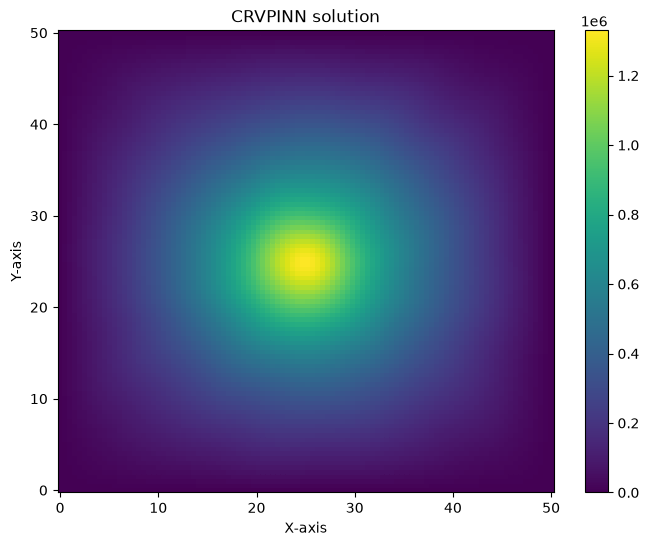

Training time : 1.935803
Starting simulation iteration 9/20


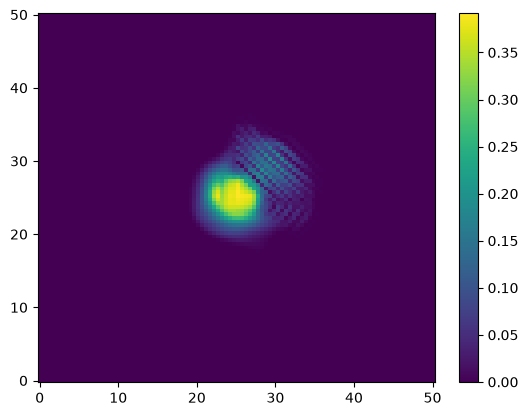

Epoch: 100 - Loss: 1.020e-03; total runtime: 1.6862711906433105 (forward: 0.5197651386260986 grad: 0.8508358001708984 opt: 0.044274330139160156); time per epoch: 0.016862711906433105;


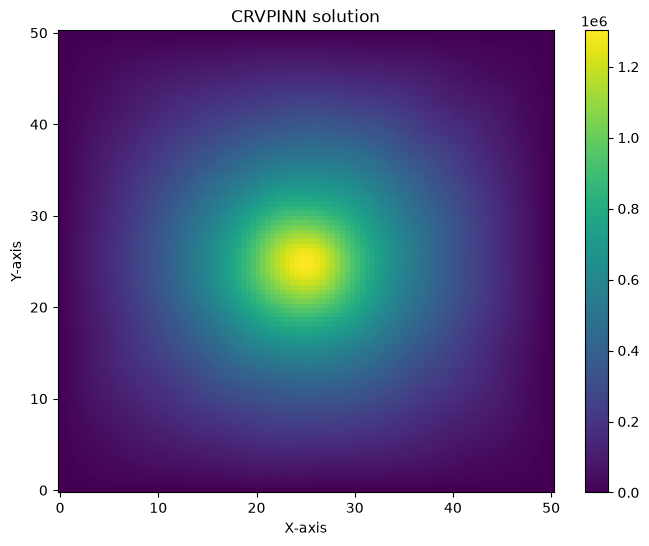

Training time : 2.209914
Starting simulation iteration 10/20


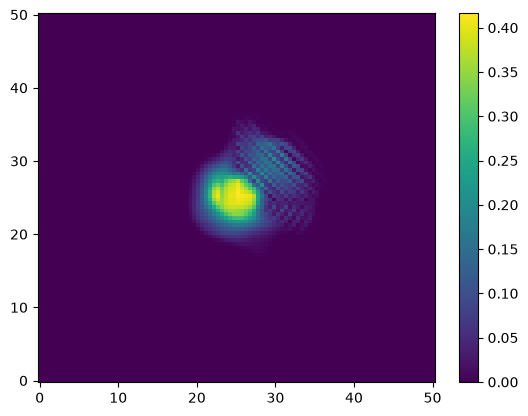

Epoch: 100 - Loss: 9.662e-04; total runtime: 2.341381072998047 (forward: 0.779409646987915 grad: 1.251542329788208 opt: 0.06403565406799316); time per epoch: 0.02341381072998047;


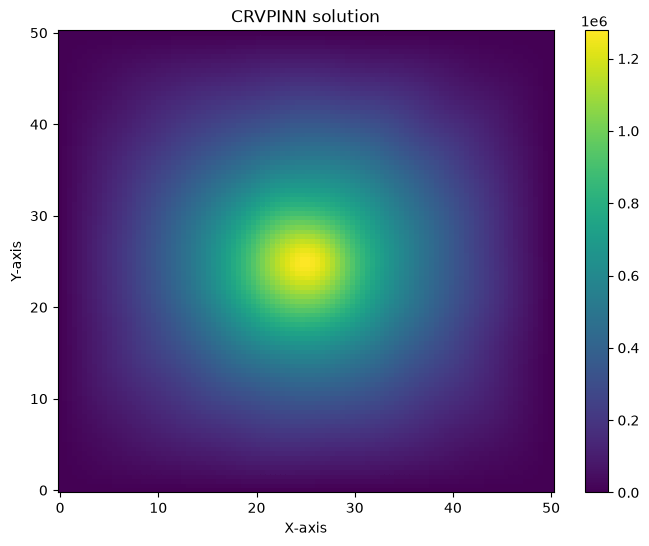

Training time : 2.561461
Starting simulation iteration 11/20


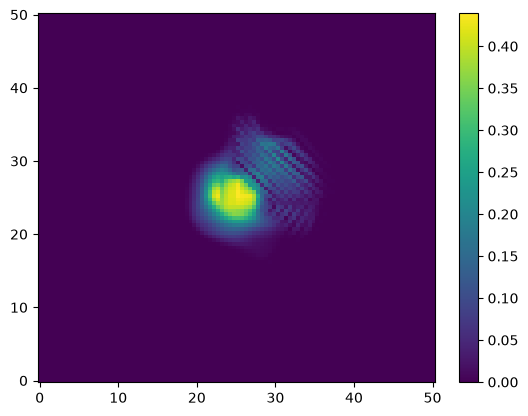

Epoch: 100 - Loss: 9.166e-04; total runtime: 1.5512652397155762 (forward: 0.46761441230773926 grad: 0.7752971649169922 opt: 0.03362727165222168); time per epoch: 0.015512652397155761;


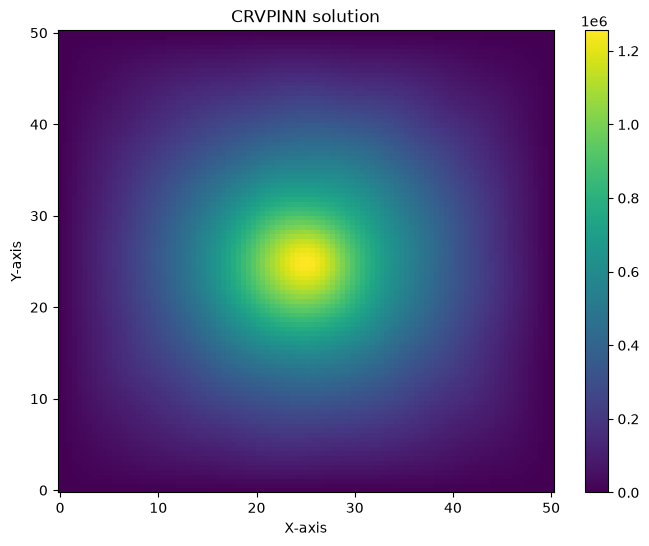

Training time : 1.969093
Starting simulation iteration 12/20


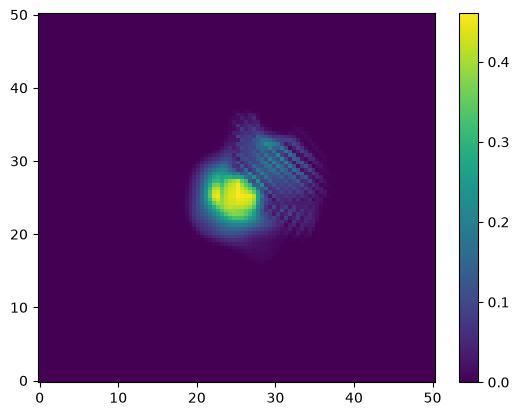

Epoch: 100 - Loss: 9.091e-04; total runtime: 1.5463840961456299 (forward: 0.46810173988342285 grad: 0.7647402286529541 opt: 0.0341649055480957); time per epoch: 0.0154638409614563;


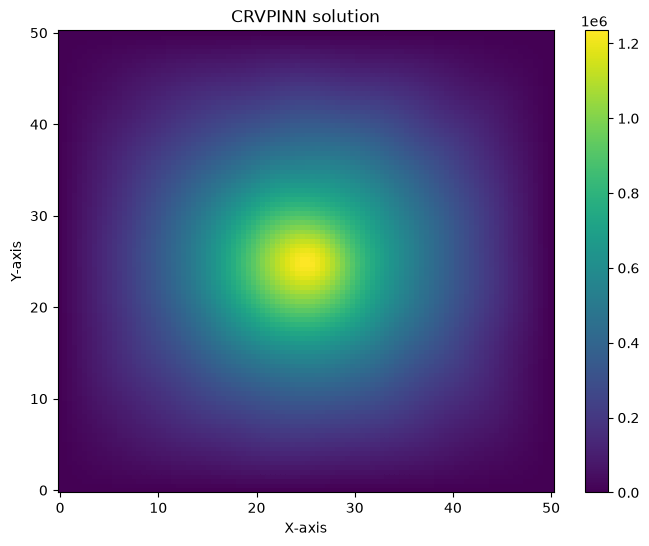

Training time : 1.959156
Starting simulation iteration 13/20


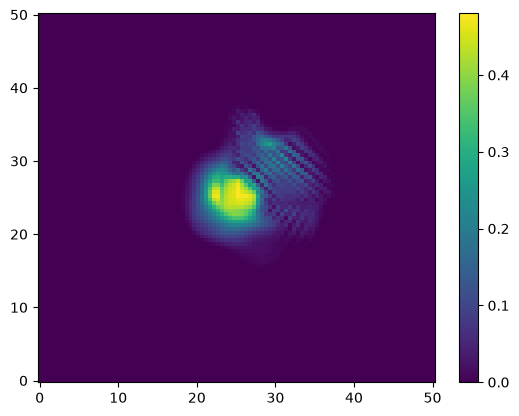

Epoch: 100 - Loss: 9.851e-04; total runtime: 1.5155606269836426 (forward: 0.453718900680542 grad: 0.7506499290466309 opt: 0.0321660041809082); time per epoch: 0.015155606269836426;


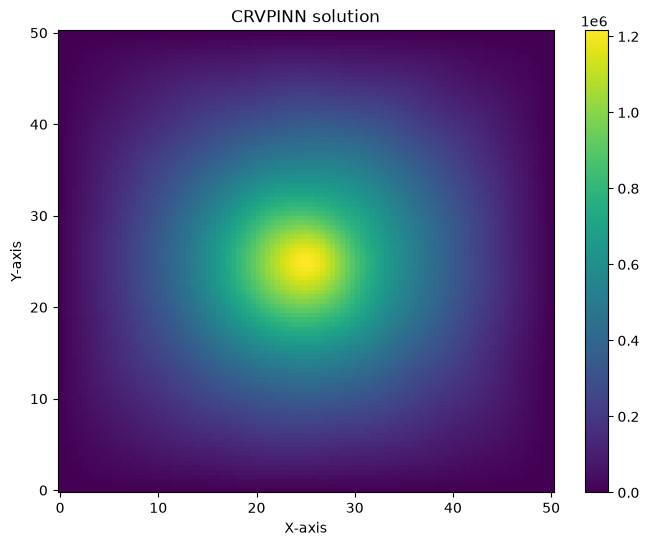

Training time : 1.946048
Starting simulation iteration 14/20


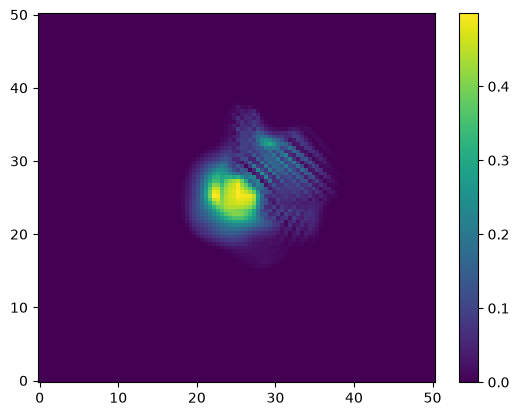

Epoch: 100 - Loss: 1.048e-03; total runtime: 1.519559621810913 (forward: 0.4628455638885498 grad: 0.7474641799926758 opt: 0.0322418212890625); time per epoch: 0.01519559621810913;


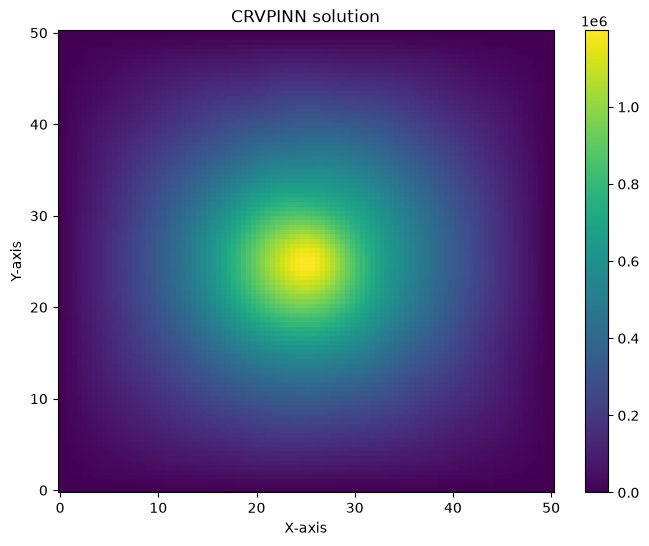

Training time : 1.939399
Starting simulation iteration 15/20


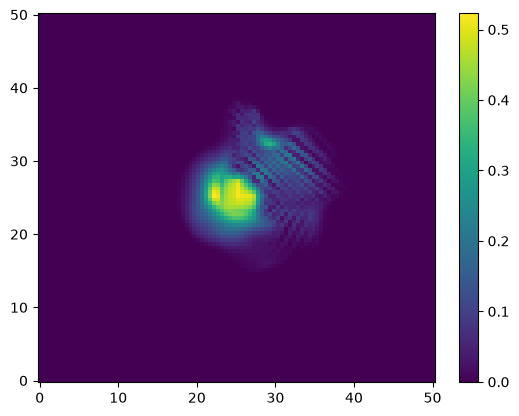

Epoch: 100 - Loss: 1.023e-03; total runtime: 1.5134856700897217 (forward: 0.45842504501342773 grad: 0.7472381591796875 opt: 0.032593727111816406); time per epoch: 0.015134856700897217;


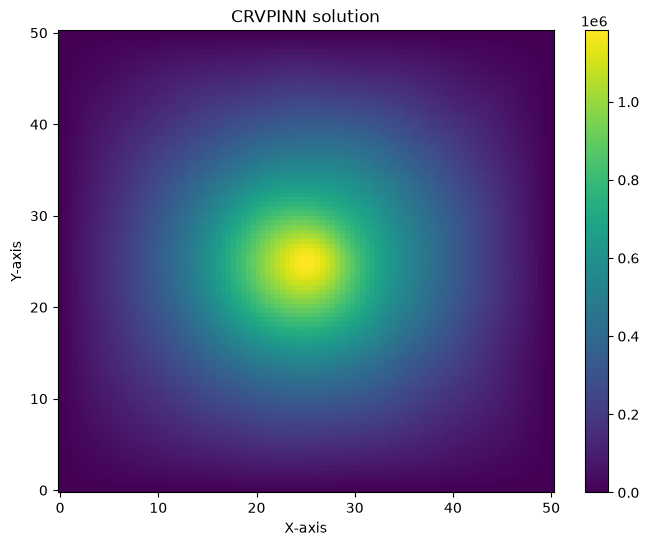

Training time : 1.944738
Starting simulation iteration 16/20


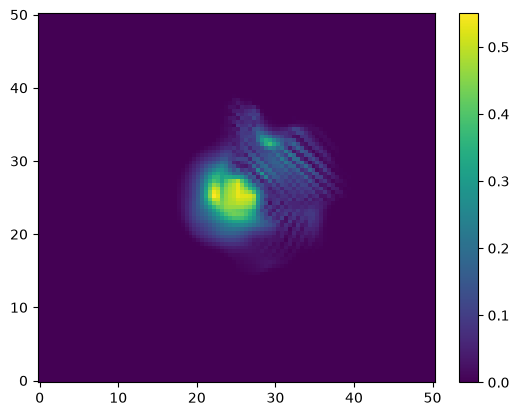

Epoch: 100 - Loss: 1.020e-03; total runtime: 1.514498233795166 (forward: 0.45456719398498535 grad: 0.7519350051879883 opt: 0.03282594680786133); time per epoch: 0.015144982337951661;


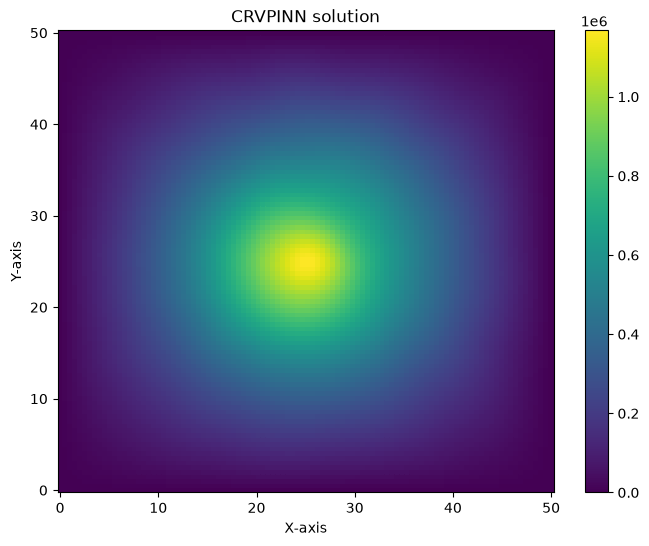

Training time : 1.962352
Starting simulation iteration 17/20


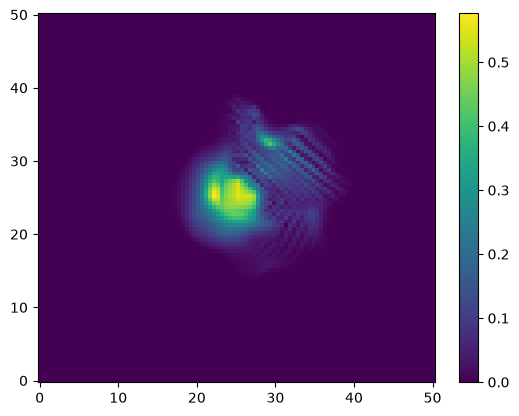

Epoch: 100 - Loss: 1.002e-03; total runtime: 1.5171492099761963 (forward: 0.4596128463745117 grad: 0.7462496757507324 opt: 0.031754493713378906); time per epoch: 0.015171492099761963;


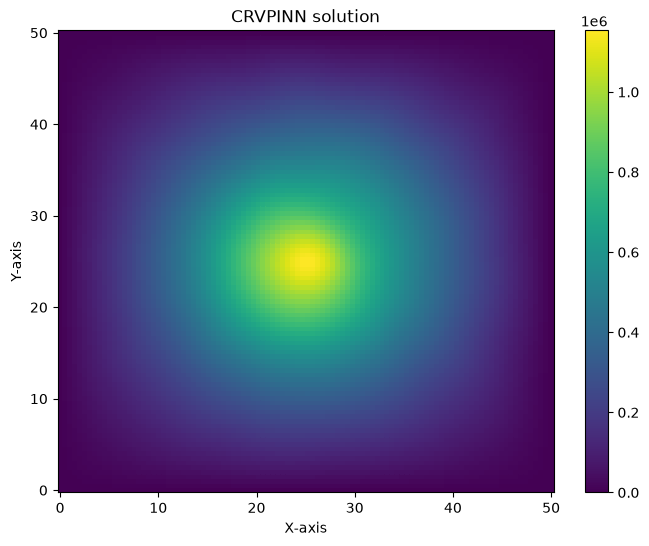

Training time : 1.942816
Starting simulation iteration 18/20


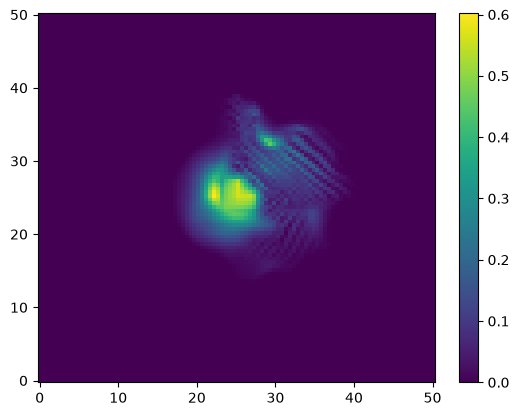

Epoch: 100 - Loss: 1.022e-03; total runtime: 1.5118963718414307 (forward: 0.45641326904296875 grad: 0.7516908645629883 opt: 0.03387713432312012); time per epoch: 0.015118963718414306;


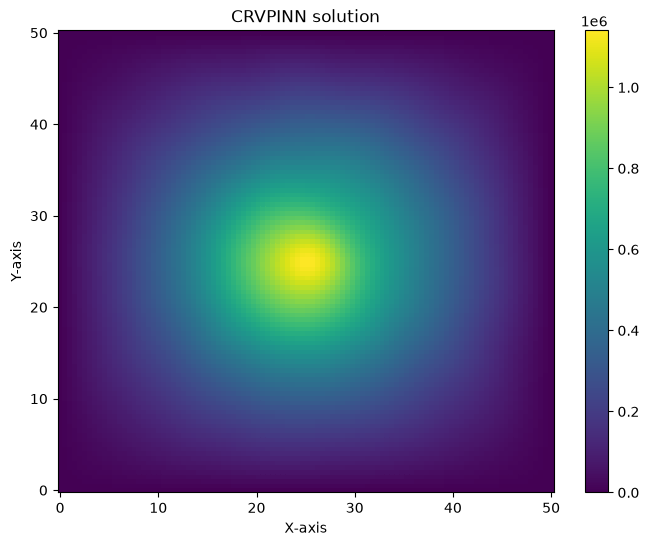

Training time : 1.948741
Starting simulation iteration 19/20


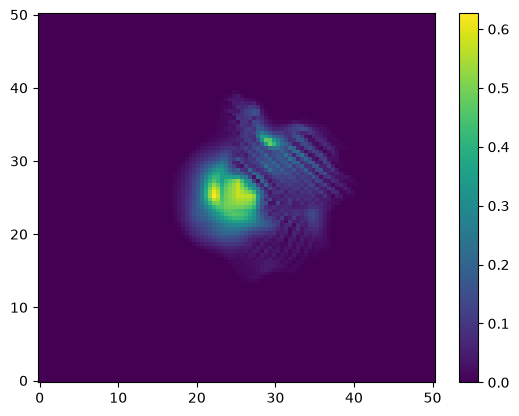

Epoch: 100 - Loss: 1.102e-03; total runtime: 2.21846079826355 (forward: 0.7359468936920166 grad: 1.1735398769378662 opt: 0.05814862251281738); time per epoch: 0.0221846079826355;


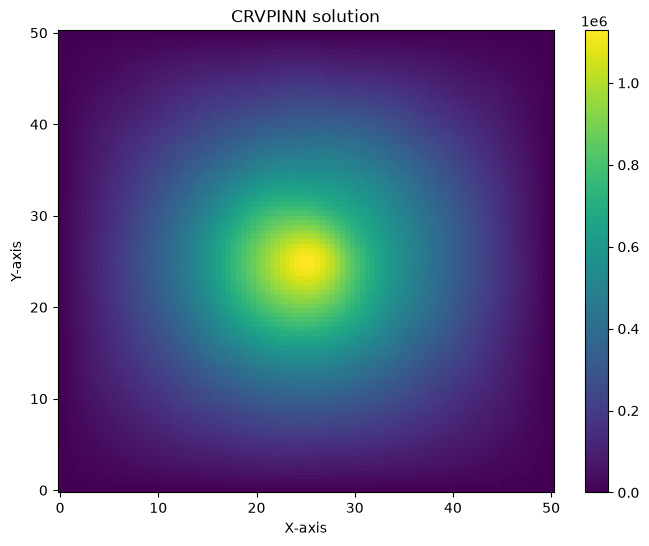

Training time : 2.449291
Starting simulation iteration 20/20


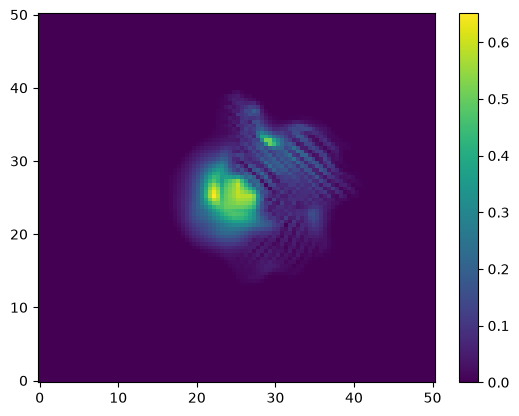

Epoch: 100 - Loss: 1.125e-03; total runtime: 2.474679708480835 (forward: 0.8385651111602783 grad: 1.3305320739746094 opt: 0.06777548789978027); time per epoch: 0.02474679708480835;


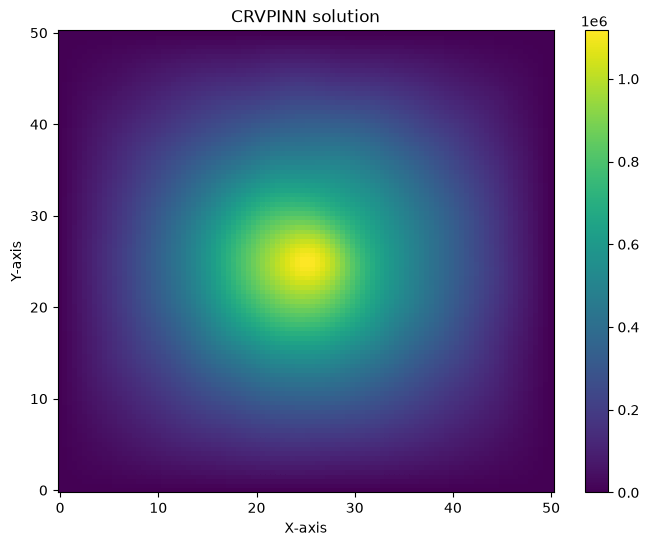

Training time : 2.687121
Total training time for 20 iterations: 42.654096


In [48]:
pinn_trained, loss_values_cont = continue_training(pinn, x, t, n_it_simulation=20, folder_name='uniformK2')

Text(0.5, 1.0, 'CRVPINN solution at 19th time step')

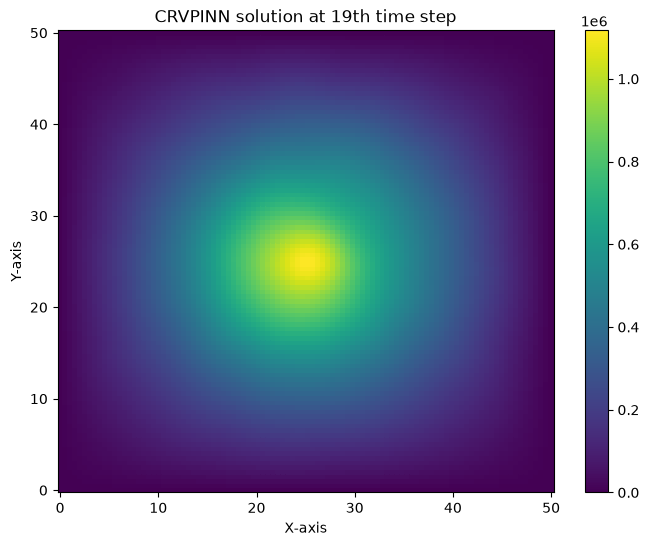

In [49]:
z_190 = f(pinn_trained.to(device), x, t)
color = plot_color(z_190.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)
plt.title('CRVPINN solution at 19th time step')

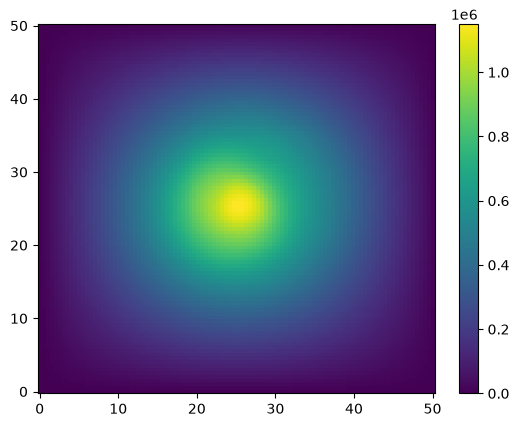

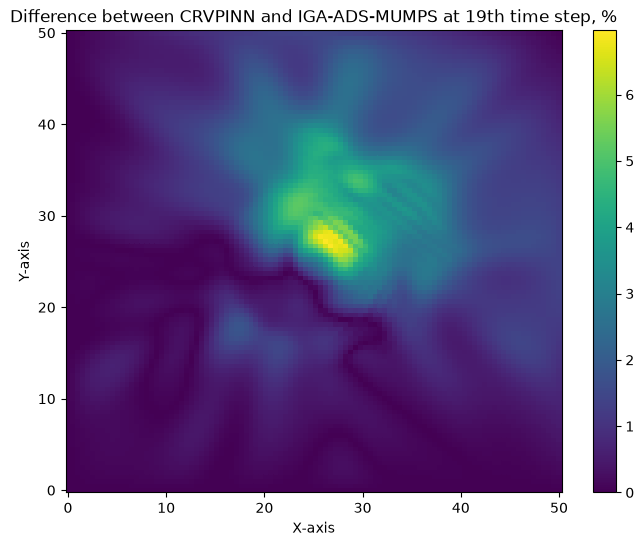

In [50]:
compare_with_iga(z_190, it_simulation=19, folder='uniformK2') #, err_bounds = (0, 6.5))

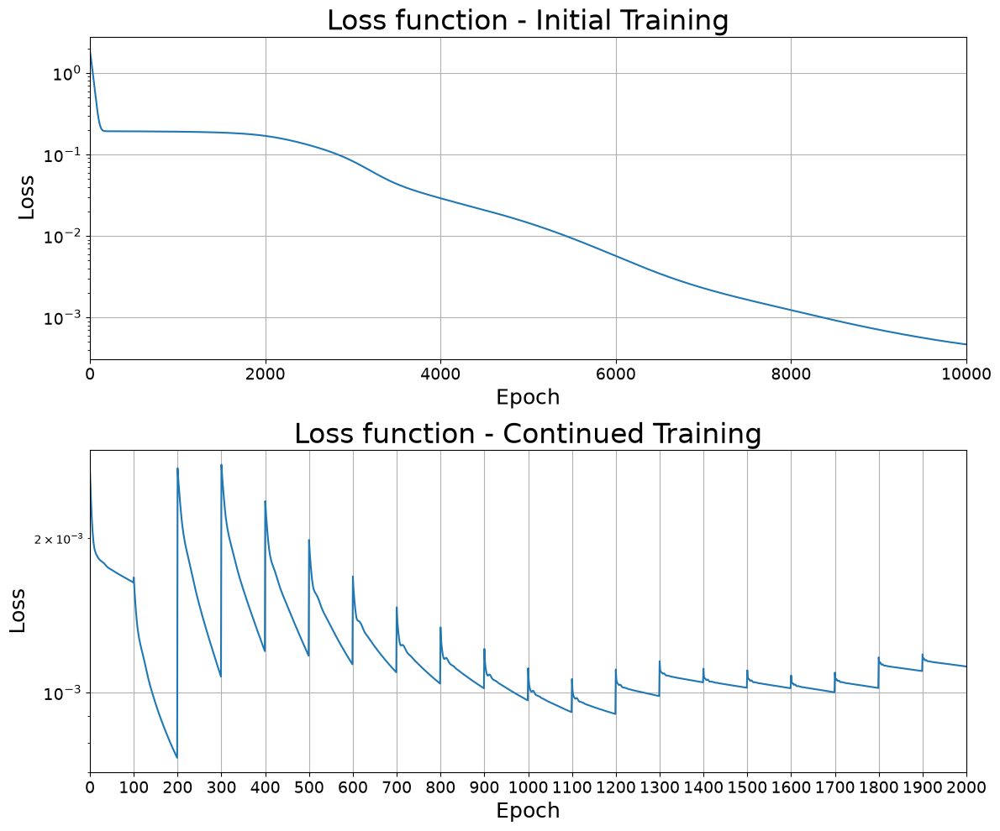

In [51]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.set_title("Loss function - Initial Training", fontsize = 24)
ax1.set_xlabel("Epoch", fontsize = 18)
ax1.set_ylabel("Loss", fontsize = 18)
ax1.set_yscale("log")
ax1.set_xlim(0, EPOCHS)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.plot(loss_values)
ax1.grid(True)

ax2.set_title("Loss function - Continued Training", fontsize = 24)
ax2.set_xlabel("Epoch", fontsize = 18)
ax2.set_ylabel("Loss", fontsize = 18)
ax2.set_yscale("log")
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_xlim(0, len(loss_values_cont))
ax2.set_xticks(np.arange(0, len(loss_values_cont)+1, step=100))
ax2.plot(loss_values_cont)
ax2.grid(True)

plt.tight_layout()


# PINN with uniform $K = 10^{-15} m^2$ (porosity map K3)

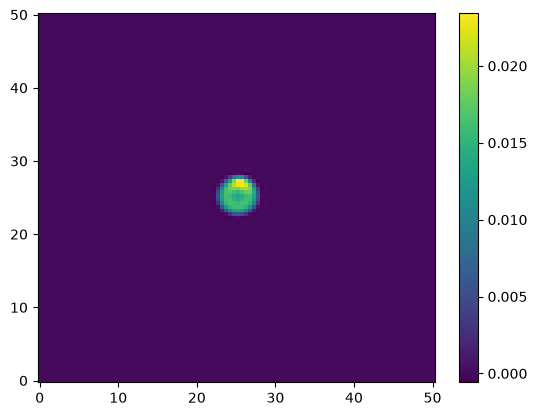

In [52]:
saturation_array = data_reader_s(f'uniformK3/s.out_0.data', step_size=0.5) 
Sg_tensor = torch.tensor(saturation_array.copy(), device=device, requires_grad=True)
global Sg_function
Sg_function = make_fun(x_lin, y_lin, Sg_tensor)
plotly(x_plot, y_plot, Sg_function(x_plot, y_plot))

In [53]:
pressure_array = data_reader_s('uniformK3/p.out_0.data', step_size=0.5, size_x=LENGTH, size_y=TOTAL_TIME)
P_tensor = torch.tensor(pressure_array.copy(), device=device)
P_function = make_fun(x_lin, y_lin, P_tensor)

Epoch: 1000 - Loss: 1.907e-01; total runtime: 1.656651258468628 (forward: 0.4701986312866211 grad: 0.8980998992919922 opt: 0.18792271614074707); time per epoch: 0.0016566512584686279;


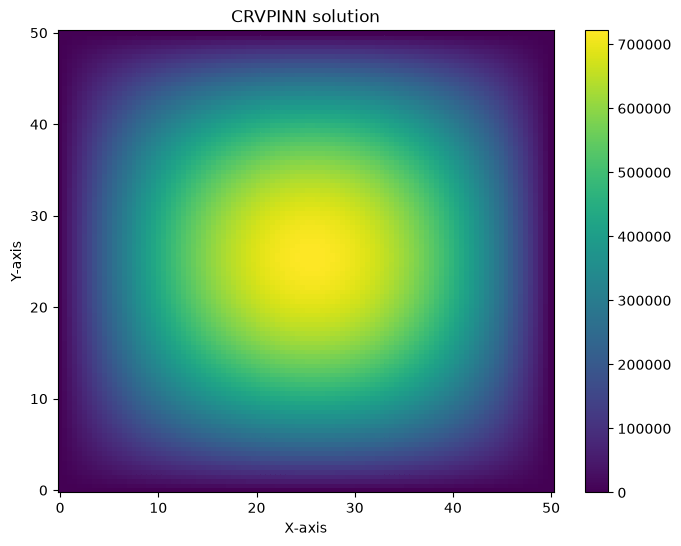

Epoch: 2000 - Loss: 1.672e-01; total runtime: 3.3241024017333984 (forward: 0.9423179626464844 grad: 1.79862642288208 opt: 0.380725622177124); time per epoch: 0.0016620512008666993;


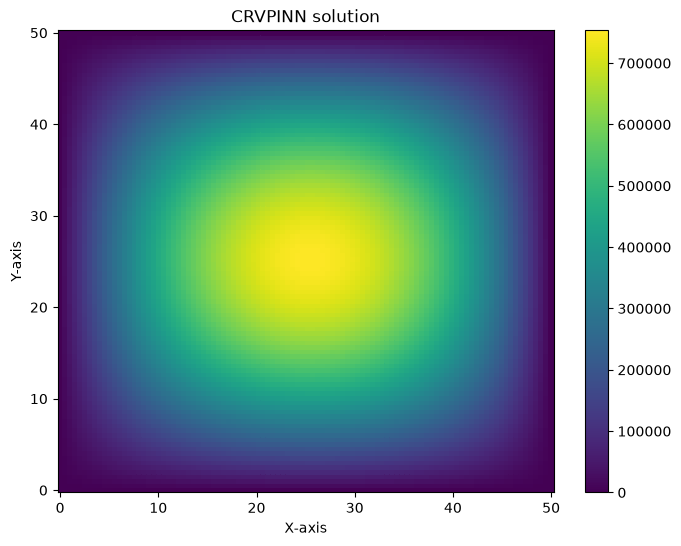

Epoch: 3000 - Loss: 8.213e-02; total runtime: 5.3384246826171875 (forward: 1.5189058780670166 grad: 2.8660755157470703 opt: 0.6333403587341309); time per epoch: 0.001779474894205729;


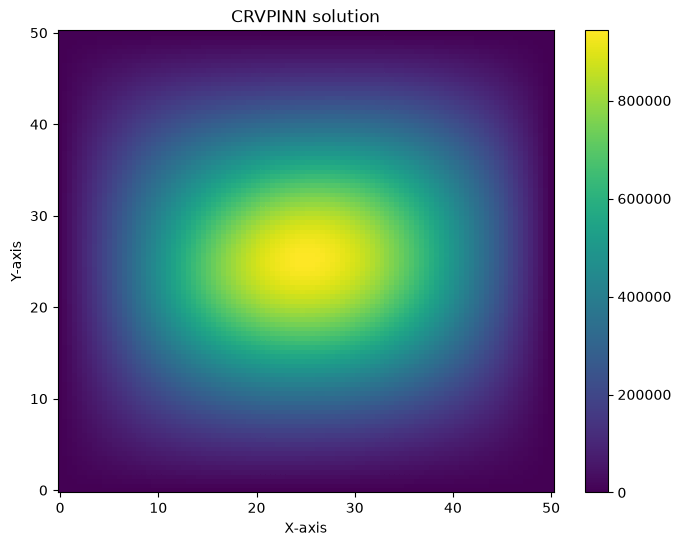

Epoch: 4000 - Loss: 2.553e-02; total runtime: 9.023210287094116 (forward: 2.5631115436553955 grad: 4.874516248703003 opt: 1.08128023147583); time per epoch: 0.002255802571773529;


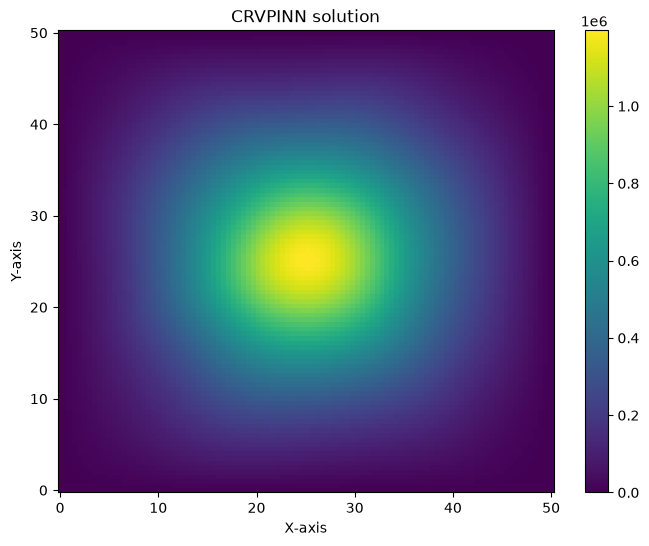

Epoch: 5000 - Loss: 1.126e-02; total runtime: 11.936384677886963 (forward: 3.389150381088257 grad: 6.446518898010254 opt: 1.4396378993988037); time per epoch: 0.0023872769355773927;


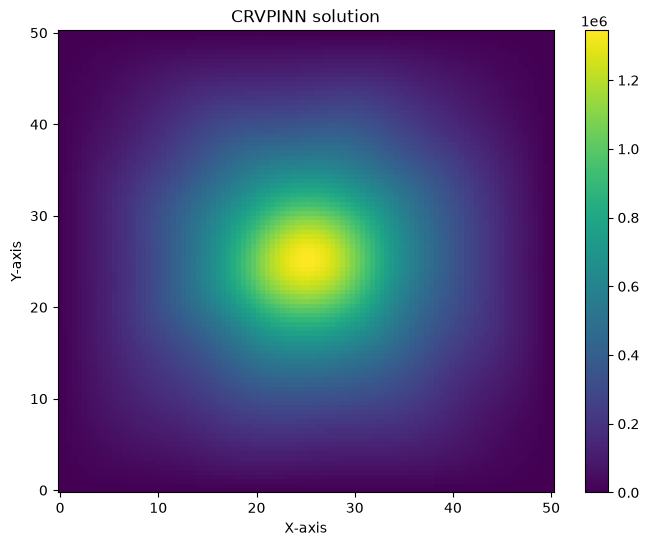

Epoch: 6000 - Loss: 4.279e-03; total runtime: 15.826569080352783 (forward: 4.508673191070557 grad: 8.526560306549072 opt: 1.9287257194519043); time per epoch: 0.0026377615133921306;


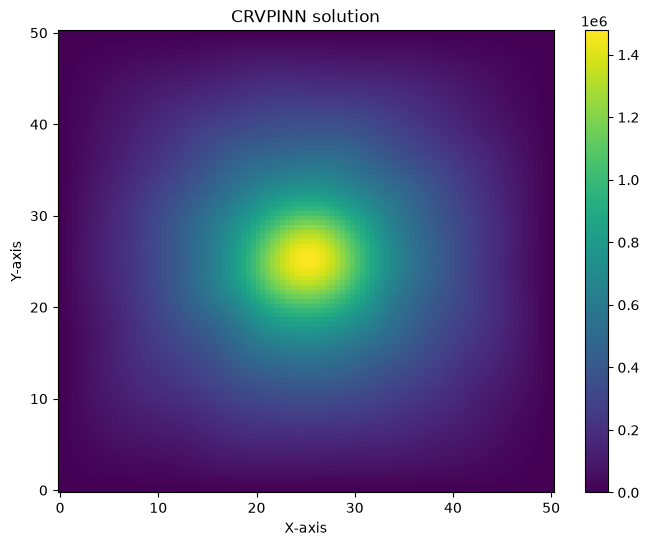

Epoch: 7000 - Loss: 2.195e-03; total runtime: 18.88747549057007 (forward: 5.385269403457642 grad: 10.17796802520752 opt: 2.3041021823883057); time per epoch: 0.0026982107843671528;


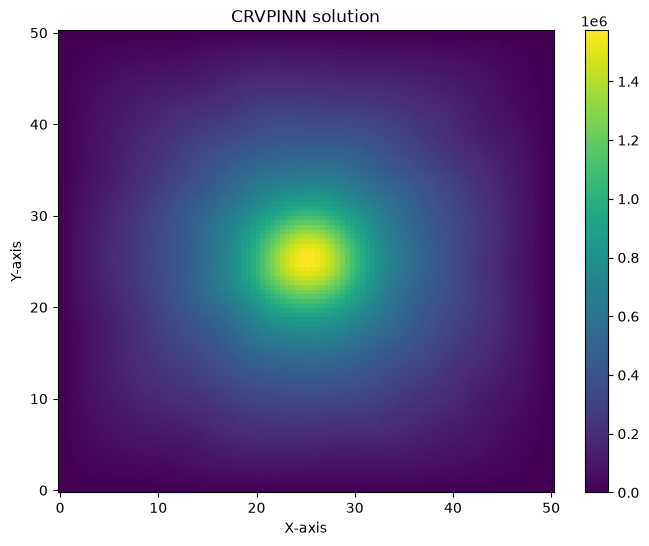

Epoch: 8000 - Loss: 1.543e-03; total runtime: 22.808645486831665 (forward: 6.503147125244141 grad: 12.288249969482422 opt: 2.7940351963043213); time per epoch: 0.002851080685853958;


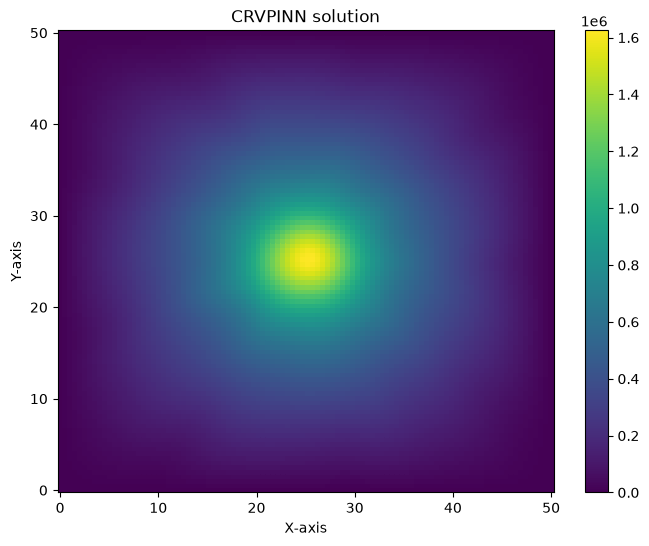

Epoch: 9000 - Loss: 1.070e-03; total runtime: 24.664214611053467 (forward: 7.030640363693237 grad: 13.27646517753601 opt: 3.014709234237671); time per epoch: 0.0027404682901170517;


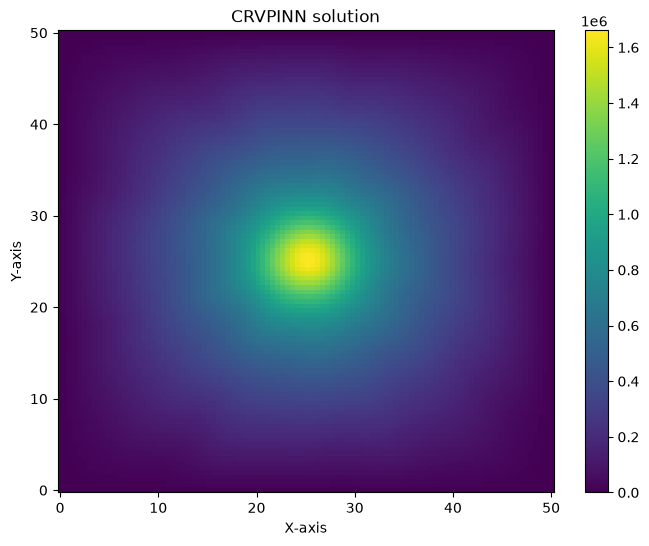

Epoch: 10000 - Loss: 6.991e-04; total runtime: 27.89091396331787 (forward: 7.951016902923584 grad: 15.010818004608154 opt: 3.422154188156128); time per epoch: 0.0027890913963317873;


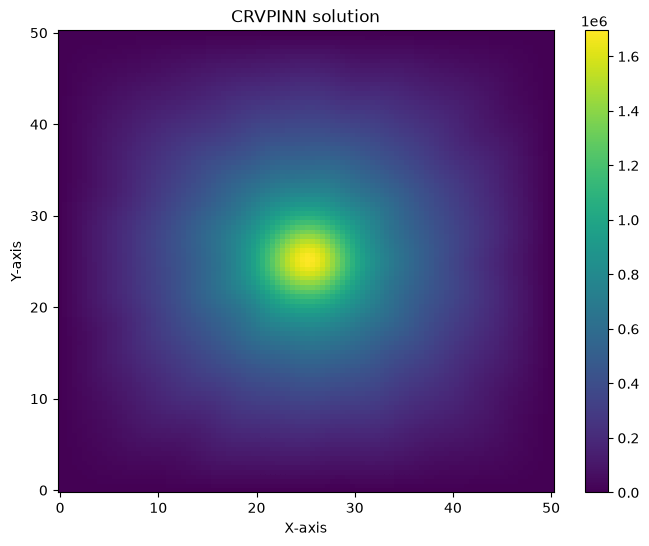

Training time : 30.223347


In [54]:
pinn = None
pinn = PINN(LAYERS, NEURONS_PER_LAYER, pinning=True, act=nn.Tanh()).to(device)

# train the PINN
time_train0 = time.time()

loss_fn = partial(compute_loss, x=x, t=t, w_physics=0, w_data=0.1)
pinn_trained, loss_values = train_model(pinn, 
            x, t, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=EPOCHS)
time_train1 = time.time()

print(f'Training time : %f'%(time_train1 - time_train0))

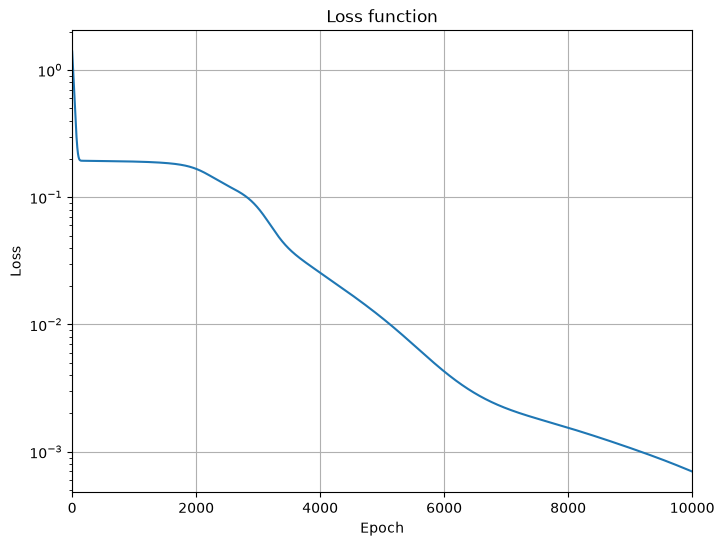

In [55]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
ax.plot(loss_values)
plt.grid(True)

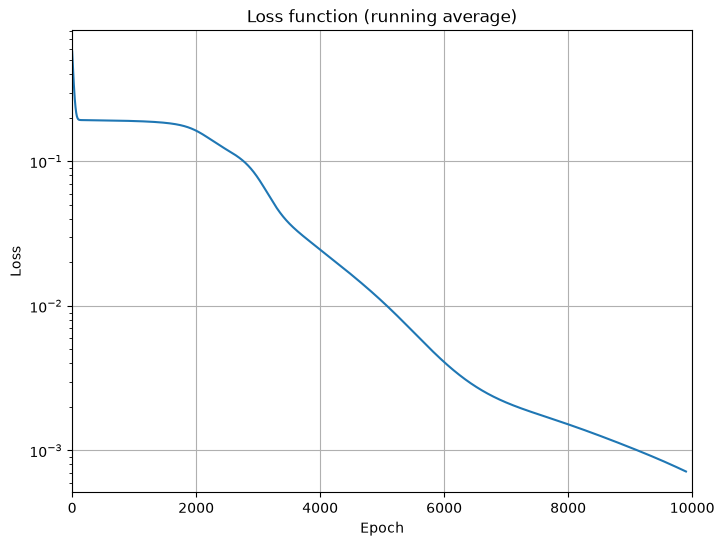

In [56]:
average_loss = running_average(loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
ax.plot(average_loss)
plt.grid(True)

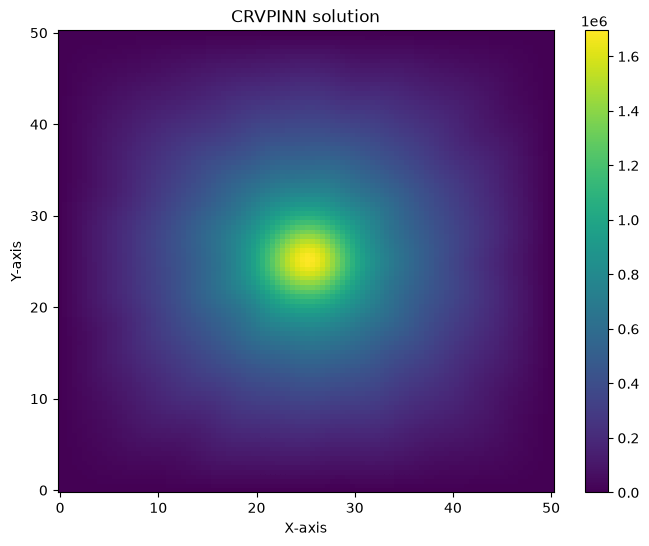

In [57]:
z_0 = f(pinn.to(device), x, t)
color = plot_color(z_0.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)

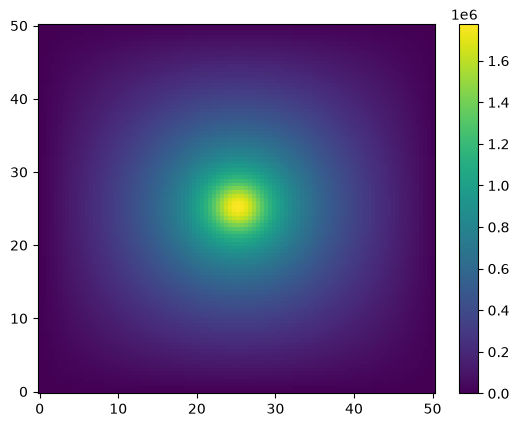

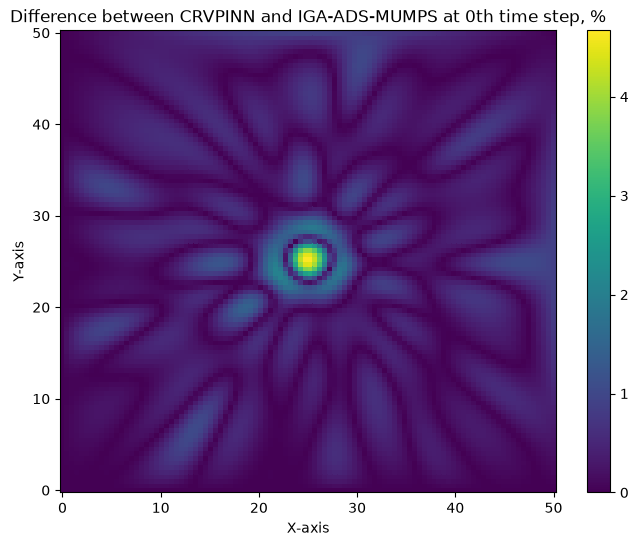

In [58]:
compare_with_iga(z_0, it_simulation=0, folder='uniformK3') #, err_bounds=(0, 5.5))

Starting simulation iteration 1/20


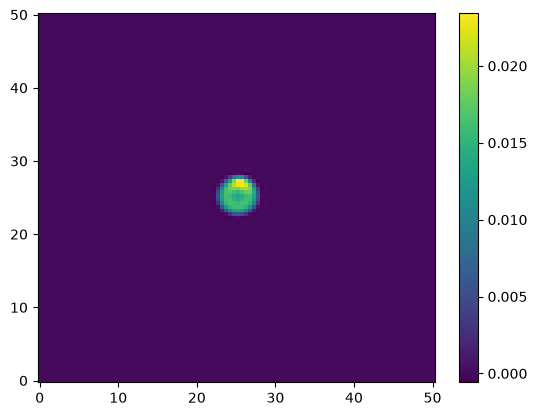

Epoch: 100 - Loss: 2.369e-03; total runtime: 1.7143585681915283 (forward: 0.5322132110595703 grad: 0.8577980995178223 opt: 0.04700970649719238); time per epoch: 0.017143585681915284;


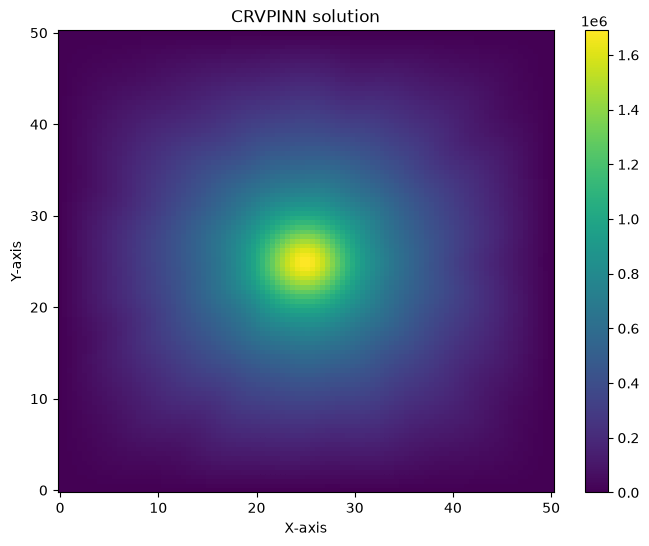

Training time : 2.088397
Starting simulation iteration 2/20


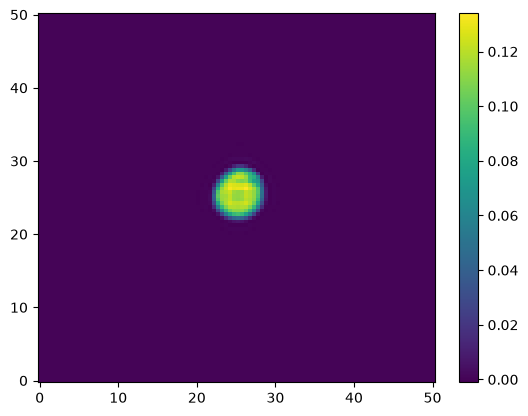

Epoch: 100 - Loss: 1.394e-03; total runtime: 2.138150215148926 (forward: 0.7072718143463135 grad: 1.1111562252044678 opt: 0.05717897415161133); time per epoch: 0.02138150215148926;


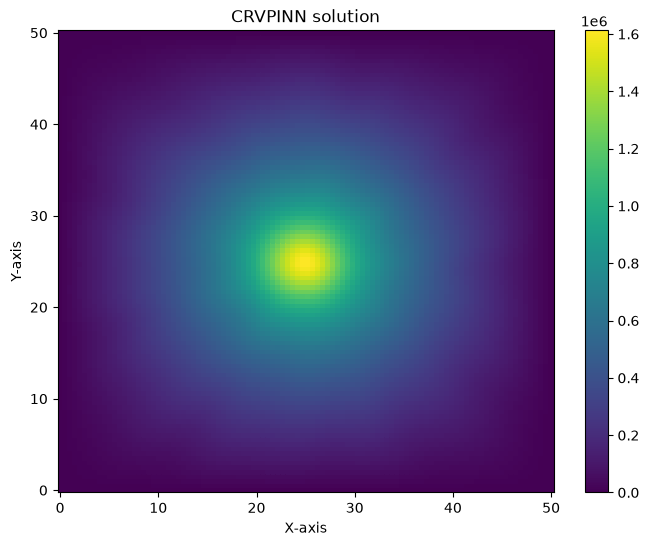

Training time : 2.516864
Starting simulation iteration 3/20


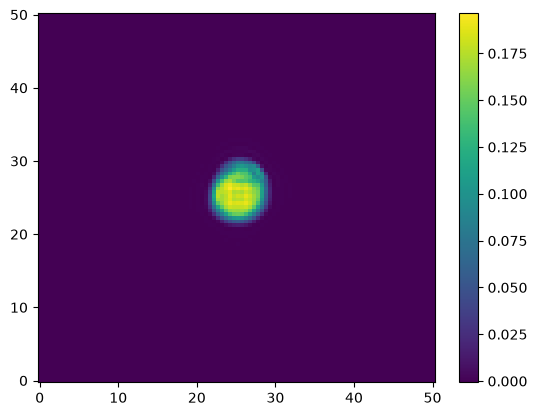

Epoch: 100 - Loss: 2.070e-03; total runtime: 2.454047918319702 (forward: 0.8526144027709961 grad: 1.2951960563659668 opt: 0.06646871566772461); time per epoch: 0.02454047918319702;


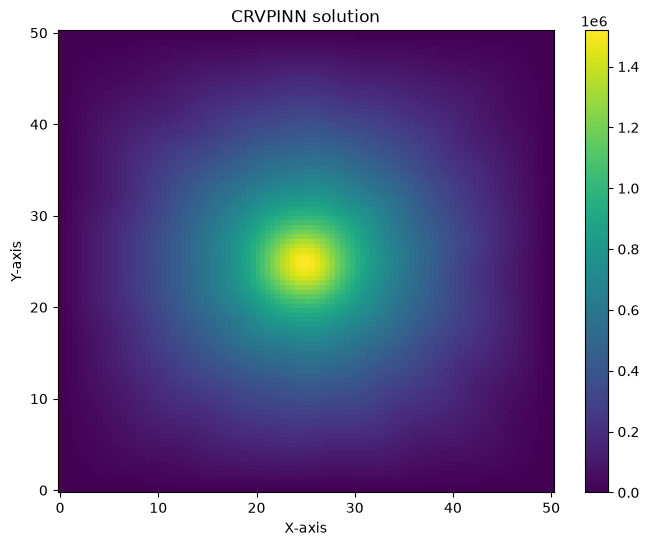

Training time : 2.742755
Starting simulation iteration 4/20


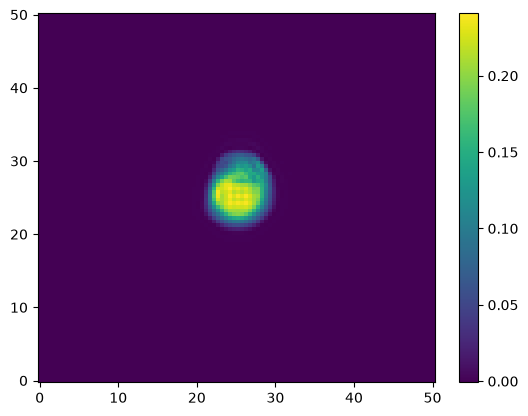

Epoch: 100 - Loss: 2.278e-03; total runtime: 2.4209277629852295 (forward: 0.8204329013824463 grad: 1.2918481826782227 opt: 0.0560917854309082); time per epoch: 0.024209277629852297;


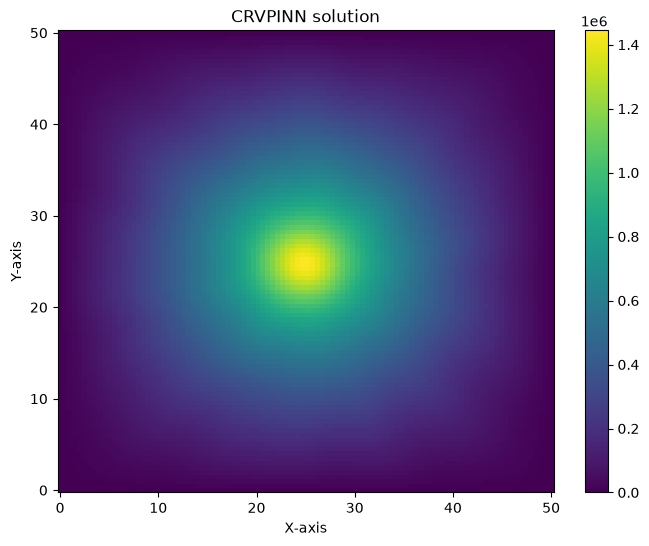

Training time : 2.653082
Starting simulation iteration 5/20


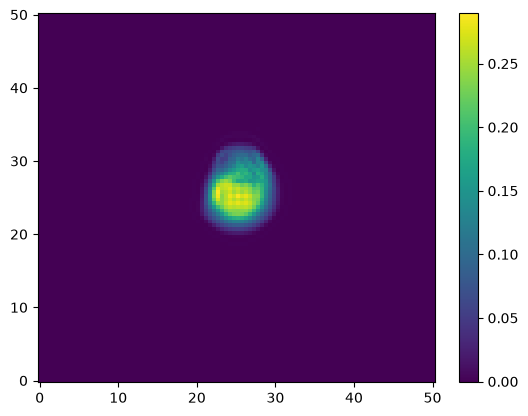

Epoch: 100 - Loss: 2.187e-03; total runtime: 2.1753532886505127 (forward: 0.7295217514038086 grad: 1.1403605937957764 opt: 0.05910205841064453); time per epoch: 0.021753532886505125;


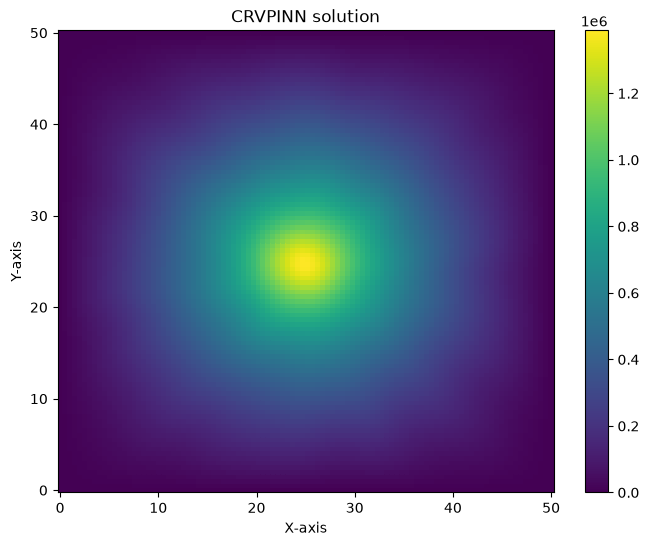

Training time : 2.353849
Starting simulation iteration 6/20


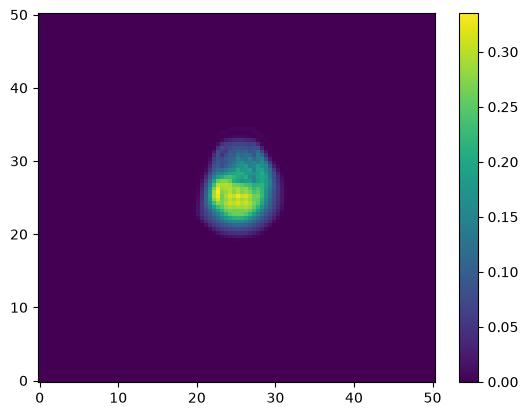

Epoch: 100 - Loss: 1.983e-03; total runtime: 2.078453779220581 (forward: 0.6826744079589844 grad: 1.0864107608795166 opt: 0.055545806884765625); time per epoch: 0.02078453779220581;


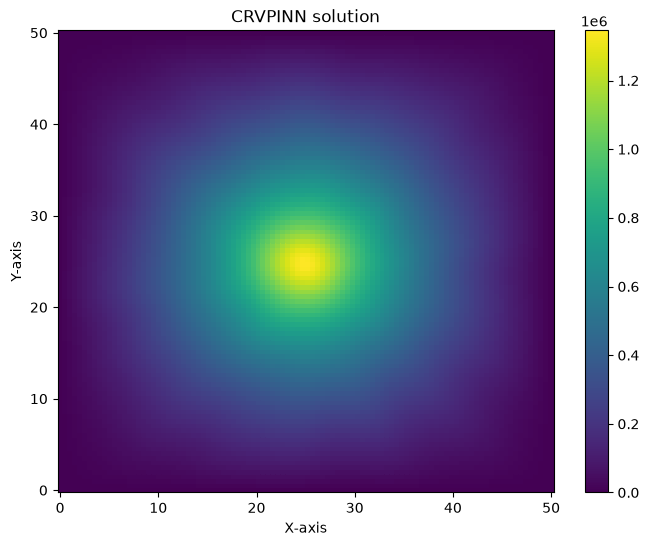

Training time : 2.271135
Starting simulation iteration 7/20


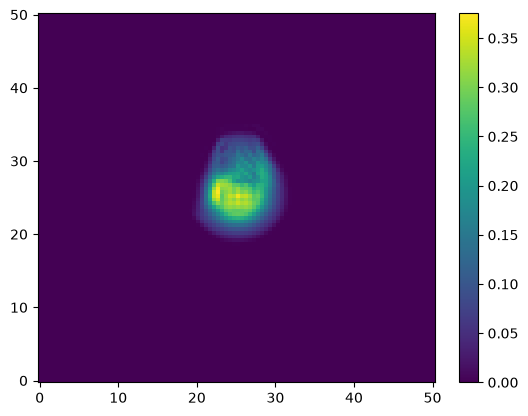

Epoch: 100 - Loss: 1.785e-03; total runtime: 2.0910942554473877 (forward: 0.6920871734619141 grad: 1.0895230770111084 opt: 0.0536496639251709); time per epoch: 0.02091094255447388;


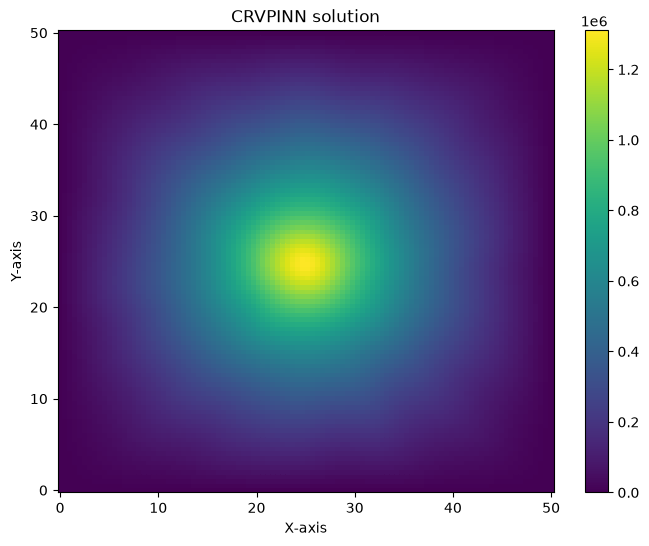

Training time : 2.520046
Starting simulation iteration 8/20


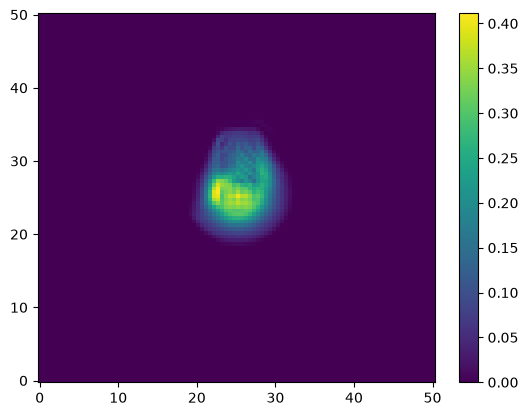

Epoch: 100 - Loss: 1.657e-03; total runtime: 3.0206286907196045 (forward: 1.0604231357574463 grad: 1.6505517959594727 opt: 0.07527613639831543); time per epoch: 0.030206286907196046;


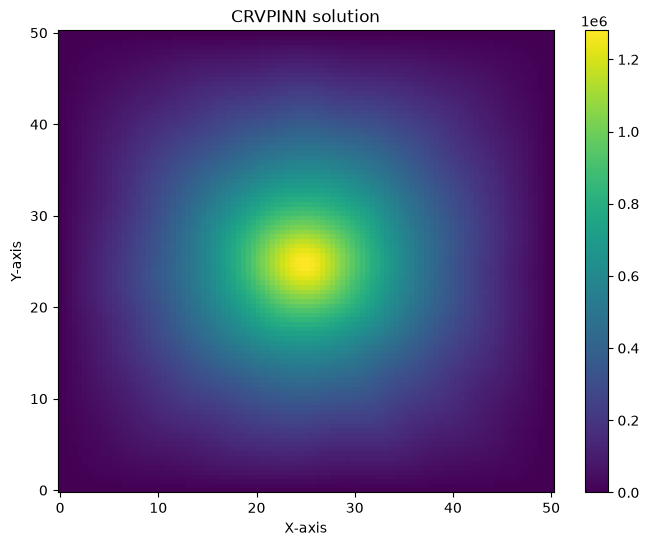

Training time : 3.196455
Starting simulation iteration 9/20


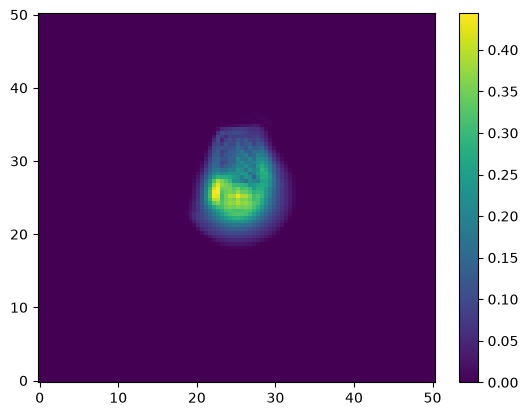

Epoch: 100 - Loss: 1.610e-03; total runtime: 2.128239870071411 (forward: 0.6917426586151123 grad: 1.1266953945159912 opt: 0.054228782653808594); time per epoch: 0.021282398700714113;


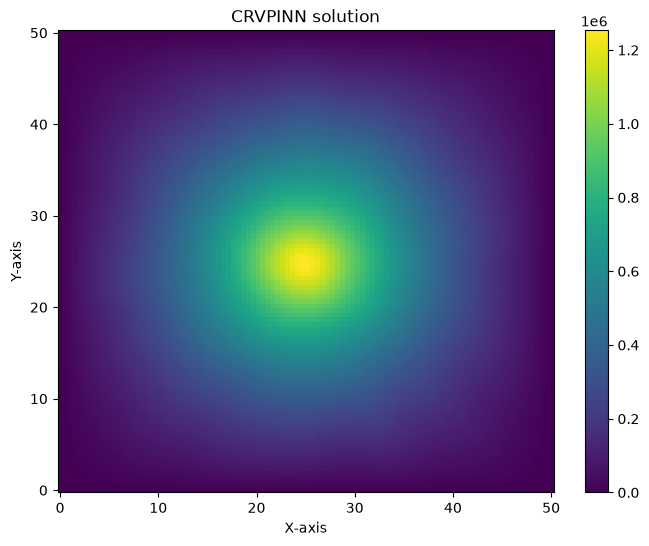

Training time : 2.550813
Starting simulation iteration 10/20


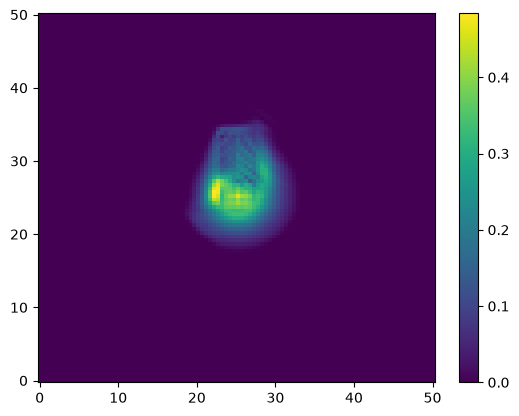

Epoch: 100 - Loss: 1.611e-03; total runtime: 1.717517614364624 (forward: 0.531597375869751 grad: 0.8695254325866699 opt: 0.045093536376953125); time per epoch: 0.01717517614364624;


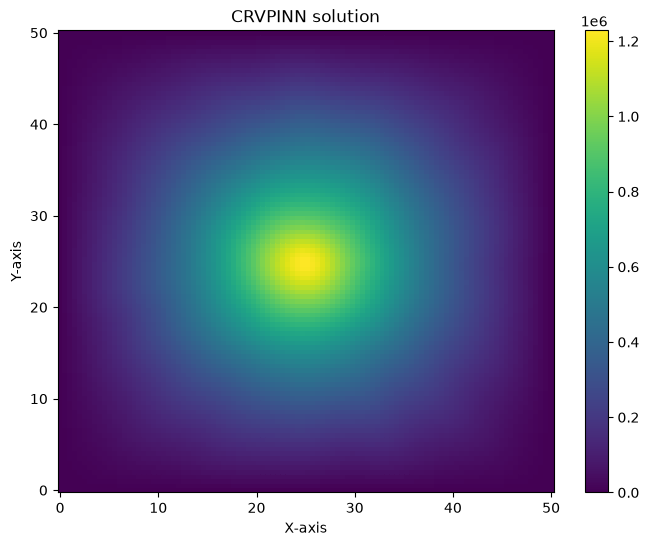

Training time : 2.054303
Starting simulation iteration 11/20


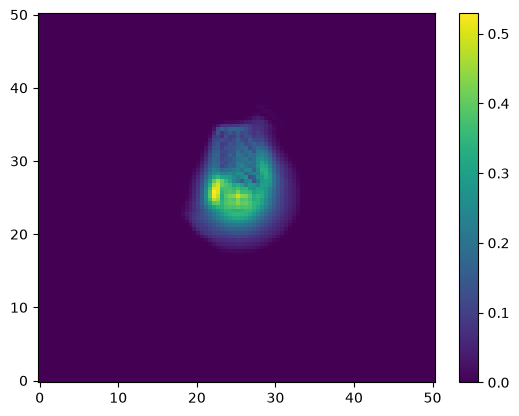

Epoch: 100 - Loss: 1.633e-03; total runtime: 1.6006085872650146 (forward: 0.48995494842529297 grad: 0.7965219020843506 opt: 0.040297746658325195); time per epoch: 0.016006085872650146;


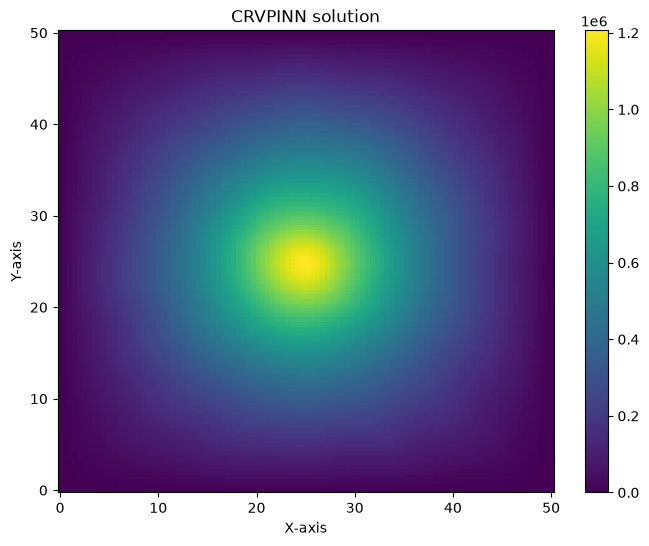

Training time : 1.991811
Starting simulation iteration 12/20


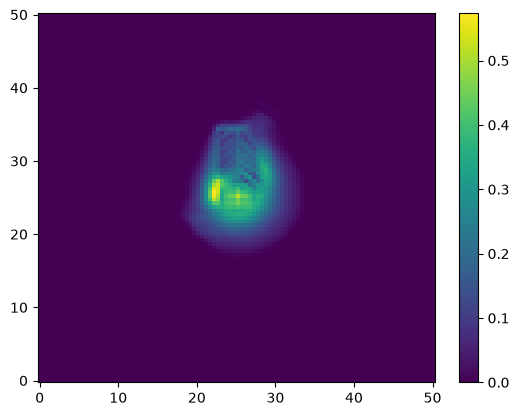

Epoch: 100 - Loss: 1.672e-03; total runtime: 1.547562599182129 (forward: 0.46745991706848145 grad: 0.7686662673950195 opt: 0.03598928451538086); time per epoch: 0.01547562599182129;


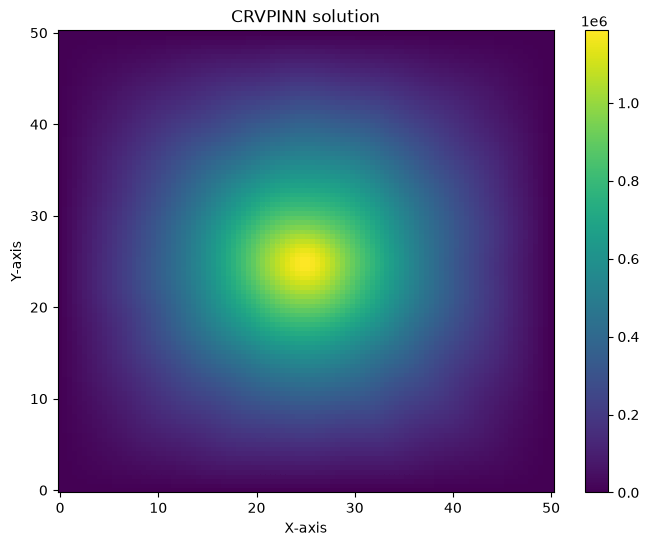

Training time : 1.980239
Starting simulation iteration 13/20


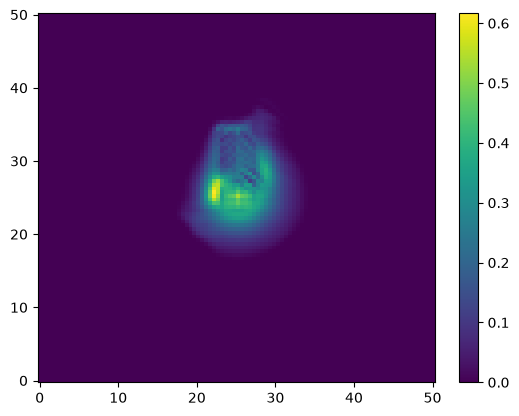

Epoch: 100 - Loss: 1.683e-03; total runtime: 1.7371952533721924 (forward: 0.538334846496582 grad: 0.8800885677337646 opt: 0.044045209884643555); time per epoch: 0.017371952533721924;


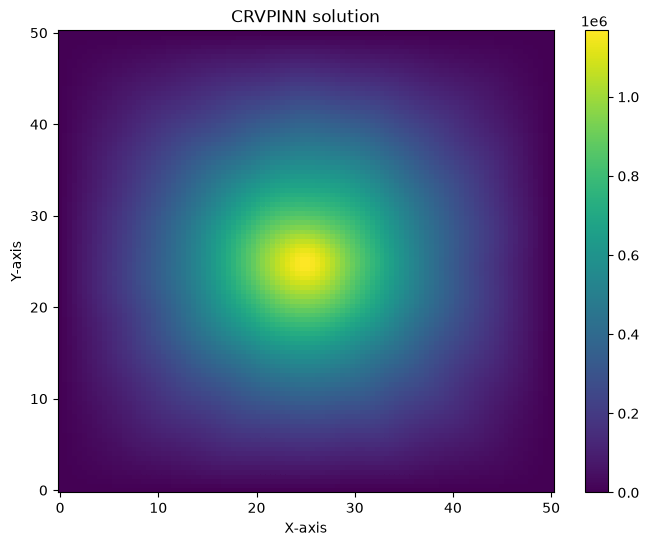

Training time : 2.067138
Starting simulation iteration 14/20


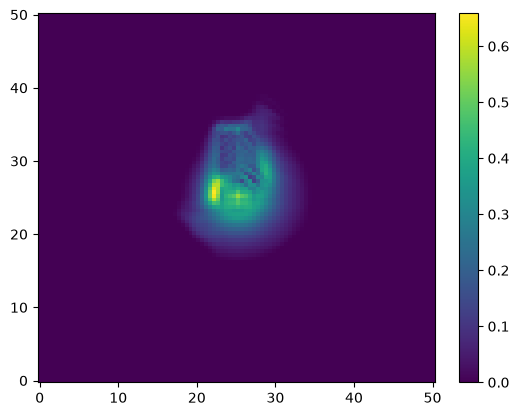

Epoch: 100 - Loss: 1.664e-03; total runtime: 1.5334811210632324 (forward: 0.4670069217681885 grad: 0.7550044059753418 opt: 0.0339961051940918); time per epoch: 0.015334811210632324;


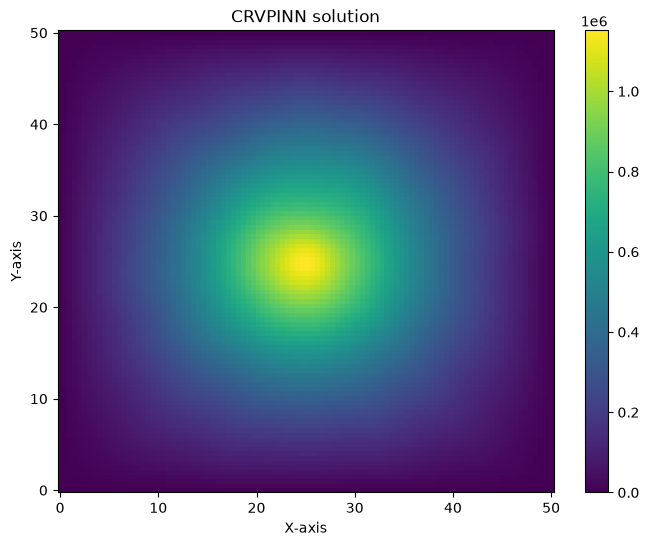

Training time : 1.964099
Starting simulation iteration 15/20


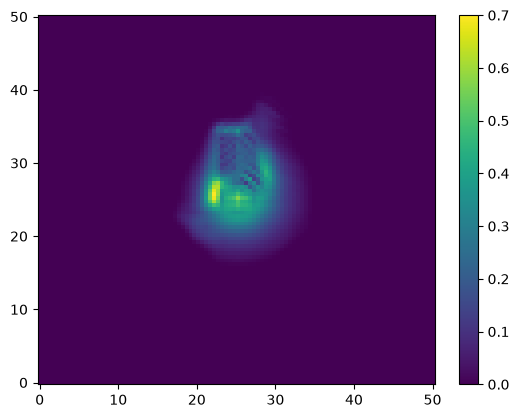

Epoch: 100 - Loss: 1.689e-03; total runtime: 2.4869863986968994 (forward: 0.8462405204772949 grad: 1.3225493431091309 opt: 0.0647425651550293); time per epoch: 0.024869863986968995;


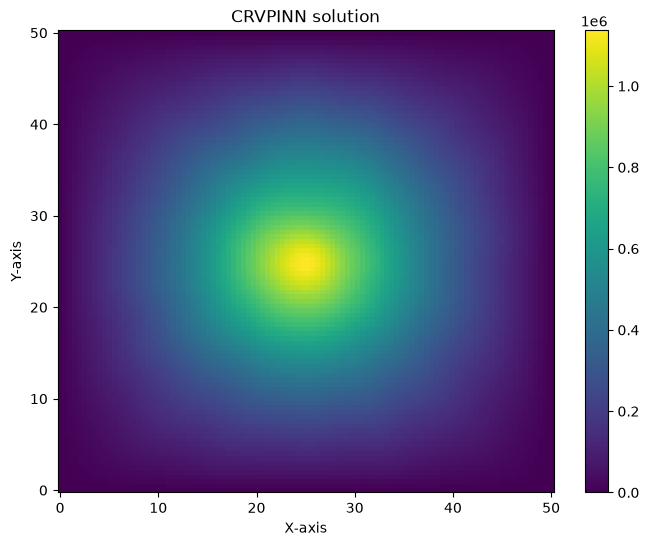

Training time : 2.837294
Starting simulation iteration 16/20


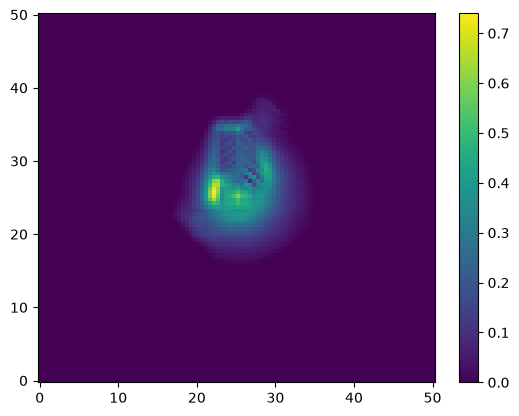

Epoch: 100 - Loss: 1.675e-03; total runtime: 2.6881377696990967 (forward: 0.9068145751953125 grad: 1.466484785079956 opt: 0.061818838119506836); time per epoch: 0.026881377696990966;


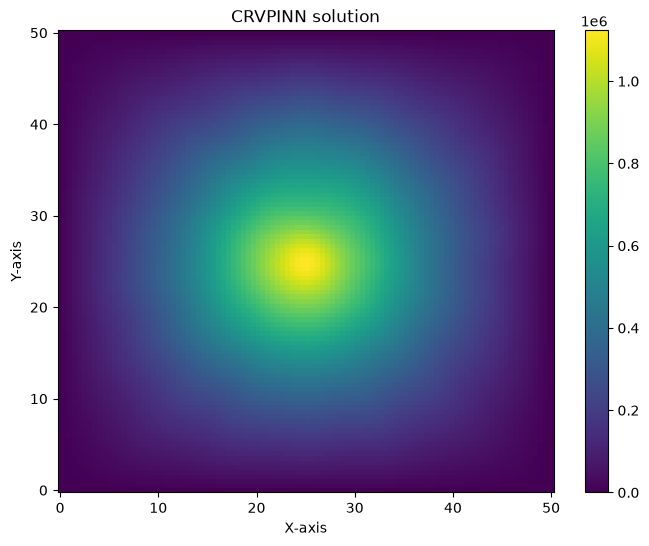

Training time : 3.053662
Starting simulation iteration 17/20


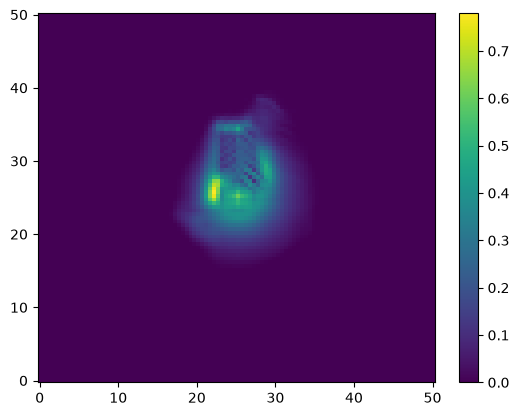

Epoch: 100 - Loss: 1.623e-03; total runtime: 1.5269100666046143 (forward: 0.46497321128845215 grad: 0.7509076595306396 opt: 0.03358149528503418); time per epoch: 0.015269100666046143;


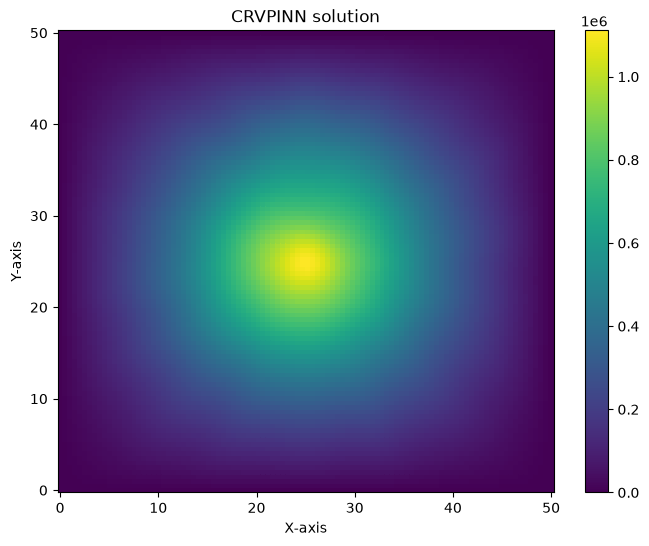

Training time : 1.971924
Starting simulation iteration 18/20


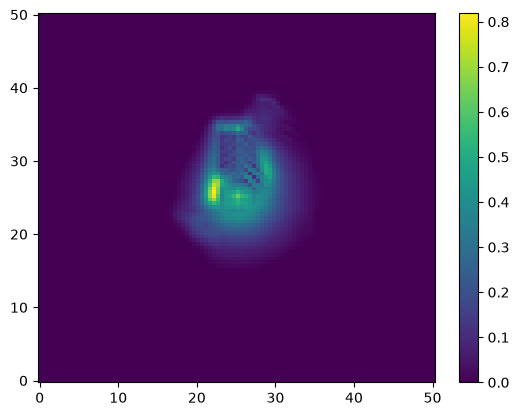

Epoch: 100 - Loss: 1.652e-03; total runtime: 1.515047550201416 (forward: 0.46175622940063477 grad: 0.7466309070587158 opt: 0.0331878662109375); time per epoch: 0.01515047550201416;


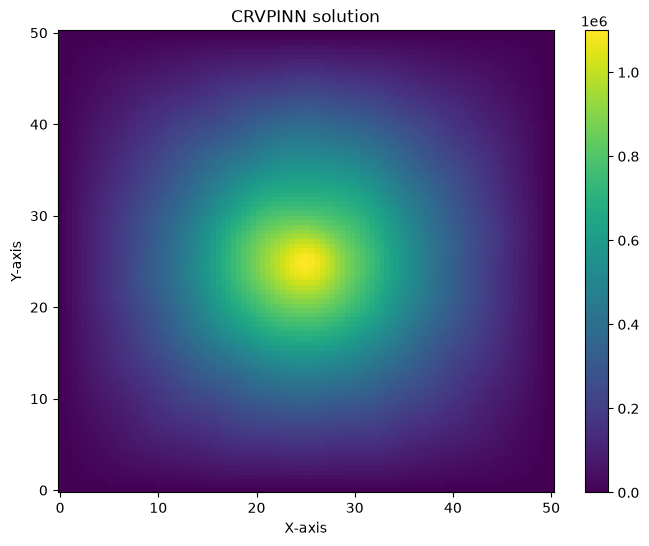

Training time : 1.955618
Starting simulation iteration 19/20


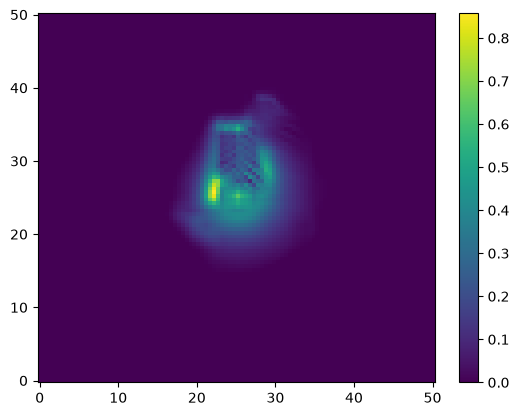

Epoch: 100 - Loss: 1.690e-03; total runtime: 1.5417754650115967 (forward: 0.4679527282714844 grad: 0.7594945430755615 opt: 0.034986257553100586); time per epoch: 0.015417754650115967;


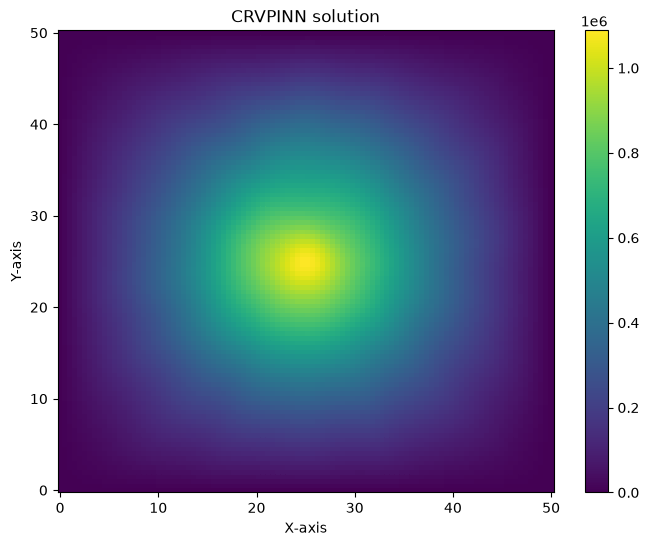

Training time : 1.986050
Starting simulation iteration 20/20


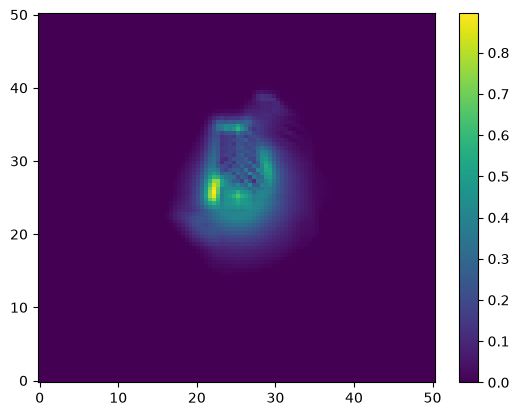

Epoch: 100 - Loss: 1.671e-03; total runtime: 1.5332448482513428 (forward: 0.4604172706604004 grad: 0.7569000720977783 opt: 0.03542518615722656); time per epoch: 0.015332448482513427;


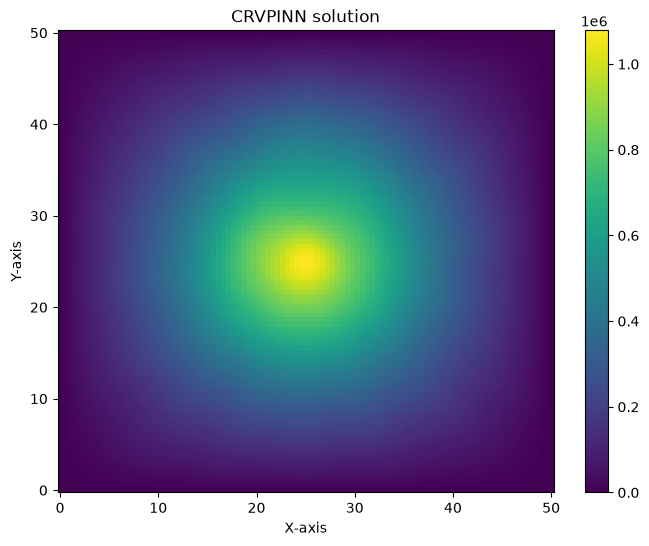

Training time : 1.977412
Total training time for 20 iterations: 46.732945


In [59]:
pinn_trained, loss_values_cont = continue_training(pinn, x, t, n_it_simulation=20, folder_name='uniformK3')

Text(0.5, 1.0, 'CRVPINN solution at 19th time step')

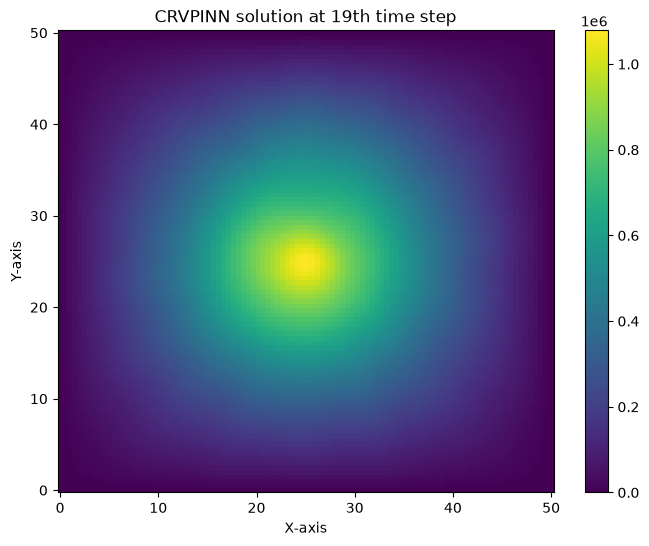

In [60]:
z_190 = f(pinn_trained.to(device), x, t)
color = plot_color(z_190.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)
plt.title('CRVPINN solution at 19th time step')

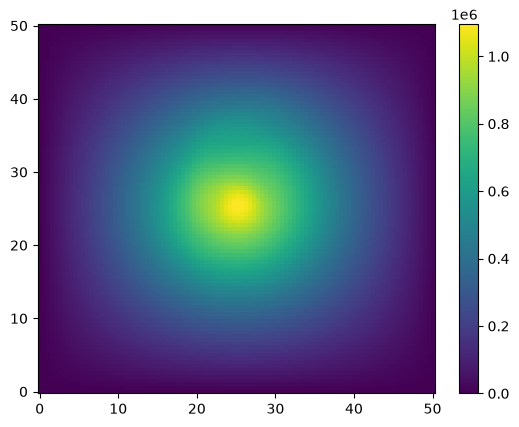

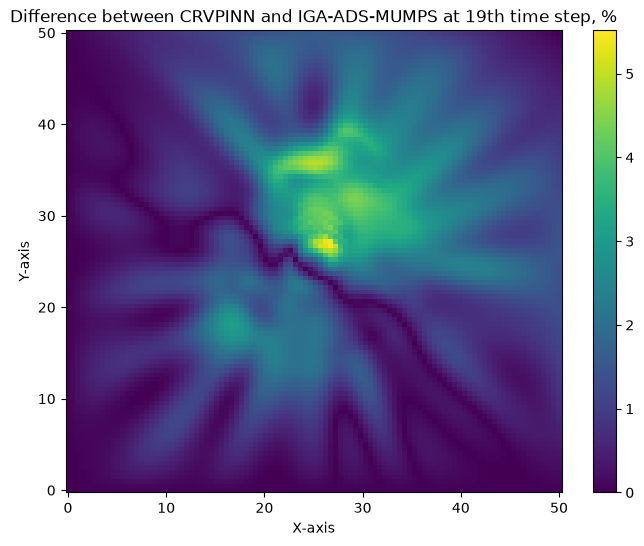

In [61]:
compare_with_iga(z_190, it_simulation=19, folder='uniformK3') #, err_bounds = (0, 5.5))

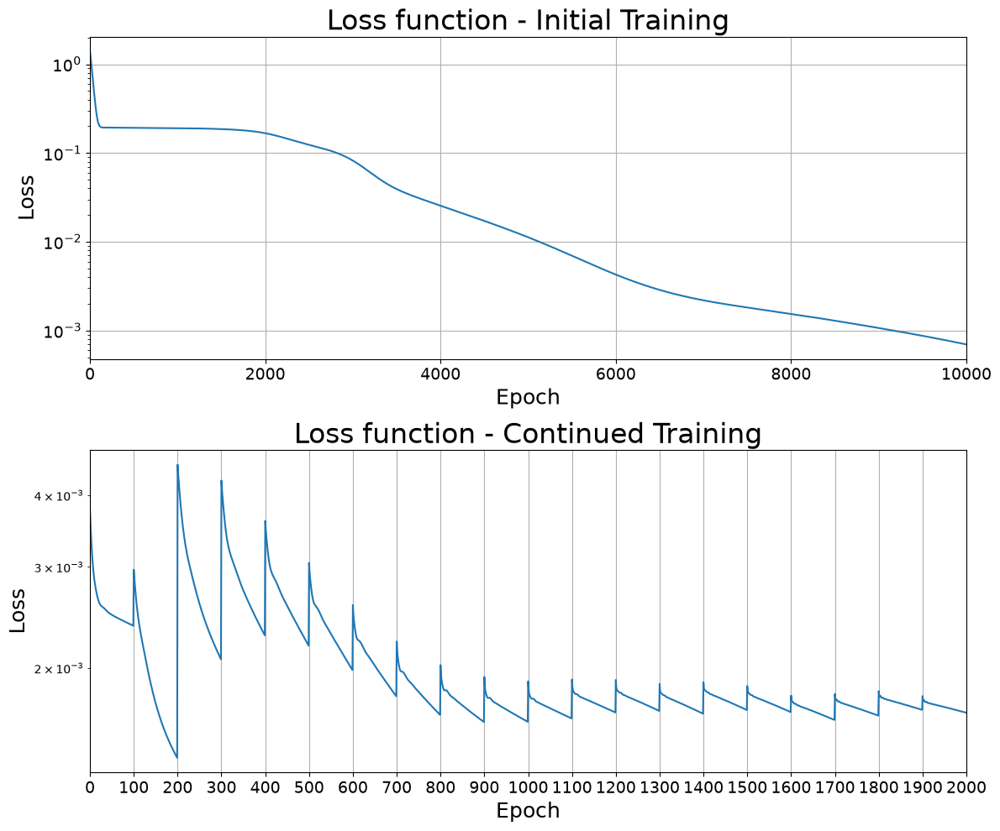

In [62]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.set_title("Loss function - Initial Training", fontsize = 24)
ax1.set_xlabel("Epoch", fontsize = 18)
ax1.set_ylabel("Loss", fontsize = 18)
ax1.set_yscale("log")
ax1.set_xlim(0, EPOCHS)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.plot(loss_values)
ax1.grid(True)

ax2.set_title("Loss function - Continued Training", fontsize = 24)
ax2.set_xlabel("Epoch", fontsize = 18)
ax2.set_ylabel("Loss", fontsize = 18)
ax2.set_yscale("log")
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_xlim(0, len(loss_values_cont))
ax2.set_xticks(np.arange(0, len(loss_values_cont)+1, step=100))
ax2.plot(loss_values_cont)
ax2.grid(True)

plt.tight_layout()

# PINN Training with non-uniform K1 permeability map

In [63]:
perm_k1_tensor = torch.tensor(perm_k1_interp, device=device, dtype=torch.float32)

darcy_to_si = 1e-15
gamma = 1e6 
corr_coeff = 0.68
qg_rate = 5e-6 

K_array = perm_k1_tensor[np.ix_(row_indices, col_indices)] * darcy_to_si * gamma
K_tensor = torch.tensor(K_array, device=device, requires_grad=True)
K_function = make_fun(x_lin, y_lin, K_tensor.T)

/tmp/ipykernel_53314/1956505333.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  K_tensor = torch.tensor(K_array, device=device, requires_grad=True)


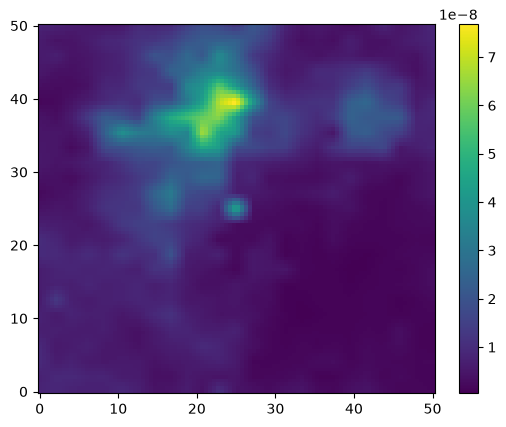

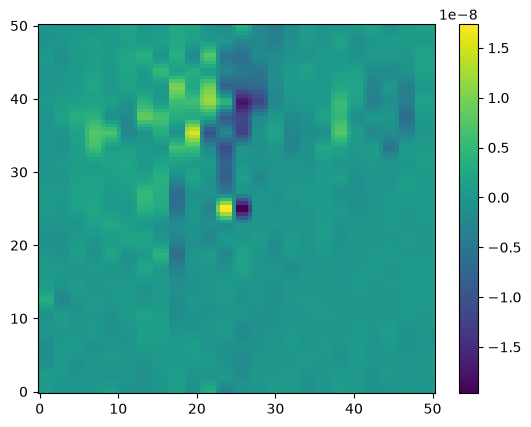

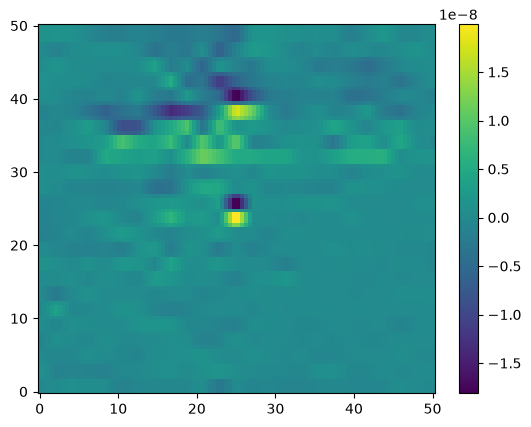

In [64]:
orginalK = K_function(x_plot, y_plot)
plotly(x_plot, y_plot, orginalK)
orginalK.shape

dfK  = df(K_function(x_plot, y_plot), x_plot)
plotly(x_plot, y_plot, dfK)

dfKy  = df(K_function(x_plot, y_plot), y_plot)
plotly(x_plot, y_plot, dfKy)

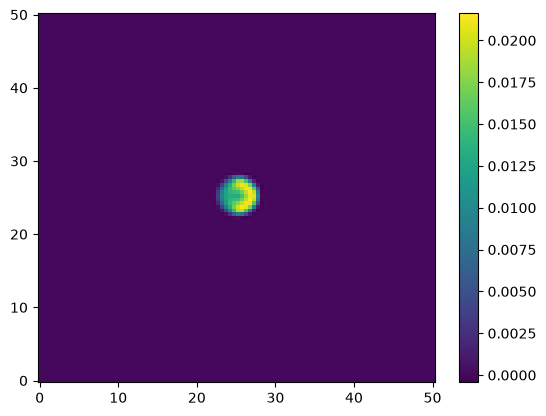

In [65]:
saturation_array = data_reader_s(f'perm_map_k1/s.out_0.data', step_size=0.5) 
Sg_tensor = torch.tensor(saturation_array.copy(), device=device, requires_grad=True)
Sg_function = make_fun(x_lin, y_lin, Sg_tensor)
plotly(x_plot, y_plot, Sg_function(x_plot, y_plot))

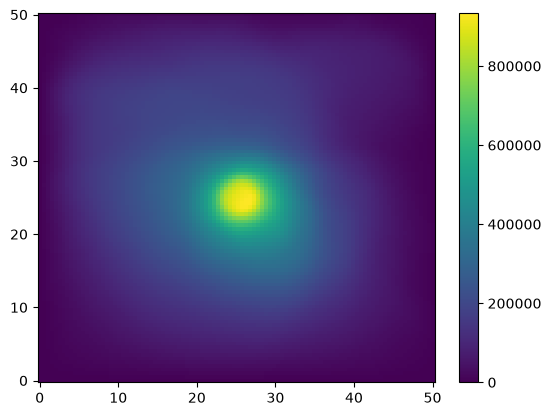

In [66]:
pressure_array = data_reader_s('perm_map_k1/p.out_0.data', step_size=0.5, size_x=LENGTH, size_y=TOTAL_TIME)
P_tensor = torch.tensor(pressure_array.copy(), device=device)
P_function = make_fun(x_lin, y_lin, P_tensor)
plotly(x_plot, y_plot, P_function(x_plot, y_plot))

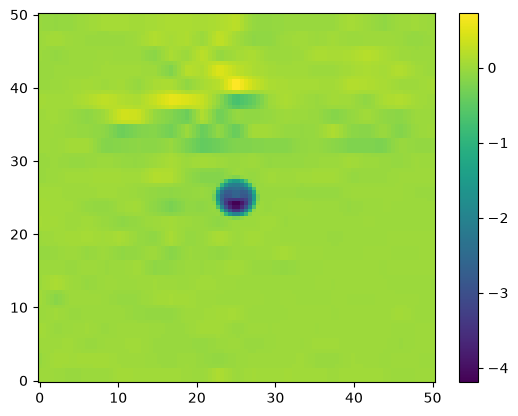

In [67]:
plotly(x_plot, y_plot, RHS(x_plot, y_plot))

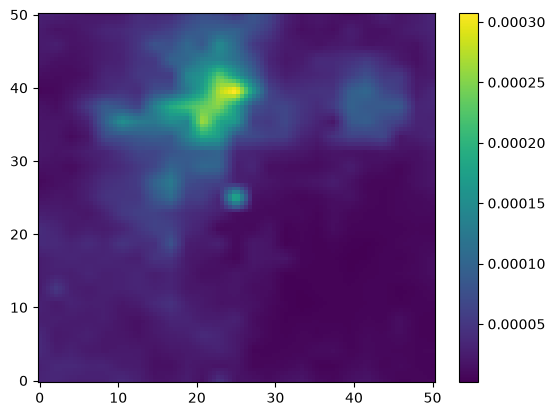

In [68]:
plotly(x_plot, y_plot, alpha(x_plot, y_plot))

Epoch: 1000 - Loss: 5.915e+00; total runtime: 3.319139242172241 (forward: 0.9442157745361328 grad: 1.8059206008911133 opt: 0.397305965423584); time per epoch: 0.003319139242172241;


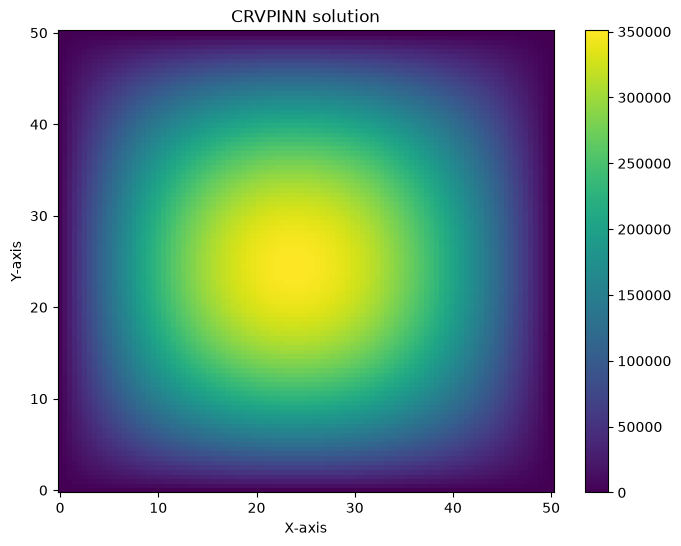

Epoch: 2000 - Loss: 5.240e+00; total runtime: 4.935408353805542 (forward: 1.4017624855041504 grad: 2.6888206005096436 opt: 0.575573205947876); time per epoch: 0.002467704176902771;


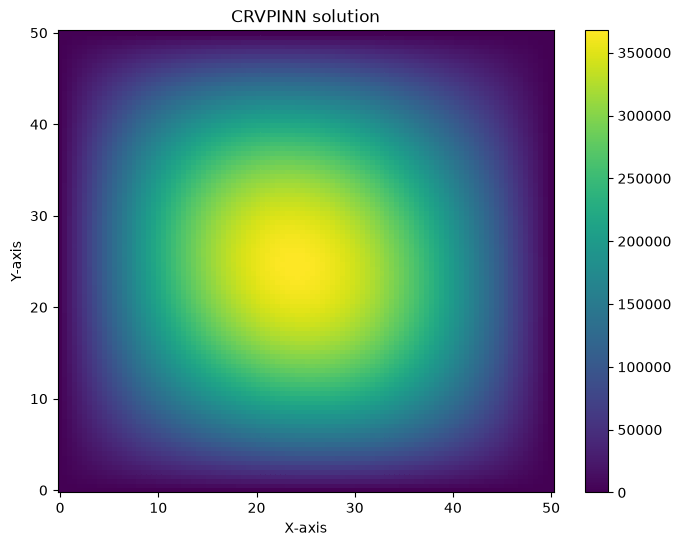

Epoch: 3000 - Loss: 2.781e+00; total runtime: 6.533489227294922 (forward: 1.8524925708770752 grad: 3.560997247695923 opt: 0.753046989440918); time per epoch: 0.0021778297424316405;


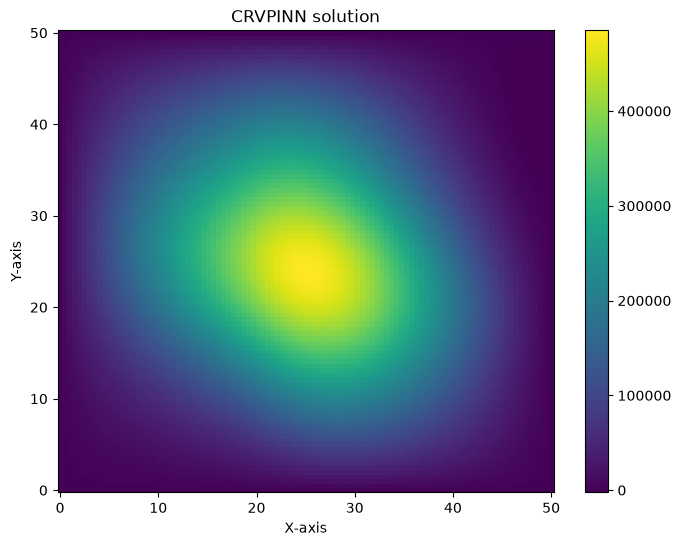

Epoch: 4000 - Loss: 1.169e+00; total runtime: 8.173660278320312 (forward: 2.3162572383880615 grad: 4.460514068603516 opt: 0.9346094131469727); time per epoch: 0.002043415069580078;


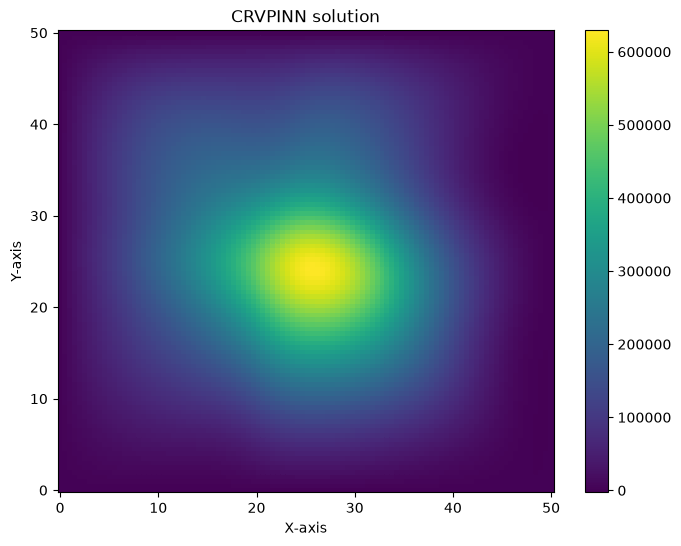

Epoch: 5000 - Loss: 4.182e-01; total runtime: 9.77107548713684 (forward: 2.769632339477539 grad: 5.3329925537109375 opt: 1.112060308456421); time per epoch: 0.0019542150974273683;


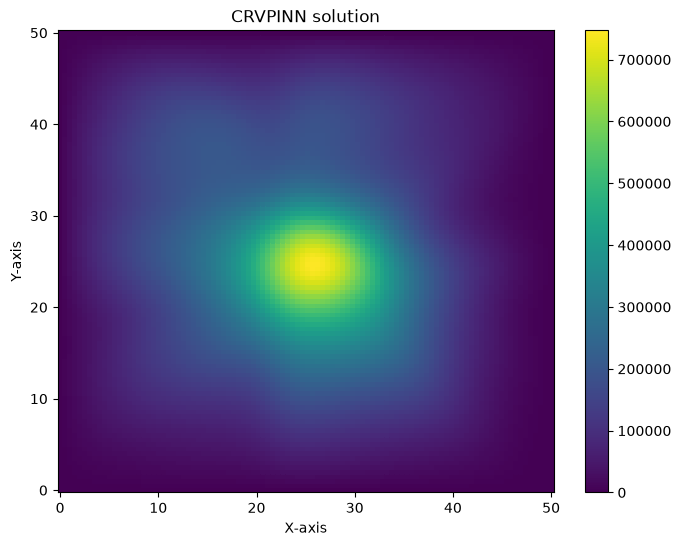

Epoch: 6000 - Loss: 1.708e-01; total runtime: 11.36166000366211 (forward: 3.2180464267730713 grad: 6.2038233280181885 opt: 1.2879064083099365); time per epoch: 0.0018936100006103516;


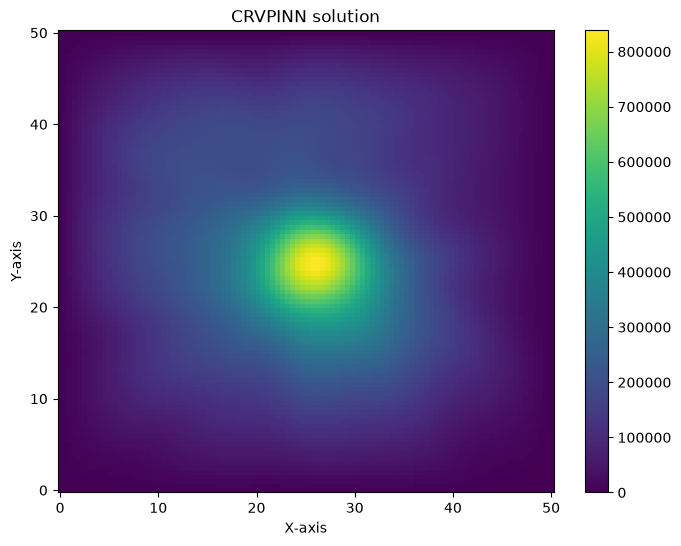

Epoch: 7000 - Loss: 1.115e-01; total runtime: 13.009469985961914 (forward: 3.6783382892608643 grad: 7.0937511920928955 opt: 1.4711439609527588); time per epoch: 0.0018584957122802733;


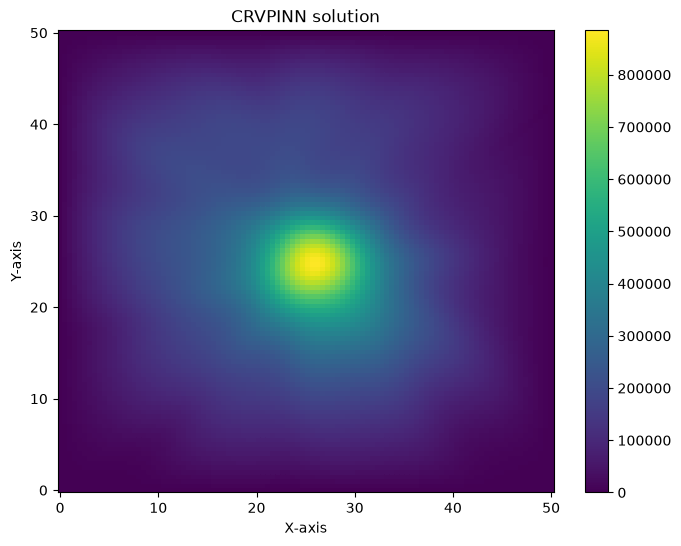

Epoch: 8000 - Loss: 8.765e-02; total runtime: 14.73943829536438 (forward: 4.1599931716918945 grad: 8.02056360244751 opt: 1.6656436920166016); time per epoch: 0.0018424297869205474;


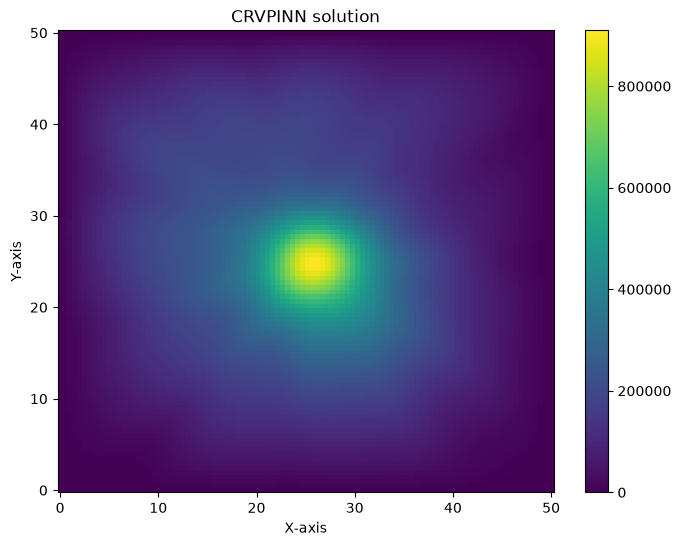

Epoch: 9000 - Loss: 6.779e-02; total runtime: 16.417832374572754 (forward: 4.624831438064575 grad: 8.917943716049194 opt: 1.8507351875305176); time per epoch: 0.0018242035971747503;


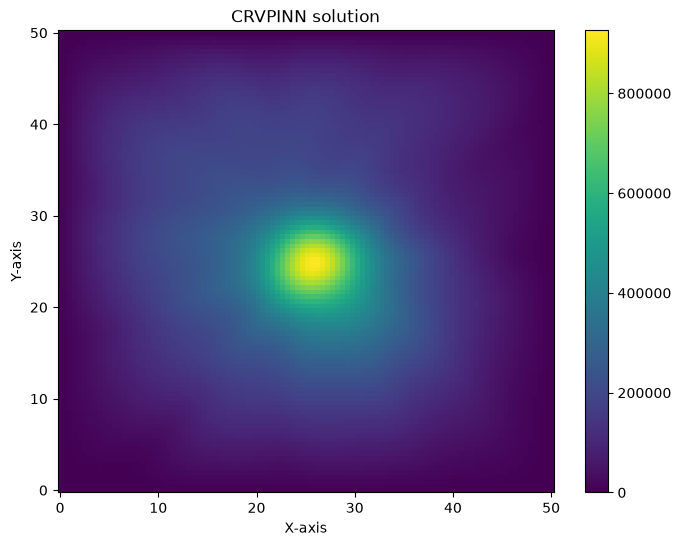

Epoch: 10000 - Loss: 5.660e-02; total runtime: 19.940704822540283 (forward: 5.626152515411377 grad: 10.794097900390625 opt: 2.2927181720733643); time per epoch: 0.0019940704822540285;


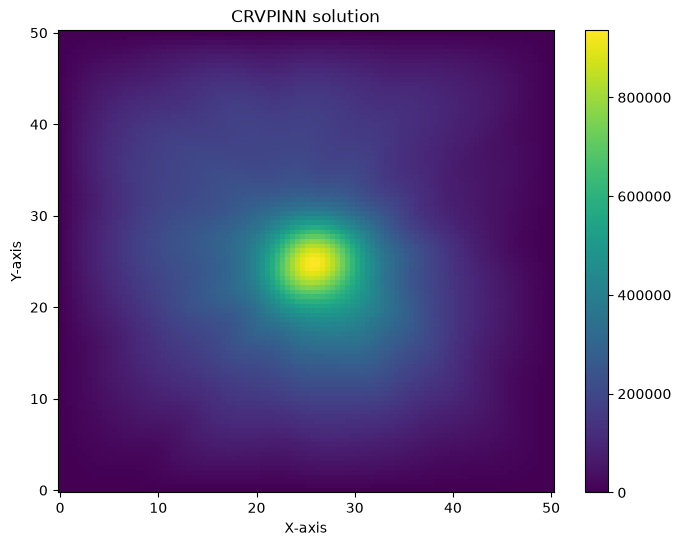

Training time : 22.028348


In [69]:
pinn = None
pinn = PINN(LAYERS, NEURONS_PER_LAYER, pinning=True, act=nn.Tanh()).to(device)

# train the PINN
time_train0 = time.time()

loss_fn = partial(compute_loss, x=x, t=t, w_physics=0, w_data=10)
pinn_trained, loss_values = train_model(
    pinn, x, t, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=EPOCHS)
time_train1 = time.time()

print(f'Training time : %f'%(time_train1 - time_train0))

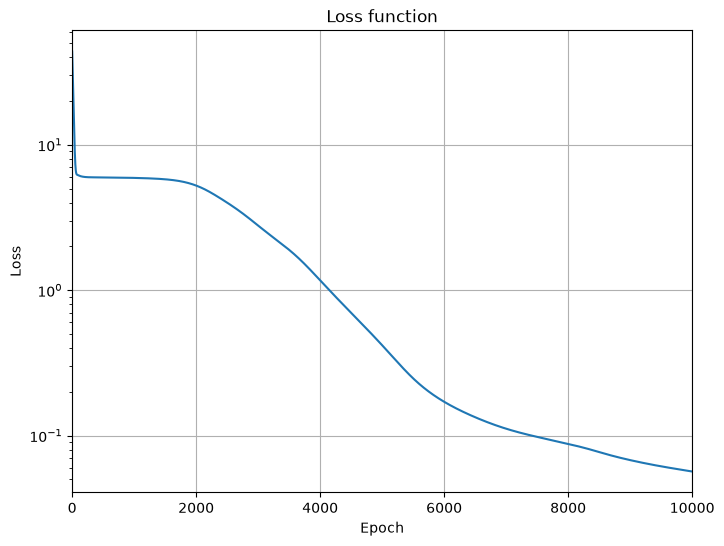

In [70]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
ax.plot(loss_values)
plt.grid(True)

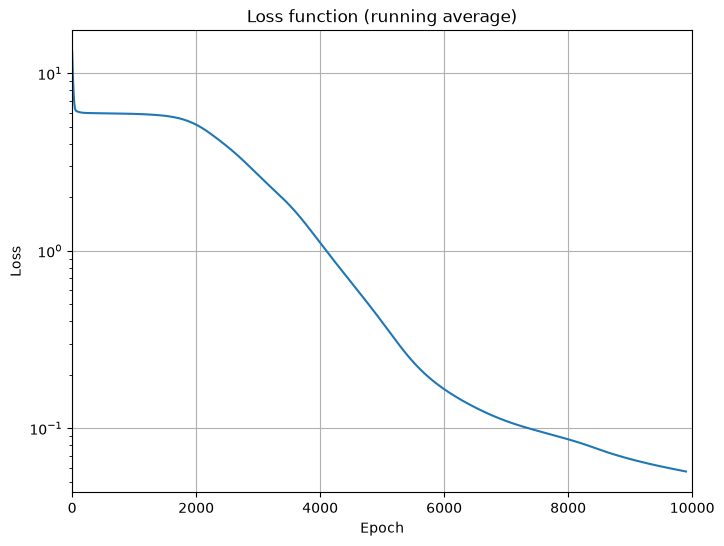

In [71]:
average_loss = running_average(loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
plt.grid(True)
ax.plot(average_loss)

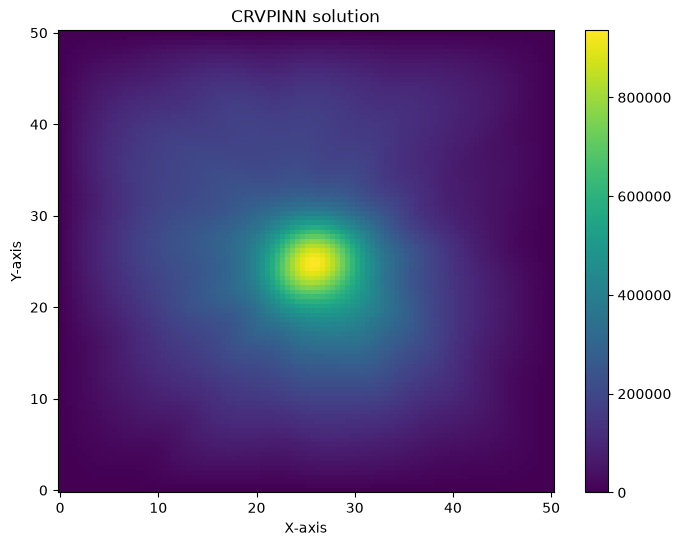

In [72]:
z_0 = f(pinn_trained.to(device), x, t)
color = plot_color(z_0.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)

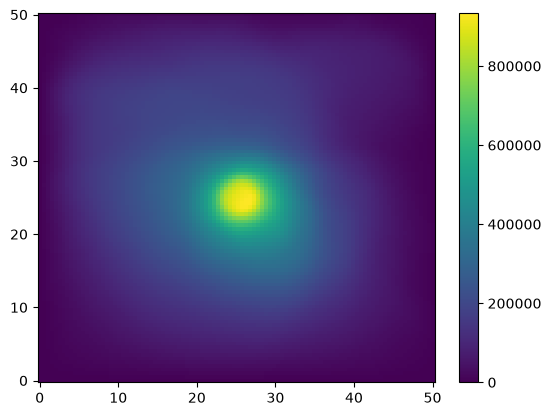

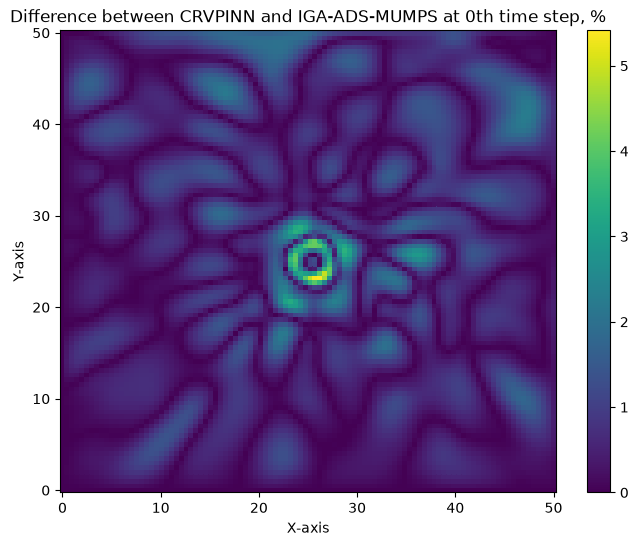

In [73]:
compare_with_iga(z_0, it_simulation=0, folder='perm_map_k1') #, err_bounds=(0,25))

Starting simulation iteration 1/20


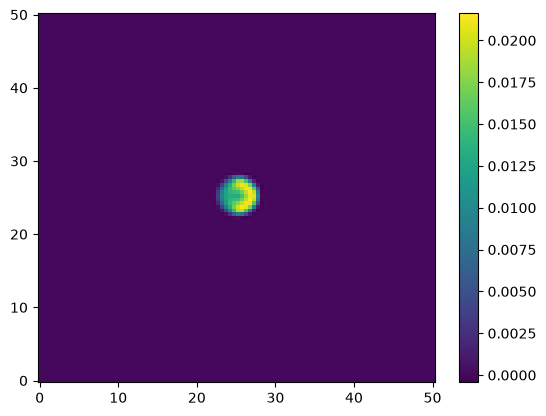

Epoch: 100 - Loss: 5.696e-01; total runtime: 2.7676637172698975 (forward: 0.8905386924743652 grad: 1.5570018291473389 opt: 0.06848597526550293); time per epoch: 0.027676637172698974;


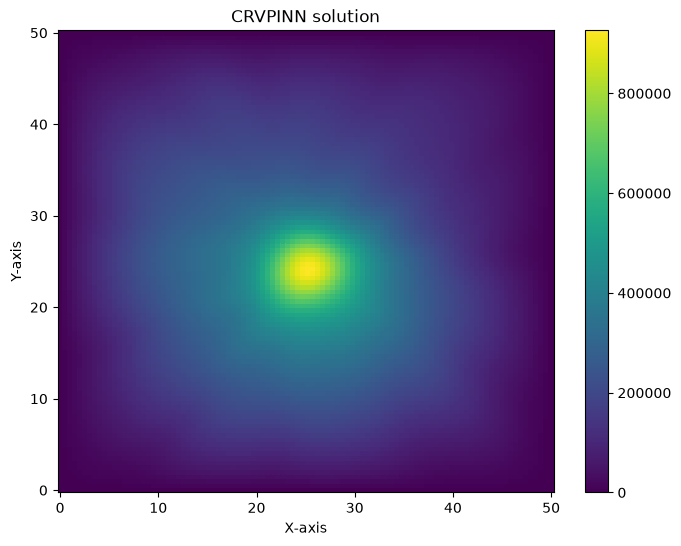

Training time : 2.957606
Starting simulation iteration 2/20


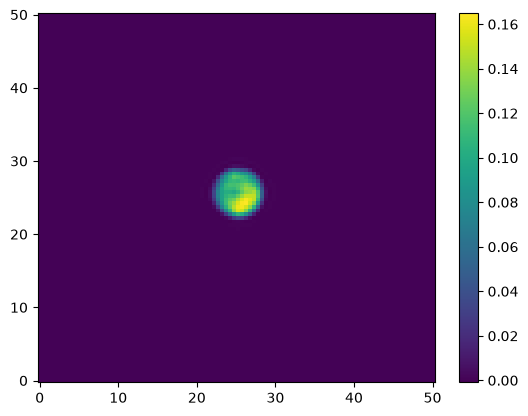

Epoch: 100 - Loss: 6.100e-01; total runtime: 2.3188812732696533 (forward: 0.7045009136199951 grad: 1.2935795783996582 opt: 0.05585837364196777); time per epoch: 0.02318881273269653;


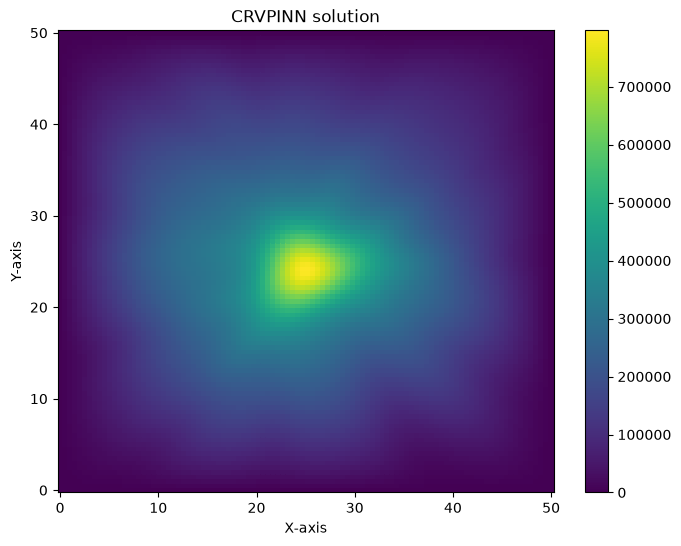

Training time : 2.807334
Starting simulation iteration 3/20


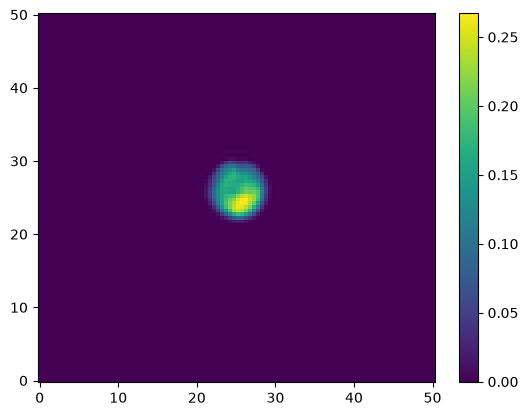

Epoch: 100 - Loss: 4.825e-01; total runtime: 2.1315083503723145 (forward: 0.6305384635925293 grad: 1.175102710723877 opt: 0.0506594181060791); time per epoch: 0.021315083503723145;


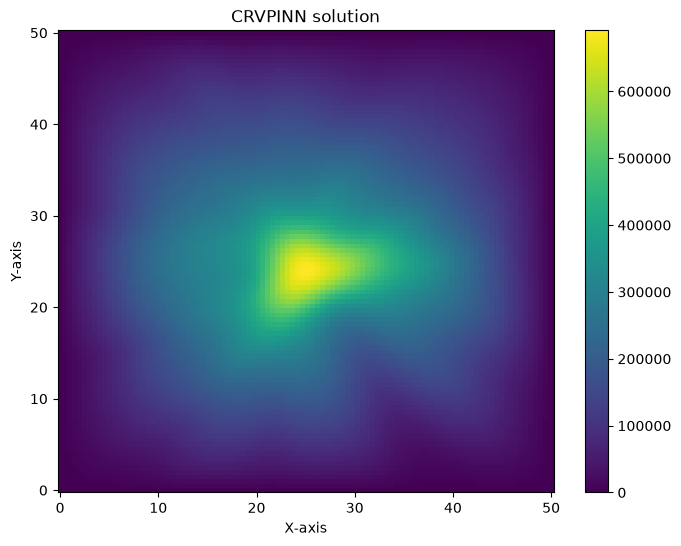

Training time : 2.455066
Starting simulation iteration 4/20


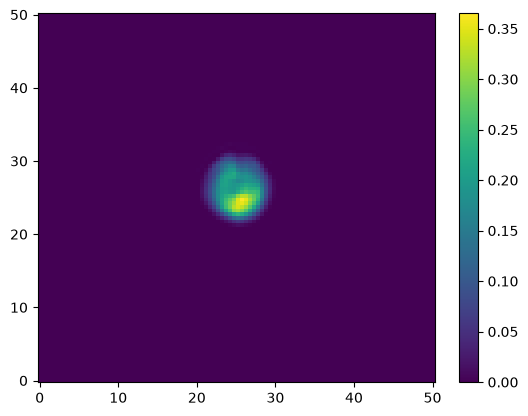

Epoch: 100 - Loss: 3.729e-01; total runtime: 2.3617496490478516 (forward: 0.7283935546875 grad: 1.315324068069458 opt: 0.056620121002197266); time per epoch: 0.023617496490478517;


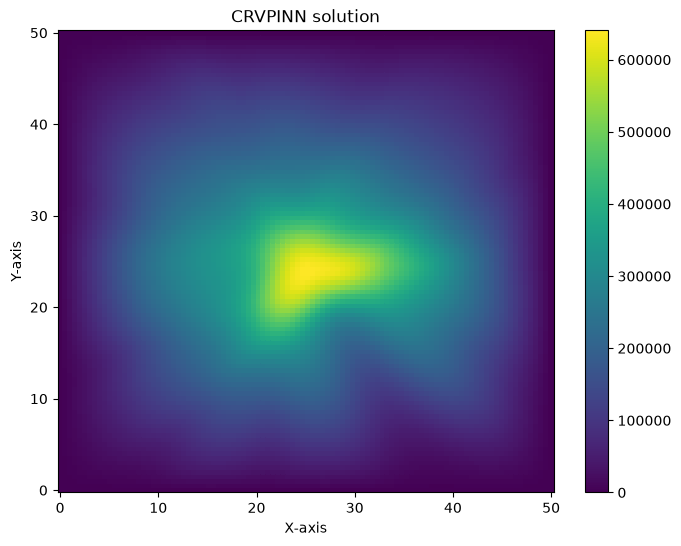

Training time : 2.565308
Starting simulation iteration 5/20


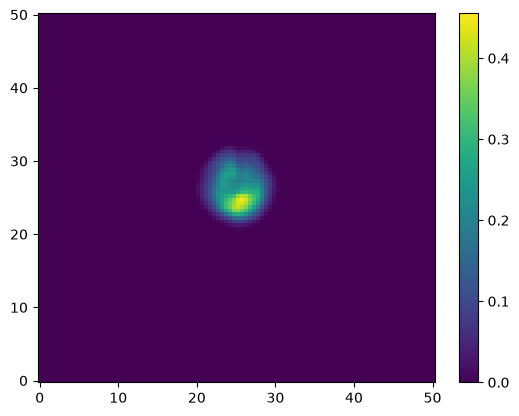

Epoch: 100 - Loss: 2.940e-01; total runtime: 2.102936029434204 (forward: 0.6239147186279297 grad: 1.1578826904296875 opt: 0.0457768440246582); time per epoch: 0.02102936029434204;


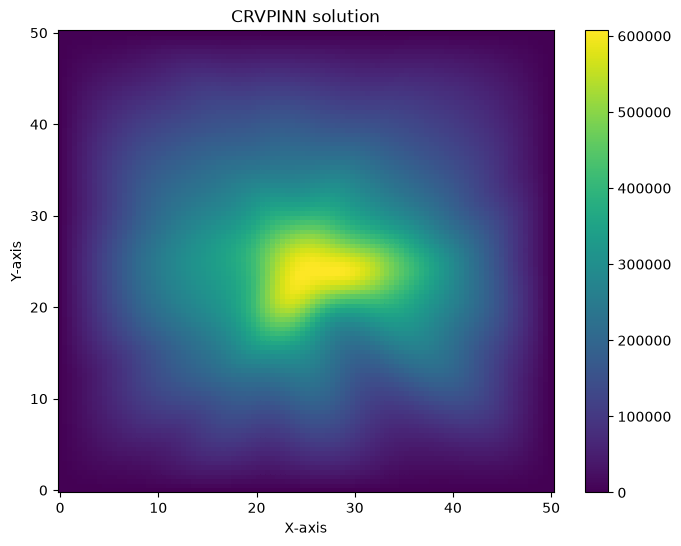

Training time : 2.429209
Starting simulation iteration 6/20


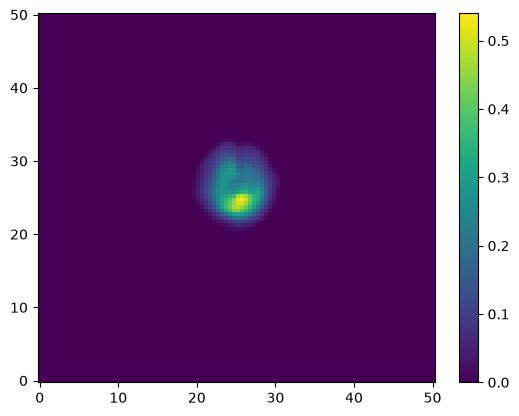

Epoch: 100 - Loss: 2.392e-01; total runtime: 1.979921817779541 (forward: 0.5699083805084229 grad: 1.0929980278015137 opt: 0.04071640968322754); time per epoch: 0.01979921817779541;


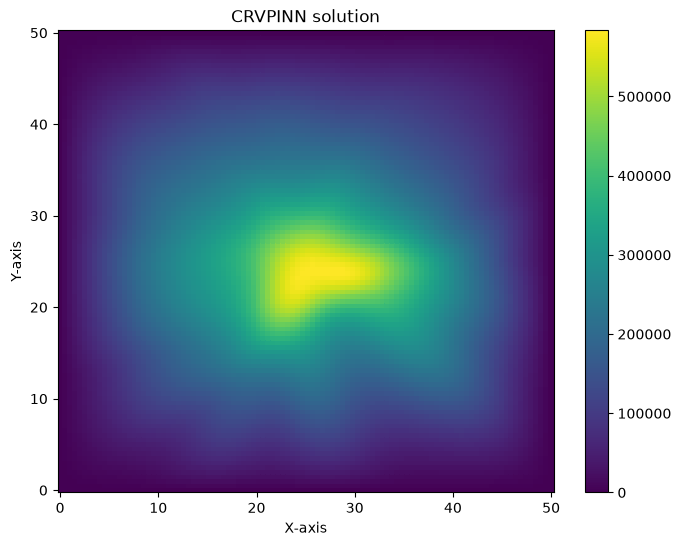

Training time : 2.331058
Starting simulation iteration 7/20


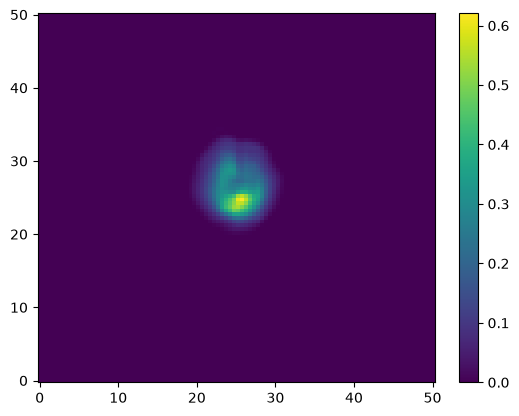

Epoch: 100 - Loss: 2.055e-01; total runtime: 2.0308823585510254 (forward: 0.5912859439849854 grad: 1.1157245635986328 opt: 0.045060157775878906); time per epoch: 0.020308823585510255;


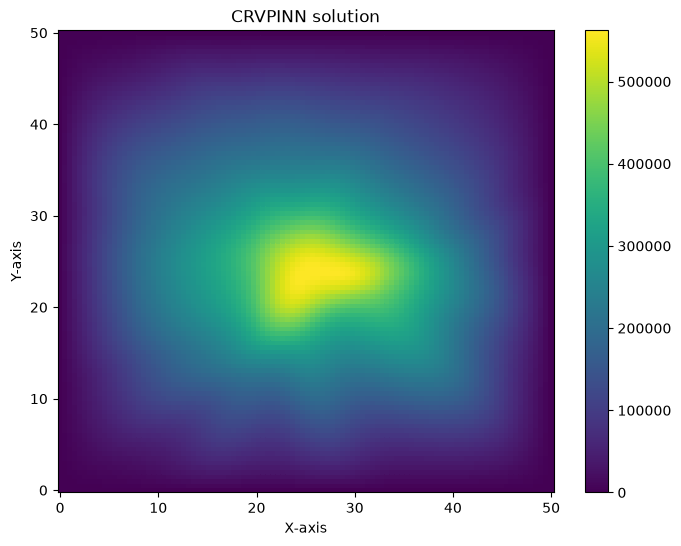

Training time : 2.371164
Starting simulation iteration 8/20


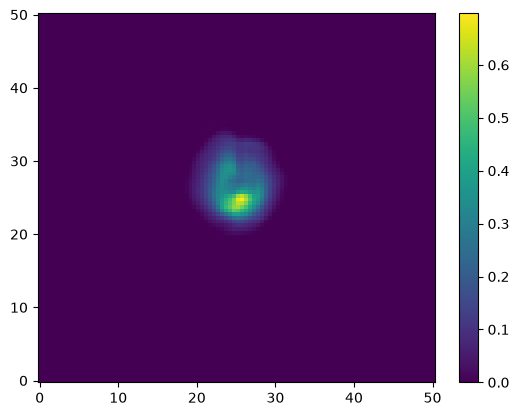

Epoch: 100 - Loss: 1.871e-01; total runtime: 2.9314582347869873 (forward: 0.9397485256195068 grad: 1.6757090091705322 opt: 0.07028031349182129); time per epoch: 0.029314582347869874;


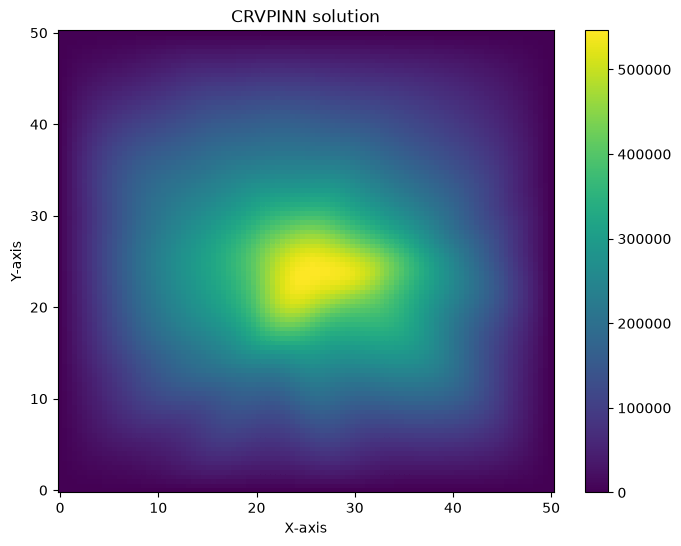

Training time : 3.068986
Starting simulation iteration 9/20


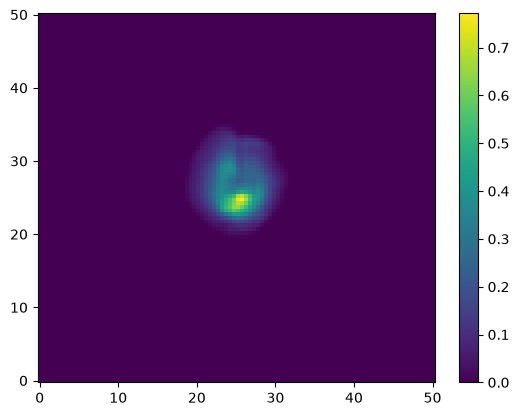

Epoch: 100 - Loss: 1.778e-01; total runtime: 2.4615914821624756 (forward: 0.7700281143188477 grad: 1.3774724006652832 opt: 0.05871391296386719); time per epoch: 0.024615914821624757;


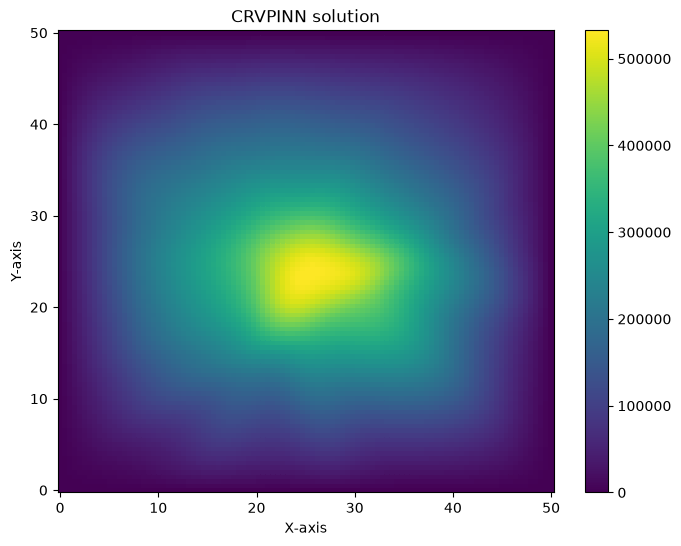

Training time : 2.951020
Starting simulation iteration 10/20


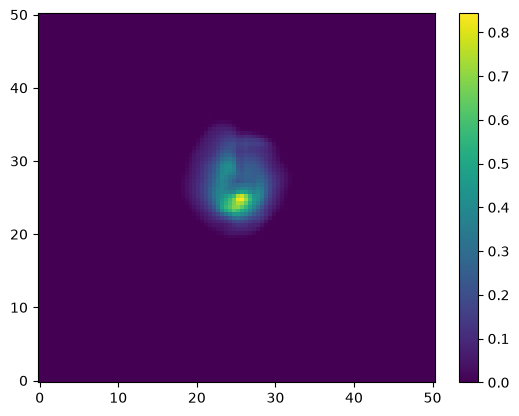

Epoch: 100 - Loss: 1.725e-01; total runtime: 2.142698049545288 (forward: 0.6295876502990723 grad: 1.1881325244903564 opt: 0.044464111328125); time per epoch: 0.021426980495452882;


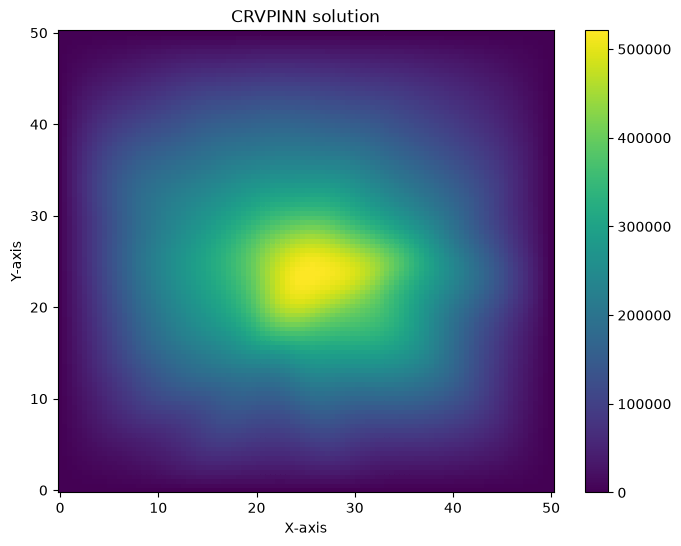

Training time : 2.435169
Starting simulation iteration 11/20


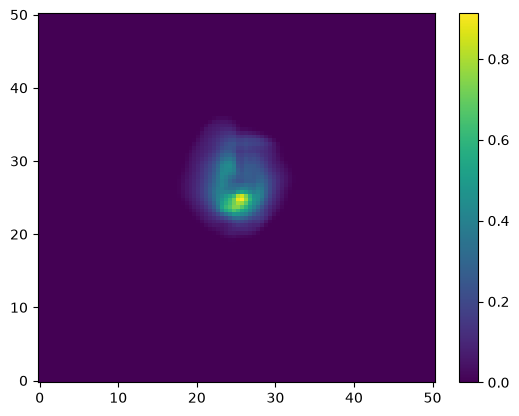

Epoch: 100 - Loss: 1.683e-01; total runtime: 1.9525363445281982 (forward: 0.5646629333496094 grad: 1.0757472515106201 opt: 0.04010915756225586); time per epoch: 0.019525363445281982;


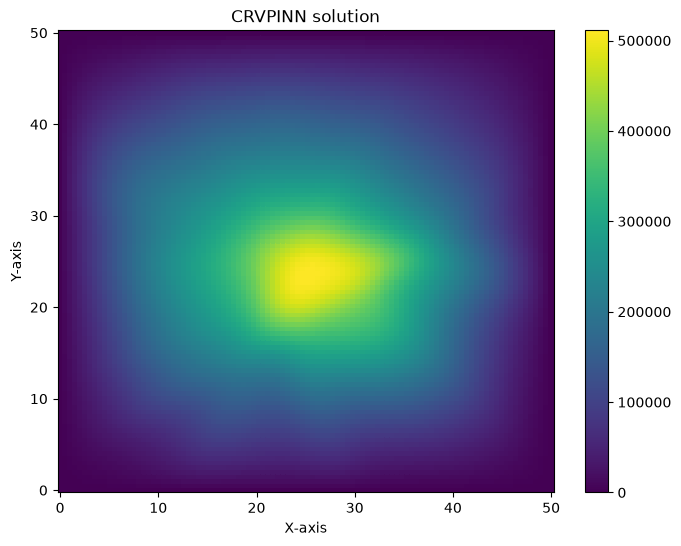

Training time : 2.288681
Starting simulation iteration 12/20


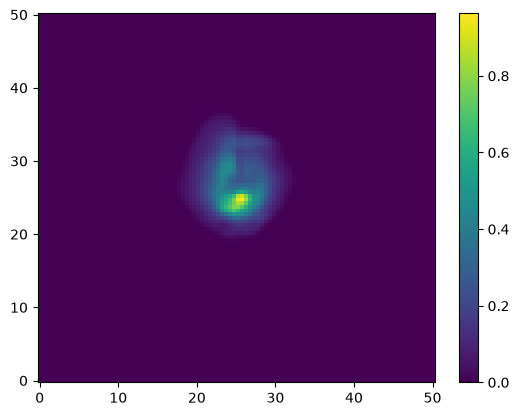

Epoch: 100 - Loss: 1.644e-01; total runtime: 1.9859108924865723 (forward: 0.5759894847869873 grad: 1.0891187191009521 opt: 0.04228520393371582); time per epoch: 0.019859108924865723;


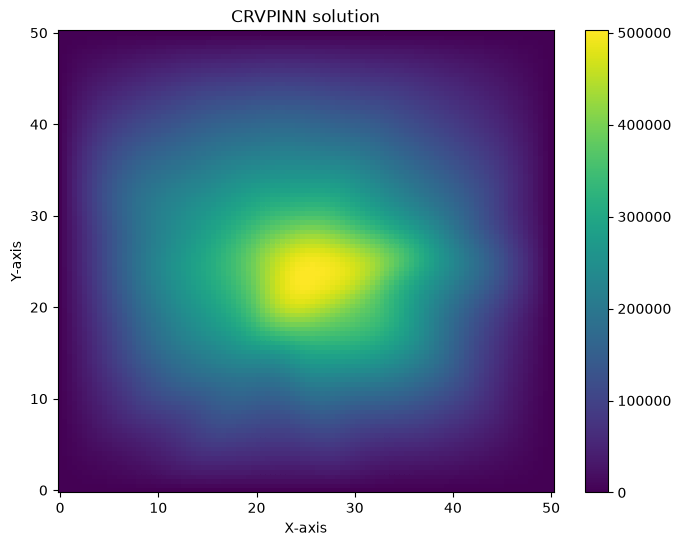

Training time : 2.339181
Starting simulation iteration 13/20


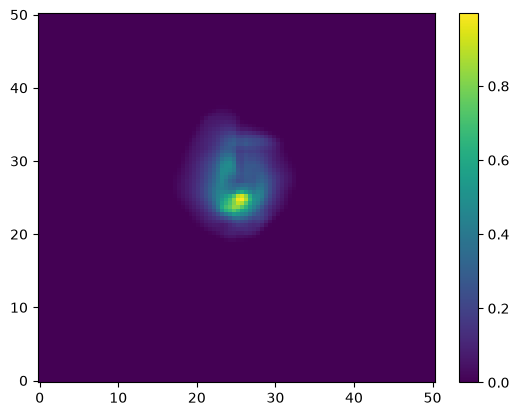

Epoch: 100 - Loss: 1.607e-01; total runtime: 1.9508206844329834 (forward: 0.5723905563354492 grad: 1.0734748840332031 opt: 0.042038679122924805); time per epoch: 0.019508206844329835;


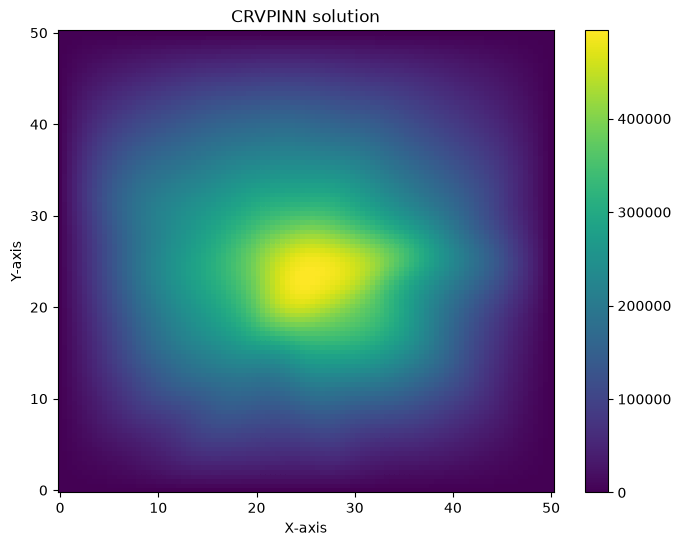

Training time : 2.253456
Starting simulation iteration 14/20


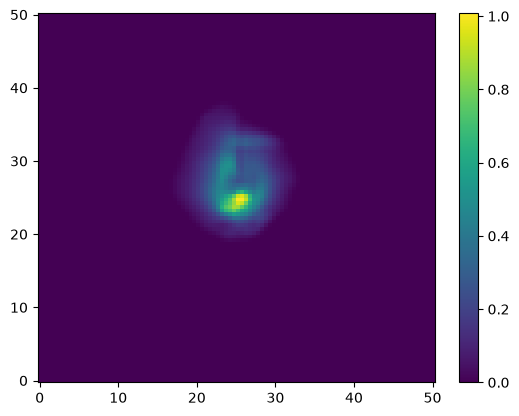

Epoch: 100 - Loss: 1.569e-01; total runtime: 3.023855447769165 (forward: 0.9753091335296631 grad: 1.7478153705596924 opt: 0.0704803466796875); time per epoch: 0.03023855447769165;


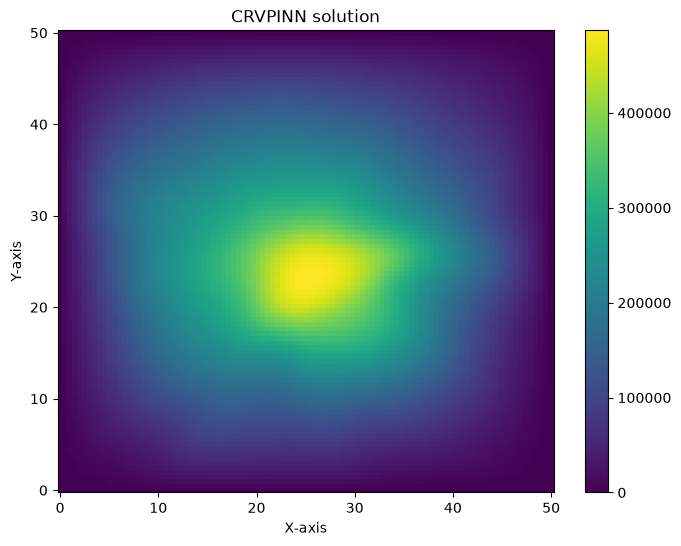

Training time : 3.166478
Starting simulation iteration 15/20


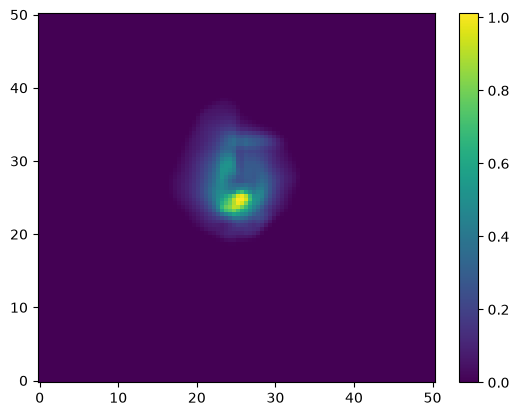

Epoch: 100 - Loss: 1.526e-01; total runtime: 2.277013063430786 (forward: 0.684441328048706 grad: 1.2831881046295166 opt: 0.05029559135437012); time per epoch: 0.022770130634307863;


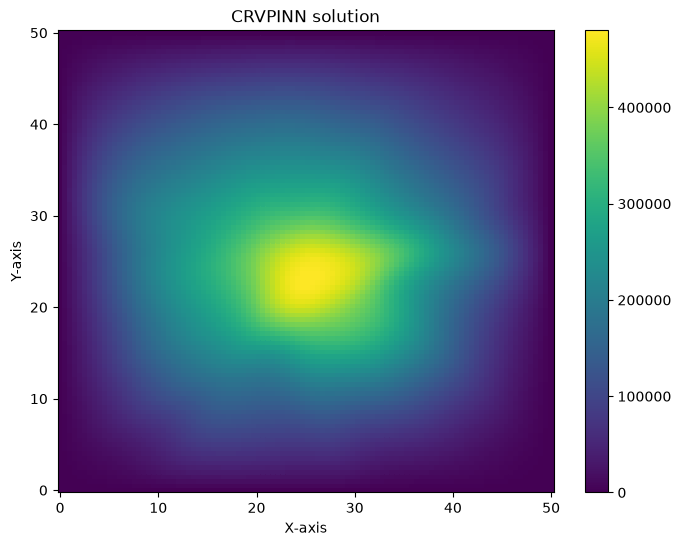

Training time : 2.567877
Starting simulation iteration 16/20


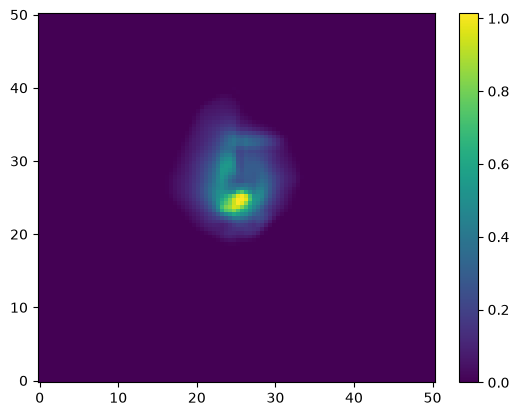

Epoch: 100 - Loss: 1.481e-01; total runtime: 2.664011001586914 (forward: 0.8241448402404785 grad: 1.51454758644104 opt: 0.06375718116760254); time per epoch: 0.02664011001586914;


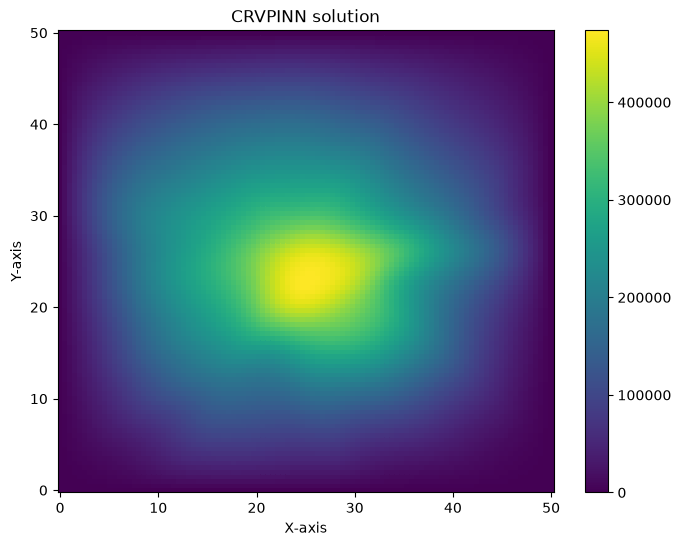

Training time : 2.886349
Starting simulation iteration 17/20


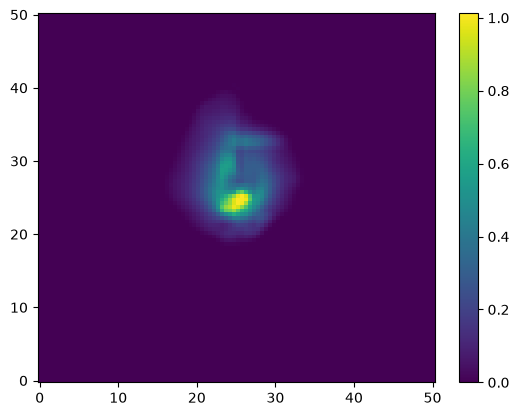

Epoch: 100 - Loss: 1.443e-01; total runtime: 2.1140639781951904 (forward: 0.610154390335083 grad: 1.1698005199432373 opt: 0.04606437683105469); time per epoch: 0.021140639781951905;


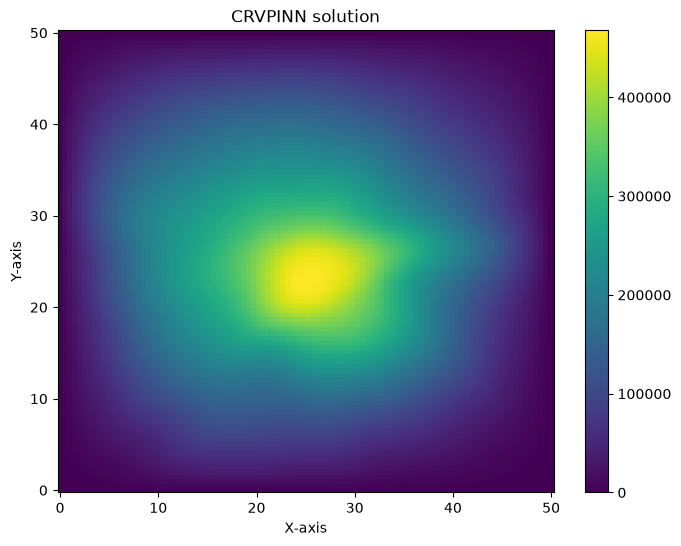

Training time : 2.444464
Starting simulation iteration 18/20


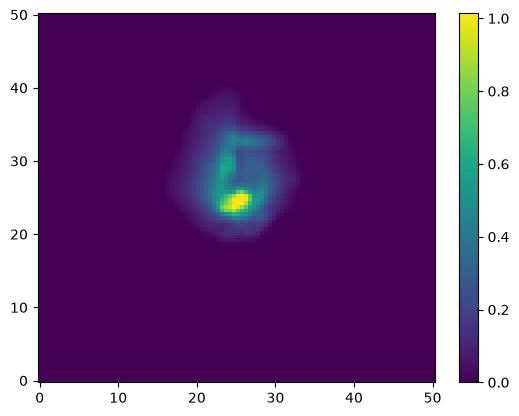

Epoch: 100 - Loss: 1.413e-01; total runtime: 2.287816286087036 (forward: 0.704420804977417 grad: 1.2555606365203857 opt: 0.05749392509460449); time per epoch: 0.02287816286087036;


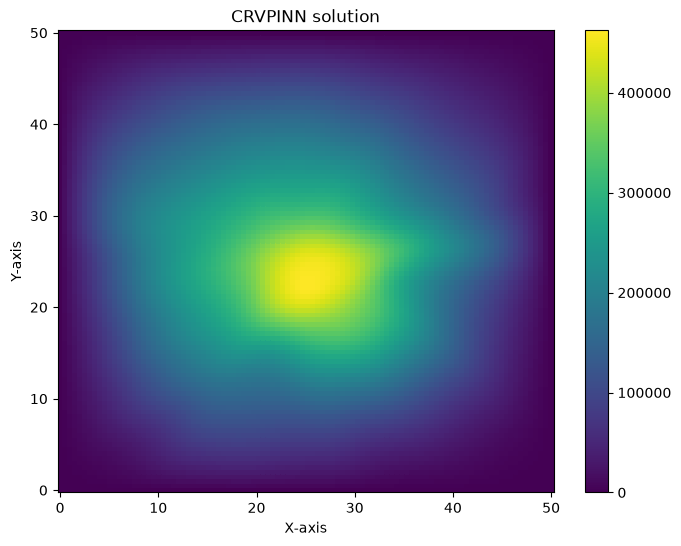

Training time : 2.518737
Starting simulation iteration 19/20


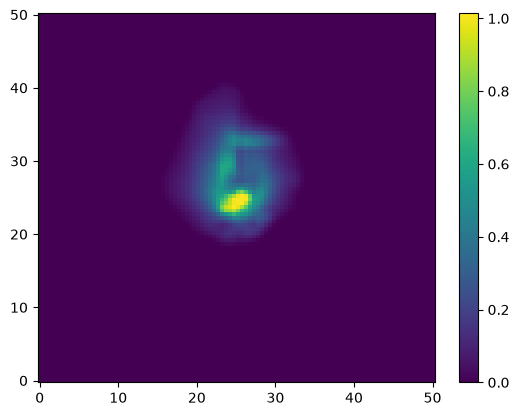

Epoch: 100 - Loss: 1.391e-01; total runtime: 2.292431116104126 (forward: 0.6962766647338867 grad: 1.2512989044189453 opt: 0.05590248107910156); time per epoch: 0.02292431116104126;


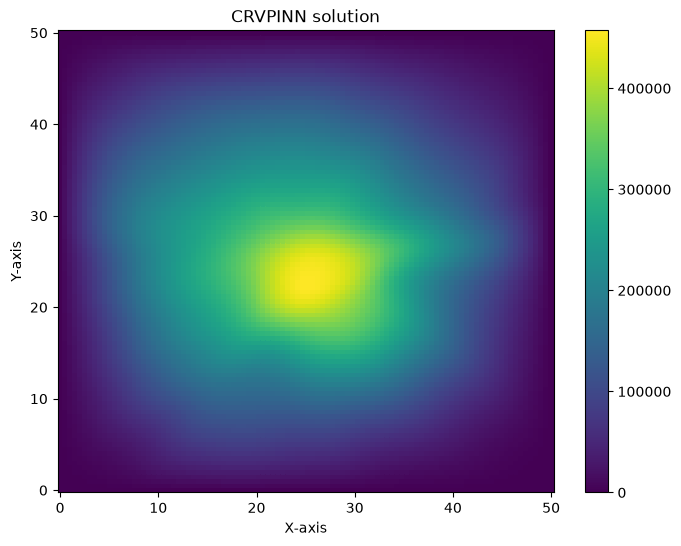

Training time : 2.537444
Starting simulation iteration 20/20


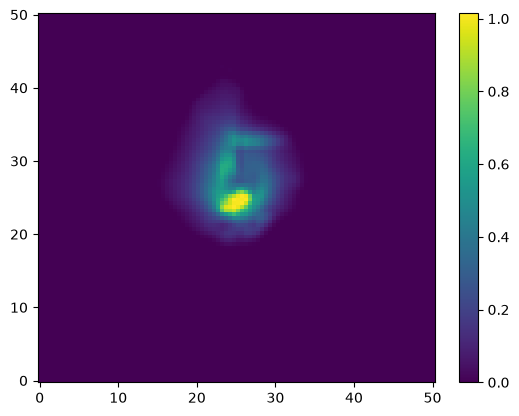

Epoch: 100 - Loss: 1.373e-01; total runtime: 2.1347012519836426 (forward: 0.6352980136871338 grad: 1.1747231483459473 opt: 0.04912829399108887); time per epoch: 0.021347012519836426;


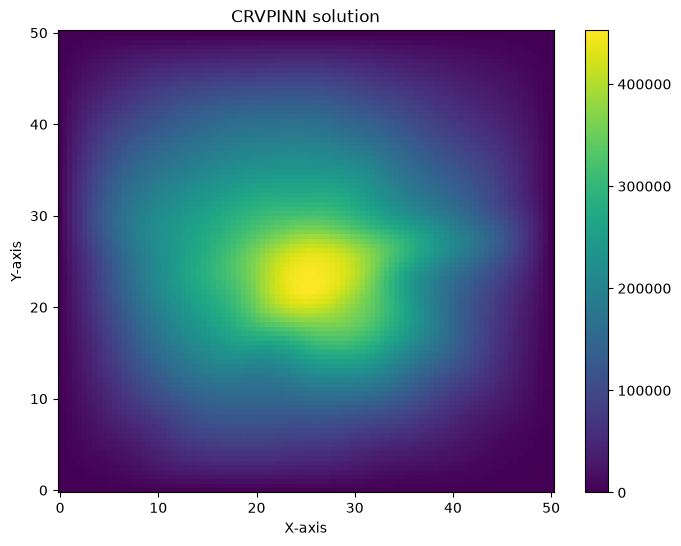

Training time : 2.440752
Total training time for 20 iterations: 51.815341


In [74]:
pinn_trained, loss_values_cont = continue_training(pinn, x, t, n_it_simulation=20, folder_name='perm_map_k1')

Text(0.5, 1.0, 'CRVPINN solution at 19th time step')

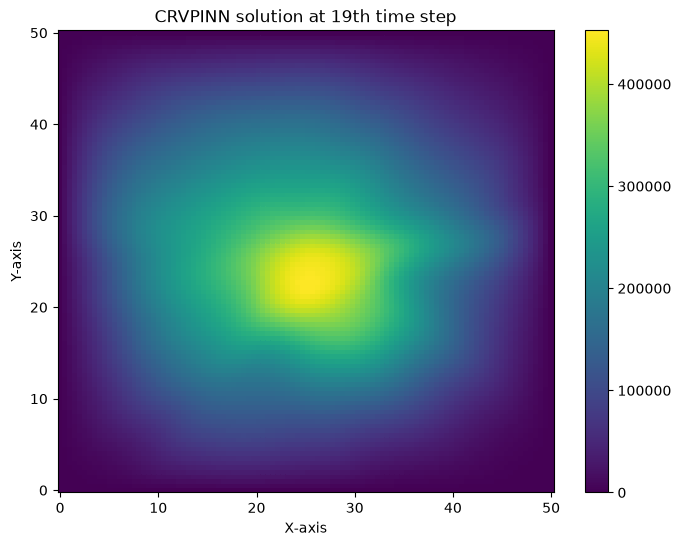

In [75]:
z_190 = f(pinn_trained.to(device), x, t)
color = plot_color(z_190.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)
plt.title('CRVPINN solution at 19th time step')

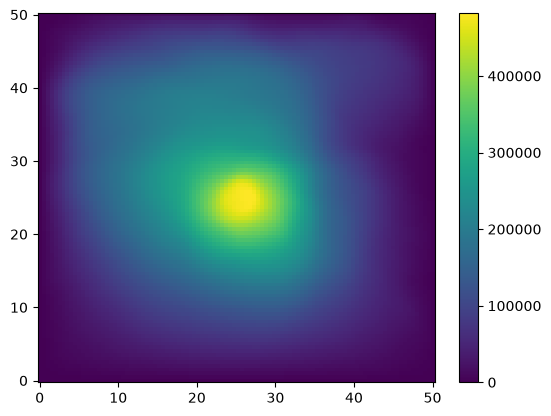

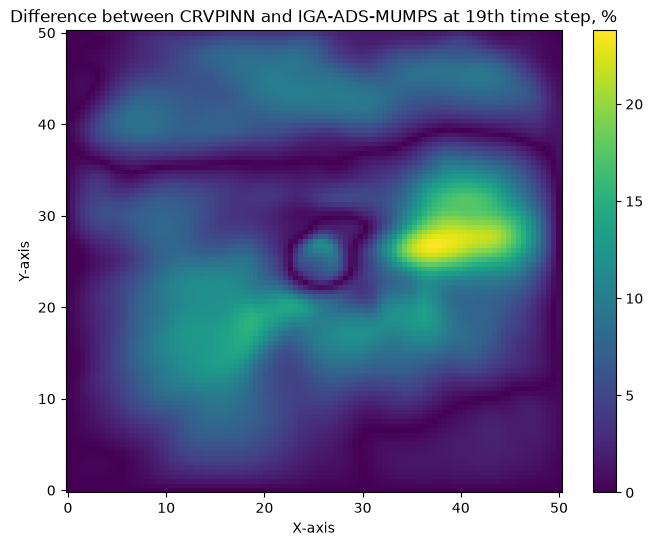

In [76]:
compare_with_iga(z_190, it_simulation=19, folder='perm_map_k1') #, err_bounds=(0, 25))

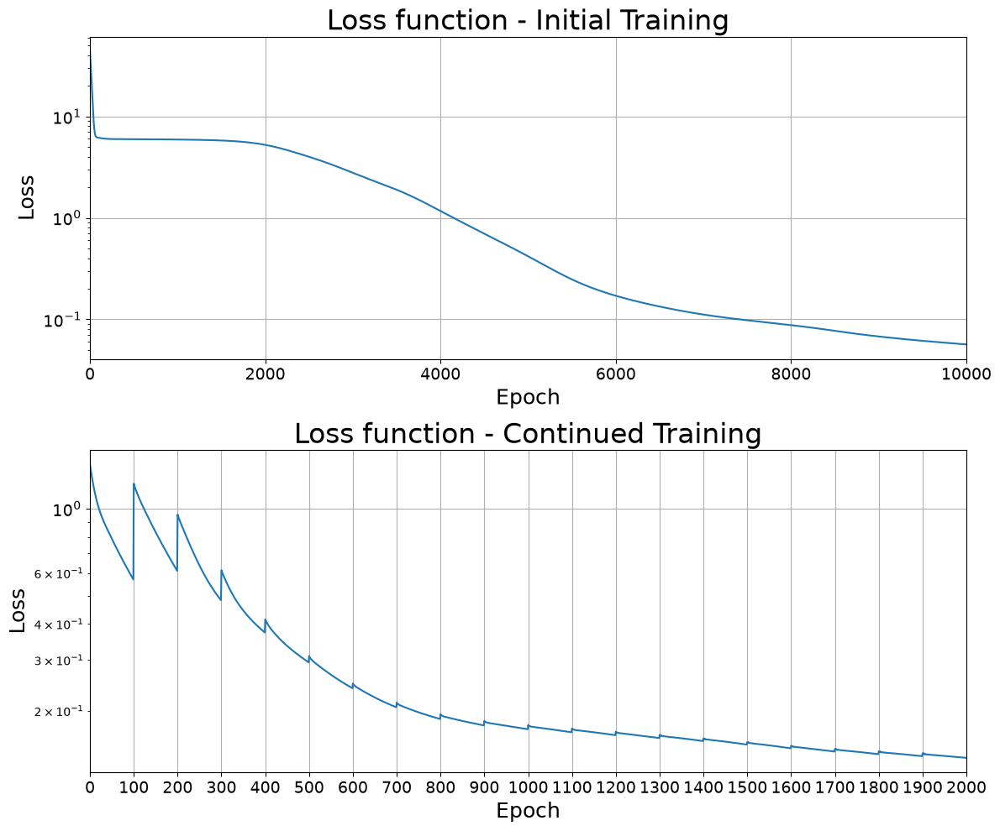

In [77]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.set_title("Loss function - Initial Training", fontsize = 24)
ax1.set_xlabel("Epoch", fontsize = 18)
ax1.set_ylabel("Loss", fontsize = 18)
ax1.set_yscale("log")
ax1.set_xlim(0, EPOCHS)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.plot(loss_values)
ax1.grid(True)

ax2.set_title("Loss function - Continued Training", fontsize = 24)
ax2.set_xlabel("Epoch", fontsize = 18)
ax2.set_ylabel("Loss", fontsize = 18)
ax2.set_yscale("log")
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_xlim(0, len(loss_values_cont))
ax2.set_xticks(np.arange(0, len(loss_values_cont)+1, step=100))
ax2.plot(loss_values_cont)
ax2.grid(True)

plt.tight_layout()

# PINN Training with non-uniform K2 permeability map

In [78]:
perm_k2_tensor = torch.tensor(perm_k2_interp, device=device, dtype=torch.float32)
corr_coeff = 1

K_array = perm_k2_tensor[np.ix_(row_indices, col_indices)] * darcy_to_si * gamma
K_tensor = torch.tensor(K_array, device=device, requires_grad=True)
K_function = make_fun(x_lin, y_lin, K_tensor.T)

/tmp/ipykernel_53314/2311627444.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  K_tensor = torch.tensor(K_array, device=device, requires_grad=True)


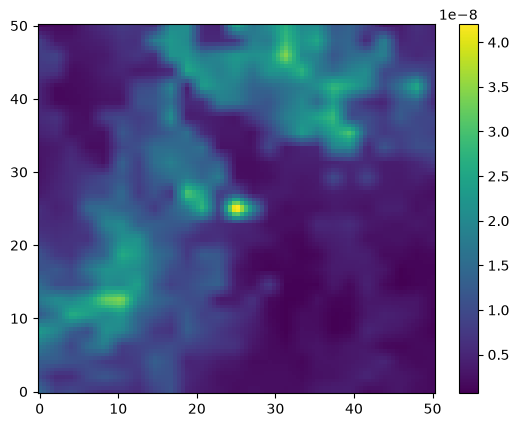

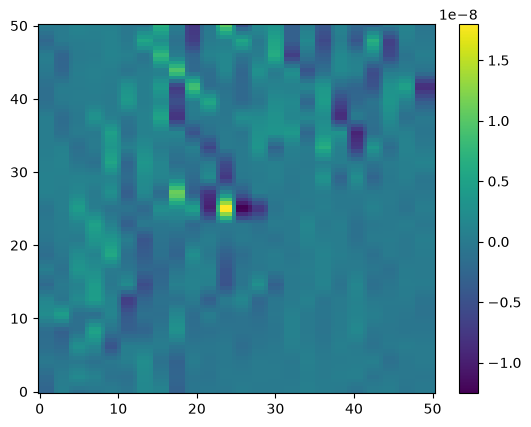

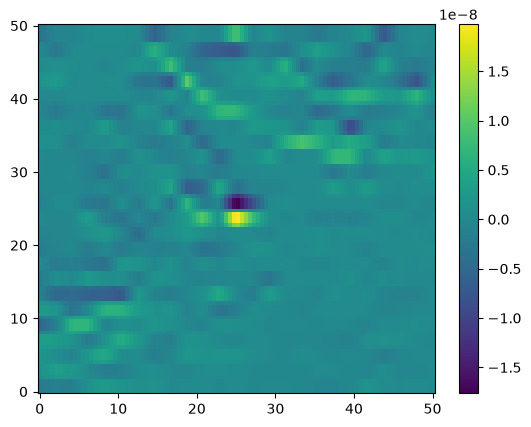

In [79]:
orginalK = K_function(x_plot, y_plot)
plotly(x_plot, y_plot, orginalK)
orginalK.shape

dfK  = df(K_function(x_plot, y_plot), x_plot)
plotly(x_plot, y_plot, dfK)

dfKy  = df(K_function(x_plot, y_plot), y_plot)
plotly(x_plot, y_plot, dfKy)

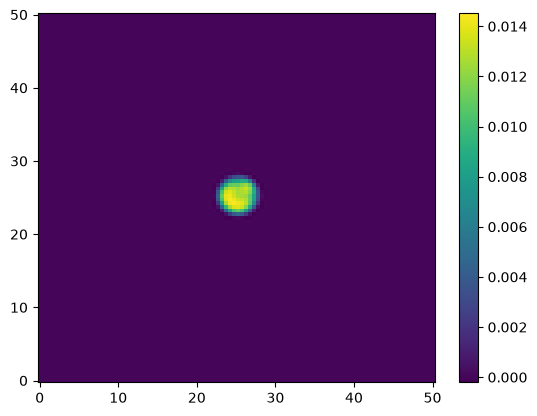

In [80]:
saturation_array = data_reader_s(f'perm_map_k2/s.out_0.data', step_size=0.5) 
Sg_tensor = torch.tensor(saturation_array.copy(), device=device, requires_grad=True)
Sg_function = make_fun(x_lin, y_lin, Sg_tensor)
plotly(x_plot, y_plot, Sg_function(x_plot, y_plot))

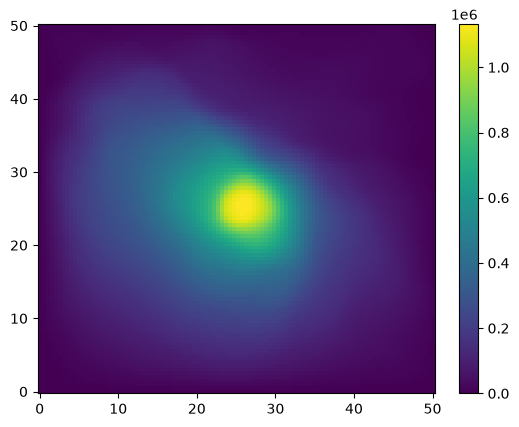

In [81]:
pressure_array = data_reader_s(f'perm_map_k2/p.out_0.data', step_size=0.5)
P_tensor = torch.tensor(pressure_array.copy(), device=device)
P_function = make_fun(x_lin, y_lin, P_tensor)
plotly(x_plot, y_plot, P_function(x_plot, y_plot))

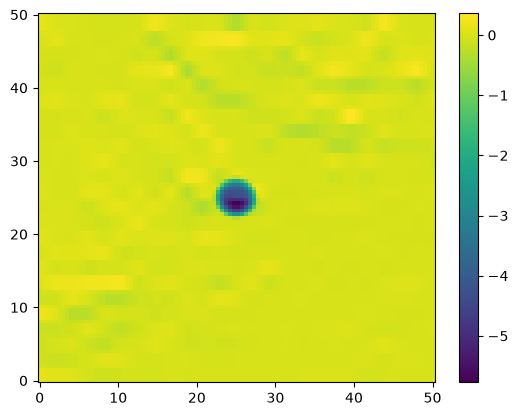

In [82]:
plotly(x_plot, y_plot, RHS(x_plot, y_plot))

Epoch: 1000 - Loss: 1.333e+01; total runtime: 2.1413686275482178 (forward: 0.6010348796844482 grad: 1.1336846351623535 opt: 0.25310182571411133); time per epoch: 0.0021413686275482176;


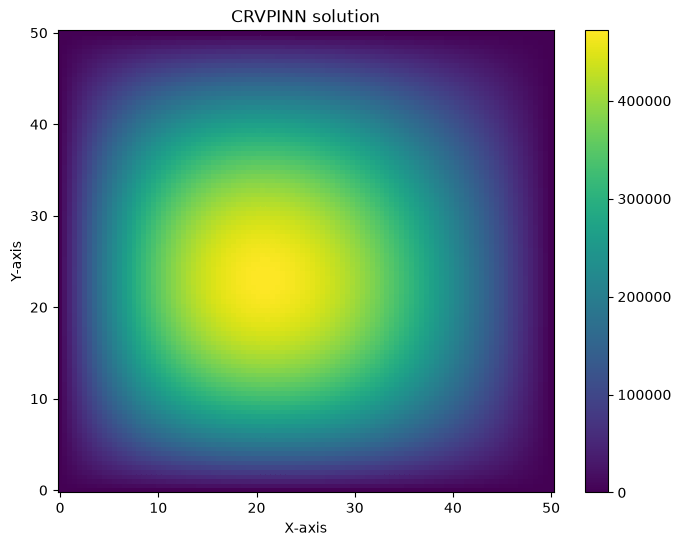

Epoch: 2000 - Loss: 1.224e+01; total runtime: 4.50247049331665 (forward: 1.2640001773834229 grad: 2.3747615814208984 opt: 0.5510401725769043); time per epoch: 0.002251235246658325;


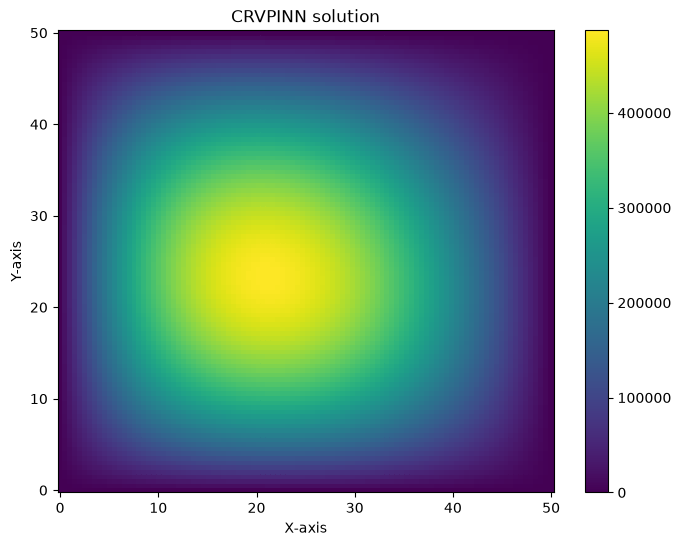

Epoch: 3000 - Loss: 4.700e+00; total runtime: 6.369157314300537 (forward: 1.787647008895874 grad: 3.3418939113616943 opt: 0.7839155197143555); time per epoch: 0.0021230524381001792;


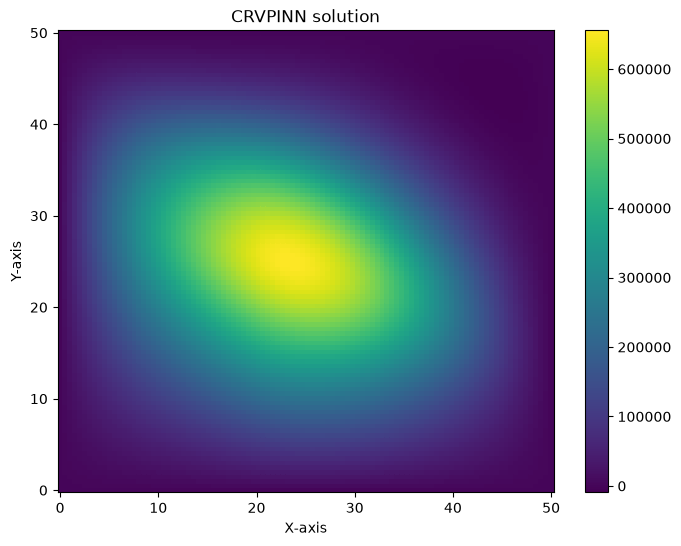

Epoch: 4000 - Loss: 1.785e+00; total runtime: 8.068772315979004 (forward: 2.2578885555267334 grad: 4.24141263961792 opt: 0.972212553024292); time per epoch: 0.002017193078994751;


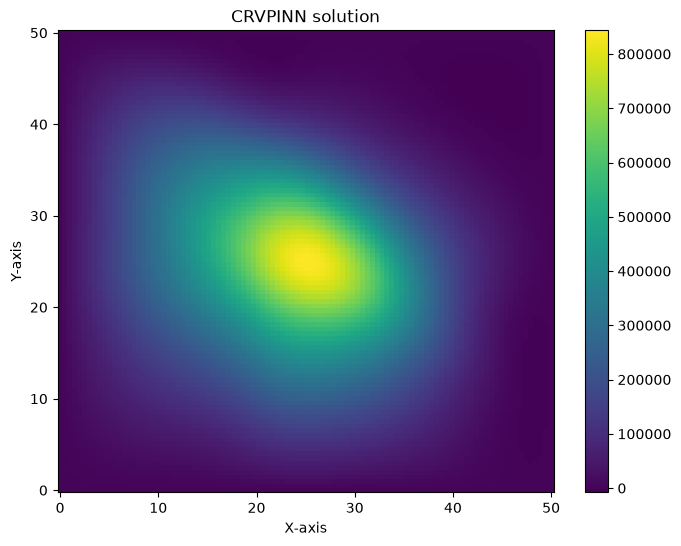

Epoch: 5000 - Loss: 8.021e-01; total runtime: 10.123236417770386 (forward: 2.8269355297088623 grad: 5.329365491867065 opt: 1.21992826461792); time per epoch: 0.002024647283554077;


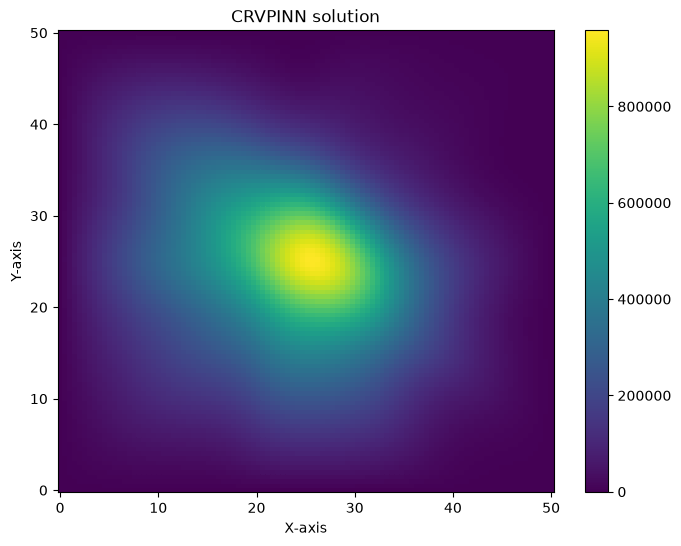

Epoch: 6000 - Loss: 3.208e-01; total runtime: 11.911168813705444 (forward: 3.3246099948883057 grad: 6.272260665893555 opt: 1.430044174194336); time per epoch: 0.001985194802284241;


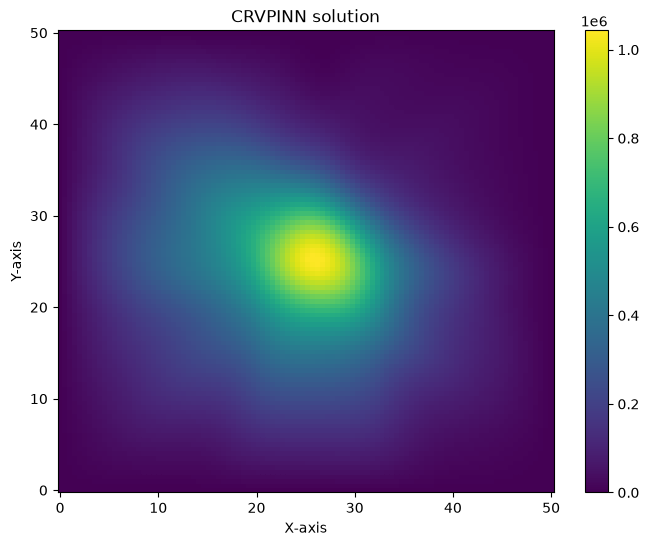

Epoch: 7000 - Loss: 1.561e-01; total runtime: 16.29167342185974 (forward: 4.552199602127075 grad: 8.631405353546143 opt: 1.9757704734802246); time per epoch: 0.0023273819174085345;


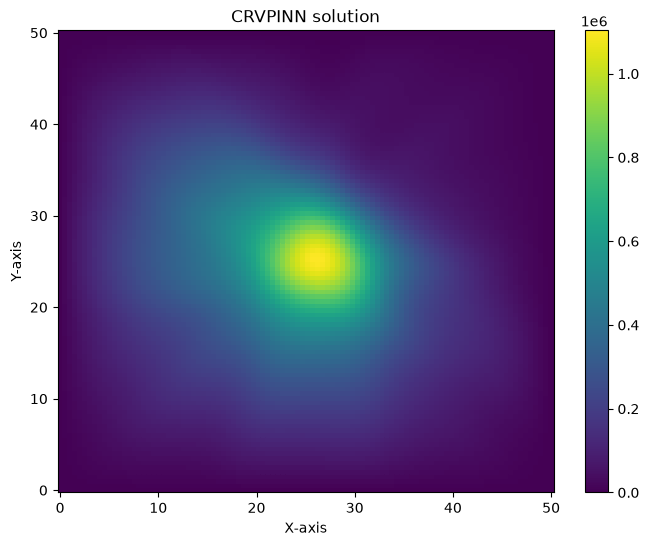

Epoch: 8000 - Loss: 1.075e-01; total runtime: 20.76039695739746 (forward: 5.818910121917725 grad: 11.034322738647461 opt: 2.537487745285034); time per epoch: 0.0025950496196746825;


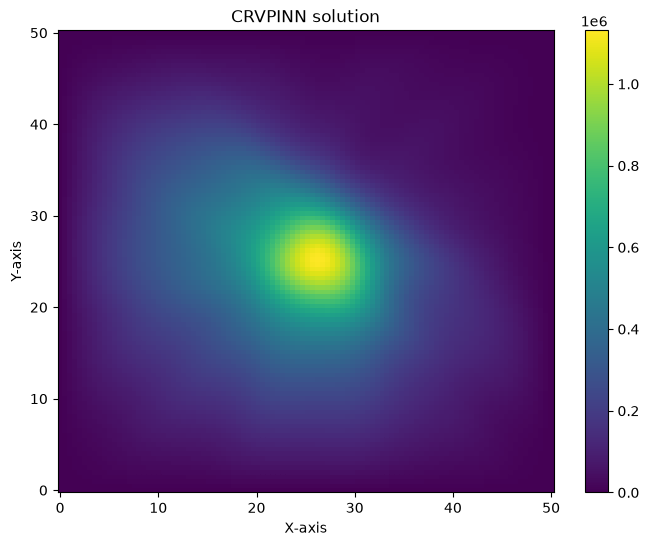

Epoch: 9000 - Loss: 8.877e-02; total runtime: 25.169990062713623 (forward: 7.077824354171753 grad: 13.386184930801392 opt: 3.0961124897003174); time per epoch: 0.0027966655625237358;


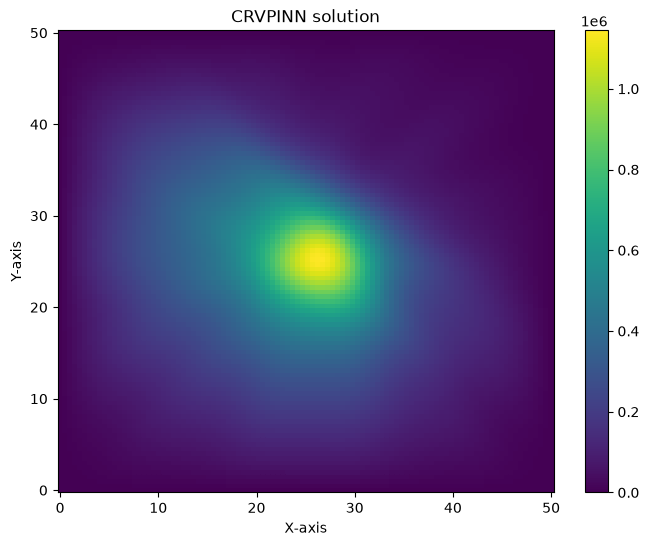

Epoch: 10000 - Loss: 7.820e-02; total runtime: 27.63894510269165 (forward: 7.780465602874756 grad: 14.715784549713135 opt: 3.3979454040527344); time per epoch: 0.002763894510269165;


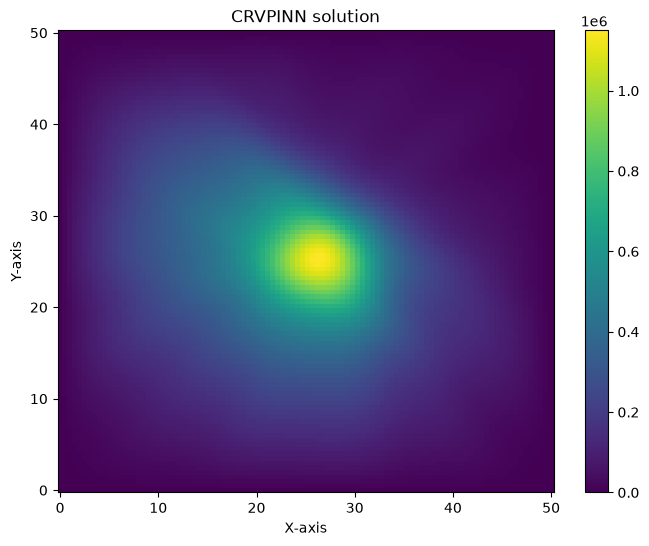

Training time : 30.271266


In [83]:
pinn = None
pinn = PINN(LAYERS, NEURONS_PER_LAYER, pinning=True, act=nn.Tanh()).to(device)

compute_loss(pinn, x=x, t=t)

# train the PINN
time_train0 = time.time()
loss_fn = partial(compute_loss, x=x, t=t, w_physics=0, w_data=10)
pinn_trained, loss_values = train_model(
    pinn, x, t, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=EPOCHS)
time_train1 = time.time()

print(f'Training time : %f'%(time_train1 - time_train0))

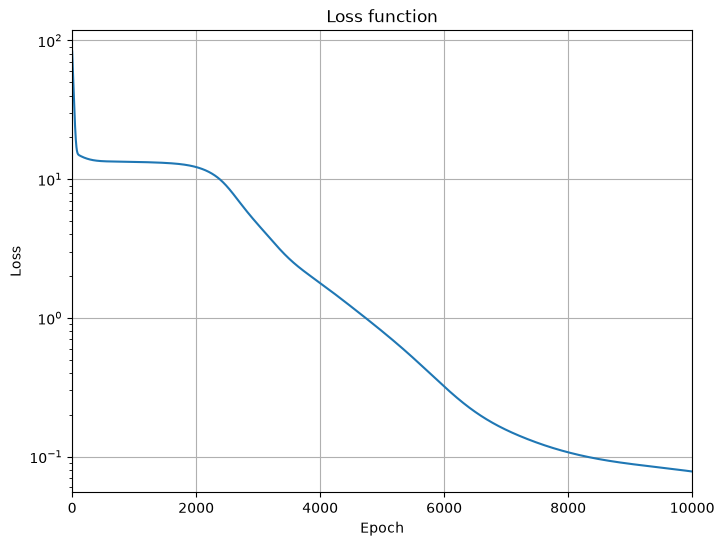

In [84]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
ax.plot(loss_values)
plt.grid(True)

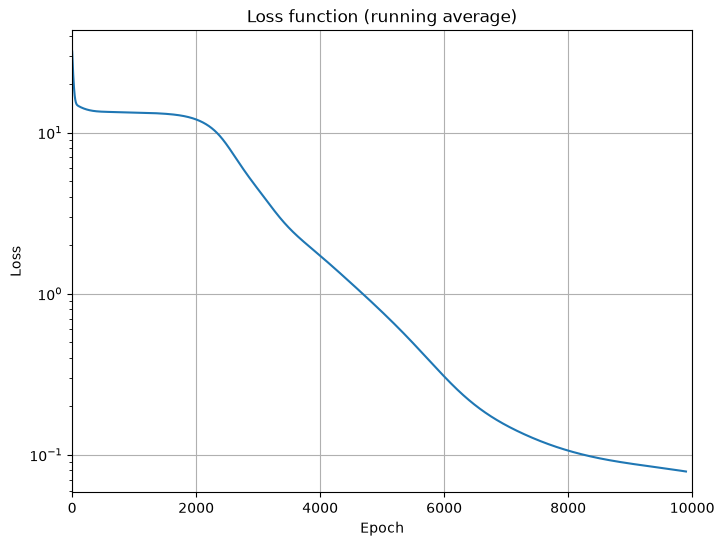

In [85]:
average_loss = running_average(loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
plt.grid(True)
ax.plot(average_loss)

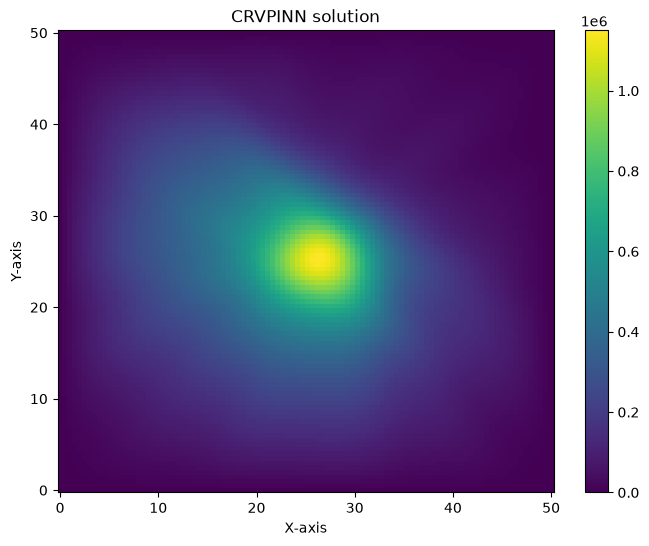

In [86]:
z_0 = f(pinn_trained.to(device), x, t)
color = plot_color(z_0.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)

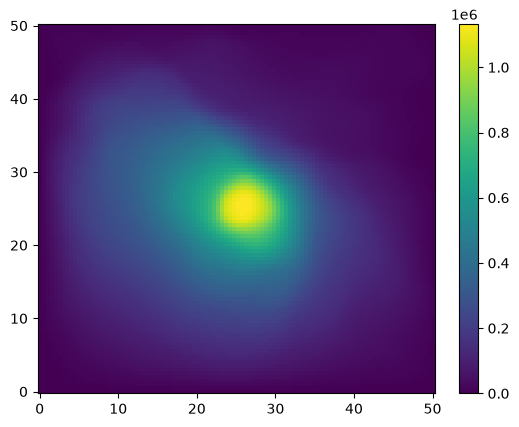

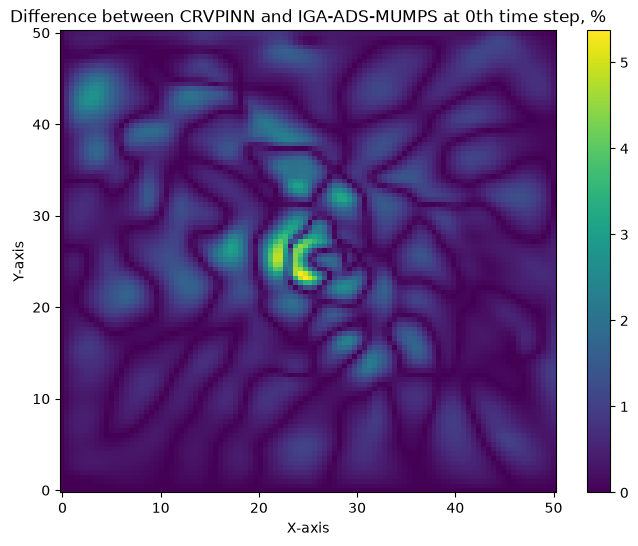

In [87]:
compare_with_iga(z_0, it_simulation=0, folder='perm_map_k2') #, err_bounds=(0,17.5))

Starting simulation iteration 1/20


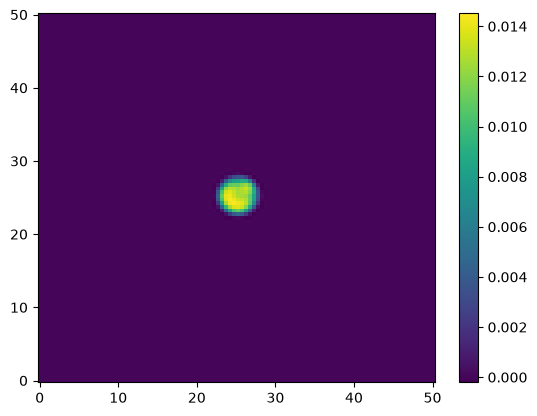

Epoch: 100 - Loss: 5.162e-01; total runtime: 2.3129031658172607 (forward: 0.6918892860412598 grad: 1.2954812049865723 opt: 0.05549478530883789); time per epoch: 0.023129031658172608;


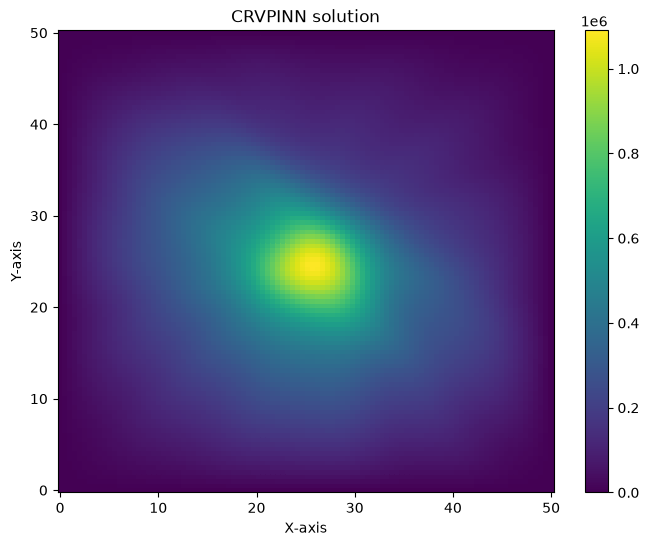

Training time : 2.609830
Starting simulation iteration 2/20


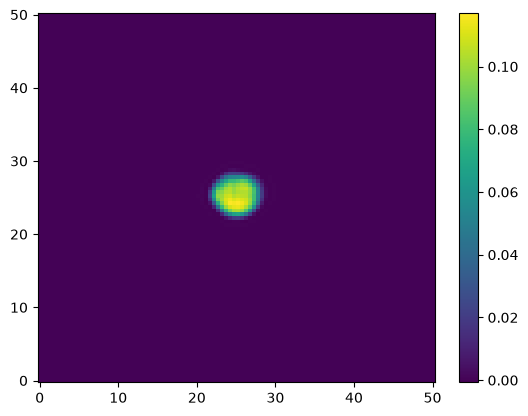

Epoch: 100 - Loss: 5.097e-01; total runtime: 2.2685959339141846 (forward: 0.6897470951080322 grad: 1.2733995914459229 opt: 0.05420422554016113); time per epoch: 0.022685959339141845;


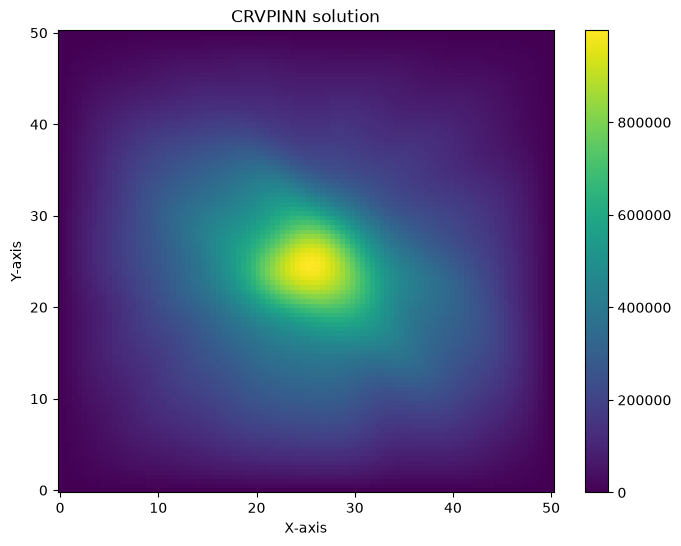

Training time : 2.468243
Starting simulation iteration 3/20


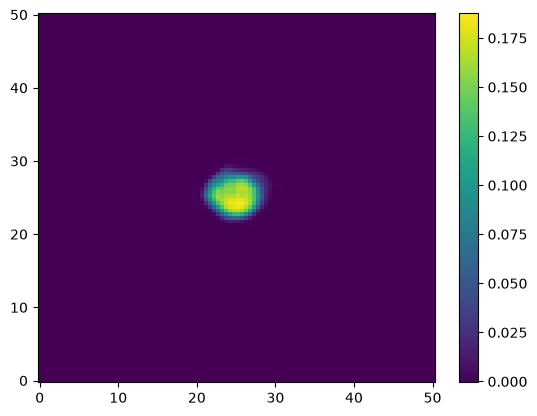

Epoch: 100 - Loss: 4.616e-01; total runtime: 2.0065603256225586 (forward: 0.5859715938568115 grad: 1.1135051250457764 opt: 0.04262852668762207); time per epoch: 0.020065603256225587;


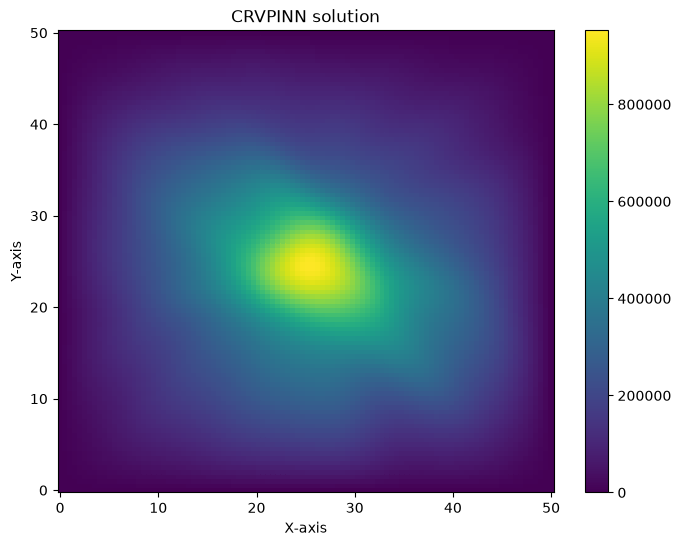

Training time : 2.509984
Starting simulation iteration 4/20


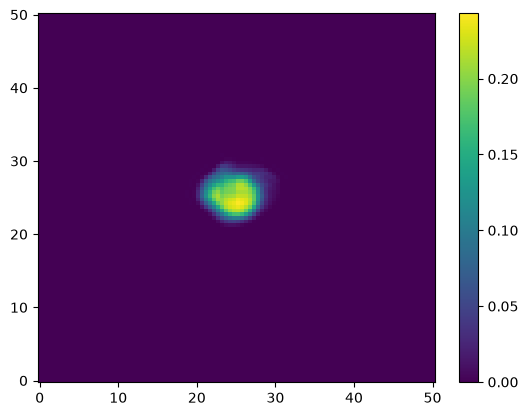

Epoch: 100 - Loss: 4.283e-01; total runtime: 2.005253791809082 (forward: 0.5779945850372314 grad: 1.122046947479248 opt: 0.0439295768737793); time per epoch: 0.02005253791809082;


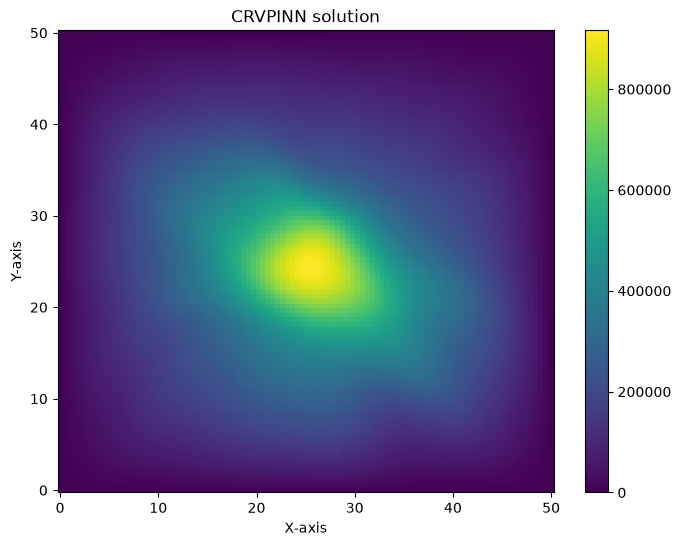

Training time : 2.305050
Starting simulation iteration 5/20


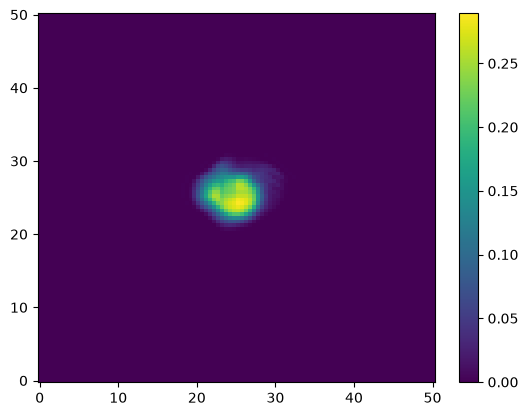

Epoch: 100 - Loss: 4.166e-01; total runtime: 2.335242748260498 (forward: 0.7183678150177002 grad: 1.3083691596984863 opt: 0.05634593963623047); time per epoch: 0.02335242748260498;


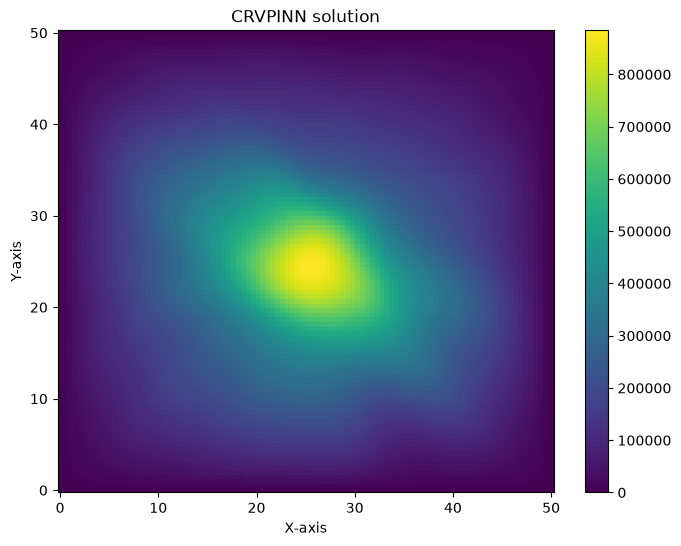

Training time : 2.593216
Starting simulation iteration 6/20


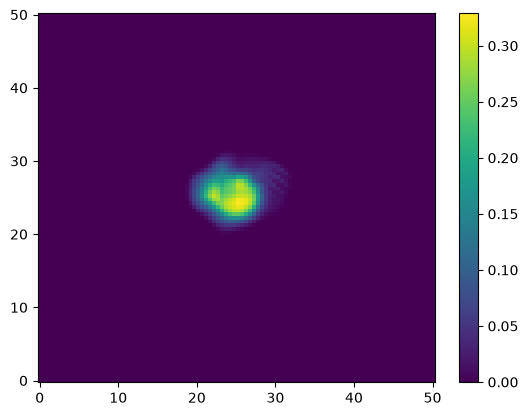

Epoch: 100 - Loss: 4.157e-01; total runtime: 2.1492607593536377 (forward: 0.6439480781555176 grad: 1.1987473964691162 opt: 0.05055570602416992); time per epoch: 0.021492607593536377;


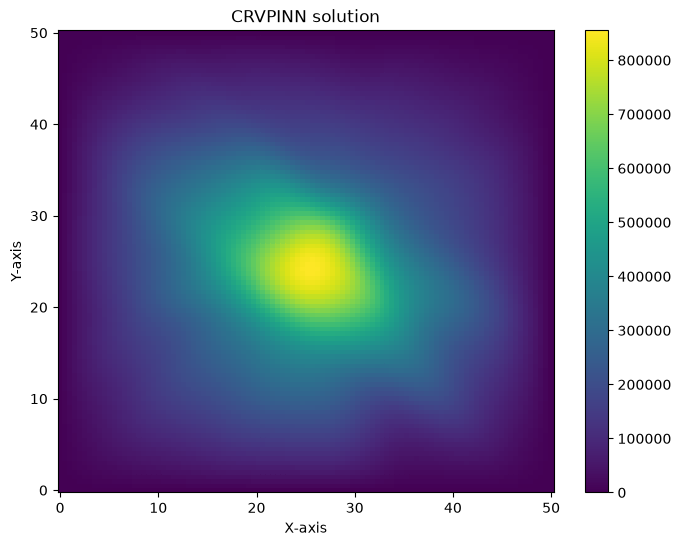

Training time : 2.403510
Starting simulation iteration 7/20


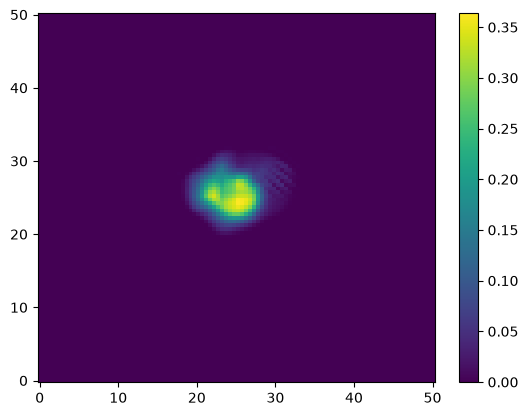

Epoch: 100 - Loss: 4.176e-01; total runtime: 1.9116034507751465 (forward: 0.5482723712921143 grad: 1.0603525638580322 opt: 0.03808760643005371); time per epoch: 0.019116034507751466;


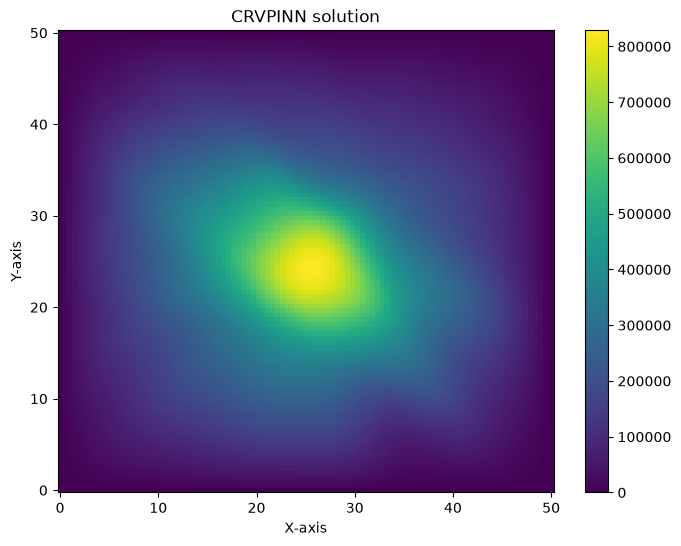

Training time : 2.232228
Starting simulation iteration 8/20


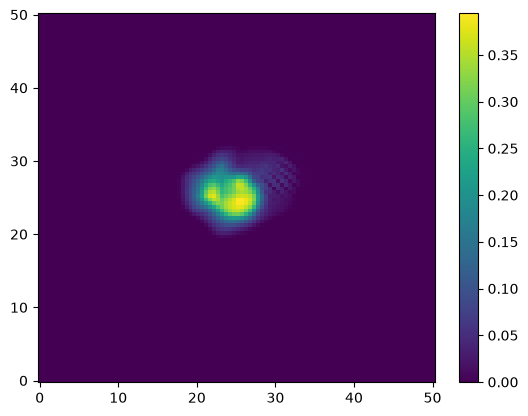

Epoch: 100 - Loss: 4.190e-01; total runtime: 1.9325392246246338 (forward: 0.5564577579498291 grad: 1.0753955841064453 opt: 0.03982806205749512); time per epoch: 0.01932539224624634;


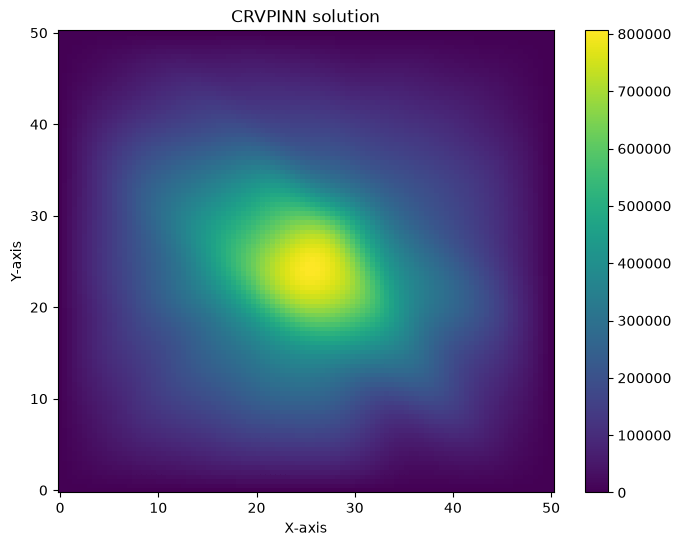

Training time : 2.250315
Starting simulation iteration 9/20


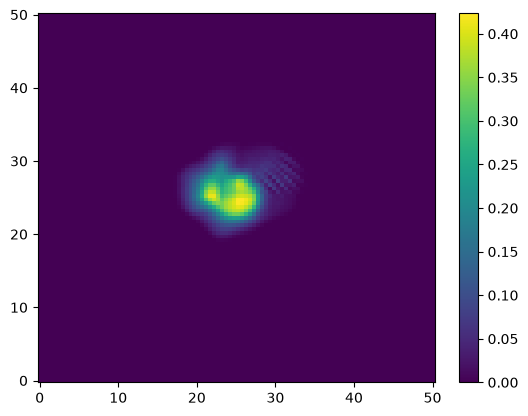

Epoch: 100 - Loss: 4.193e-01; total runtime: 1.9400465488433838 (forward: 0.5516409873962402 grad: 1.0841219425201416 opt: 0.04030561447143555); time per epoch: 0.019400465488433837;


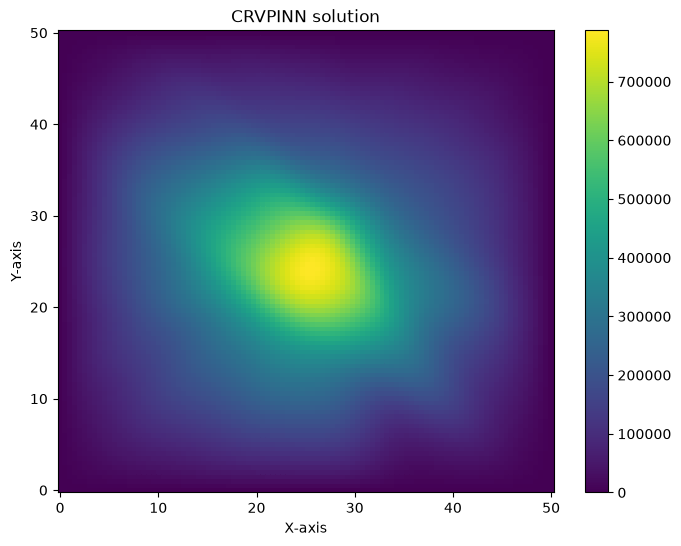

Training time : 2.249277
Starting simulation iteration 10/20


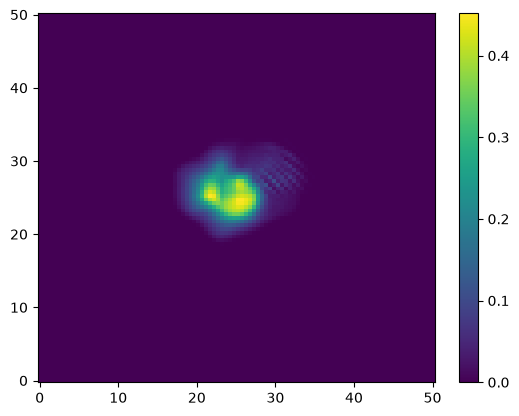

Epoch: 100 - Loss: 4.179e-01; total runtime: 2.0252773761749268 (forward: 0.6011598110198975 grad: 1.119767665863037 opt: 0.04513907432556152); time per epoch: 0.020252773761749266;


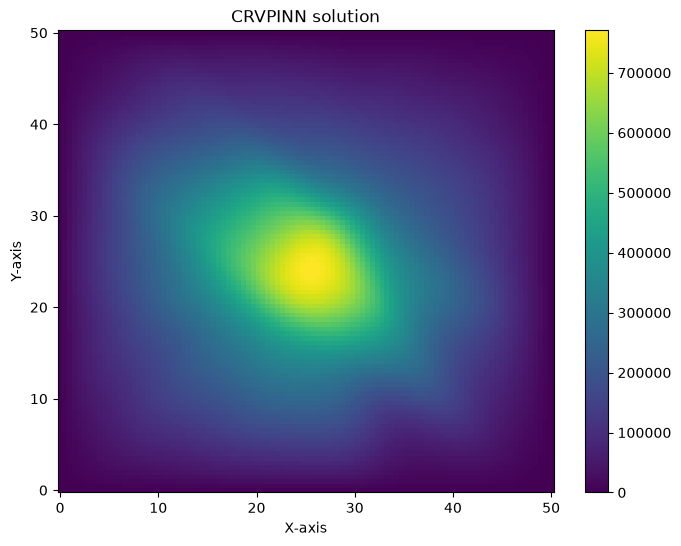

Training time : 2.331610
Starting simulation iteration 11/20


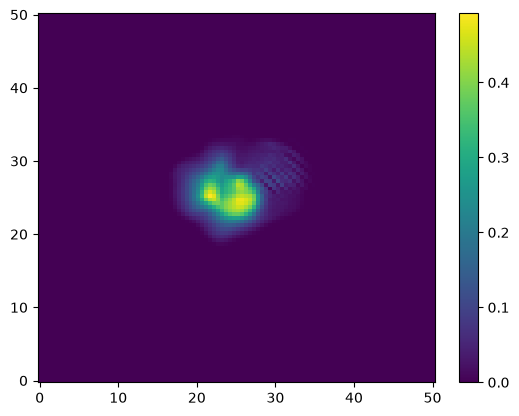

Epoch: 100 - Loss: 4.162e-01; total runtime: 3.4921488761901855 (forward: 1.1516196727752686 grad: 2.0422422885894775 opt: 0.07891321182250977); time per epoch: 0.034921488761901855;


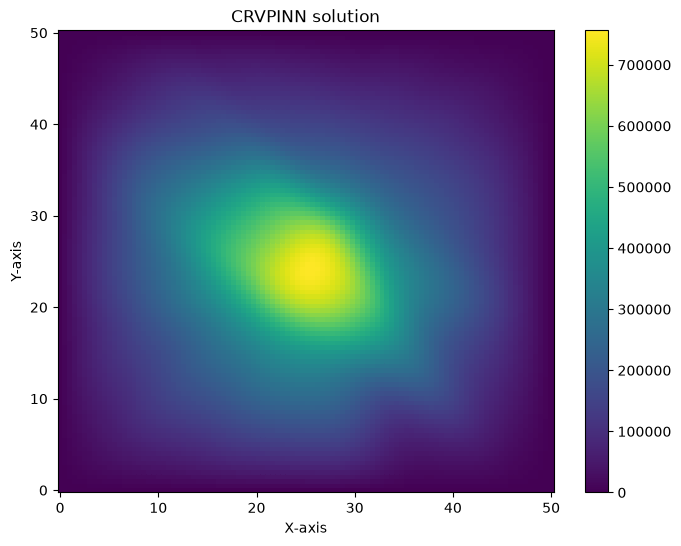

Training time : 3.748799
Starting simulation iteration 12/20


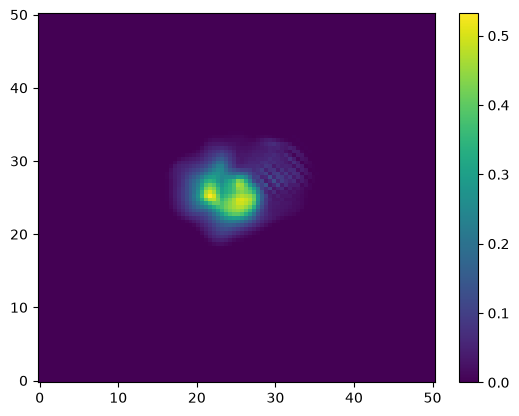

Epoch: 100 - Loss: 4.130e-01; total runtime: 2.0822255611419678 (forward: 0.6027402877807617 grad: 1.1540658473968506 opt: 0.04166221618652344); time per epoch: 0.020822255611419677;


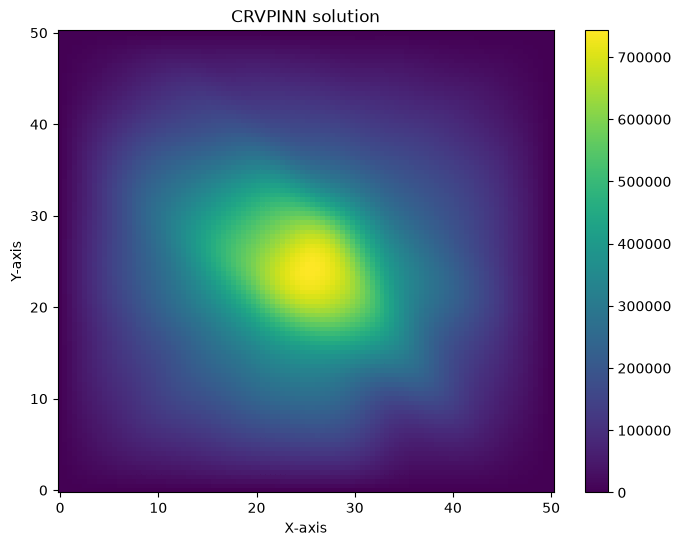

Training time : 2.402902
Starting simulation iteration 13/20


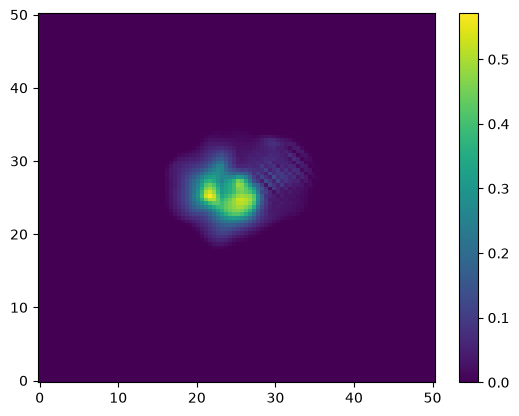

Epoch: 100 - Loss: 4.094e-01; total runtime: 1.9217445850372314 (forward: 0.55124831199646 grad: 1.0716512203216553 opt: 0.03772306442260742); time per epoch: 0.019217445850372314;


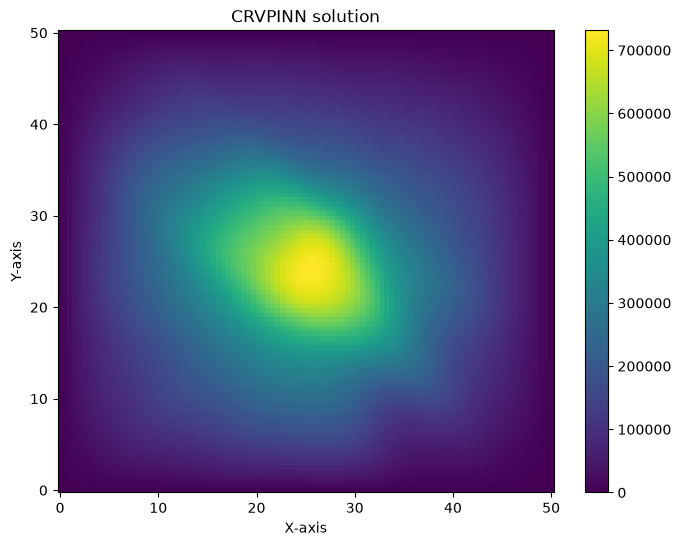

Training time : 2.243360
Starting simulation iteration 14/20


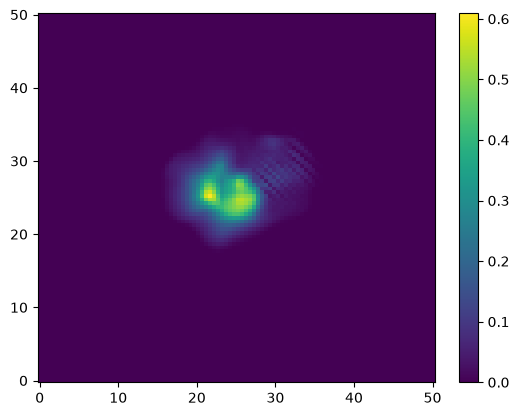

Epoch: 100 - Loss: 4.045e-01; total runtime: 2.1095058917999268 (forward: 0.6308722496032715 grad: 1.1748509407043457 opt: 0.04823923110961914); time per epoch: 0.021095058917999267;


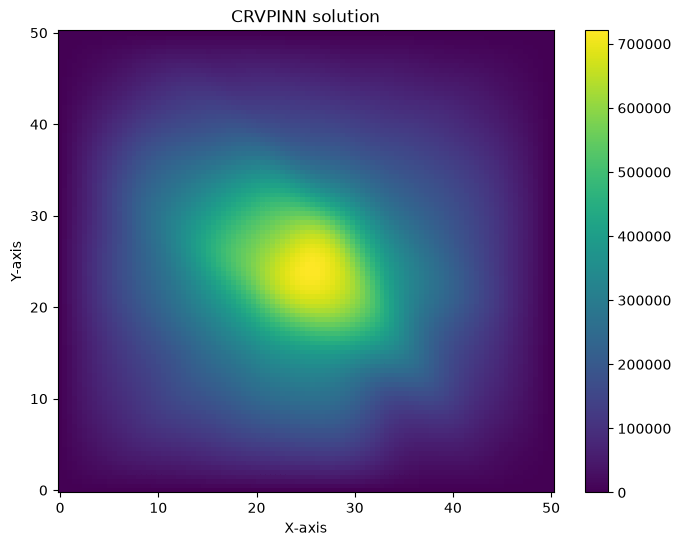

Training time : 2.385632
Starting simulation iteration 15/20


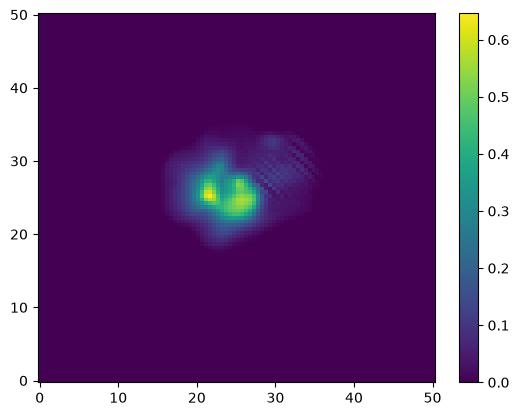

Epoch: 100 - Loss: 3.991e-01; total runtime: 2.9729390144348145 (forward: 0.9543173313140869 grad: 1.7055022716522217 opt: 0.07125639915466309); time per epoch: 0.029729390144348146;


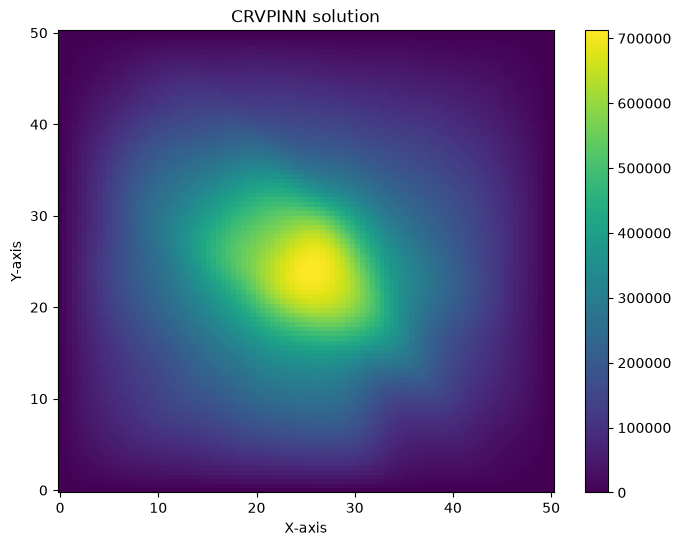

Training time : 3.176497
Starting simulation iteration 16/20


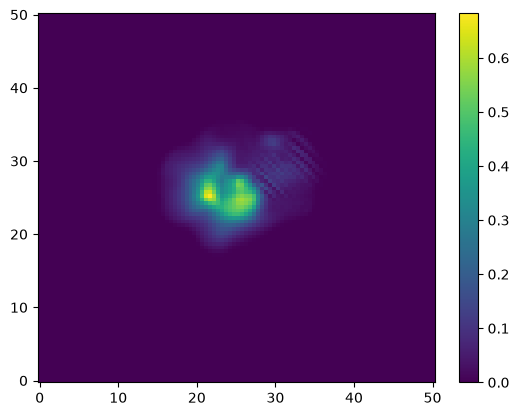

Epoch: 100 - Loss: 3.931e-01; total runtime: 3.483715772628784 (forward: 1.1529393196105957 grad: 2.0385940074920654 opt: 0.07555770874023438); time per epoch: 0.03483715772628784;


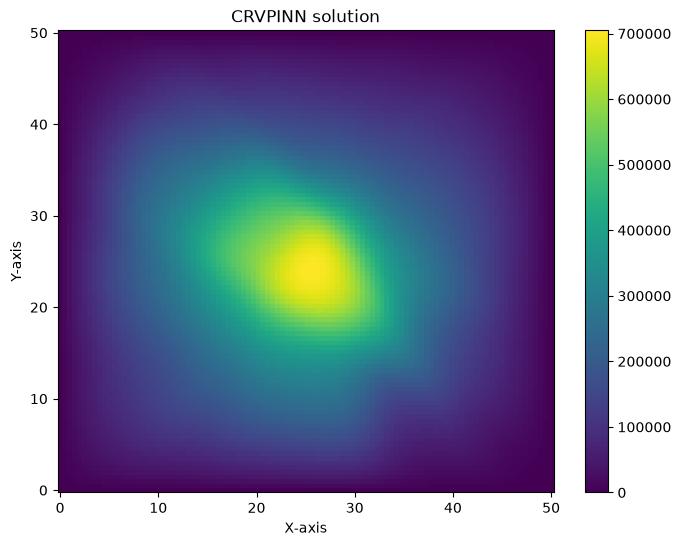

Training time : 3.648521
Starting simulation iteration 17/20


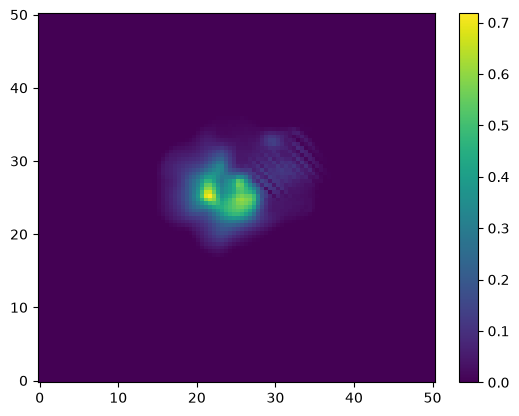

Epoch: 100 - Loss: 3.876e-01; total runtime: 2.1155011653900146 (forward: 0.6238386631011963 grad: 1.1809890270233154 opt: 0.04818892478942871); time per epoch: 0.021155011653900147;


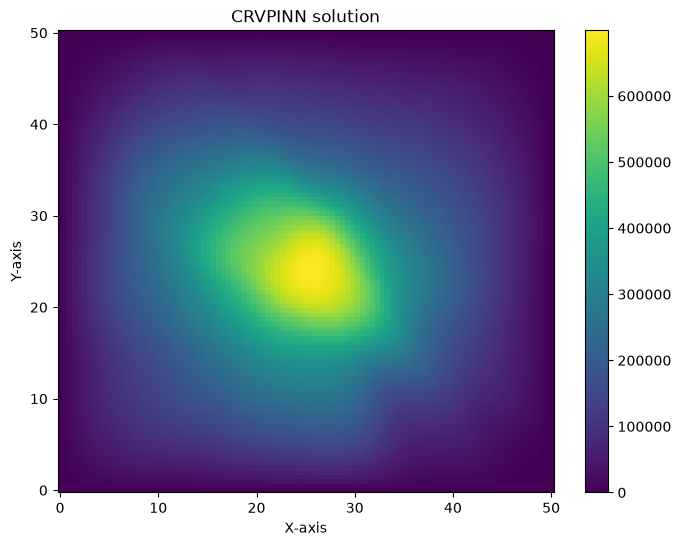

Training time : 2.610587
Starting simulation iteration 18/20


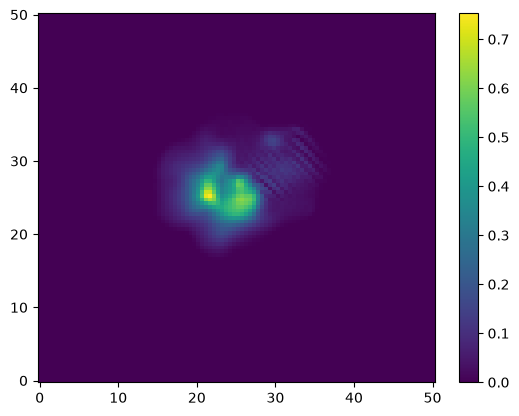

Epoch: 100 - Loss: 3.820e-01; total runtime: 1.9771766662597656 (forward: 0.5729501247406006 grad: 1.1028571128845215 opt: 0.04148602485656738); time per epoch: 0.019771766662597657;


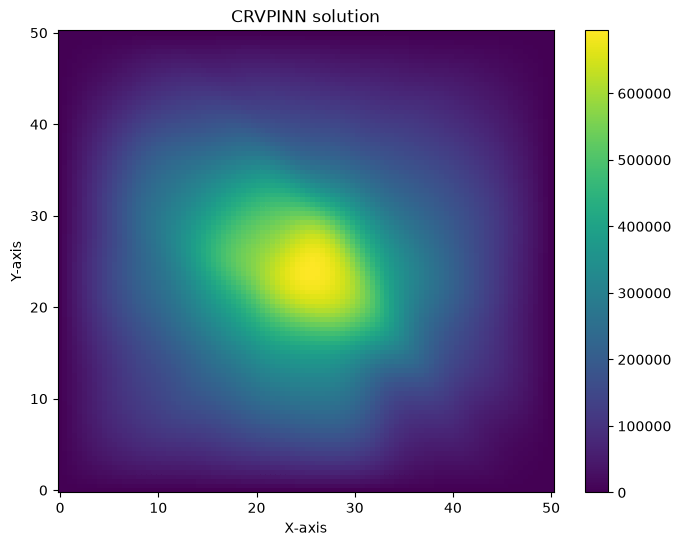

Training time : 2.294468
Starting simulation iteration 19/20


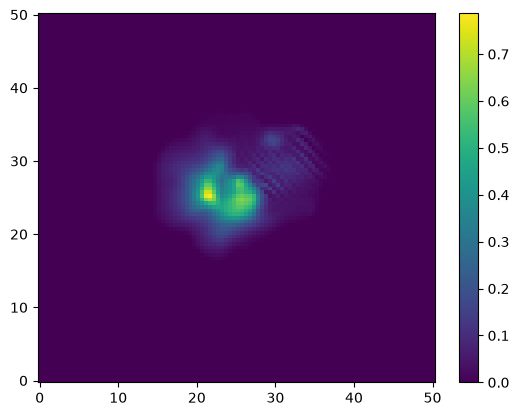

Epoch: 100 - Loss: 3.779e-01; total runtime: 1.958702564239502 (forward: 0.5726602077484131 grad: 1.0859606266021729 opt: 0.04050159454345703); time per epoch: 0.01958702564239502;


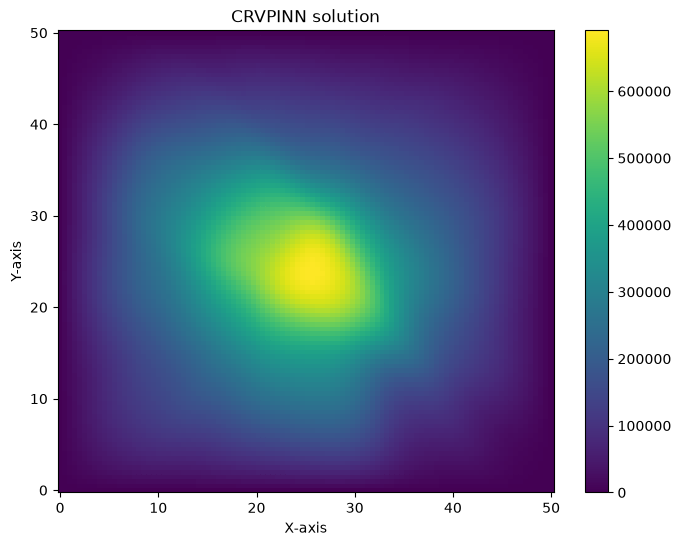

Training time : 2.276512
Starting simulation iteration 20/20


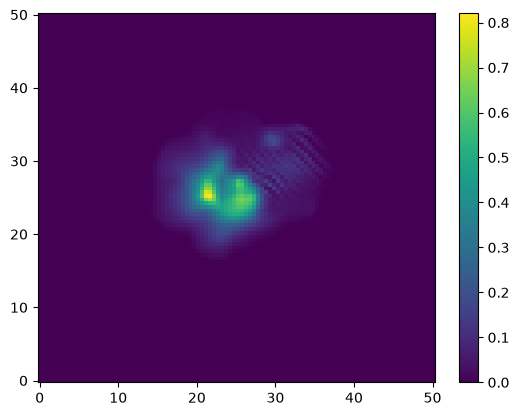

Epoch: 100 - Loss: 3.746e-01; total runtime: 2.4840779304504395 (forward: 0.779454231262207 grad: 1.4018733501434326 opt: 0.058272600173950195); time per epoch: 0.024840779304504394;


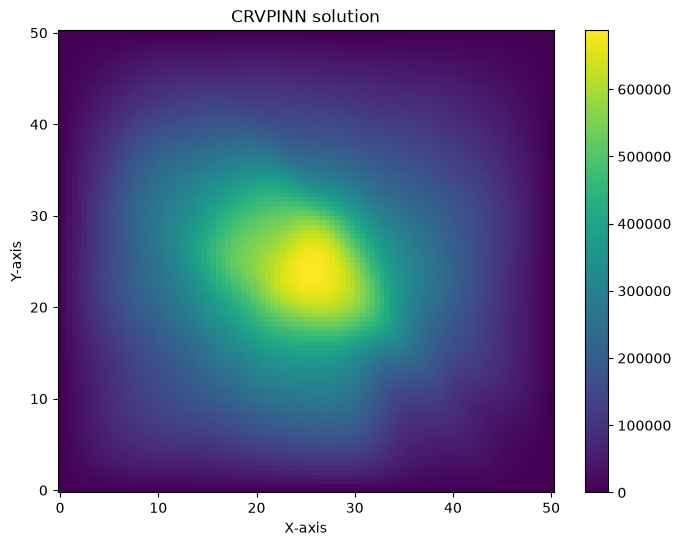

Training time : 2.774919
Total training time for 20 iterations: 51.515460


In [88]:
pinn_trained, loss_values_cont = continue_training(pinn, x, t, n_it_simulation=20, folder_name='perm_map_k2')

Text(0.5, 1.0, 'CRVPINN solution at 19th time step')

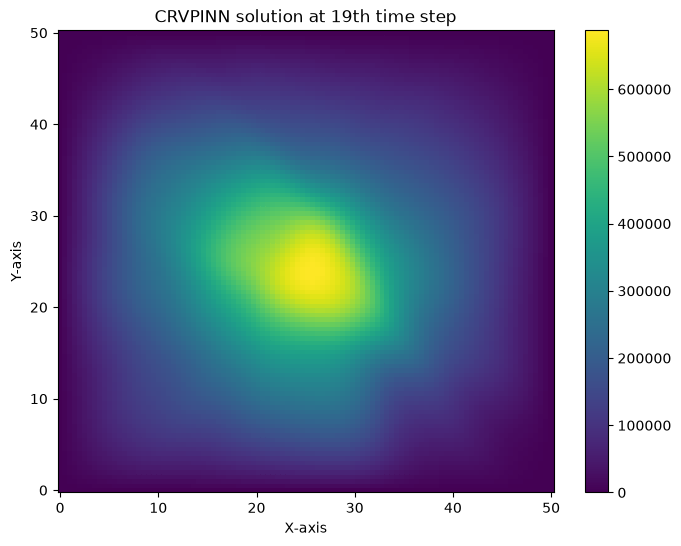

In [89]:
z_190 = f(pinn_trained.to(device), x, t)
color = plot_color(z_190.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)
plt.title('CRVPINN solution at 19th time step')

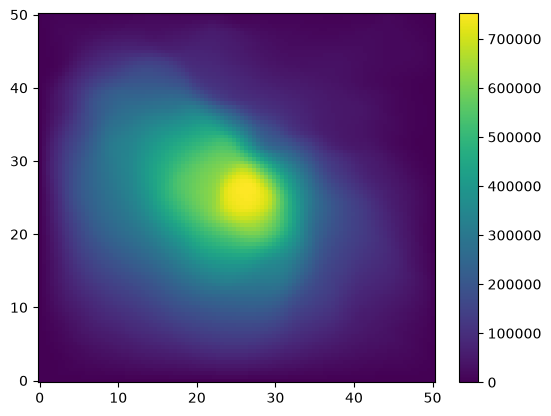

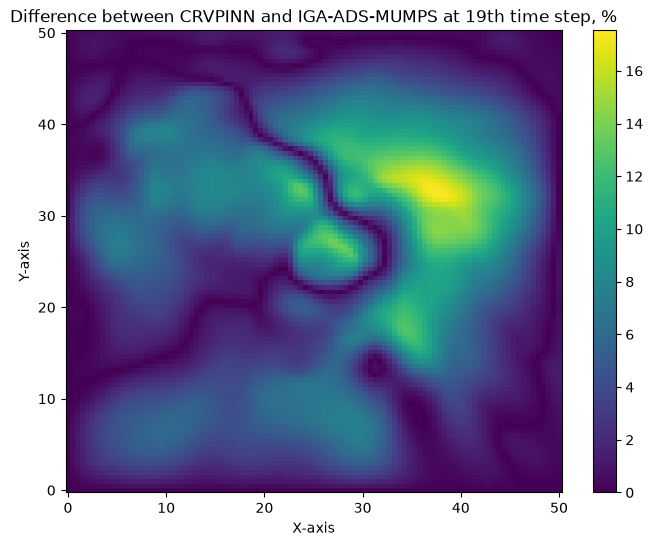

In [90]:
compare_with_iga(z_190, it_simulation=19, folder='perm_map_k2') #, err_bounds=(0,17.5))

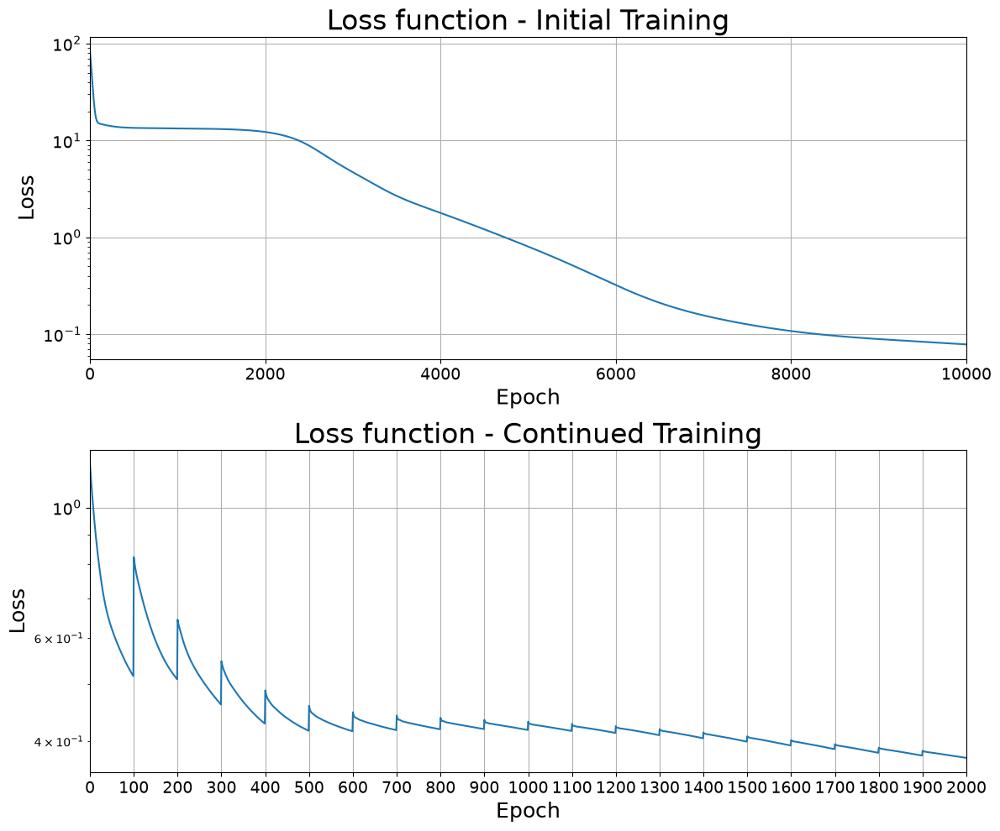

In [91]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.set_title("Loss function - Initial Training", fontsize = 24)
ax1.set_xlabel("Epoch", fontsize = 18)
ax1.set_ylabel("Loss", fontsize = 18)
ax1.set_yscale("log")
ax1.set_xlim(0, EPOCHS)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.plot(loss_values)
ax1.grid(True)

ax2.set_title("Loss function - Continued Training", fontsize = 24)
ax2.set_xlabel("Epoch", fontsize = 18)
ax2.set_ylabel("Loss", fontsize = 18)
ax2.set_yscale("log")
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_xlim(0, len(loss_values_cont))
ax2.set_xticks(np.arange(0, len(loss_values_cont)+1, step=100))
ax2.plot(loss_values_cont)
ax2.grid(True)

plt.tight_layout()

# PINN Training with non-uniform K3 permeability map

In [92]:
perm_k3_tensor = torch.tensor(perm_k3_interp, device=device, dtype=torch.float32)

K_array = perm_k3_tensor[np.ix_(row_indices, col_indices)] * darcy_to_si * gamma
K_tensor = torch.tensor(K_array, device=device, requires_grad=True)
K_function = make_fun(x_lin, y_lin, K_tensor.T)

/tmp/ipykernel_53314/3241878552.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  K_tensor = torch.tensor(K_array, device=device, requires_grad=True)


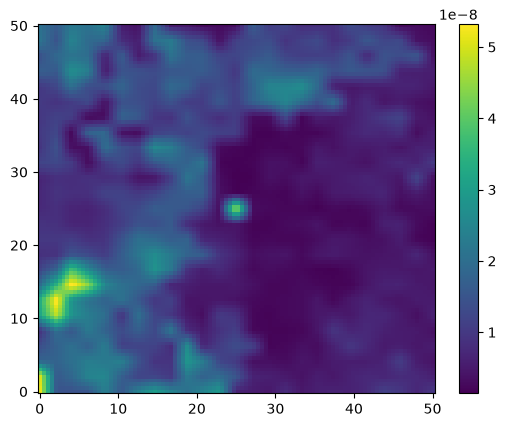

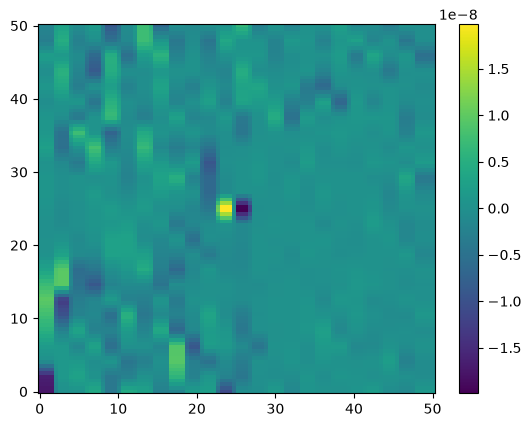

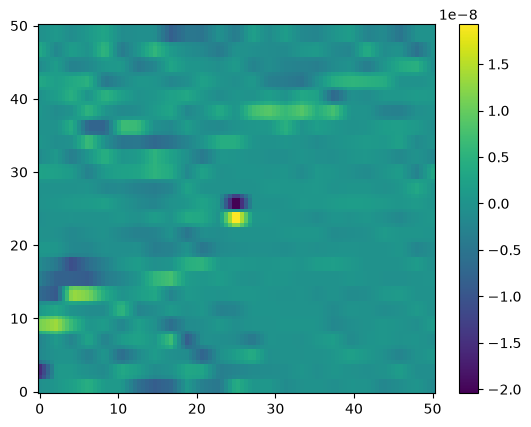

In [93]:
orginalK = K_function(x_plot, y_plot)
plotly(x_plot, y_plot, orginalK)
orginalK.shape

dfK  = df(K_function(x_plot, y_plot), x_plot)
plotly(x_plot, y_plot, dfK)

dfKy  = df(K_function(x_plot, y_plot), y_plot)
plotly(x_plot, y_plot, dfKy)

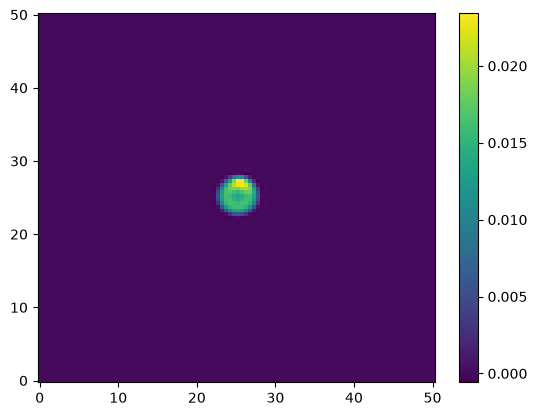

In [94]:
saturation_array = data_reader_s(f'perm_map_k3/s.out_0.data', step_size=0.5) 
Sg_tensor = torch.tensor(saturation_array.copy(), device=device, requires_grad=True)
Sg_function = make_fun(x_lin, y_lin, Sg_tensor)
plotly(x_plot, y_plot, Sg_function(x_plot, y_plot))

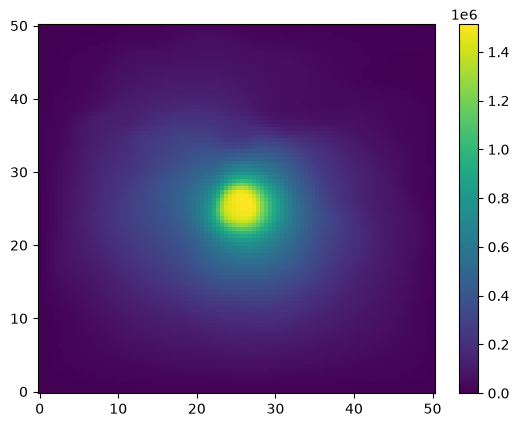

In [95]:
pressure_array = data_reader_s('perm_map_k3/p.out_0.data', step_size=0.5, size_x=LENGTH, size_y=TOTAL_TIME)
P_tensor = torch.tensor(pressure_array.copy(), device=device)
P_function = make_fun(x_lin, y_lin, P_tensor)
plotly(x_plot, y_plot, P_function(x_plot, y_plot))

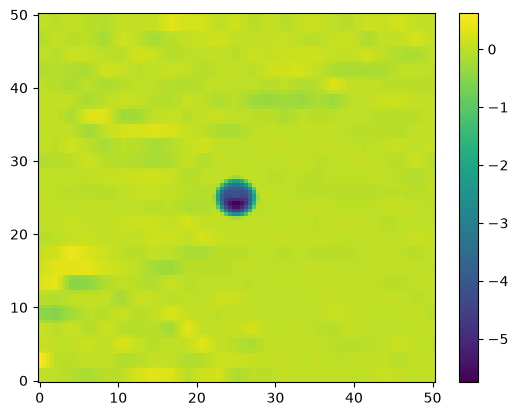

In [96]:
plotly(x_plot, y_plot, RHS(x_plot, y_plot))

Epoch: 1000 - Loss: 2.062e+01; total runtime: 2.622591495513916 (forward: 0.7494251728057861 grad: 1.4359941482543945 opt: 0.3046708106994629); time per epoch: 0.002622591495513916;


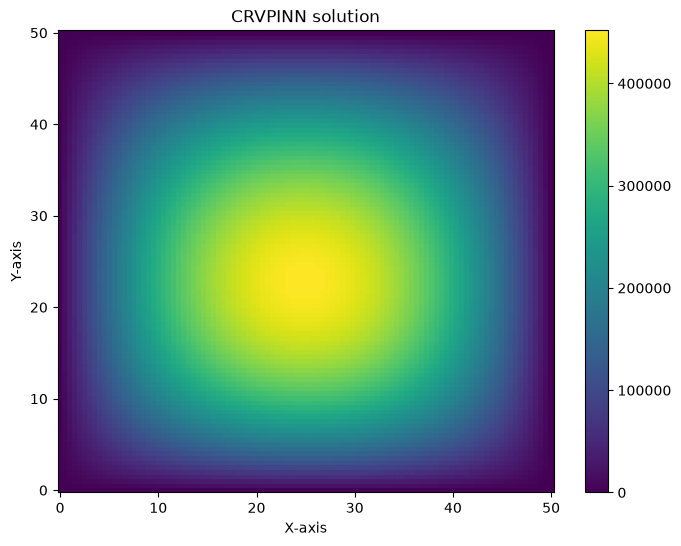

Epoch: 2000 - Loss: 1.689e+01; total runtime: 4.466407537460327 (forward: 1.2794535160064697 grad: 2.4338431358337402 opt: 0.5132863521575928); time per epoch: 0.0022332037687301637;


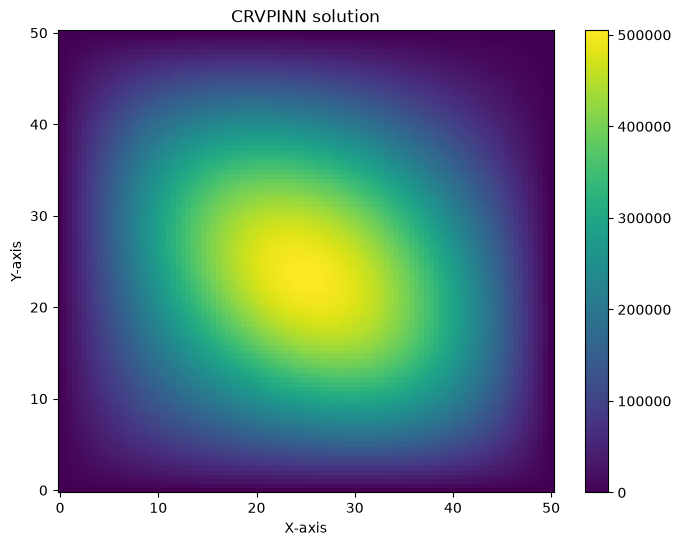

Epoch: 3000 - Loss: 9.684e+00; total runtime: 6.177373647689819 (forward: 1.7637550830841064 grad: 3.3704099655151367 opt: 0.7000668048858643); time per epoch: 0.0020591245492299396;


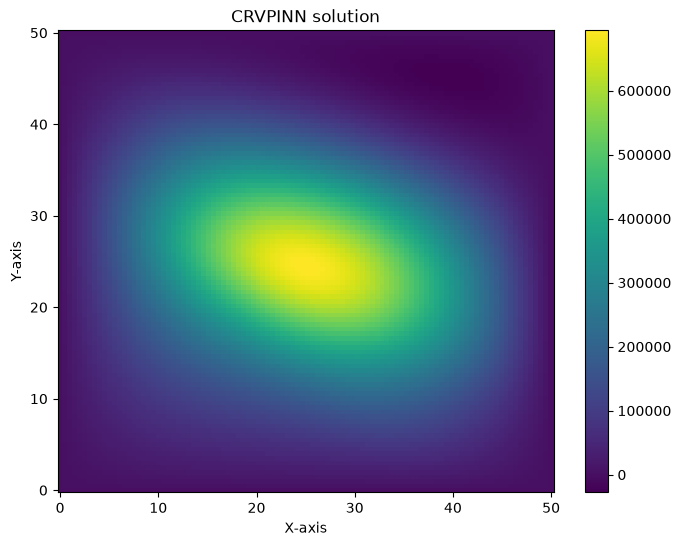

Epoch: 4000 - Loss: 3.902e+00; total runtime: 7.914172410964966 (forward: 2.259977340698242 grad: 4.316417217254639 opt: 0.891284704208374); time per epoch: 0.0019785431027412414;


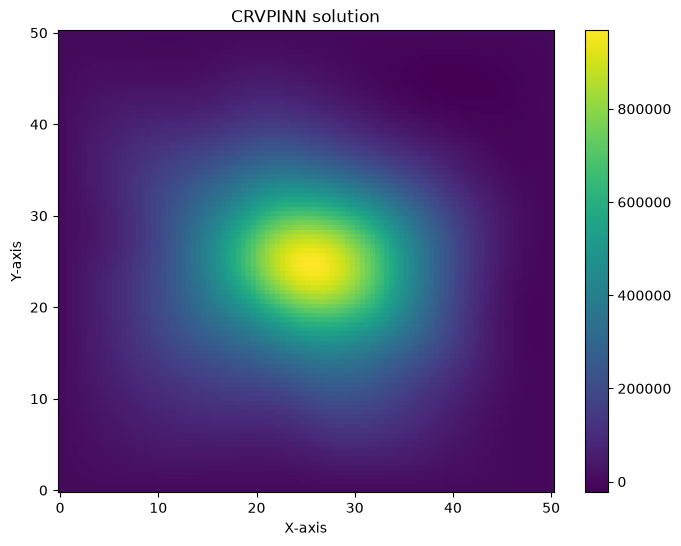

Epoch: 5000 - Loss: 1.615e+00; total runtime: 9.554064512252808 (forward: 2.723979949951172 grad: 5.209256172180176 opt: 1.0717341899871826); time per epoch: 0.0019108129024505616;


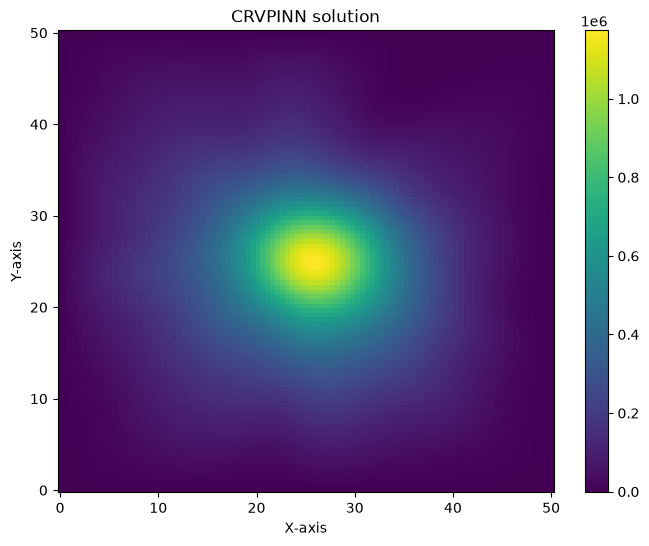

Epoch: 6000 - Loss: 5.739e-01; total runtime: 11.291375160217285 (forward: 3.2164411544799805 grad: 6.1467649936676025 opt: 1.2734689712524414); time per epoch: 0.001881895860036214;


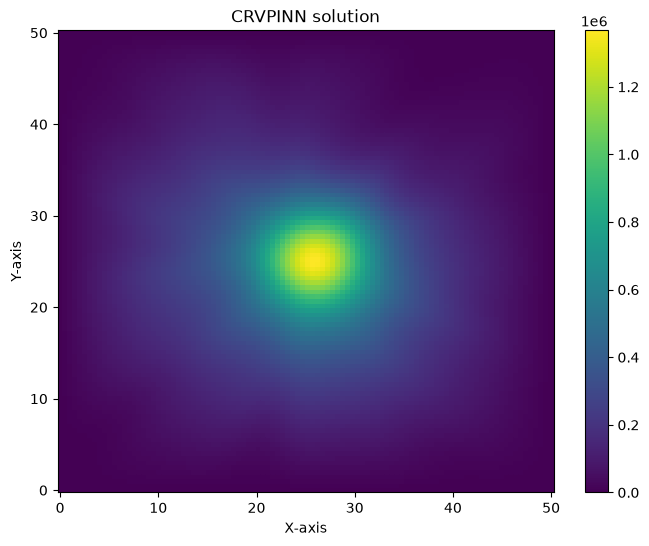

Epoch: 7000 - Loss: 2.732e-01; total runtime: 13.137708902359009 (forward: 3.742727756500244 grad: 7.138353109359741 opt: 1.4930987358093262); time per epoch: 0.0018768155574798585;


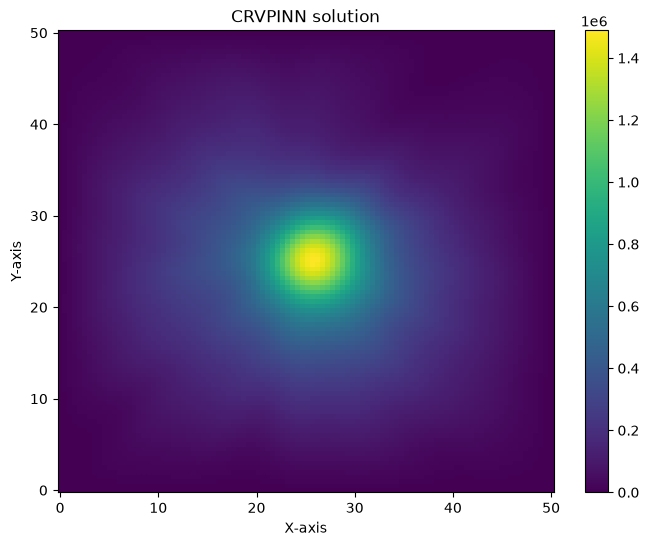

Epoch: 8000 - Loss: 1.660e-01; total runtime: 15.361322164535522 (forward: 4.380472660064697 grad: 8.32327151298523 opt: 1.7673213481903076); time per epoch: 0.0019201652705669403;


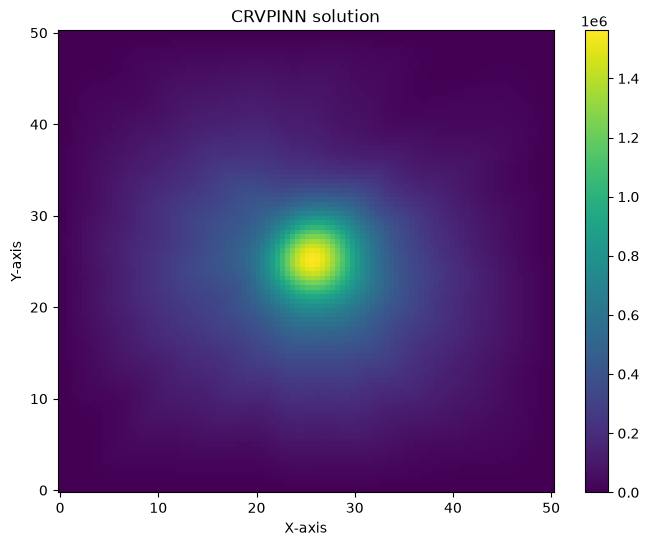

Epoch: 9000 - Loss: 1.297e-01; total runtime: 17.601061820983887 (forward: 5.016586542129517 grad: 9.537410020828247 opt: 2.0304949283599854); time per epoch: 0.0019556735356648764;


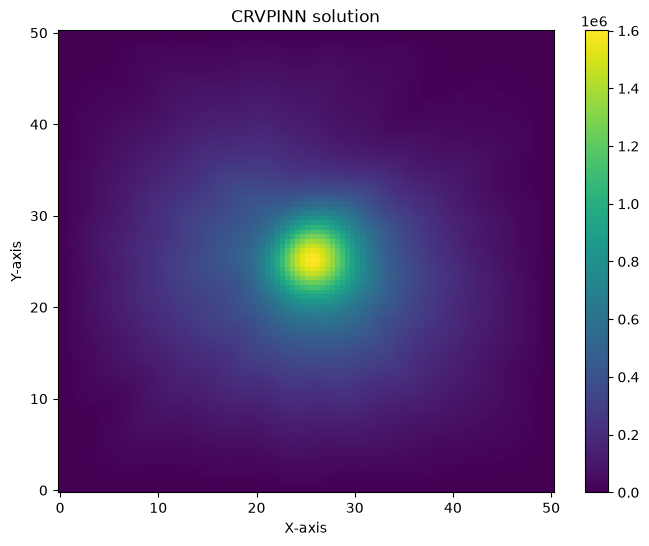

Epoch: 10000 - Loss: 1.082e-01; total runtime: 19.21472430229187 (forward: 5.473011493682861 grad: 10.41622018814087 opt: 2.208423614501953); time per epoch: 0.001921472430229187;


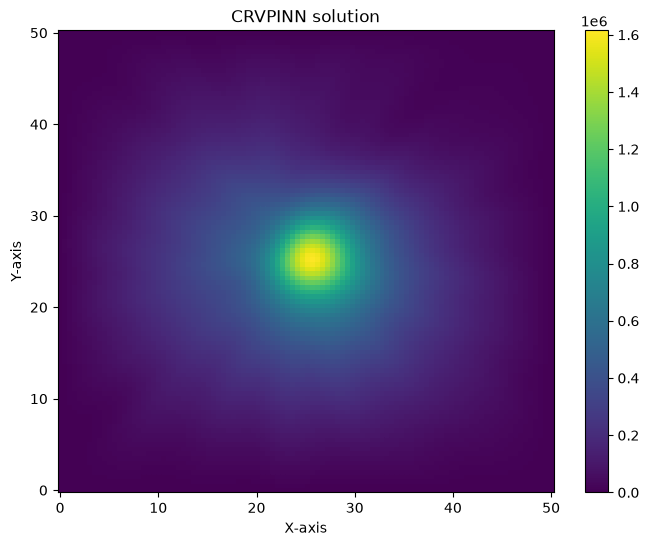

Training time : 21.211035


In [97]:
pinn = None
pinn = PINN(LAYERS, NEURONS_PER_LAYER, pinning=True, act=nn.Tanh()).to(device)

# train the PINN
time_train0 = time.time()

loss_fn = partial(compute_loss, x=x, t=t, w_physics=0, w_data=10)
pinn_trained, loss_values = train_model(
    pinn, x, t, loss_fn=loss_fn, learning_rate=LEARNING_RATE, max_epochs=EPOCHS)
time_train1 = time.time()

print(f'Training time : %f'%(time_train1 - time_train0))

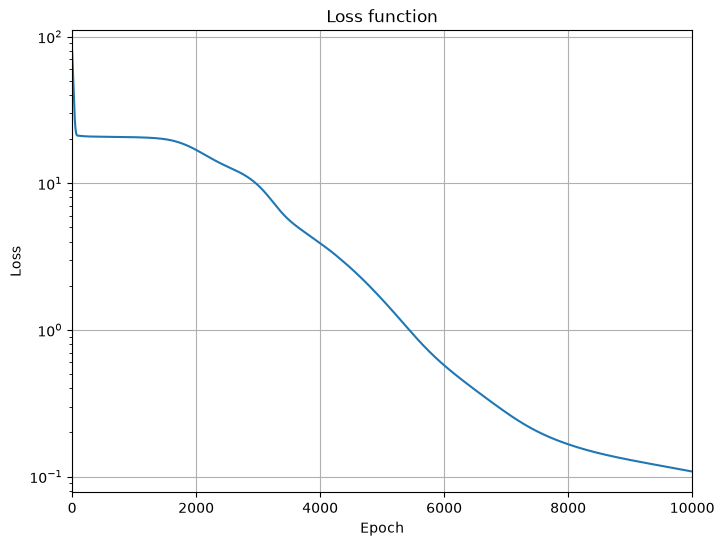

In [98]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
ax.plot(loss_values)
plt.grid(True)

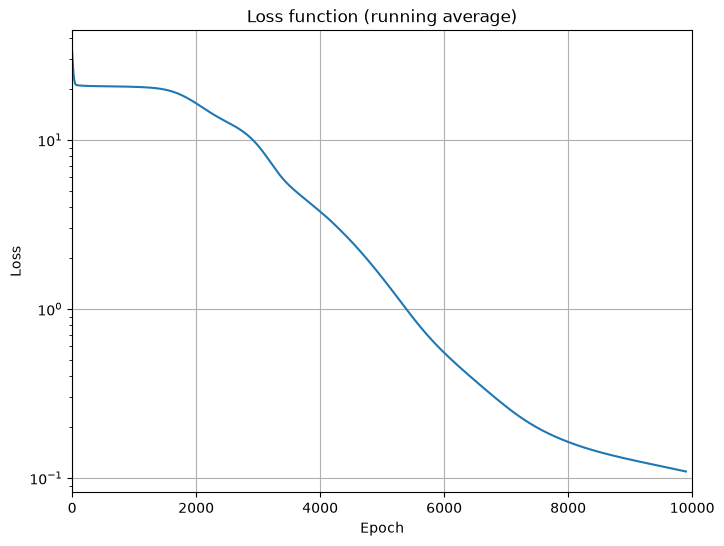

In [99]:
average_loss = running_average(loss_values, window=100)
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
ax.set_title("Loss function (running average)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_yscale("log")
ax.set_xlim(0, EPOCHS)
plt.grid(True)
ax.plot(average_loss)

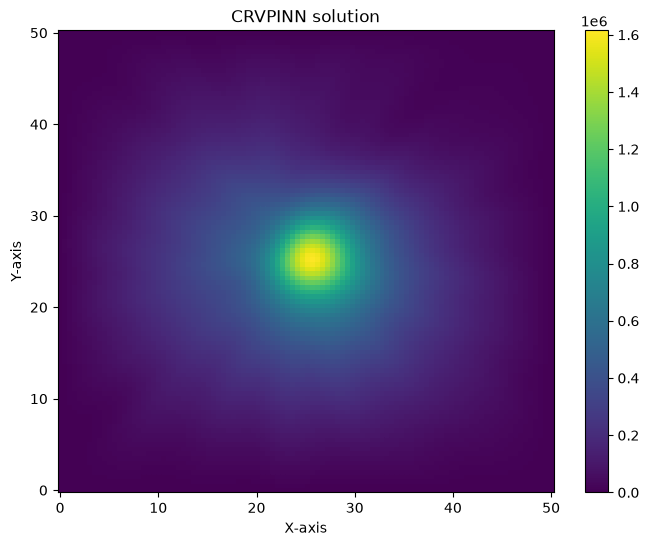

In [100]:
z_0 = f(pinn_trained.to(device), x, t)
color = plot_color(z_0.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)

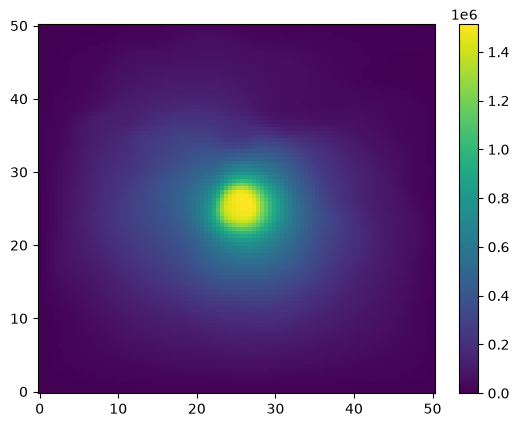

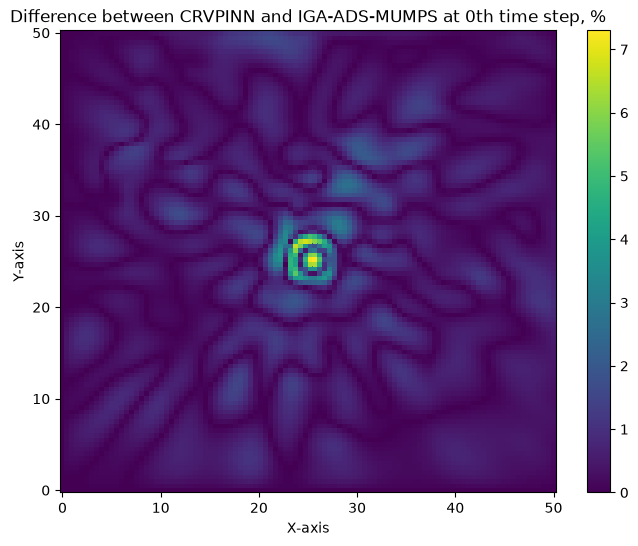

In [101]:
compare_with_iga(z_0, it_simulation=0, folder='perm_map_k3') #, err_bounds=(0,15))

Starting simulation iteration 1/20


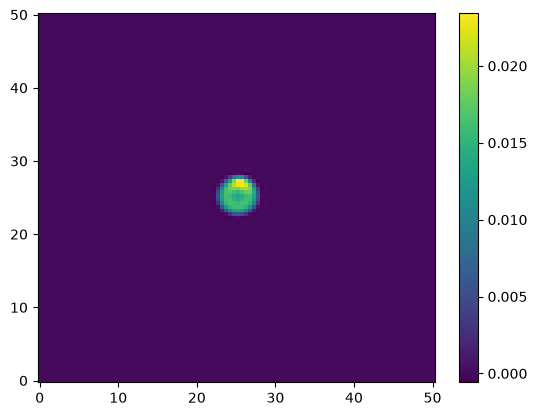

Epoch: 100 - Loss: 1.628e+00; total runtime: 2.1975789070129395 (forward: 0.6441981792449951 grad: 1.2439415454864502 opt: 0.04713034629821777); time per epoch: 0.021975789070129394;


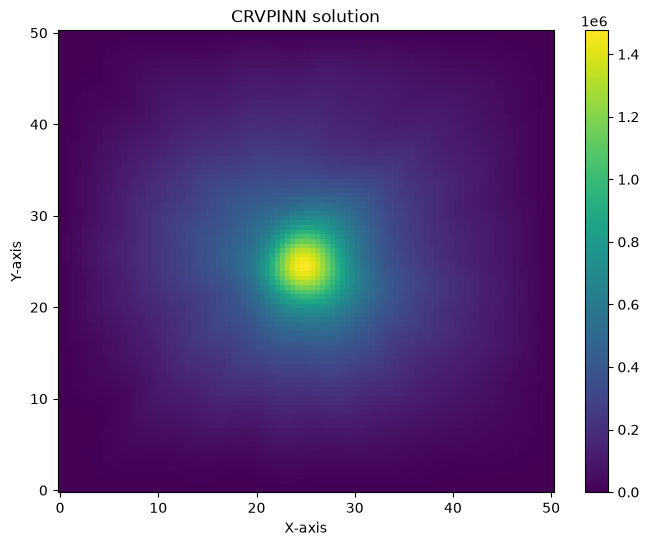

Training time : 2.424243
Starting simulation iteration 2/20


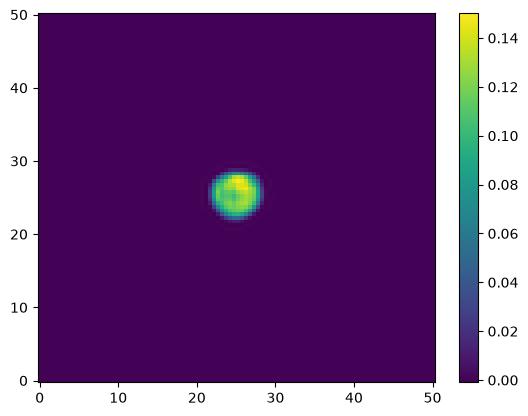

Epoch: 100 - Loss: 2.062e+00; total runtime: 2.359858751296997 (forward: 0.731194257736206 grad: 1.3223390579223633 opt: 0.054692983627319336); time per epoch: 0.02359858751296997;


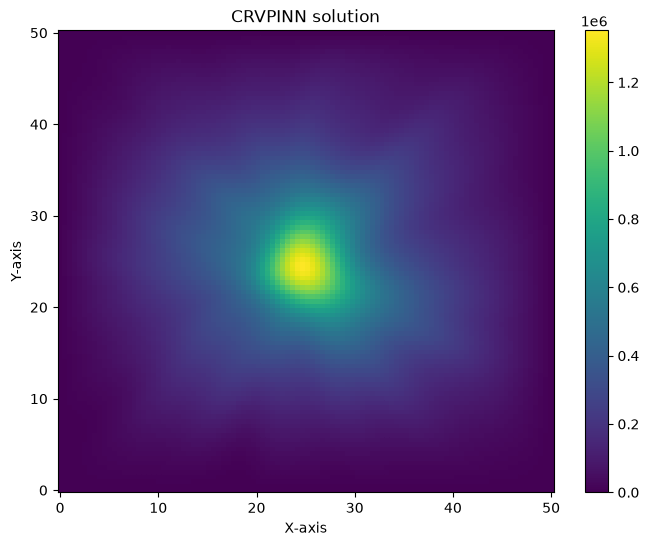

Training time : 2.669760
Starting simulation iteration 3/20


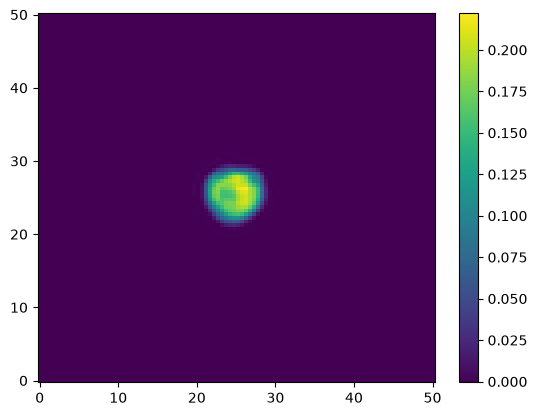

Epoch: 100 - Loss: 1.432e+00; total runtime: 2.0849499702453613 (forward: 0.6022467613220215 grad: 1.1796071529388428 opt: 0.03987240791320801); time per epoch: 0.020849499702453613;


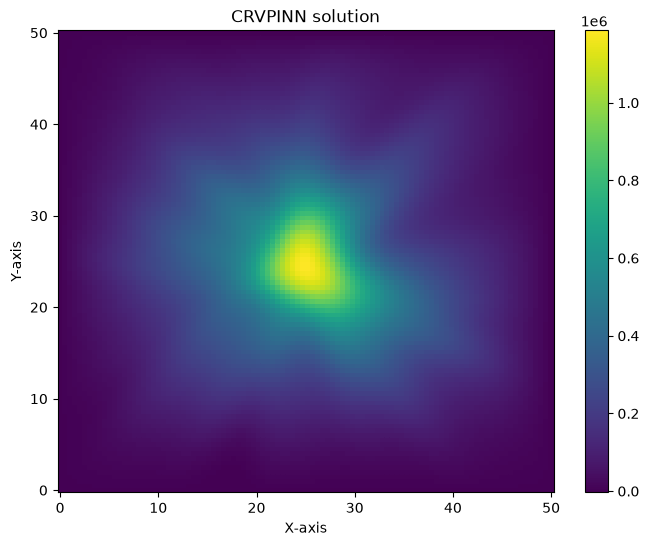

Training time : 2.386266
Starting simulation iteration 4/20


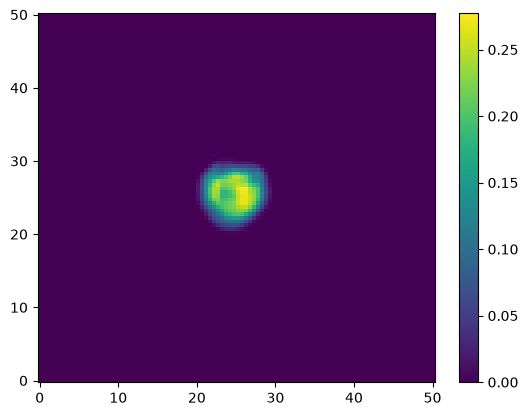

Epoch: 100 - Loss: 9.592e-01; total runtime: 1.9257214069366455 (forward: 0.5445857048034668 grad: 1.0771973133087158 opt: 0.03694605827331543); time per epoch: 0.019257214069366455;


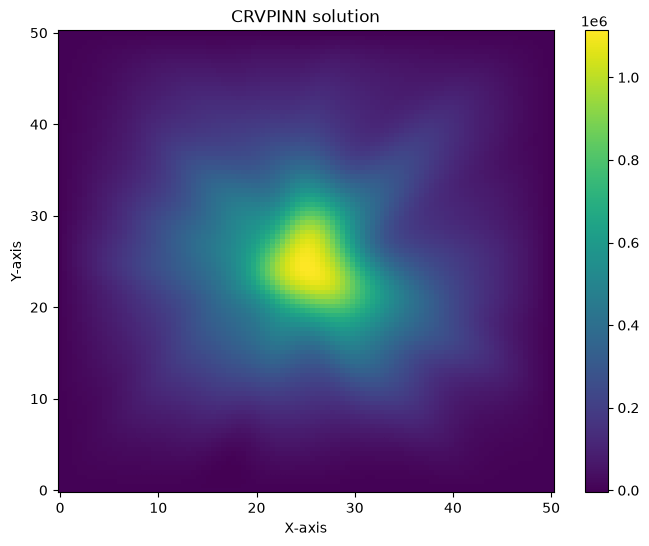

Training time : 2.252564
Starting simulation iteration 5/20


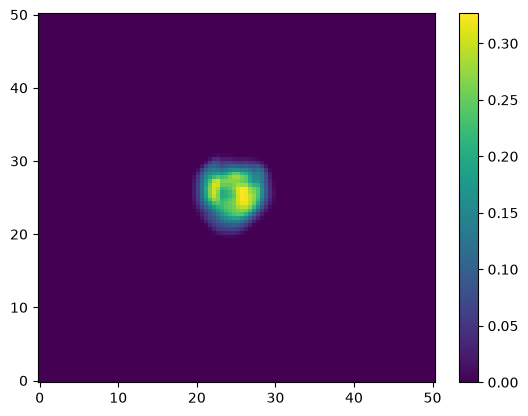

Epoch: 100 - Loss: 6.898e-01; total runtime: 2.293280601501465 (forward: 0.701622486114502 grad: 1.2873222827911377 opt: 0.05414938926696777); time per epoch: 0.02293280601501465;


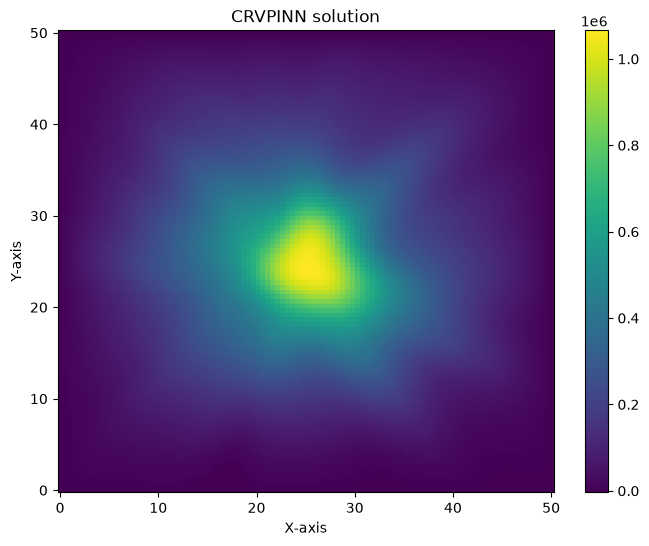

Training time : 2.776144
Starting simulation iteration 6/20


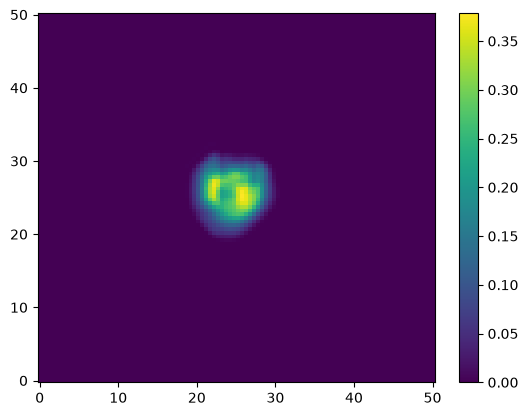

Epoch: 100 - Loss: 5.274e-01; total runtime: 2.567667245864868 (forward: 0.8062057495117188 grad: 1.4463191032409668 opt: 0.0561981201171875); time per epoch: 0.025676672458648683;


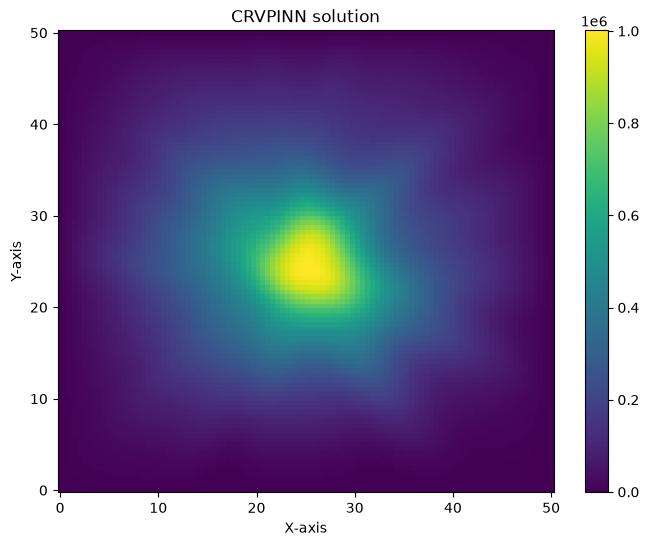

Training time : 2.750701
Starting simulation iteration 7/20


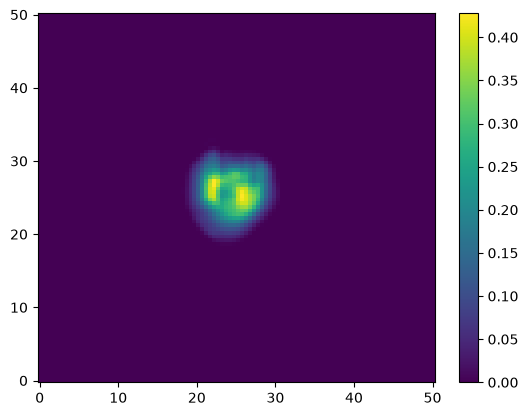

Epoch: 100 - Loss: 4.469e-01; total runtime: 1.92366361618042 (forward: 0.5554986000061035 grad: 1.0678470134735107 opt: 0.03927111625671387); time per epoch: 0.0192366361618042;


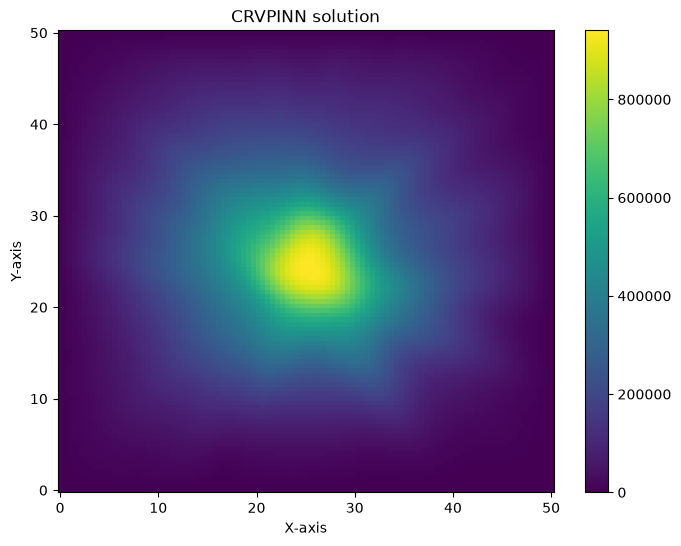

Training time : 2.220299
Starting simulation iteration 8/20


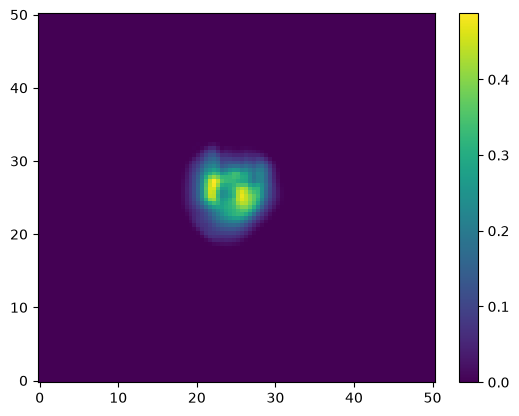

Epoch: 100 - Loss: 4.198e-01; total runtime: 2.565700054168701 (forward: 0.803253173828125 grad: 1.4621977806091309 opt: 0.05747342109680176); time per epoch: 0.02565700054168701;


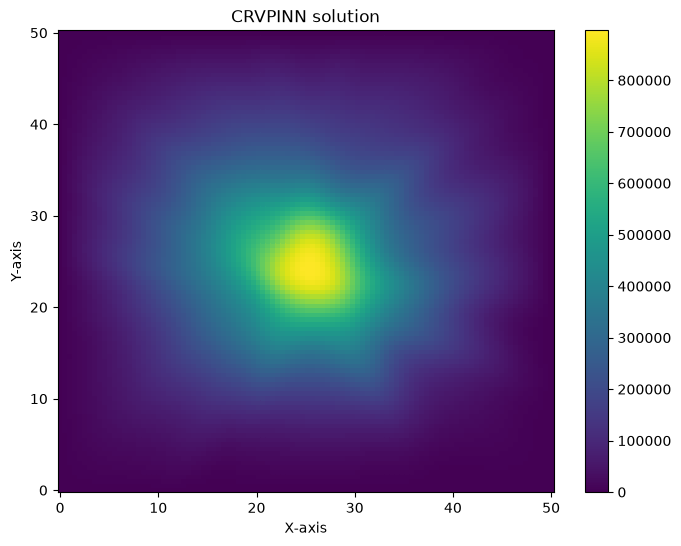

Training time : 2.708069
Starting simulation iteration 9/20


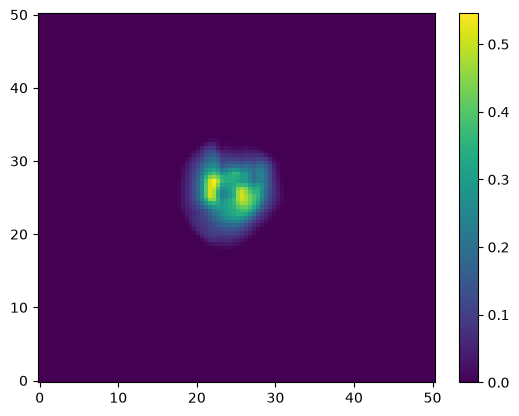

Epoch: 100 - Loss: 4.116e-01; total runtime: 1.8880126476287842 (forward: 0.5370287895202637 grad: 1.0514256954193115 opt: 0.0364077091217041); time per epoch: 0.018880126476287843;


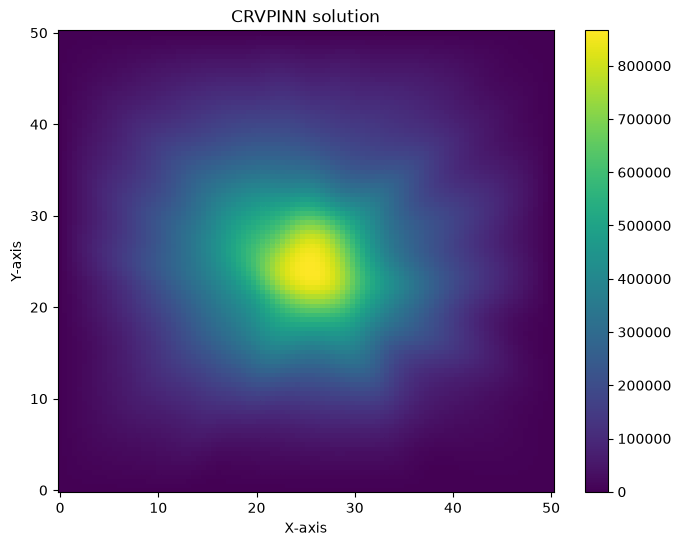

Training time : 2.204908
Starting simulation iteration 10/20


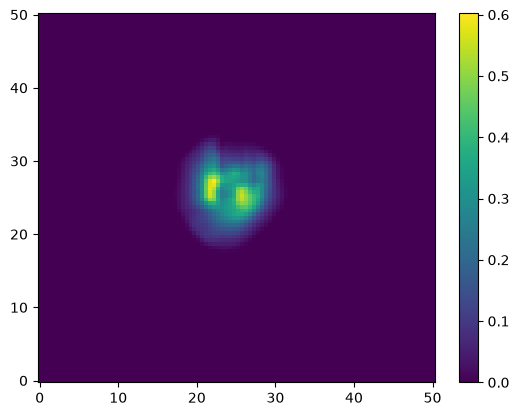

Epoch: 100 - Loss: 4.074e-01; total runtime: 2.0682201385498047 (forward: 0.6112182140350342 grad: 1.1545908451080322 opt: 0.04329991340637207); time per epoch: 0.020682201385498047;


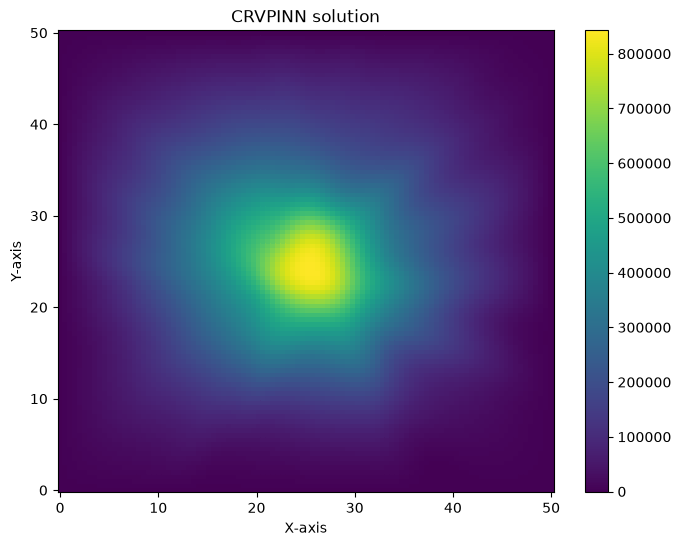

Training time : 2.338199
Starting simulation iteration 11/20


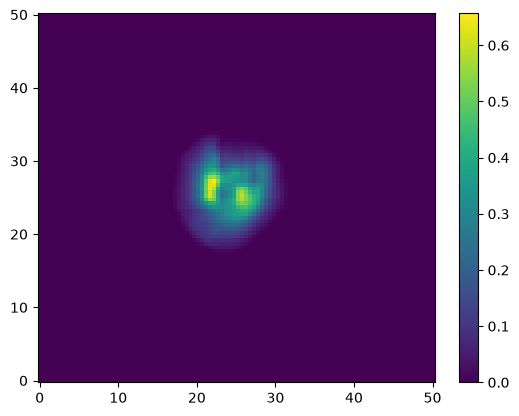

Epoch: 100 - Loss: 4.044e-01; total runtime: 1.870189905166626 (forward: 0.5285437107086182 grad: 1.043574333190918 opt: 0.03546547889709473); time per epoch: 0.01870189905166626;


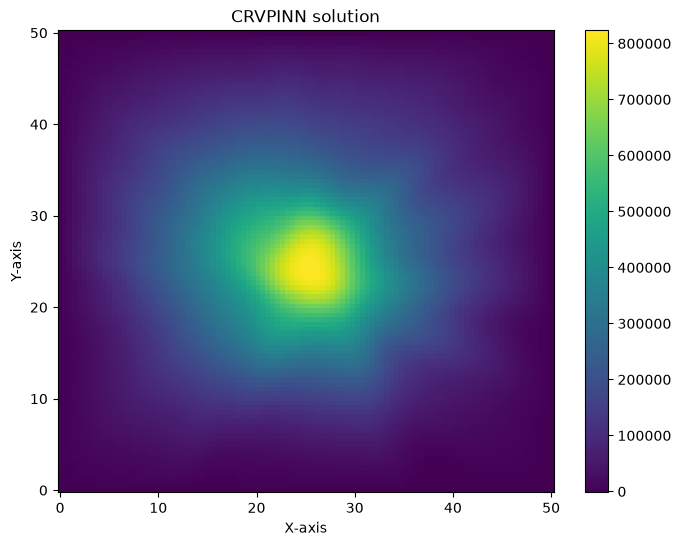

Training time : 2.205317
Starting simulation iteration 12/20


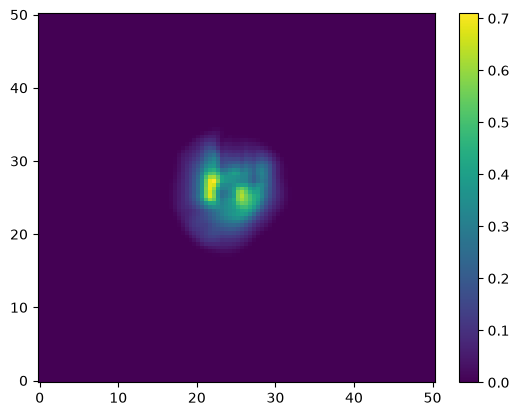

Epoch: 100 - Loss: 4.023e-01; total runtime: 1.8610966205596924 (forward: 0.5225458145141602 grad: 1.0429768562316895 opt: 0.03471040725708008); time per epoch: 0.018610966205596925;


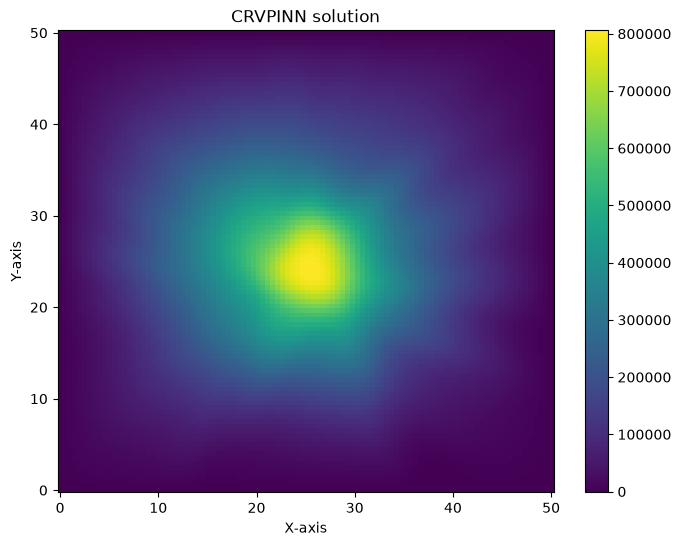

Training time : 2.210552
Starting simulation iteration 13/20


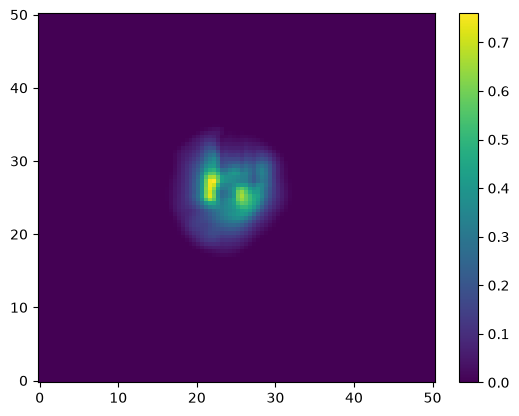

Epoch: 100 - Loss: 4.010e-01; total runtime: 1.9662551879882812 (forward: 0.5668900012969971 grad: 1.0887763500213623 opt: 0.0411221981048584); time per epoch: 0.019662551879882813;


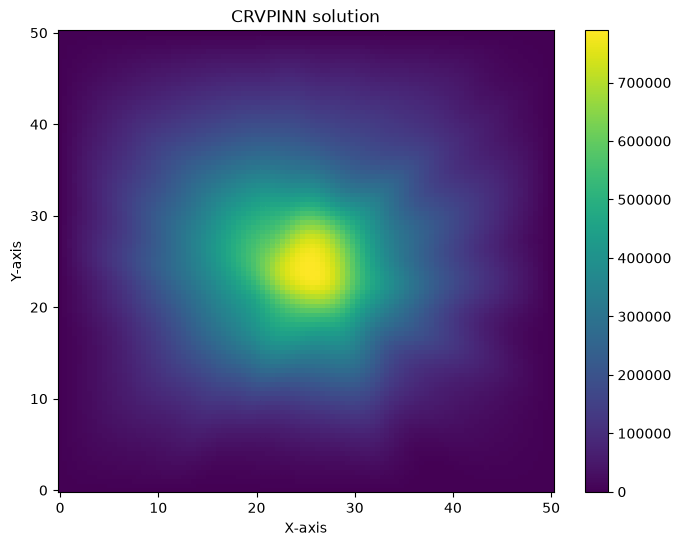

Training time : 2.268313
Starting simulation iteration 14/20


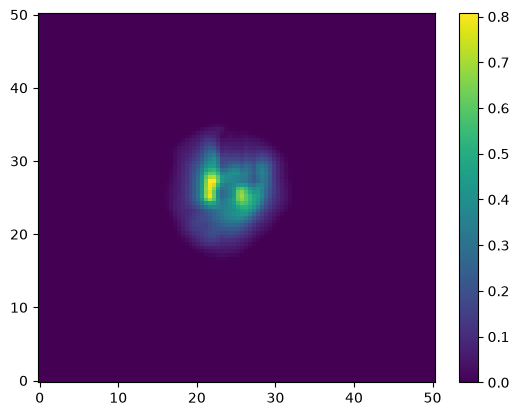

Epoch: 100 - Loss: 4.002e-01; total runtime: 1.886936902999878 (forward: 0.5331244468688965 grad: 1.0512208938598633 opt: 0.0350341796875); time per epoch: 0.018869369029998778;


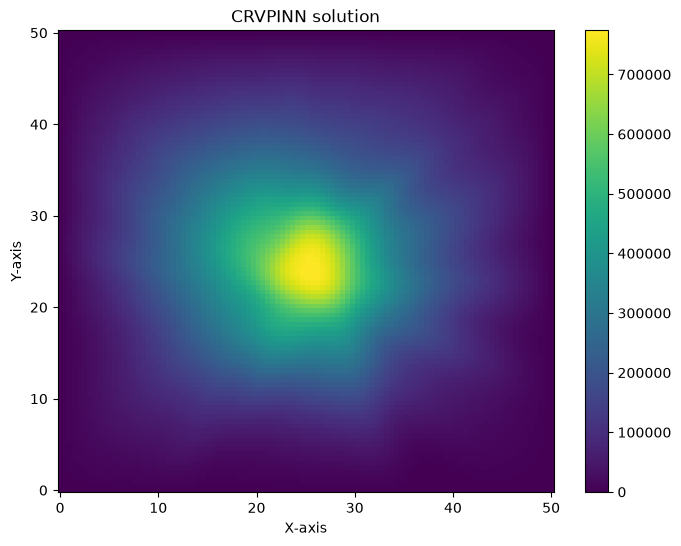

Training time : 2.215414
Starting simulation iteration 15/20


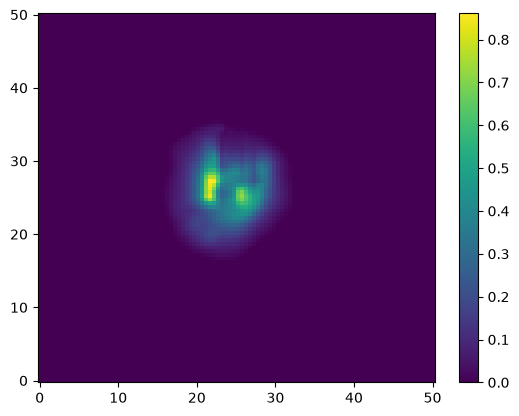

Epoch: 100 - Loss: 3.994e-01; total runtime: 1.8895204067230225 (forward: 0.538076639175415 grad: 1.0467619895935059 opt: 0.03573179244995117); time per epoch: 0.018895204067230224;


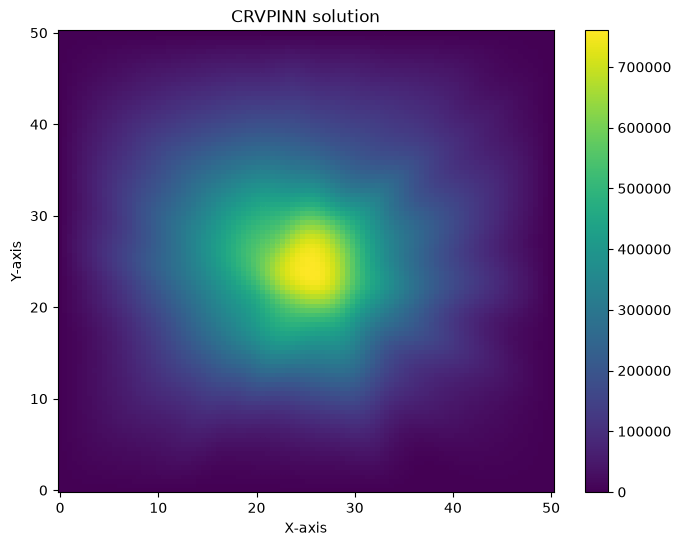

Training time : 2.207680
Starting simulation iteration 16/20


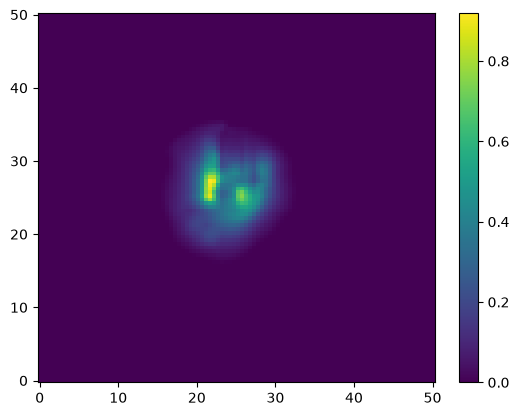

Epoch: 100 - Loss: 3.981e-01; total runtime: 1.8827085494995117 (forward: 0.5307717323303223 grad: 1.049180030822754 opt: 0.03493690490722656); time per epoch: 0.018827085494995118;


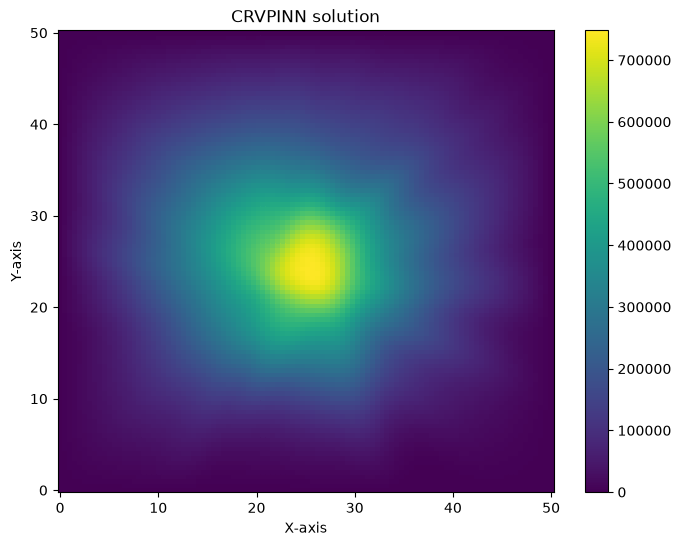

Training time : 2.216508
Starting simulation iteration 17/20


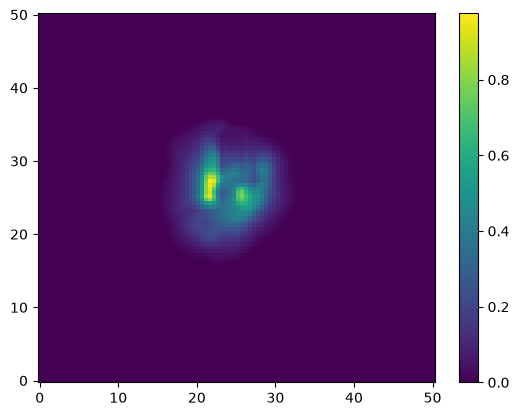

Epoch: 100 - Loss: 3.965e-01; total runtime: 3.0834500789642334 (forward: 0.9900426864624023 grad: 1.7950921058654785 opt: 0.06917047500610352); time per epoch: 0.030834500789642335;


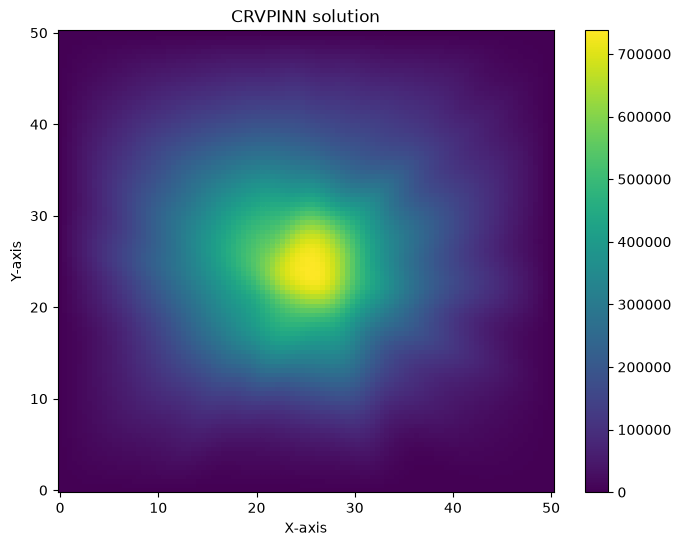

Training time : 3.218677
Starting simulation iteration 18/20


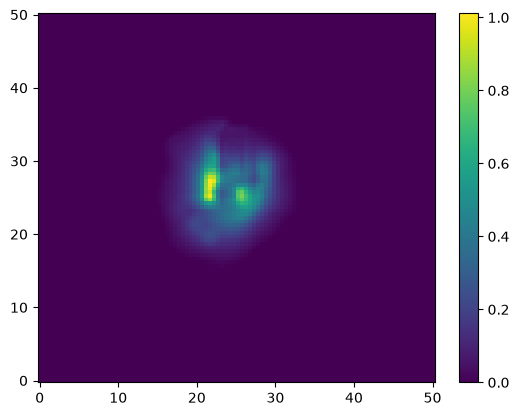

Epoch: 100 - Loss: 3.942e-01; total runtime: 1.9033057689666748 (forward: 0.5372819900512695 grad: 1.0645167827606201 opt: 0.035915374755859375); time per epoch: 0.019033057689666746;


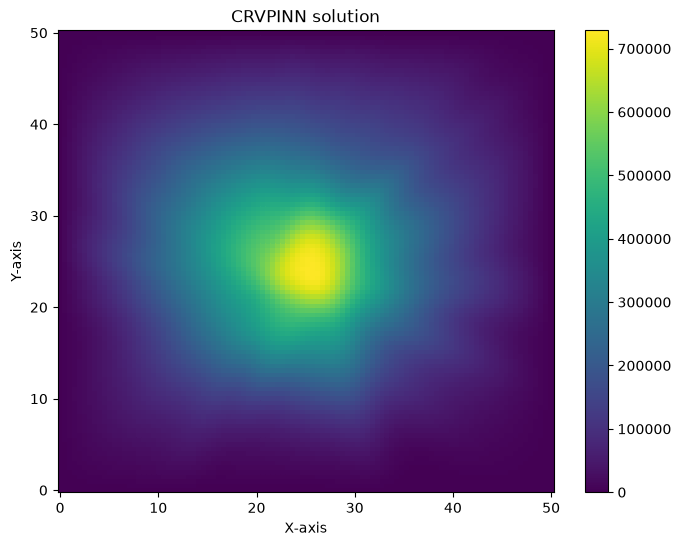

Training time : 2.229345
Starting simulation iteration 19/20


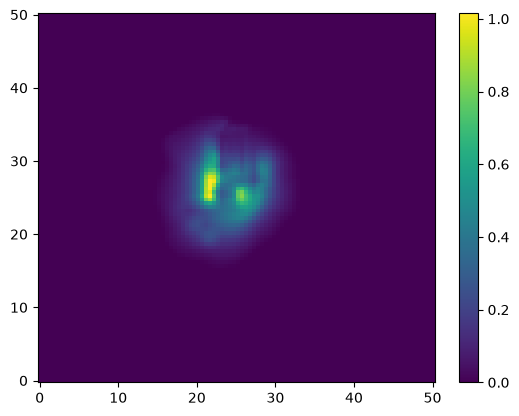

Epoch: 100 - Loss: 3.896e-01; total runtime: 1.863893747329712 (forward: 0.5279109477996826 grad: 1.0353257656097412 opt: 0.033560991287231445); time per epoch: 0.018638937473297118;


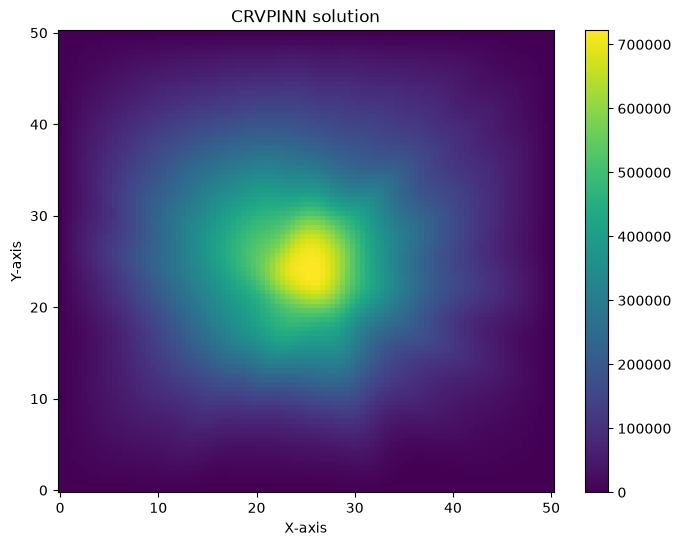

Training time : 2.205061
Starting simulation iteration 20/20


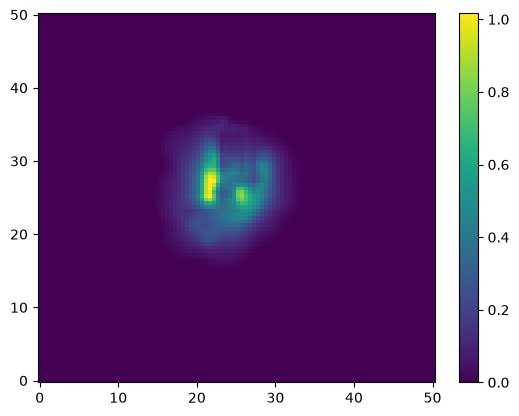

Epoch: 100 - Loss: 3.841e-01; total runtime: 2.9124138355255127 (forward: 0.9288101196289062 grad: 1.684511661529541 opt: 0.060760498046875); time per epoch: 0.029124138355255128;


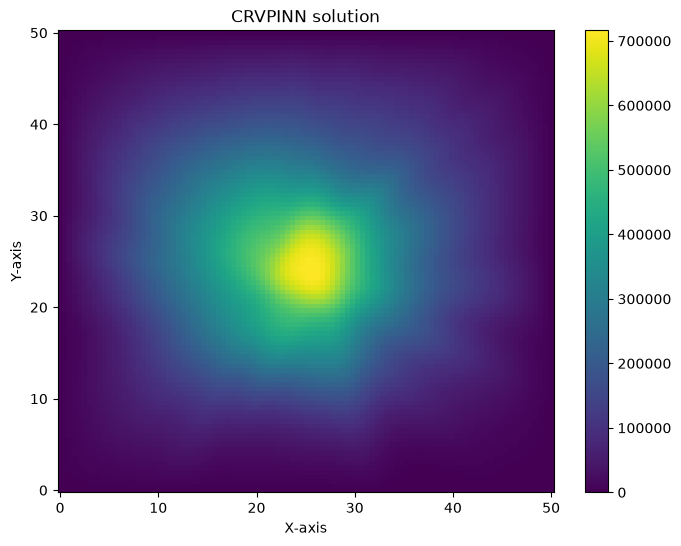

Training time : 3.430311
Total training time for 20 iterations: 49.138332


In [102]:
pinn_trained, loss_values_cont = continue_training(pinn, x, t, n_it_simulation=20, folder_name='perm_map_k3')

Text(0.5, 1.0, 'CRVPINN solution at 19th time step')

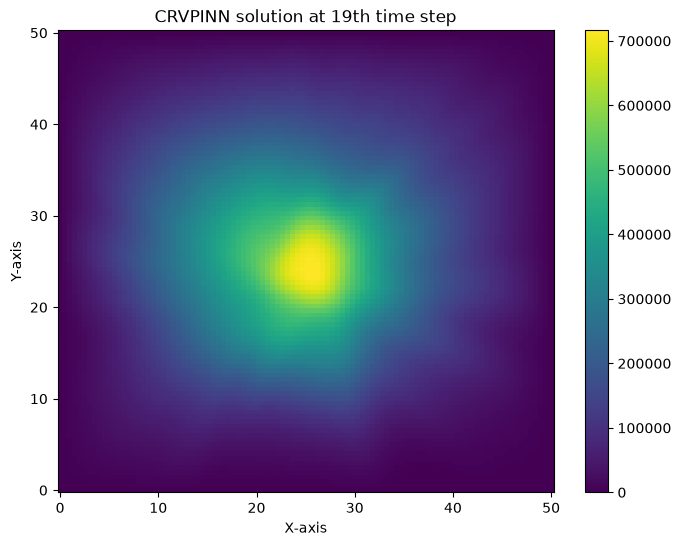

In [103]:
z_190 = f(pinn_trained.to(device), x, t)
color = plot_color(z_190.cpu(), x.cpu(), t.cpu(), N_POINTS_X, N_POINTS_T)
plt.title('CRVPINN solution at 19th time step')

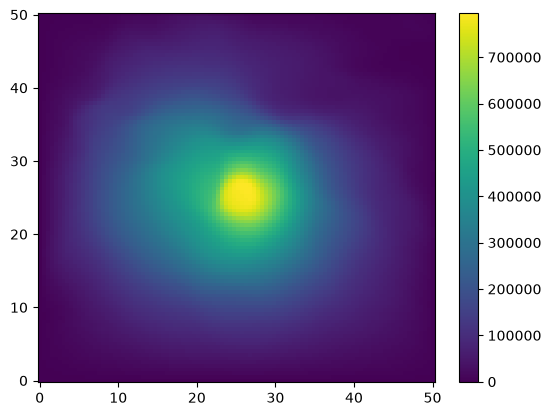

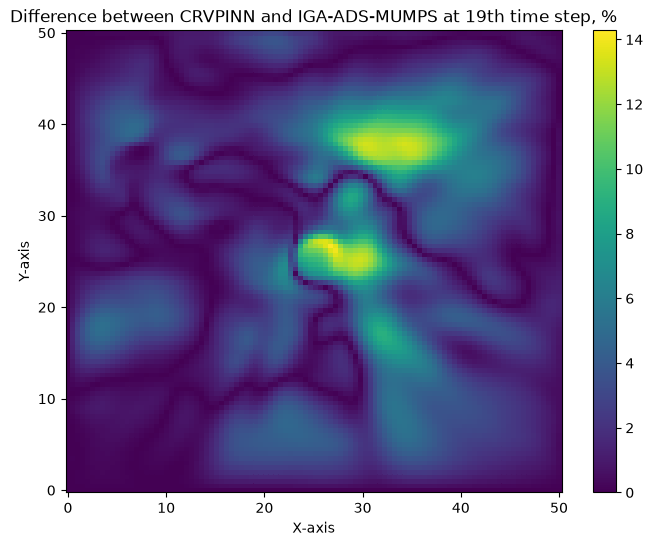

In [104]:
compare_with_iga(z_190, it_simulation=19, folder='perm_map_k3') #, err_bounds=(0,15))

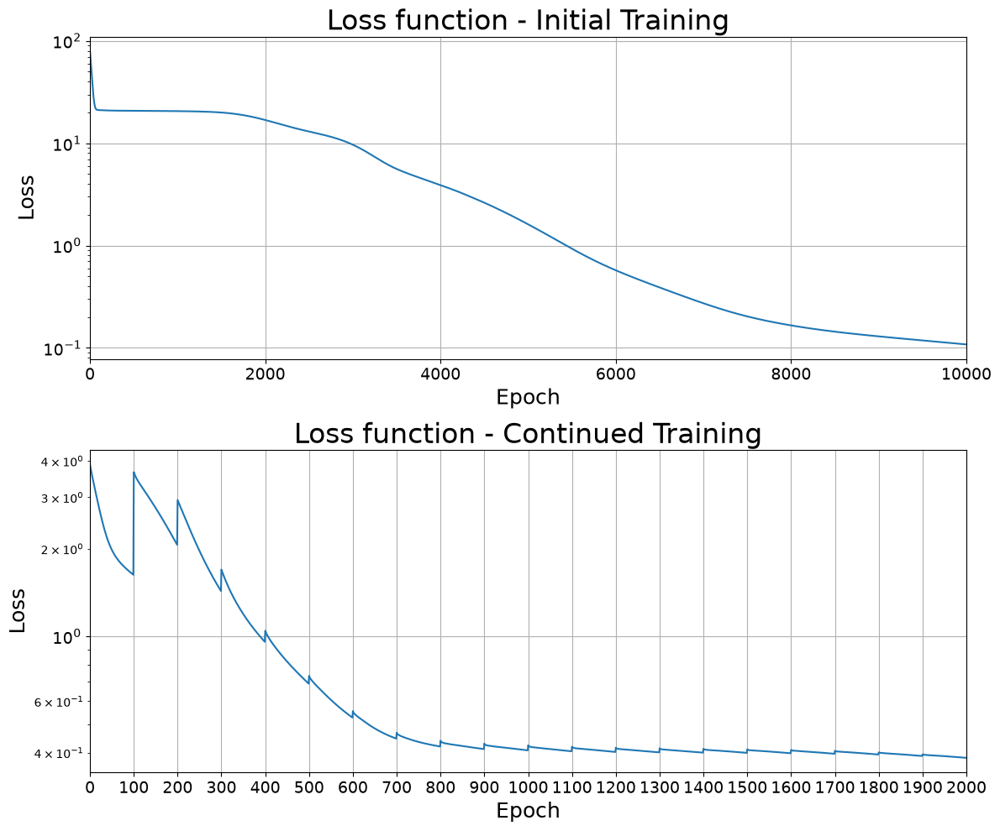

In [105]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.set_title("Loss function - Initial Training", fontsize = 24)
ax1.set_xlabel("Epoch", fontsize = 18)
ax1.set_ylabel("Loss", fontsize = 18)
ax1.set_yscale("log")
ax1.set_xlim(0, EPOCHS)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.plot(loss_values)
ax1.grid(True)

ax2.set_title("Loss function - Continued Training", fontsize = 24)
ax2.set_xlabel("Epoch", fontsize = 18)
ax2.set_ylabel("Loss", fontsize = 18)
ax2.set_yscale("log")
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.set_xlim(0, len(loss_values_cont))
ax2.set_xticks(np.arange(0, len(loss_values_cont)+1, step=100))
ax2.plot(loss_values_cont)
ax2.grid(True)

plt.tight_layout()